# Predicción explicable del riesgo cardiovascular a 10 años

## Objetivo del proyecto

El objetivo de este proyecto es construir y comparar tres enfoques para estimar la probabilidad de sufrir un primer evento cardiovascular grave durante los siguientes diez años:

1. **WHO 2019 Cardiovascular Risk Chart**, como modelo clínico real de referencia.
2. **Regresión logística**, como modelo estadístico interpretable.
3. **Gradient Boosting**, como modelo moderno de machine learning.

## Evento estudiado

La variable objetivo representará la aparición durante los primeros diez años de seguimiento de alguno de los siguientes eventos:

- Infarto de miocardio fatal o no fatal.
- Muerte por enfermedad coronaria.
- Ictus fatal o no fatal.

Antes de construir la variable objetivo se comprobará que la definición de los eventos del dataset sea compatible con la utilizada por el modelo clínico de la Organización Mundial de la Salud.

## Pregunta principal

¿Puede un modelo moderno de machine learning mejorar la discriminación y la calidad de las probabilidades frente a un modelo clínico establecido y un modelo estadístico interpretable?

## Modelos que se compararán

- WHO 2019 Cardiovascular Risk Chart para la región High-income North America.
- Regresión logística.
- Gradient Boosting.

## Métricas de evaluación

- ROC-AUC.
- Recall o sensibilidad.
- Precision.
- F1-score.
- Especificidad.
- Accuracy.
- Brier score.
- Curva de calibración.
- Matriz de confusión.

## Fuente de los datos

Se utilizarán datos públicos y anonimizados procedentes de:

- National Health and Nutrition Examination Survey I — NHANES I.
- NHANES I Epidemiologic Follow-up Study — NHEFS.

NHANES I contiene las características clínicas iniciales de los participantes. NHEFS contiene información de seguimiento sobre hospitalizaciones, mortalidad y evolución posterior.

## Primera fase: auditoría de viabilidad

Antes de entrenar modelos se comprobará:

- Que estén disponibles las variables necesarias para el modelo WHO.
- Que sea posible identificar correctamente los eventos cardiovasculares.
- Que pueda definirse un horizonte de seguimiento de diez años.
- Cuántos participantes cumplen los criterios de inclusión.
- Cuántos eventos positivos existen.
- Cuántos valores ausentes presenta cada variable.
- Si los tres modelos pueden compararse sobre la misma muestra.

> **Aviso:** este proyecto tiene fines educativos y de análisis de datos. No constituye un diagnóstico, una recomendación médica ni una herramienta clínica validada.


In [704]:
# Librerías que utilizaremos para descargar y trabajar con los datos
from pathlib import Path
import requests
import pandas as pd

# Creamos una carpeta dentro de Google Colab para guardar los archivos
carpeta_datos = Path("/content/nhefs_datos")
carpeta_datos.mkdir(parents=True, exist_ok=True)

# Dirección oficial del archivo informativo del CDC
url_readme = "https://wwwn.cdc.gov/Nchs/data/nhefs/readme_ftp.txt"

# Descargamos el archivo
respuesta = requests.get(url_readme, timeout=60)
respuesta.raise_for_status()

# Lo guardamos dentro de la carpeta creada
ruta_readme = carpeta_datos / "readme_nhefs.txt"
ruta_readme.write_bytes(respuesta.content)

print("Carpeta creada:", carpeta_datos)
print("Estado de la descarga:", respuesta.status_code)
print("Archivo guardado en:", ruta_readme)

Carpeta creada: /content/nhefs_datos
Estado de la descarga: 200
Archivo guardado en: /content/nhefs_datos/readme_nhefs.txt


In [705]:
# Abrimos el archivo informativo descargado
with open(ruta_readme, mode="r", encoding="latin-1") as archivo:
    texto_readme = archivo.read()

# Mostramos los primeros 4.000 caracteres
print(texto_readme[:4000])

NHEFS Survey description

The NHANES I Epidemiologic Followup Study (NHEFS) is a national longitudinal study that was jointly initiated by the National Center for Health Statistics and the National Institute on Aging in collaboration with other agencies of the Public Health Service. The NHEFS was designed to investigate the relationships between clinical, nutritional, and behavioral factors assessed in the first National Health and Nutrition Examination Survey (NHANES I) and subsequent morbidity, mortality, and hospital utilization, as well as changes in risk factors, functional limitation, and institutionalization.

The NHEFS cohort includes all persons 25-74 years of age who completed a medical examination at NHANES I in 1971-75 (n = 14,407). It is comprised of a series of followup studies, four of which have been conducted to date. The first wave of data collection was conducted for all members of the NHEFS cohort from 1982 through 1984. It included tracing the cohort; conducting pe

In [706]:
# Direcciones oficiales del CDC
url_vital = "https://wwwn.cdc.gov/Nchs/data/nhefs/n92vitl.txt"
url_estructura_vital = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/vitl.inputs.labels.txt"
)

# Rutas donde guardaremos los archivos en Colab
ruta_vital = carpeta_datos / "n92vitl.txt"
ruta_estructura_vital = carpeta_datos / "vitl_inputs_labels.txt"

# Descargamos el archivo de datos
respuesta_vital = requests.get(url_vital, timeout=120)
respuesta_vital.raise_for_status()
ruta_vital.write_bytes(respuesta_vital.content)

# Descargamos el documento que explica la posición de las variables
respuesta_estructura = requests.get(url_estructura_vital, timeout=60)
respuesta_estructura.raise_for_status()
ruta_estructura_vital.write_bytes(respuesta_estructura.content)

print("Archivo de datos guardado en:", ruta_vital)
print("Tamaño del archivo:", round(ruta_vital.stat().st_size / 1_000_000, 2), "MB")

print("\nDocumento de estructura guardado en:", ruta_estructura_vital)

Archivo de datos guardado en: /content/nhefs_datos/n92vitl.txt
Tamaño del archivo: 3.95 MB

Documento de estructura guardado en: /content/nhefs_datos/vitl_inputs_labels.txt


In [707]:
# Posiciones de las variables dentro del archivo de ancho fijo
# Python empieza a contar desde 0 y no incluye la posición final

posiciones = [
    (11, 16),   # SEQNUM
    (16, 17),   # CVITALST
    (32, 34),   # NEXAMMO
    (34, 36),   # NEXAMDY
    (36, 38),   # NEXAMYR
    (38, 40),   # NEXAMAGE
    (45, 46),   # SEXSUBJ
    (51, 52),   # DTHCRTFG
    (52, 56),   # UNCAUDTH
    (60, 62),   # DTDTHMO
    (62, 64),   # DTDTHDY
    (64, 66),   # DTDTHYR
    (66, 68),   # AGEDTH
    (188, 190), # VTLST92
    (190, 192), # DLKAMO92
    (192, 194), # DLKADY92
    (194, 196)  # DLKAYR92
]

nombres_columnas = [
    "SEQNUM",
    "CVITALST",
    "NEXAMMO",
    "NEXAMDY",
    "NEXAMYR",
    "NEXAMAGE",
    "SEXSUBJ",
    "DTHCRTFG",
    "UNCAUDTH",
    "DTDTHMO",
    "DTDTHDY",
    "DTDTHYR",
    "AGEDTH",
    "VTLST92",
    "DLKAMO92",
    "DLKADY92",
    "DLKAYR92"
]

# Leemos el archivo manteniendo inicialmente los datos como texto
datos_vitales = pd.read_fwf(
    ruta_vital,
    colspecs=posiciones,
    names=nombres_columnas,
    dtype=str
)

print("Dimensiones del archivo:", datos_vitales.shape)

print("\nNúmero de identificadores únicos:")
print(datos_vitales["SEQNUM"].nunique())

datos_vitales.head()

Dimensiones del archivo: (14407, 17)

Número de identificadores únicos:
14407


,SEQNUM,CVITALST,NEXAMMO,NEXAMDY,NEXAMYR,NEXAMAGE,SEXSUBJ,DTHCRTFG,UNCAUDTH,DTDTHMO,DTDTHDY,DTDTHYR,AGEDTH,VTLST92,DLKAMO92,DLKADY92,DLKAYR92
0,00001,1,05,20,71,39,2,NaN,NaN,NaN,NaN,NaN,NaN,01,06,16,92
1,00002,1,05,22,71,61,1,NaN,NaN,NaN,NaN,NaN,NaN,01,06,15,92
2,00003,4,04,28,71,25,2,NaN,NaN,NaN,NaN,NaN,NaN,04,04,28,71
3,00007,3,05,19,71,35,2,1,431,08,28,86,50,99,99,99,99
4,00008,1,04,28,71,35,2,NaN,NaN,NaN,NaN,NaN,NaN,01,09,03,92


In [708]:
columnas_revision = [
    "CVITALST",
    "DTHCRTFG",
    "UNCAUDTH",
    "VTLST92"
]

for columna in columnas_revision:
    print(f"\n--- {columna} ---")
    print(datos_vitales[columna].value_counts(dropna=False).sort_index())

print("\nValores ausentes por columna:")
print(datos_vitales.isnull().sum())


--- CVITALST ---
CVITALST
1    8801
3    4604
4     546
5     260
6     196
Name: count, dtype: int64

--- DTHCRTFG ---
DTHCRTFG
1      4497
2       107
NaN    9803
Name: count, dtype: int64

--- UNCAUDTH ---
UNCAUDTH
0000     107
0039       1
0116       1
0119       7
0270       1
        ... 
9651       1
9654       6
9681       1
9688       3
NaN     9803
Name: count, Length: 434, dtype: int64

--- VTLST92 ---
VTLST92
01    8372
03    1392
04    1116
05     252
06      63
99    3212
Name: count, dtype: int64

Valores ausentes por columna:
SEQNUM         0
CVITALST       0
NEXAMMO        0
NEXAMDY        0
NEXAMYR        0
NEXAMAGE       0
SEXSUBJ        0
DTHCRTFG    9803
UNCAUDTH    9803
DTDTHMO     9803
DTDTHDY     9803
DTDTHYR     9803
AGEDTH      9803
VTLST92        0
DLKAMO92       0
DLKADY92       0
DLKAYR92       0
dtype: int64


In [709]:
# Diccionarios para traducir los códigos oficiales

mapa_cvitalst = {
    "1": "Vivo",
    "3": "Fallecido",
    "4": "Estado desconocido",
    "5": "Vivo con contacto directo",
    "6": "Vivo confirmado sin contacto directo"
}

mapa_vtlst92 = {
    "01": "Vivo",
    "03": "Fallecido",
    "04": "Estado desconocido",
    "05": "Vivo con contacto directo",
    "06": "Vivo confirmado por otra persona",
    "99": "Fallecido en una ronda anterior"
}

mapa_certificado = {
    "1": "Certificado de defunción disponible",
    "2": "Certificado de defunción no disponible"
}

# Creamos columnas descriptivas sin modificar las originales

datos_vitales["CVITALST_DESC"] = (
    datos_vitales["CVITALST"]
    .map(mapa_cvitalst)
)

datos_vitales["VTLST92_DESC"] = (
    datos_vitales["VTLST92"]
    .map(mapa_vtlst92)
)

datos_vitales["DTHCRTFG_DESC"] = (
    datos_vitales["DTHCRTFG"]
    .map(mapa_certificado)
    .fillna("No aplicable: participante no conocido como fallecido")
)

print("Estado vital general:")
print(datos_vitales["CVITALST_DESC"].value_counts(dropna=False))

print("\nEstado vital en la ronda de 1992:")
print(datos_vitales["VTLST92_DESC"].value_counts(dropna=False))

print("\nDisponibilidad del certificado de defunción:")
print(datos_vitales["DTHCRTFG_DESC"].value_counts(dropna=False))

Estado vital general:
CVITALST_DESC
Vivo                                    8801
Fallecido                               4604
Estado desconocido                       546
Vivo con contacto directo                260
Vivo confirmado sin contacto directo     196
Name: count, dtype: int64

Estado vital en la ronda de 1992:
VTLST92_DESC
Vivo                                8372
Fallecido en una ronda anterior     3212
Fallecido                           1392
Estado desconocido                  1116
Vivo con contacto directo            252
Vivo confirmado por otra persona      63
Name: count, dtype: int64

Disponibilidad del certificado de defunción:
DTHCRTFG_DESC
No aplicable: participante no conocido como fallecido    9803
Certificado de defunción disponible                      4497
Certificado de defunción no disponible                    107
Name: count, dtype: int64


In [710]:
# Direcciones oficiales del archivo de mortalidad y su estructura

url_mortalidad = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/N92mort.txt"
)

url_estructura_mortalidad = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/mort.inputs.labels.txt"
)

# Rutas donde se guardarán en Google Colab

ruta_mortalidad = carpeta_datos / "N92mort.txt"
ruta_estructura_mortalidad = carpeta_datos / "mort_inputs_labels.txt"

# Descargamos los datos de mortalidad

respuesta_mortalidad = requests.get(
    url_mortalidad,
    timeout=120
)

respuesta_mortalidad.raise_for_status()

ruta_mortalidad.write_bytes(
    respuesta_mortalidad.content
)

# Descargamos el documento que explica las posiciones

respuesta_estructura_mortalidad = requests.get(
    url_estructura_mortalidad,
    timeout=60
)

respuesta_estructura_mortalidad.raise_for_status()

ruta_estructura_mortalidad.write_bytes(
    respuesta_estructura_mortalidad.content
)

print("Archivo de mortalidad guardado en:")
print(ruta_mortalidad)

print("\nTamaño del archivo:")
print(
    round(
        ruta_mortalidad.stat().st_size / 1_000_000,
        2
    ),
    "MB"
)

print("\nDocumento de estructura guardado en:")
print(ruta_estructura_mortalidad)

Archivo de mortalidad guardado en:
/content/nhefs_datos/N92mort.txt

Tamaño del archivo:
1.99 MB

Documento de estructura guardado en:
/content/nhefs_datos/mort_inputs_labels.txt


In [711]:
# Posiciones de las variables principales
# El archivo es de ancho fijo: cada variable ocupa unas posiciones concretas

posiciones_mortalidad = [
    (0, 2),      # YRDTH
    (2, 7),      # SEQNUM
    (54, 56),    # DTDTHMO
    (56, 58),    # DTDTHDY
    (58, 59),    # SEXSUB
    (63, 66),    # DTAGEDTH
    (141, 145),  # ICDCODE
    (145, 150),  # CADTHRC1
    (150, 153),  # CADTHRC2
    (156, 159)   # CADTHRC3
]

nombres_mortalidad = [
    "YRDTH",
    "SEQNUM",
    "DTDTHMO",
    "DTDTHDY",
    "SEXSUB",
    "DTAGEDTH",
    "ICDCODE",
    "CADTHRC1",
    "CADTHRC2",
    "CADTHRC3"
]

datos_mortalidad = pd.read_fwf(
    ruta_mortalidad,
    colspecs=posiciones_mortalidad,
    names=nombres_mortalidad,
    dtype=str
)

print("Dimensiones del archivo de mortalidad:")
print(datos_mortalidad.shape)

print("\nNúmero de participantes únicos:")
print(datos_mortalidad["SEQNUM"].nunique())

datos_mortalidad.head()

Dimensiones del archivo de mortalidad:
(4497, 10)

Número de participantes únicos:
4497


,YRDTH,SEQNUM,DTDTHMO,DTDTHDY,SEXSUB,DTAGEDTH,ICDCODE,CADTHRC1,CADTHRC2,CADTHRC3
0,92,20809,10,24,1,091,486,21400,520,230
1,85,20793,08,20,2,073,410,17400,360,170
2,92,20781,10,18,2,052,1830,08500,200,080
3,87,20784,01,23,1,076,4280,18600,410,180
4,84,20794,05,08,1,067,1539,06200,170,050


In [712]:
# Función para obtener la categoría principal de tres dígitos del código ICD-9

def obtener_icd9_tres_digitos(codigo):
    """
    Convierte códigos como:
    410  -> 410
    4280 -> 428
    1830 -> 183
    """

    if pd.isna(codigo):
        return pd.NA

    codigo = str(codigo).strip()

    # Conservamos únicamente los caracteres numéricos
    codigo_numerico = "".join(
        caracter for caracter in codigo
        if caracter.isdigit()
    )

    if len(codigo_numerico) < 3:
        return pd.NA

    return int(codigo_numerico[:3])


# Creamos una nueva columna con la categoría ICD-9 principal

datos_mortalidad["ICD9_3_DIGITOS"] = (
    datos_mortalidad["ICDCODE"]
    .apply(obtener_icd9_tres_digitos)
)


# Clasificación inicial de causas cardiovasculares

datos_mortalidad["MUERTE_ISQUEMICA"] = (
    datos_mortalidad["ICD9_3_DIGITOS"]
    .between(410, 414)
)

datos_mortalidad["MUERTE_CEREBROVASCULAR"] = (
    datos_mortalidad["ICD9_3_DIGITOS"]
    .between(430, 438)
)

datos_mortalidad["MUERTE_CV_INICIAL"] = (
    datos_mortalidad["MUERTE_ISQUEMICA"]
    | datos_mortalidad["MUERTE_CEREBROVASCULAR"]
)


print("Muertes por enfermedad cardíaca isquémica:")
print(datos_mortalidad["MUERTE_ISQUEMICA"].sum())

print("\nMuertes por enfermedad cerebrovascular:")
print(datos_mortalidad["MUERTE_CEREBROVASCULAR"].sum())

print("\nTotal inicial de muertes cardiovasculares:")
print(datos_mortalidad["MUERTE_CV_INICIAL"].sum())

print("\nEjemplos de códigos clasificados:")
display(
    datos_mortalidad[
        datos_mortalidad["MUERTE_CV_INICIAL"]
    ][
        [
            "SEQNUM",
            "YRDTH",
            "ICDCODE",
            "ICD9_3_DIGITOS",
            "MUERTE_ISQUEMICA",
            "MUERTE_CEREBROVASCULAR"
        ]
    ].head(10)
)

Muertes por enfermedad cardíaca isquémica:
1298

Muertes por enfermedad cerebrovascular:
406

Total inicial de muertes cardiovasculares:
1704

Ejemplos de códigos clasificados:


,SEQNUM,YRDTH,ICDCODE,ICD9_3_DIGITOS,MUERTE_ISQUEMICA,MUERTE_CEREBROVASCULAR
1,20793,85,410,410,True,False
6,20758,78,431,431,False,True
10,00191,83,410,410,True,False
14,00209,77,410,410,True,False
18,00193,86,431,431,False,True
19,00250,81,431,431,False,True
21,00089,78,410,410,True,False
24,00225,86,4140,414,True,False
25,00180,79,430,430,False,True
27,00145,83,4149,414,True,False


In [713]:
# Seleccionamos las fechas del examen inicial

fechas_examen = datos_vitales[
    [
        "SEQNUM",
        "NEXAMMO",
        "NEXAMDY",
        "NEXAMYR"
    ]
].copy()


# Convertimos las columnas de fecha a valores numéricos

for columna in ["NEXAMMO", "NEXAMDY", "NEXAMYR"]:
    fechas_examen[columna] = pd.to_numeric(
        fechas_examen[columna],
        errors="coerce"
    )


# Los años aparecen con dos cifras:
# 71 representa 1971, 72 representa 1972, etc.

fechas_examen["ANIO_EXAMEN"] = (
    1900 + fechas_examen["NEXAMYR"]
)


# Construimos una fecha completa del examen inicial

fechas_examen["FECHA_EXAMEN"] = pd.to_datetime(
    {
        "year": fechas_examen["ANIO_EXAMEN"],
        "month": fechas_examen["NEXAMMO"],
        "day": fechas_examen["NEXAMDY"]
    },
    errors="coerce"
)


# Preparamos las fechas de fallecimiento

mortalidad_fechas = datos_mortalidad.copy()

for columna in ["YRDTH", "DTDTHMO", "DTDTHDY"]:
    mortalidad_fechas[columna] = pd.to_numeric(
        mortalidad_fechas[columna],
        errors="coerce"
    )


mortalidad_fechas["ANIO_MUERTE"] = (
    1900 + mortalidad_fechas["YRDTH"]
)


mortalidad_fechas["FECHA_MUERTE"] = pd.to_datetime(
    {
        "year": mortalidad_fechas["ANIO_MUERTE"],
        "month": mortalidad_fechas["DTDTHMO"],
        "day": mortalidad_fechas["DTDTHDY"]
    },
    errors="coerce"
)


# Unimos las fechas del examen con la información de mortalidad

mortalidad_seguimiento = mortalidad_fechas.merge(
    fechas_examen[
        [
            "SEQNUM",
            "FECHA_EXAMEN"
        ]
    ],
    on="SEQNUM",
    how="left",
    validate="one_to_one"
)


# Calculamos los años transcurridos hasta la muerte

mortalidad_seguimiento["ANIOS_HASTA_MUERTE"] = (
    mortalidad_seguimiento["FECHA_MUERTE"]
    - mortalidad_seguimiento["FECHA_EXAMEN"]
).dt.days / 365.25


# Identificamos las muertes cardiovasculares
# ocurridas durante los primeros diez años

mortalidad_seguimiento["MUERTE_CV_10_ANIOS"] = (
    mortalidad_seguimiento["MUERTE_CV_INICIAL"]
    & mortalidad_seguimiento["ANIOS_HASTA_MUERTE"].between(
        0,
        10,
        inclusive="both"
    )
)


print("Fechas de examen no válidas:")
print(
    mortalidad_seguimiento["FECHA_EXAMEN"]
    .isna()
    .sum()
)

print("\nFechas de muerte no válidas:")
print(
    mortalidad_seguimiento["FECHA_MUERTE"]
    .isna()
    .sum()
)

print("\nMuertes cardiovasculares en los primeros 10 años:")
print(
    mortalidad_seguimiento["MUERTE_CV_10_ANIOS"]
    .sum()
)

print("\nResumen de años hasta la muerte:")
print(
    mortalidad_seguimiento["ANIOS_HASTA_MUERTE"]
    .describe()
)

Fechas de examen no válidas:
0

Fechas de muerte no válidas:
0

Muertes cardiovasculares en los primeros 10 años:
803

Resumen de años hasta la muerte:
count    4497.000000
mean       10.734219
std         5.493687
min         0.016427
25%         6.327173
50%        11.195072
75%        15.277207
max        21.475702
Name: ANIOS_HASTA_MUERTE, dtype: float64


In [714]:
# Direcciones oficiales del archivo hospitalario 1982-1984
# y del documento que describe su estructura

url_hospital_82 = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/n82hcfs.txt"
)

url_estructura_hospital_82 = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/hcfs82.inputs.labels.txt"
)

# Rutas donde guardaremos los archivos en Colab

ruta_hospital_82 = carpeta_datos / "n82hcfs.txt"
ruta_estructura_hospital_82 = (
    carpeta_datos / "hcfs82_inputs_labels.txt"
)

# Descargamos el archivo de hospitalizaciones

respuesta_hospital_82 = requests.get(
    url_hospital_82,
    timeout=180
)

respuesta_hospital_82.raise_for_status()

ruta_hospital_82.write_bytes(
    respuesta_hospital_82.content
)

# Descargamos la estructura del archivo

respuesta_estructura_hospital_82 = requests.get(
    url_estructura_hospital_82,
    timeout=60
)

respuesta_estructura_hospital_82.raise_for_status()

ruta_estructura_hospital_82.write_bytes(
    respuesta_estructura_hospital_82.content
)

print("Archivo hospitalario guardado en:")
print(ruta_hospital_82)

print("\nTamaño del archivo:")
print(
    round(
        ruta_hospital_82.stat().st_size / 1_000_000,
        2
    ),
    "MB"
)

print("\nDocumento de estructura guardado en:")
print(ruta_estructura_hospital_82)

Archivo hospitalario guardado en:
/content/nhefs_datos/n82hcfs.txt

Tamaño del archivo:
10.96 MB

Documento de estructura guardado en:
/content/nhefs_datos/hcfs82_inputs_labels.txt


In [715]:
# Posiciones de las variables dentro del archivo de ancho fijo
# Las posiciones oficiales empiezan en 1, pero Python empieza en 0.

posiciones_hospital_82 = [
    (0, 5),       # SEQNUM
    (5, 7),       # RECCOUNT
    (209, 211),   # MOADMIS
    (211, 213),   # DYADMIS
    (213, 215),   # YRADMIS
    (237, 239),   # NUMDIAG
    (239, 245),   # PRINDIAG
    (250, 256),   # SECDDIAG
    (261, 267),   # THRDDIAG
    (272, 278),   # FRTHDIAG
    (283, 289),   # FFTHDIAG
    (294, 300),   # SXTHDIAG
    (305, 311),   # SVTHDIAG
    (316, 322),   # EGTHDIAG
    (327, 333),   # NNTHDIAG
    (338, 344)    # TNTHDIAG
]

nombres_hospital_82 = [
    "SEQNUM",
    "RECCOUNT",
    "MOADMIS",
    "DYADMIS",
    "YRADMIS",
    "NUMDIAG",
    "PRINDIAG",
    "SECDDIAG",
    "THRDDIAG",
    "FRTHDIAG",
    "FFTHDIAG",
    "SXTHDIAG",
    "SVTHDIAG",
    "EGTHDIAG",
    "NNTHDIAG",
    "TNTHDIAG"
]

hospital_82 = pd.read_fwf(
    ruta_hospital_82,
    colspecs=posiciones_hospital_82,
    names=nombres_hospital_82,
    dtype=str
)

print("Dimensiones del archivo hospitalario:")
print(hospital_82.shape)

print("\nNúmero de participantes con al menos una estancia:")
print(hospital_82["SEQNUM"].nunique())

print("\nNúmero total de estancias:")
print(len(hospital_82))

hospital_82.head()

Dimensiones del archivo hospitalario:
(25436, 16)

Número de participantes con al menos una estancia:
8270

Número total de estancias:
25436


,SEQNUM,RECCOUNT,MOADMIS,DYADMIS,YRADMIS,NUMDIAG,PRINDIAG,SECDDIAG,THRDDIAG,FRTHDIAG,FFTHDIAG,SXTHDIAG,SVTHDIAG,EGTHDIAG,NNTHDIAG,TNTHDIAG
0,00001,03,05,17,77,02,7093,37430,999997,999997,999997,999997,999997,999997,999997,999997
1,00001,03,09,30,75,04,78650,P7336,2880,2768,999997,999997,999997,999997,999997,999997
2,00001,03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00002,07,04,17,76,08,4140,4104,4107,412,4299,600,5990,5920,999997,999997
4,00002,07,11,10,80,04,4140,4139,4299,600,999997,999997,999997,999997,999997,999997


In [716]:
# Leemos campos administrativos necesarios para distinguir
# los diferentes tipos y estados de registro

posiciones_auditoria_hospital = [
    (0, 5),       # SEQNUM
    (5, 7),       # RECCOUNT
    (59, 62),     # RECSTAT
    (198, 199),   # TYPSTFLG
    (199, 200),   # SOREPSTY
    (204, 206),   # ABSNUM
    (206, 208),   # TOTABSRE
    (208, 209),   # FACRCTYP
    (209, 211),   # MOADMIS
    (211, 213),   # DYADMIS
    (213, 215),   # YRADMIS
    (237, 239),   # NUMDIAG
    (239, 245)    # PRINDIAG
]

nombres_auditoria_hospital = [
    "SEQNUM",
    "RECCOUNT",
    "RECSTAT",
    "TYPSTFLG",
    "SOREPSTY",
    "ABSNUM",
    "TOTABSRE",
    "FACRCTYP",
    "MOADMIS",
    "DYADMIS",
    "YRADMIS",
    "NUMDIAG",
    "PRINDIAG"
]

hospital_82_auditoria = pd.read_fwf(
    ruta_hospital_82,
    colspecs=posiciones_auditoria_hospital,
    names=nombres_auditoria_hospital,
    dtype=str
)

print("Dimensiones:")
print(hospital_82_auditoria.shape)

columnas_codificadas = [
    "RECSTAT",
    "TYPSTFLG",
    "SOREPSTY",
    "FACRCTYP"
]

for columna in columnas_codificadas:
    print(f"\n--- Distribución de {columna} ---")
    print(
        hospital_82_auditoria[columna]
        .value_counts(dropna=False)
        .sort_index()
    )

print("\nRegistros sin fecha de ingreso:")
print(
    hospital_82_auditoria[
        hospital_82_auditoria["MOADMIS"].isna()
    ].shape[0]
)

print("\nRegistros sin diagnóstico principal:")
print(
    hospital_82_auditoria[
        hospital_82_auditoria["PRINDIAG"].isna()
    ].shape[0]
)

print("\nEjemplos de registros sin fecha de ingreso:")
display(
    hospital_82_auditoria[
        hospital_82_auditoria["MOADMIS"].isna()
    ].head(10)
)

Dimensiones:
(25436, 13)

--- Distribución de RECSTAT ---
RECSTAT
ANO      268
ASF     5668
FNC      407
MAT    12835
ONR     1196
REF      184
XNH      587
XNS     4194
XRD       97
Name: count, dtype: int64

--- Distribución de TYPSTFLG ---
TYPSTFLG
C        186
D         47
NaN    25203
Name: count, dtype: int64

--- Distribución de SOREPSTY ---
SOREPSTY
1        126
2        205
3        141
4      19435
NaN     5529
Name: count, dtype: int64

--- Distribución de FACRCTYP ---
FACRCTYP
1      18085
2        418
NaN     6933
Name: count, dtype: int64

Registros sin fecha de ingreso:
6933

Registros sin diagnóstico principal:
6933

Ejemplos de registros sin fecha de ingreso:


,SEQNUM,RECCOUNT,RECSTAT,TYPSTFLG,SOREPSTY,ABSNUM,TOTABSRE,FACRCTYP,MOADMIS,DYADMIS,YRADMIS,NUMDIAG,PRINDIAG
2,00001,03,XNS,NaN,4,NaN,02,NaN,NaN,NaN,NaN,NaN,NaN
14,00008,01,FNC,NaN,4,NaN,00,NaN,NaN,NaN,NaN,NaN,NaN
20,00011,06,XNS,NaN,4,NaN,05,NaN,NaN,NaN,NaN,NaN,NaN
32,00037,01,XNH,NaN,4,NaN,00,NaN,NaN,NaN,NaN,NaN,NaN
34,00039,02,XNS,NaN,4,NaN,01,NaN,NaN,NaN,NaN,NaN,NaN
41,00062,01,XNS,NaN,4,NaN,00,NaN,NaN,NaN,NaN,NaN,NaN
42,00074,01,FNC,NaN,4,NaN,00,NaN,NaN,NaN,NaN,NaN,NaN
44,00078,05,XNS,NaN,4,NaN,04,NaN,NaN,NaN,NaN,NaN,NaN
49,00080,04,XNS,NaN,4,NaN,02,NaN,NaN,NaN,NaN,NaN,NaN
51,00080,04,XNS,NaN,4,NaN,02,NaN,NaN,NaN,NaN,NaN,NaN


In [717]:
# Añadimos al DataFrame completo las columnas administrativas
# que hemos auditado en la tabla auxiliar

columnas_administrativas = [
    "RECSTAT",
    "TYPSTFLG",
    "SOREPSTY",
    "FACRCTYP"
]

for columna in columnas_administrativas:
    hospital_82[columna] = hospital_82_auditoria[columna]


# Seleccionamos únicamente registros hospitalarios confirmados

hospital_82_confirmado = hospital_82[
    (hospital_82["FACRCTYP"] == "1")
    & hospital_82["MOADMIS"].notna()
    & hospital_82["YRADMIS"].notna()
    & hospital_82["PRINDIAG"].notna()
].copy()


print("Registros originales:")
print(len(hospital_82))

print("\nRegistros hospitalarios confirmados:")
print(len(hospital_82_confirmado))

print("\nParticipantes con al menos una hospitalización confirmada:")
print(hospital_82_confirmado["SEQNUM"].nunique())

print("\nDistribución de los códigos de estado seleccionados:")
print(
    hospital_82_confirmado["RECSTAT"]
    .value_counts(dropna=False)
    .sort_index()
)

Registros originales:
25436

Registros hospitalarios confirmados:
18085

Participantes con al menos una hospitalización confirmada:
6606

Distribución de los códigos de estado seleccionados:
RECSTAT
ASF     5621
MAT    12464
Name: count, dtype: int64


In [718]:
# Función para limpiar un código ICD-9 del archivo hospitalario

def limpiar_codigo_icd9(codigo):
    """
    Conserva únicamente los caracteres numéricos.

    Ejemplos:
    '4100'   -> '4100'
    ' 43491' -> '43491'
    '999997' -> '999997'
    NaN      -> pd.NA
    """

    if pd.isna(codigo):
        return pd.NA

    codigo = str(codigo).strip()

    codigo_numerico = "".join(
        caracter for caracter in codigo
        if caracter.isdigit()
    )

    if codigo_numerico == "":
        return pd.NA

    return codigo_numerico


# Limpiamos únicamente el diagnóstico principal por ahora

hospital_82_confirmado["PRINDIAG_LIMPIO"] = (
    hospital_82_confirmado["PRINDIAG"]
    .apply(limpiar_codigo_icd9)
)


# Obtenemos los tres primeros dígitos para localizar
# las grandes familias diagnósticas

hospital_82_confirmado["ICD9_3_DIGITOS"] = (
    hospital_82_confirmado["PRINDIAG_LIMPIO"]
    .str[:3]
)


# Seleccionamos, solo para inspección, posibles familias
# relacionadas con infarto o enfermedad cerebrovascular

familias_a_revisar = [
    "410",  # Infarto agudo de miocardio
    "430",  # Hemorragia subaracnoidea
    "431",  # Hemorragia intracerebral
    "432",  # Otras hemorragias intracraneales
    "433",  # Oclusión/estenosis de arterias precerebrales
    "434",  # Oclusión de arterias cerebrales
    "435",  # Isquemia cerebral transitoria
    "436",  # Enfermedad cerebrovascular aguda mal definida
    "437",
    "438"
]


posibles_eventos = hospital_82_confirmado[
    hospital_82_confirmado["ICD9_3_DIGITOS"]
    .isin(familias_a_revisar)
].copy()


print("Registros con familias diagnósticas a revisar:")
print(len(posibles_eventos))

print("\nDistribución por familia de tres dígitos:")
print(
    posibles_eventos["ICD9_3_DIGITOS"]
    .value_counts()
    .sort_index()
)

print("\nCódigos completos más frecuentes:")
print(
    posibles_eventos["PRINDIAG_LIMPIO"]
    .value_counts()
    .head(30)
)

display(
    posibles_eventos[
        [
            "SEQNUM",
            "MOADMIS",
            "DYADMIS",
            "YRADMIS",
            "PRINDIAG",
            "PRINDIAG_LIMPIO",
            "ICD9_3_DIGITOS"
        ]
    ].head(20)
)

Registros con familias diagnósticas a revisar:
1039

Distribución por familia de tres dígitos:
ICD9_3_DIGITOS
410    435
430     12
431     27
432      9
433     31
434     78
435    124
436    218
437     96
438      9
Name: count, dtype: int64

Códigos completos más frecuentes:
PRINDIAG_LIMPIO
4109    250
436     218
4359    109
4101     55
4104     54
4340     46
4370     39
4107     38
4379     33
431      27
4331     26
4349     24
4100     14
4372     14
430      12
4371     10
438       9
4106      9
4341      8
4105      7
4351      7
4102      7
4321      5
4358      4
4350      4
4329      4
4333      3
4108      1
433       1
4339      1
Name: count, dtype: int64


,SEQNUM,MOADMIS,DYADMIS,YRADMIS,PRINDIAG,PRINDIAG_LIMPIO,ICD9_3_DIGITOS
53,00089,05,16,78,4109,4109,410
93,00154,06,30,80,4107,4107,410
98,00158,03,10,77,4340,4340,434
105,00158,04,25,78,4340,4340,434
116,00182,02,24,78,436,436,436
117,00182,04,17,79,436,436,436
118,00182,03,12,82,436,436,436
127,00191,02,16,80,4109,4109,410
128,00191,06,27,74,4100,4100,410
135,00194,03,07,77,436,436,436


In [719]:
def descomponer_codigo_icd9(codigo):
    """
    Separa el prefijo especial del código ICD-9
    y reconstruye su formato legible.

    Ejemplos:
    '4109'  -> prefijo='',  código='410.9'
    'P4359' -> prefijo='P', código='435.9'
    '436'   -> prefijo='',  código='436'
    """

    if pd.isna(codigo):
        return pd.Series(
            [pd.NA, pd.NA, pd.NA, pd.NA]
        )

    codigo_original = str(codigo).strip().upper()

    # La primera posición puede contener un prefijo especial
    if codigo_original[0] in ["P", "R"]:
        prefijo = codigo_original[0]
        cuerpo = codigo_original[1:]
    else:
        prefijo = ""
        cuerpo = codigo_original

    # Conservamos solo los números del diagnóstico
    numeros = "".join(
        caracter
        for caracter in cuerpo
        if caracter.isdigit()
    )

    if len(numeros) < 3:
        return pd.Series(
            [prefijo, pd.NA, pd.NA, pd.NA]
        )

    categoria_3 = numeros[:3]

    # En estos archivos el decimal está implícito
    if len(numeros) > 3:
        codigo_formateado = (
            numeros[:3] + "." + numeros[3:]
        )
    else:
        codigo_formateado = numeros

    return pd.Series(
        [
            prefijo,
            numeros,
            categoria_3,
            codigo_formateado
        ]
    )


columnas_codigo = [
    "PREFIJO_DIAGNOSTICO",
    "ICD9_NUMERICO",
    "ICD9_CATEGORIA",
    "ICD9_FORMATO"
]

hospital_82_confirmado[columnas_codigo] = (
    hospital_82_confirmado["PRINDIAG"]
    .apply(descomponer_codigo_icd9)
)


print("Distribución de prefijos:")
print(
    hospital_82_confirmado["PREFIJO_DIAGNOSTICO"]
    .replace("", "Sin prefijo")
    .value_counts(dropna=False)
)


print("\nDiagnósticos principales de las familias a estudiar:")

familias_interes = [
    "410",
    "430",
    "431",
    "432",
    "433",
    "434",
    "435",
    "436",
    "437",
    "438"
]

diagnosticos_interes = hospital_82_confirmado[
    hospital_82_confirmado["ICD9_CATEGORIA"]
    .isin(familias_interes)
].copy()

print(
    diagnosticos_interes[
        [
            "ICD9_CATEGORIA",
            "PREFIJO_DIAGNOSTICO"
        ]
    ]
    .value_counts()
    .sort_index()
)


print("\nCódigos completos más frecuentes:")

display(
    diagnosticos_interes[
        [
            "SEQNUM",
            "YRADMIS",
            "PRINDIAG",
            "PREFIJO_DIAGNOSTICO",
            "ICD9_FORMATO",
            "ICD9_CATEGORIA"
        ]
    ]
    .value_counts()
    .head(30)
)

Distribución de prefijos:
PREFIJO_DIAGNOSTICO
Sin prefijo    17702
P                336
R                 47
Name: count, dtype: int64

Diagnósticos principales de las familias a estudiar:
ICD9_CATEGORIA  PREFIJO_DIAGNOSTICO
410                                    413
                P                       22
430                                     12
431                                     26
                P                        1
432                                      9
433                                     30
                P                        1
434                                     74
                P                        4
435                                    111
                P                       13
436                                    211
                P                        7
437                                     95
                P                        1
438                                      9
Name: count, dtype: int64

Códigos completos

SEQNUM  YRADMIS  PRINDIAG  PREFIJO_DIAGNOSTICO  ICD9_FORMATO  ICD9_CATEGORIA
20993   81       4109                           410.9         410               4
09512   80       436                            436           436               2
23809   83       436                            436           436               2
        76       436                            436           436               2
11117   74       4370                           437.0         437               2
15142   75       4370                           437.0         437               2
23749   75       436                            436           436               2
19125   77       4109                           410.9         410               2
13813   81       4109                           410.9         410               2
07076   78       4359                           435.9         435               2
19005   75       4109                           410.9         410               2
21312   82       4101                           410.1         410               2
07841   83       4109                           410.9         410               2
15772   80       436                            436           436               2
02545   81       436                            436           436               2
03096   83       4109                           410.9         410               2
07226   80       4359                           435.9         435               2
18019   77       4379                           437.9         437               2
01695   77       4109                           410.9         410               2
23246   77       4101                           410.1         410               2
01725   73       4109                           410.9         410               2
05176   82       4106                           410.6         410               2
14990   76       4109                           410.9         410               2
23149   81       4321                           432.1         432               2
13601   78       436                            436           436               2
10503   76       436                            436           436               2
10398   78       436                            436           436               2
22696   81       4359                           435.9         435               2
10115   77       4359                           435.9         435               2
22257   83       436                            436           436               2
Name: count, dtype: int64

In [720]:
# Resumimos los códigos sin incluir el identificador del participante
# ni la fecha de hospitalización

resumen_codigos = (
    diagnosticos_interes
    .groupby(
        [
            "ICD9_CATEGORIA",
            "ICD9_FORMATO",
            "PREFIJO_DIAGNOSTICO"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="N_REGISTROS")
    .sort_values(
        by=["ICD9_CATEGORIA", "N_REGISTROS"],
        ascending=[True, False]
    )
)

print("Frecuencia real de los códigos diagnósticos:")

display(resumen_codigos.head(50))

Frecuencia real de los códigos diagnósticos:


,ICD9_CATEGORIA,ICD9_FORMATO,PREFIJO_DIAGNOSTICO,N_REGISTROS
11,410,410.9,,235
1,410,410.1,,54
4,410,410.4,,53
8,410,410.7,,33
12,410,410.9,P,15
0,410,410.0,,14
7,410,410.6,,9
3,410,410.2,,7
6,410,410.5,,7
9,410,410.7,P,5


In [721]:
# Categorías que consideraremos eventos cardiovasculares agudos

categorias_infarto = ["410"]

categorias_ictus = [
    "430",
    "431",
    "432",
    "434",
    "436"
]


# Solo aceptamos diagnósticos sin prefijo de incertidumbre

diagnostico_confirmado = (
    hospital_82_confirmado["PREFIJO_DIAGNOSTICO"] == ""
)


# Identificamos infartos confirmados

hospital_82_confirmado["INFARTO_CONFIRMADO"] = (
    diagnostico_confirmado
    & hospital_82_confirmado["ICD9_CATEGORIA"].isin(
        categorias_infarto
    )
)


# Identificamos ictus confirmados

hospital_82_confirmado["ICTUS_CONFIRMADO"] = (
    diagnostico_confirmado
    & hospital_82_confirmado["ICD9_CATEGORIA"].isin(
        categorias_ictus
    )
)


# Evento cardiovascular hospitalario combinado

hospital_82_confirmado["EVENTO_CV_HOSPITALARIO"] = (
    hospital_82_confirmado["INFARTO_CONFIRMADO"]
    | hospital_82_confirmado["ICTUS_CONFIRMADO"]
)


print("Hospitalizaciones por infarto confirmado:")
print(
    hospital_82_confirmado["INFARTO_CONFIRMADO"].sum()
)

print("\nHospitalizaciones por ictus confirmado:")
print(
    hospital_82_confirmado["ICTUS_CONFIRMADO"].sum()
)

print("\nHospitalizaciones cardiovasculares combinadas:")
print(
    hospital_82_confirmado["EVENTO_CV_HOSPITALARIO"].sum()
)

print("\nParticipantes diferentes con algún evento:")
print(
    hospital_82_confirmado.loc[
        hospital_82_confirmado["EVENTO_CV_HOSPITALARIO"],
        "SEQNUM"
    ].nunique()
)

Hospitalizaciones por infarto confirmado:
413

Hospitalizaciones por ictus confirmado:
332

Hospitalizaciones cardiovasculares combinadas:
745

Participantes diferentes con algún evento:
590


In [722]:
# Direcciones oficiales del CDC para la ronda hospitalaria de 1986

url_hospital_86 = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/n86hcfs.txt"
)

url_estructura_hospital_86 = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/hcfs86.inputs.labels.txt"
)


# Rutas donde se guardarán temporalmente en Google Colab

ruta_hospital_86 = carpeta_datos / "n86hcfs.txt"

ruta_estructura_hospital_86 = (
    carpeta_datos / "hcfs86_inputs_labels.txt"
)


# Descargamos el archivo de hospitalizaciones de 1986

respuesta_hospital_86 = requests.get(
    url_hospital_86,
    timeout=180
)

respuesta_hospital_86.raise_for_status()

ruta_hospital_86.write_bytes(
    respuesta_hospital_86.content
)


# Descargamos el documento con la estructura de las variables

respuesta_estructura_hospital_86 = requests.get(
    url_estructura_hospital_86,
    timeout=60
)

respuesta_estructura_hospital_86.raise_for_status()

ruta_estructura_hospital_86.write_bytes(
    respuesta_estructura_hospital_86.content
)


print("Archivo hospitalario de 1986 guardado en:")
print(ruta_hospital_86)

print("\nTamaño del archivo:")
print(
    round(
        ruta_hospital_86.stat().st_size / 1_000_000,
        2
    ),
    "MB"
)

print("\nDocumento de estructura guardado en:")
print(ruta_estructura_hospital_86)

Archivo hospitalario de 1986 guardado en:
/content/nhefs_datos/n86hcfs.txt

Tamaño del archivo:
2.33 MB

Documento de estructura guardado en:
/content/nhefs_datos/hcfs86_inputs_labels.txt


In [723]:
# Posiciones de las variables en el archivo de ancho fijo de 1986

posiciones_hospital_86 = [
    (0, 5),       # SEQNUM
    (5, 7),       # RECCOUNT
    (59, 62),     # RECSTAT
    (198, 199),   # TYPSTFLG
    (199, 200),   # SOREPSTY
    (204, 206),   # ABSNUM
    (206, 208),   # TOTABSRE
    (208, 209),   # FACRCTYP
    (209, 211),   # MOADMIS
    (211, 213),   # DYADMIS
    (213, 215),   # YRADMIS
    (237, 239),   # NUMDIAG
    (239, 245),   # PRINDIAG
    (250, 256),   # SECDDIAG
    (261, 267),   # THRDDIAG
    (272, 278),   # FRTHDIAG
    (283, 289),   # FFTHDIAG
    (294, 300),   # SXTHDIAG
    (305, 311),   # SVTHDIAG
    (316, 322),   # EGTHDIAG
    (327, 333),   # NNTHDIAG
    (338, 344)    # TNTHDIAG
]

nombres_hospital_86 = [
    "SEQNUM",
    "RECCOUNT",
    "RECSTAT",
    "TYPSTFLG",
    "SOREPSTY",
    "ABSNUM",
    "TOTABSRE",
    "FACRCTYP",
    "MOADMIS",
    "DYADMIS",
    "YRADMIS",
    "NUMDIAG",
    "PRINDIAG",
    "SECDDIAG",
    "THRDDIAG",
    "FRTHDIAG",
    "FFTHDIAG",
    "SXTHDIAG",
    "SVTHDIAG",
    "EGTHDIAG",
    "NNTHDIAG",
    "TNTHDIAG"
]

hospital_86 = pd.read_fwf(
    ruta_hospital_86,
    colspecs=posiciones_hospital_86,
    names=nombres_hospital_86,
    dtype=str
)

print("Dimensiones del archivo hospitalario de 1986:")
print(hospital_86.shape)

print("\nNúmero de participantes diferentes:")
print(hospital_86["SEQNUM"].nunique())

print("\nRegistros sin fecha de ingreso:")
print(hospital_86["MOADMIS"].isna().sum())

print("\nRegistros sin diagnóstico principal:")
print(hospital_86["PRINDIAG"].isna().sum())

print("\nDistribución del tipo de registro sanitario:")
print(
    hospital_86["FACRCTYP"]
    .value_counts(dropna=False)
    .sort_index()
)

hospital_86.head()

Dimensiones del archivo hospitalario de 1986:
(5405, 22)

Número de participantes diferentes:
2021

Registros sin fecha de ingreso:
1496

Registros sin diagnóstico principal:
1496

Distribución del tipo de registro sanitario:
FACRCTYP
1      3496
2       413
NaN    1496
Name: count, dtype: int64


,SEQNUM,RECCOUNT,RECSTAT,TYPSTFLG,SOREPSTY,ABSNUM,TOTABSRE,FACRCTYP,MOADMIS,DYADMIS,...,PRINDIAG,SECDDIAG,THRDDIAG,FRTHDIAG,FFTHDIAG,SXTHDIAG,SVTHDIAG,EGTHDIAG,NNTHDIAG,TNTHDIAG
0,00002,01,MAT,NaN,4,01,01,1,08,30,...,57400,999997,999997,999997,999997,999997,999997,999997,999997,999997
1,00010,01,XNS,NaN,4,NaN,00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00016,01,XNH,NaN,4,NaN,00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00061,01,MAT,NaN,4,01,01,1,02,06,...,514,1369,4292,4409,4280,4263,4293,P2812,999997,999997
4,00097,05,ASF,NaN,NaN,01,05,1,07,05,...,36511,999997,999997,999997,999997,999997,999997,999997,999997,999997


In [724]:
# Conservamos únicamente hospitalizaciones confirmadas,
# con fecha de ingreso y diagnóstico principal disponible

hospital_86_confirmado = hospital_86[
    (hospital_86["FACRCTYP"] == "1")
    & hospital_86["MOADMIS"].notna()
    & hospital_86["YRADMIS"].notna()
    & hospital_86["PRINDIAG"].notna()
].copy()


# Descomponemos correctamente el código ICD-9 principal
# utilizando la función creada anteriormente

columnas_codigo = [
    "PREFIJO_DIAGNOSTICO",
    "ICD9_NUMERICO",
    "ICD9_CATEGORIA",
    "ICD9_FORMATO"
]

hospital_86_confirmado[columnas_codigo] = (
    hospital_86_confirmado["PRINDIAG"]
    .apply(descomponer_codigo_icd9)
)


# Solo consideramos diagnósticos sin prefijo de incertidumbre

diagnostico_confirmado_86 = (
    hospital_86_confirmado["PREFIJO_DIAGNOSTICO"] == ""
)


# Infarto agudo de miocardio

hospital_86_confirmado["INFARTO_CONFIRMADO"] = (
    diagnostico_confirmado_86
    & hospital_86_confirmado["ICD9_CATEGORIA"].isin(
        ["410"]
    )
)


# Ictus agudo

hospital_86_confirmado["ICTUS_CONFIRMADO"] = (
    diagnostico_confirmado_86
    & hospital_86_confirmado["ICD9_CATEGORIA"].isin(
        ["430", "431", "432", "434", "436"]
    )
)


# Evento cardiovascular hospitalario combinado

hospital_86_confirmado["EVENTO_CV_HOSPITALARIO"] = (
    hospital_86_confirmado["INFARTO_CONFIRMADO"]
    | hospital_86_confirmado["ICTUS_CONFIRMADO"]
)


print("Registros hospitalarios confirmados:")
print(len(hospital_86_confirmado))

print("\nHospitalizaciones por infarto confirmado:")
print(
    hospital_86_confirmado["INFARTO_CONFIRMADO"].sum()
)

print("\nHospitalizaciones por ictus confirmado:")
print(
    hospital_86_confirmado["ICTUS_CONFIRMADO"].sum()
)

print("\nHospitalizaciones cardiovasculares combinadas:")
print(
    hospital_86_confirmado["EVENTO_CV_HOSPITALARIO"].sum()
)

print("\nParticipantes diferentes con algún evento:")
print(
    hospital_86_confirmado.loc[
        hospital_86_confirmado["EVENTO_CV_HOSPITALARIO"],
        "SEQNUM"
    ].nunique()
)

Registros hospitalarios confirmados:
3496

Hospitalizaciones por infarto confirmado:
141

Hospitalizaciones por ictus confirmado:
100

Hospitalizaciones cardiovasculares combinadas:
241

Participantes diferentes con algún evento:
209


In [725]:
# Direcciones oficiales del CDC para la ronda hospitalaria de 1987

url_hospital_87 = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/n87hcfs.txt"
)

url_estructura_hospital_87 = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/hcfs87.inputs.labels.txt"
)


# Rutas donde se guardarán los archivos en Google Colab

ruta_hospital_87 = carpeta_datos / "n87hcfs.txt"

ruta_estructura_hospital_87 = (
    carpeta_datos / "hcfs87_inputs_labels.txt"
)


# Descargamos el archivo hospitalario de 1987

respuesta_hospital_87 = requests.get(
    url_hospital_87,
    timeout=180
)

respuesta_hospital_87.raise_for_status()

ruta_hospital_87.write_bytes(
    respuesta_hospital_87.content
)


# Descargamos el documento con la estructura del archivo

respuesta_estructura_hospital_87 = requests.get(
    url_estructura_hospital_87,
    timeout=60
)

respuesta_estructura_hospital_87.raise_for_status()

ruta_estructura_hospital_87.write_bytes(
    respuesta_estructura_hospital_87.content
)


print("Archivo hospitalario de 1987 guardado en:")
print(ruta_hospital_87)

print("\nTamaño del archivo:")
print(
    round(
        ruta_hospital_87.stat().st_size / 1_000_000,
        2
    ),
    "MB"
)

print("\nDocumento de estructura guardado en:")
print(ruta_estructura_hospital_87)

Archivo hospitalario de 1987 guardado en:
/content/nhefs_datos/n87hcfs.txt

Tamaño del archivo:
3.17 MB

Documento de estructura guardado en:
/content/nhefs_datos/hcfs87_inputs_labels.txt


In [726]:
# Posiciones de las variables en el archivo de ancho fijo de 1987

posiciones_hospital_87 = [
    (0, 5),       # SEQNUM
    (5, 7),       # RECCOUNT
    (59, 62),     # RECSTAT
    (198, 199),   # TYPSTFLG
    (199, 200),   # SOREPSTY
    (204, 206),   # ABSNUM
    (206, 208),   # TOTABSRE
    (208, 209),   # FACRCTYP
    (209, 211),   # MOADMIS
    (211, 213),   # DYADMIS
    (213, 215),   # YRADMIS
    (237, 239),   # NUMDIAG
    (239, 245),   # PRINDIAG
    (250, 256),   # SECDDIAG
    (261, 267),   # THRDDIAG
    (272, 278),   # FRTHDIAG
    (283, 289),   # FFTHDIAG
    (294, 300),   # SXTHDIAG
    (305, 311),   # SVTHDIAG
    (316, 322),   # EGTHDIAG
    (327, 333),   # NNTHDIAG
    (338, 344)    # TNTHDIAG
]

nombres_hospital_87 = [
    "SEQNUM",
    "RECCOUNT",
    "RECSTAT",
    "TYPSTFLG",
    "SOREPSTY",
    "ABSNUM",
    "TOTABSRE",
    "FACRCTYP",
    "MOADMIS",
    "DYADMIS",
    "YRADMIS",
    "NUMDIAG",
    "PRINDIAG",
    "SECDDIAG",
    "THRDDIAG",
    "FRTHDIAG",
    "FFTHDIAG",
    "SXTHDIAG",
    "SVTHDIAG",
    "EGTHDIAG",
    "NNTHDIAG",
    "TNTHDIAG"
]

hospital_87 = pd.read_fwf(
    ruta_hospital_87,
    colspecs=posiciones_hospital_87,
    names=nombres_hospital_87,
    dtype=str
)

print("Dimensiones del archivo hospitalario de 1987:")
print(hospital_87.shape)

print("\nNúmero de participantes diferentes:")
print(hospital_87["SEQNUM"].nunique())

print("\nRegistros sin fecha de ingreso:")
print(hospital_87["MOADMIS"].isna().sum())

print("\nRegistros sin diagnóstico principal:")
print(hospital_87["PRINDIAG"].isna().sum())

print("\nDistribución del tipo de registro sanitario:")
print(
    hospital_87["FACRCTYP"]
    .value_counts(dropna=False)
    .sort_index()
)

hospital_87.head()

Dimensiones del archivo hospitalario de 1987:
(7361, 22)

Número de participantes diferentes:
3472

Registros sin fecha de ingreso:
1597

Registros sin diagnóstico principal:
1597

Distribución del tipo de registro sanitario:
FACRCTYP
1      5431
2       333
NaN    1597
Name: count, dtype: int64


,SEQNUM,RECCOUNT,RECSTAT,TYPSTFLG,SOREPSTY,ABSNUM,TOTABSRE,FACRCTYP,MOADMIS,DYADMIS,...,PRINDIAG,SECDDIAG,THRDDIAG,FRTHDIAG,FFTHDIAG,SXTHDIAG,SVTHDIAG,EGTHDIAG,NNTHDIAG,TNTHDIAG
0,00001,01,REF,NaN,4,NaN,00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00002,01,MAT,NaN,4,01,01,1,05,27,...,600,5960,4292,4409,999997,999997,999997,999997,999997,999997
2,00007,01,REF,NaN,1,NaN,00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00016,02,MAT,NaN,4,01,02,1,10,09,...,2769,56210,2304,2800,53230,5302,5303,5533,57420,999997
4,00016,02,MAT,NaN,4,02,02,1,02,24,...,1540,2859,56211,999997,999997,999997,999997,999997,999997,999997


In [727]:
# Conservamos únicamente hospitalizaciones confirmadas
# con fecha de ingreso y diagnóstico principal

hospital_87_confirmado = hospital_87[
    (hospital_87["FACRCTYP"] == "1")
    & hospital_87["MOADMIS"].notna()
    & hospital_87["YRADMIS"].notna()
    & hospital_87["PRINDIAG"].notna()
].copy()


# Separamos el prefijo, la categoría y el formato del código ICD-9

columnas_codigo = [
    "PREFIJO_DIAGNOSTICO",
    "ICD9_NUMERICO",
    "ICD9_CATEGORIA",
    "ICD9_FORMATO"
]

hospital_87_confirmado[columnas_codigo] = (
    hospital_87_confirmado["PRINDIAG"]
    .apply(descomponer_codigo_icd9)
)


# Solo consideramos diagnósticos confirmados,
# sin prefijos de posible o sospechoso

diagnostico_confirmado_87 = (
    hospital_87_confirmado["PREFIJO_DIAGNOSTICO"] == ""
)


# Identificamos infarto agudo de miocardio

hospital_87_confirmado["INFARTO_CONFIRMADO"] = (
    diagnostico_confirmado_87
    & hospital_87_confirmado["ICD9_CATEGORIA"].isin(
        ["410"]
    )
)


# Identificamos ictus agudo

hospital_87_confirmado["ICTUS_CONFIRMADO"] = (
    diagnostico_confirmado_87
    & hospital_87_confirmado["ICD9_CATEGORIA"].isin(
        ["430", "431", "432", "434", "436"]
    )
)


# Creamos el evento cardiovascular combinado

hospital_87_confirmado["EVENTO_CV_HOSPITALARIO"] = (
    hospital_87_confirmado["INFARTO_CONFIRMADO"]
    | hospital_87_confirmado["ICTUS_CONFIRMADO"]
)


print("Registros hospitalarios confirmados:")
print(len(hospital_87_confirmado))

print("\nHospitalizaciones por infarto confirmado:")
print(
    hospital_87_confirmado["INFARTO_CONFIRMADO"].sum()
)

print("\nHospitalizaciones por ictus confirmado:")
print(
    hospital_87_confirmado["ICTUS_CONFIRMADO"].sum()
)

print("\nHospitalizaciones cardiovasculares combinadas:")
print(
    hospital_87_confirmado["EVENTO_CV_HOSPITALARIO"].sum()
)

print("\nParticipantes diferentes con algún evento:")
print(
    hospital_87_confirmado.loc[
        hospital_87_confirmado["EVENTO_CV_HOSPITALARIO"],
        "SEQNUM"
    ].nunique()
)

Registros hospitalarios confirmados:
5431

Hospitalizaciones por infarto confirmado:
144

Hospitalizaciones por ictus confirmado:
103

Hospitalizaciones cardiovasculares combinadas:
247

Participantes diferentes con algún evento:
217


In [728]:
# Direcciones oficiales del CDC para la ronda hospitalaria de 1992

url_hospital_92 = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/n92hcfs.txt"
)

url_estructura_hospital_92 = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/hcfs92.inputs.labels.txt"
)


# Rutas temporales dentro de Google Colab

ruta_hospital_92 = carpeta_datos / "n92hcfs.txt"

ruta_estructura_hospital_92 = (
    carpeta_datos / "hcfs92_inputs_labels.txt"
)


# Descargamos el archivo hospitalario de 1992

respuesta_hospital_92 = requests.get(
    url_hospital_92,
    timeout=180
)

respuesta_hospital_92.raise_for_status()

ruta_hospital_92.write_bytes(
    respuesta_hospital_92.content
)


# Descargamos el documento con la estructura

respuesta_estructura_hospital_92 = requests.get(
    url_estructura_hospital_92,
    timeout=60
)

respuesta_estructura_hospital_92.raise_for_status()

ruta_estructura_hospital_92.write_bytes(
    respuesta_estructura_hospital_92.content
)


print("Archivo hospitalario de 1992 guardado en:")
print(ruta_hospital_92)

print("\nTamaño del archivo:")
print(
    round(
        ruta_hospital_92.stat().st_size / 1_000_000,
        2
    ),
    "MB"
)

print("\nDocumento de estructura guardado en:")
print(ruta_estructura_hospital_92)

Archivo hospitalario de 1992 guardado en:
/content/nhefs_datos/n92hcfs.txt

Tamaño del archivo:
4.54 MB

Documento de estructura guardado en:
/content/nhefs_datos/hcfs92_inputs_labels.txt


In [729]:
# Posiciones de las variables en el archivo de ancho fijo de 1992

posiciones_hospital_92 = [
    (0, 5),       # SEQNUM
    (5, 7),       # RECCOUNT
    (59, 62),     # RECSTAT
    (198, 199),   # TYPSTFLG
    (199, 200),   # SOREPSTY
    (204, 206),   # ABSNUM
    (206, 208),   # TOTABSRE
    (208, 209),   # FACRCTYP
    (209, 211),   # MOADMIS
    (211, 213),   # DYADMIS
    (213, 215),   # YRADMIS
    (237, 239),   # NUMDIAG
    (239, 245),   # PRINDIAG
    (250, 256),   # SECDDIAG
    (261, 267),   # THRDDIAG
    (272, 278),   # FRTHDIAG
    (283, 289),   # FFTHDIAG
    (294, 300),   # SXTHDIAG
    (305, 311),   # SVTHDIAG
    (316, 322),   # EGTHDIAG
    (327, 333),   # NNTHDIAG
    (338, 344)    # TNTHDIAG
]

nombres_hospital_92 = [
    "SEQNUM",
    "RECCOUNT",
    "RECSTAT",
    "TYPSTFLG",
    "SOREPSTY",
    "ABSNUM",
    "TOTABSRE",
    "FACRCTYP",
    "MOADMIS",
    "DYADMIS",
    "YRADMIS",
    "NUMDIAG",
    "PRINDIAG",
    "SECDDIAG",
    "THRDDIAG",
    "FRTHDIAG",
    "FFTHDIAG",
    "SXTHDIAG",
    "SVTHDIAG",
    "EGTHDIAG",
    "NNTHDIAG",
    "TNTHDIAG"
]

hospital_92 = pd.read_fwf(
    ruta_hospital_92,
    colspecs=posiciones_hospital_92,
    names=nombres_hospital_92,
    dtype=str
)

print("Dimensiones del archivo hospitalario de 1992:")
print(hospital_92.shape)

print("\nNúmero de participantes diferentes:")
print(hospital_92["SEQNUM"].nunique())

print("\nRegistros sin fecha de ingreso:")
print(hospital_92["MOADMIS"].isna().sum())

print("\nRegistros sin diagnóstico principal:")
print(hospital_92["PRINDIAG"].isna().sum())

print("\nDistribución del tipo de registro sanitario:")
print(
    hospital_92["FACRCTYP"]
    .value_counts(dropna=False)
    .sort_index()
)

hospital_92.head()

Dimensiones del archivo hospitalario de 1992:
(10535, 22)

Número de participantes diferentes:
4162

Registros sin fecha de ingreso:
2539

Registros sin diagnóstico principal:
2539

Distribución del tipo de registro sanitario:
FACRCTYP
1      7061
2       935
NaN    2539
Name: count, dtype: int64


,SEQNUM,RECCOUNT,RECSTAT,TYPSTFLG,SOREPSTY,ABSNUM,TOTABSRE,FACRCTYP,MOADMIS,DYADMIS,...,PRINDIAG,SECDDIAG,THRDDIAG,FRTHDIAG,FFTHDIAG,SXTHDIAG,SVTHDIAG,EGTHDIAG,NNTHDIAG,TNTHDIAG
0,00030,05,ASF,NaN,NaN,01,04,1,04,28,...,6827,25001,999997,999997,999997,999997,999997,999997,999997,999997
1,00030,05,ASF,NaN,NaN,02,04,1,04,26,...,5771,25011,4019,999997,999997,999997,999997,999997,999997,999997
2,00030,05,ASF,NaN,NaN,03,04,1,05,20,...,72633,25001,73399,999997,999997,999997,999997,999997,999997,999997
3,00030,05,ASF,NaN,NaN,04,04,1,03,14,...,73027,999997,999997,999997,999997,999997,999997,999997,999997,999997
4,00030,05,XNS,NaN,1,NaN,04,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [730]:
# Conservamos únicamente hospitalizaciones confirmadas,
# con fecha de ingreso y diagnóstico principal disponible

hospital_92_confirmado = hospital_92[
    (hospital_92["FACRCTYP"] == "1")
    & hospital_92["MOADMIS"].notna()
    & hospital_92["YRADMIS"].notna()
    & hospital_92["PRINDIAG"].notna()
].copy()


# Descomponemos el código ICD-9 principal

columnas_codigo = [
    "PREFIJO_DIAGNOSTICO",
    "ICD9_NUMERICO",
    "ICD9_CATEGORIA",
    "ICD9_FORMATO"
]

hospital_92_confirmado[columnas_codigo] = (
    hospital_92_confirmado["PRINDIAG"]
    .apply(descomponer_codigo_icd9)
)


# Solo aceptamos diagnósticos confirmados,
# sin prefijos de posible o sospechoso

diagnostico_confirmado_92 = (
    hospital_92_confirmado["PREFIJO_DIAGNOSTICO"] == ""
)


# Infarto agudo de miocardio

hospital_92_confirmado["INFARTO_CONFIRMADO"] = (
    diagnostico_confirmado_92
    & hospital_92_confirmado["ICD9_CATEGORIA"].isin(
        ["410"]
    )
)


# Ictus agudo

hospital_92_confirmado["ICTUS_CONFIRMADO"] = (
    diagnostico_confirmado_92
    & hospital_92_confirmado["ICD9_CATEGORIA"].isin(
        ["430", "431", "432", "434", "436"]
    )
)


# Evento cardiovascular hospitalario combinado

hospital_92_confirmado["EVENTO_CV_HOSPITALARIO"] = (
    hospital_92_confirmado["INFARTO_CONFIRMADO"]
    | hospital_92_confirmado["ICTUS_CONFIRMADO"]
)


print("Registros hospitalarios confirmados:")
print(len(hospital_92_confirmado))

print("\nHospitalizaciones por infarto confirmado:")
print(
    hospital_92_confirmado["INFARTO_CONFIRMADO"].sum()
)

print("\nHospitalizaciones por ictus confirmado:")
print(
    hospital_92_confirmado["ICTUS_CONFIRMADO"].sum()
)

print("\nHospitalizaciones cardiovasculares combinadas:")
print(
    hospital_92_confirmado["EVENTO_CV_HOSPITALARIO"].sum()
)

print("\nParticipantes diferentes con algún evento:")
print(
    hospital_92_confirmado.loc[
        hospital_92_confirmado["EVENTO_CV_HOSPITALARIO"],
        "SEQNUM"
    ].nunique()
)

Registros hospitalarios confirmados:
7061

Hospitalizaciones por infarto confirmado:
198

Hospitalizaciones por ictus confirmado:
193

Hospitalizaciones cardiovasculares combinadas:
391

Participantes diferentes con algún evento:
334


In [731]:
# Creamos copias para indicar de qué ronda procede cada registro

hospital_82_final = hospital_82_confirmado.copy()
hospital_82_final["RONDA"] = "1982-1984"

hospital_86_final = hospital_86_confirmado.copy()
hospital_86_final["RONDA"] = "1986"

hospital_87_final = hospital_87_confirmado.copy()
hospital_87_final["RONDA"] = "1987"

hospital_92_final = hospital_92_confirmado.copy()
hospital_92_final["RONDA"] = "1992"


# Unimos todas las hospitalizaciones confirmadas

hospitalizaciones_todas = pd.concat(
    [
        hospital_82_final,
        hospital_86_final,
        hospital_87_final,
        hospital_92_final
    ],
    ignore_index=True
)


# Convertimos las partes de la fecha de ingreso a valores numéricos

for columna in ["MOADMIS", "DYADMIS", "YRADMIS"]:
    hospitalizaciones_todas[columna] = pd.to_numeric(
        hospitalizaciones_todas[columna],
        errors="coerce"
    )


# Los años están expresados con dos cifras:
# 71 representa 1971, 86 representa 1986, etc.

hospitalizaciones_todas["ANIO_INGRESO"] = (
    1900 + hospitalizaciones_todas["YRADMIS"]
)


# Construimos la fecha completa de ingreso

hospitalizaciones_todas["FECHA_INGRESO"] = pd.to_datetime(
    {
        "year": hospitalizaciones_todas["ANIO_INGRESO"],
        "month": hospitalizaciones_todas["MOADMIS"],
        "day": hospitalizaciones_todas["DYADMIS"]
    },
    errors="coerce"
)


# Seleccionamos únicamente hospitalizaciones cardiovasculares

eventos_hospitalarios = hospitalizaciones_todas[
    hospitalizaciones_todas["EVENTO_CV_HOSPITALARIO"]
].copy()


print("Hospitalizaciones confirmadas de todas las rondas:")
print(len(hospitalizaciones_todas))

print("\nHospitalizaciones cardiovasculares antes de eliminar duplicados:")
print(len(eventos_hospitalarios))

print("\nParticipantes diferentes con algún evento antes de eliminar duplicados:")
print(eventos_hospitalarios["SEQNUM"].nunique())

print("\nEventos con fecha de ingreso no válida:")
print(eventos_hospitalarios["FECHA_INGRESO"].isna().sum())


# Identificamos posibles registros duplicados:
# misma persona, misma fecha y mismo diagnóstico principal

clave_duplicado = [
    "SEQNUM",
    "FECHA_INGRESO",
    "PRINDIAG"
]

posibles_duplicados = eventos_hospitalarios.duplicated(
    subset=clave_duplicado,
    keep=False
)


print("\nFilas que forman parte de posibles duplicados:")
print(posibles_duplicados.sum())

print("\nEjemplos de posibles duplicados:")

display(
    eventos_hospitalarios[
        posibles_duplicados
    ][
        [
            "SEQNUM",
            "FECHA_INGRESO",
            "PRINDIAG",
            "ICD9_FORMATO",
            "INFARTO_CONFIRMADO",
            "ICTUS_CONFIRMADO",
            "RONDA"
        ]
    ]
    .sort_values(
        ["SEQNUM", "FECHA_INGRESO", "PRINDIAG"]
    )
    .head(30)
)

Hospitalizaciones confirmadas de todas las rondas:
34073

Hospitalizaciones cardiovasculares antes de eliminar duplicados:
1624

Participantes diferentes con algún evento antes de eliminar duplicados:
1264

Eventos con fecha de ingreso no válida:
0

Filas que forman parte de posibles duplicados:
4

Ejemplos de posibles duplicados:


,SEQNUM,FECHA_INGRESO,PRINDIAG,ICD9_FORMATO,INFARTO_CONFIRMADO,ICTUS_CONFIRMADO,RONDA
14310,19732,1983-05-18,4349,434.9,False,True,1982-1984
20827,19732,1983-05-18,4349,434.9,False,True,1986
17282,23809,1983-05-20,436,436,False,True,1982-1984
21417,23809,1983-05-20,436,436,False,True,1986


In [732]:
# Eliminamos hospitalizaciones repetidas entre rondas
# Conservamos una sola fila por persona, fecha y diagnóstico principal

eventos_hospitalarios_unicos = (
    eventos_hospitalarios
    .drop_duplicates(
        subset=[
            "SEQNUM",
            "FECHA_INGRESO",
            "PRINDIAG"
        ],
        keep="first"
    )
    .copy()
)


print("Eventos hospitalarios antes de eliminar duplicados:")
print(len(eventos_hospitalarios))

print("\nEventos hospitalarios después de eliminar duplicados:")
print(len(eventos_hospitalarios_unicos))

print("\nDuplicados eliminados:")
print(
    len(eventos_hospitalarios)
    - len(eventos_hospitalarios_unicos)
)


# Añadimos la fecha del examen inicial de cada participante

eventos_hospitalarios_unicos = (
    eventos_hospitalarios_unicos
    .merge(
        fechas_examen[
            [
                "SEQNUM",
                "FECHA_EXAMEN"
            ]
        ],
        on="SEQNUM",
        how="left",
        validate="many_to_one"
    )
)


# Calculamos los años transcurridos desde el examen
# hasta cada hospitalización cardiovascular

eventos_hospitalarios_unicos["ANIOS_HASTA_EVENTO"] = (
    eventos_hospitalarios_unicos["FECHA_INGRESO"]
    - eventos_hospitalarios_unicos["FECHA_EXAMEN"]
).dt.days / 365.25


# Conservamos los eventos ocurridos después del examen
# y dentro de los diez años siguientes

eventos_hospitalarios_10_anios = (
    eventos_hospitalarios_unicos[
        eventos_hospitalarios_unicos[
            "ANIOS_HASTA_EVENTO"
        ].between(
            0,
            10,
            inclusive="both"
        )
    ]
    .copy()
)


print("\nEventos hospitalarios cardiovasculares dentro de 10 años:")
print(len(eventos_hospitalarios_10_anios))

print("\nParticipantes distintos con evento hospitalario en 10 años:")
print(
    eventos_hospitalarios_10_anios["SEQNUM"]
    .nunique()
)

print("\nEventos por tipo:")
print(
    eventos_hospitalarios_10_anios[
        [
            "INFARTO_CONFIRMADO",
            "ICTUS_CONFIRMADO"
        ]
    ]
    .sum()
)

print("\nResumen del tiempo hasta el evento:")
print(
    eventos_hospitalarios_10_anios[
        "ANIOS_HASTA_EVENTO"
    ]
    .describe()
)

Eventos hospitalarios antes de eliminar duplicados:
1624

Eventos hospitalarios después de eliminar duplicados:
1622

Duplicados eliminados:
2

Eventos hospitalarios cardiovasculares dentro de 10 años:
758

Participantes distintos con evento hospitalario en 10 años:
604

Eventos por tipo:
INFARTO_CONFIRMADO    429
ICTUS_CONFIRMADO      329
dtype: int64

Resumen del tiempo hasta el evento:
count    758.000000
mean       5.462276
std        2.837070
min        0.008214
25%        3.147159
50%        5.794661
75%        8.006160
max        9.987680
Name: ANIOS_HASTA_EVENTO, dtype: float64


In [733]:
# Direcciones oficiales del CDC para el archivo hospitalario suplementario

url_hospital_suplementario = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/n92hcfsp.txt"
)

url_estructura_hospital_suplementario = (
    "https://wwwn.cdc.gov/Nchs/data/nhefs/hcfssup.inputs.labels.txt"
)


# Rutas temporales dentro de Google Colab

ruta_hospital_suplementario = (
    carpeta_datos / "n92hcfsp.txt"
)

ruta_estructura_hospital_suplementario = (
    carpeta_datos / "hcfssup_inputs_labels.txt"
)


# Descargamos el archivo hospitalario suplementario

respuesta_hospital_suplementario = requests.get(
    url_hospital_suplementario,
    timeout=240
)

respuesta_hospital_suplementario.raise_for_status()

ruta_hospital_suplementario.write_bytes(
    respuesta_hospital_suplementario.content
)


# Descargamos el documento que describe su estructura

respuesta_estructura_suplementario = requests.get(
    url_estructura_hospital_suplementario,
    timeout=60
)

respuesta_estructura_suplementario.raise_for_status()

ruta_estructura_hospital_suplementario.write_bytes(
    respuesta_estructura_suplementario.content
)


print("Archivo hospitalario suplementario guardado en:")
print(ruta_hospital_suplementario)

print("\nTamaño del archivo:")
print(
    round(
        ruta_hospital_suplementario.stat().st_size / 1_000_000,
        2
    ),
    "MB"
)

print("\nDocumento de estructura guardado en:")
print(ruta_estructura_hospital_suplementario)

Archivo hospitalario suplementario guardado en:
/content/nhefs_datos/n92hcfsp.txt

Tamaño del archivo:
0.03 MB

Documento de estructura guardado en:
/content/nhefs_datos/hcfssup_inputs_labels.txt


In [734]:
# Posiciones oficiales de las variables del archivo suplementario

posiciones_hospital_suplementario = [
    (0, 5),       # SEQNUM
    (5, 7),       # RECCOUNT
    (27, 28),     # SURVPERD
    (59, 62),     # RECSTAT
    (199, 200),   # SOREPSTY
    (204, 206),   # ABSNUM
    (206, 208),   # TOTABSRE
    (208, 209),   # FACRCTYP
    (209, 211),   # MOADMIS
    (211, 213),   # DYADMIS
    (213, 215),   # YRADMIS
    (237, 239),   # NUMDIAG
    (239, 245),   # PRINDIAG
    (250, 256),   # SECDDIAG
    (261, 267),   # THRDDIAG
    (272, 278),   # FRTHDIAG
    (283, 289),   # FFTHDIAG
    (294, 300),   # SXTHDIAG
    (305, 311),   # SVTHDIAG
    (316, 322),   # EGTHDIAG
    (327, 333),   # NNTHDIAG
    (338, 344)    # TNTHDIAG
]

nombres_hospital_suplementario = [
    "SEQNUM",
    "RECCOUNT",
    "SURVPERD",
    "RECSTAT",
    "SOREPSTY",
    "ABSNUM",
    "TOTABSRE",
    "FACRCTYP",
    "MOADMIS",
    "DYADMIS",
    "YRADMIS",
    "NUMDIAG",
    "PRINDIAG",
    "SECDDIAG",
    "THRDDIAG",
    "FRTHDIAG",
    "FFTHDIAG",
    "SXTHDIAG",
    "SVTHDIAG",
    "EGTHDIAG",
    "NNTHDIAG",
    "TNTHDIAG"
]

hospital_suplementario = pd.read_fwf(
    ruta_hospital_suplementario,
    colspecs=posiciones_hospital_suplementario,
    names=nombres_hospital_suplementario,
    dtype=str
)

print("Dimensiones del archivo suplementario:")
print(hospital_suplementario.shape)

print("\nNúmero de participantes diferentes:")
print(hospital_suplementario["SEQNUM"].nunique())

print("\nDistribución del periodo al que pertenece cada estancia:")
print(
    hospital_suplementario["SURVPERD"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nDistribución del tipo de centro:")
print(
    hospital_suplementario["FACRCTYP"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nRegistros sin fecha de ingreso:")
print(hospital_suplementario["MOADMIS"].isna().sum())

print("\nRegistros sin diagnóstico principal:")
print(hospital_suplementario["PRINDIAG"].isna().sum())

hospital_suplementario.head()

Dimensiones del archivo suplementario:
(70, 22)

Número de participantes diferentes:
52

Distribución del periodo al que pertenece cada estancia:
SURVPERD
1    15
2    12
3    43
Name: count, dtype: int64

Distribución del tipo de centro:
FACRCTYP
1    54
2    16
Name: count, dtype: int64

Registros sin fecha de ingreso:
0

Registros sin diagnóstico principal:
0


,SEQNUM,RECCOUNT,SURVPERD,RECSTAT,SOREPSTY,ABSNUM,TOTABSRE,FACRCTYP,MOADMIS,DYADMIS,...,PRINDIAG,SECDDIAG,THRDDIAG,FRTHDIAG,FFTHDIAG,SXTHDIAG,SVTHDIAG,EGTHDIAG,NNTHDIAG,TNTHDIAG
0,01959,01,1,ASF,3,01,01,1,11,22,...,5921,999997,999997,999997,999997,999997,999997,999997,999997,999997
1,01933,01,3,ASF,3,01,01,1,10,15,...,42731,4280,39890,412,999997,999997,999997,999997,999997,999997
2,02151,01,2,ASF,3,01,01,2,04,26,...,3429,438,V1046,4019,71595,36610,999997,999997,999997,999997
3,02601,01,3,ASF,3,01,01,2,07,14,...,4379,600,55090,3669,999997,999997,999997,999997,999997,999997
4,03058,01,3,ASF,3,01,01,1,04,28,...,25001,999997,999997,999997,999997,999997,999997,999997,999997,999997


In [735]:
# Conservamos únicamente registros hospitalarios

hospital_suplementario_confirmado = hospital_suplementario[
    hospital_suplementario["FACRCTYP"] == "1"
].copy()


# Separamos el prefijo y la categoría del diagnóstico principal

columnas_codigo = [
    "PREFIJO_DIAGNOSTICO",
    "ICD9_NUMERICO",
    "ICD9_CATEGORIA",
    "ICD9_FORMATO"
]

hospital_suplementario_confirmado[columnas_codigo] = (
    hospital_suplementario_confirmado["PRINDIAG"]
    .apply(descomponer_codigo_icd9)
)


# Solo consideramos diagnósticos confirmados

diagnostico_confirmado_suplementario = (
    hospital_suplementario_confirmado["PREFIJO_DIAGNOSTICO"] == ""
)


# Infarto agudo de miocardio

hospital_suplementario_confirmado["INFARTO_CONFIRMADO"] = (
    diagnostico_confirmado_suplementario
    & hospital_suplementario_confirmado["ICD9_CATEGORIA"].isin(
        ["410"]
    )
)


# Ictus agudo

hospital_suplementario_confirmado["ICTUS_CONFIRMADO"] = (
    diagnostico_confirmado_suplementario
    & hospital_suplementario_confirmado["ICD9_CATEGORIA"].isin(
        ["430", "431", "432", "434", "436"]
    )
)


# Evento cardiovascular combinado

hospital_suplementario_confirmado["EVENTO_CV_HOSPITALARIO"] = (
    hospital_suplementario_confirmado["INFARTO_CONFIRMADO"]
    | hospital_suplementario_confirmado["ICTUS_CONFIRMADO"]
)


print("Registros hospitalarios confirmados:")
print(len(hospital_suplementario_confirmado))

print("\nHospitalizaciones por infarto confirmado:")
print(
    hospital_suplementario_confirmado["INFARTO_CONFIRMADO"].sum()
)

print("\nHospitalizaciones por ictus confirmado:")
print(
    hospital_suplementario_confirmado["ICTUS_CONFIRMADO"].sum()
)

print("\nHospitalizaciones cardiovasculares combinadas:")
print(
    hospital_suplementario_confirmado["EVENTO_CV_HOSPITALARIO"].sum()
)

print("\nParticipantes diferentes con algún evento:")
print(
    hospital_suplementario_confirmado.loc[
        hospital_suplementario_confirmado["EVENTO_CV_HOSPITALARIO"],
        "SEQNUM"
    ].nunique()
)

Registros hospitalarios confirmados:
54

Hospitalizaciones por infarto confirmado:
1

Hospitalizaciones por ictus confirmado:
0

Hospitalizaciones cardiovasculares combinadas:
1

Participantes diferentes con algún evento:
1


In [736]:
# Indicamos la fuente de cada tabla

hospital_82_final = hospital_82_confirmado.copy()
hospital_82_final["RONDA"] = "1982-1984"

hospital_86_final = hospital_86_confirmado.copy()
hospital_86_final["RONDA"] = "1986"

hospital_87_final = hospital_87_confirmado.copy()
hospital_87_final["RONDA"] = "1987"

hospital_92_final = hospital_92_confirmado.copy()
hospital_92_final["RONDA"] = "1992"

hospital_suplementario_final = (
    hospital_suplementario_confirmado.copy()
)
hospital_suplementario_final["RONDA"] = "Suplementario"


# Unimos las cinco fuentes

hospitalizaciones_completas = pd.concat(
    [
        hospital_82_final,
        hospital_86_final,
        hospital_87_final,
        hospital_92_final,
        hospital_suplementario_final
    ],
    ignore_index=True,
    sort=False
)


# Convertimos los componentes de la fecha a números

for columna in ["MOADMIS", "DYADMIS", "YRADMIS"]:
    hospitalizaciones_completas[columna] = pd.to_numeric(
        hospitalizaciones_completas[columna],
        errors="coerce"
    )


# Reconstruimos el año y la fecha completa de ingreso

hospitalizaciones_completas["ANIO_INGRESO"] = (
    1900 + hospitalizaciones_completas["YRADMIS"]
)

hospitalizaciones_completas["FECHA_INGRESO"] = pd.to_datetime(
    {
        "year": hospitalizaciones_completas["ANIO_INGRESO"],
        "month": hospitalizaciones_completas["MOADMIS"],
        "day": hospitalizaciones_completas["DYADMIS"]
    },
    errors="coerce"
)


# Conservamos solamente los eventos cardiovasculares

eventos_hospitalarios_completos = (
    hospitalizaciones_completas[
        hospitalizaciones_completas[
            "EVENTO_CV_HOSPITALARIO"
        ]
    ]
    .copy()
)


# Eliminamos repeticiones de una misma hospitalización
# entre diferentes rondas

eventos_hospitalarios_unicos = (
    eventos_hospitalarios_completos
    .drop_duplicates(
        subset=[
            "SEQNUM",
            "FECHA_INGRESO",
            "ICD9_FORMATO"
        ],
        keep="first"
    )
    .copy()
)


# Incorporamos la fecha del examen inicial

eventos_hospitalarios_unicos = (
    eventos_hospitalarios_unicos
    .merge(
        fechas_examen[
            [
                "SEQNUM",
                "FECHA_EXAMEN"
            ]
        ],
        on="SEQNUM",
        how="left",
        validate="many_to_one"
    )
)


# Calculamos los años transcurridos hasta cada evento

eventos_hospitalarios_unicos["ANIOS_HASTA_EVENTO"] = (
    eventos_hospitalarios_unicos["FECHA_INGRESO"]
    - eventos_hospitalarios_unicos["FECHA_EXAMEN"]
).dt.days / 365.25


# Conservamos únicamente eventos producidos
# durante los primeros diez años

eventos_hospitalarios_10_anios = (
    eventos_hospitalarios_unicos[
        eventos_hospitalarios_unicos[
            "ANIOS_HASTA_EVENTO"
        ].between(
            0,
            10,
            inclusive="both"
        )
    ]
    .copy()
)


print("Eventos cardiovasculares antes de eliminar duplicados:")
print(len(eventos_hospitalarios_completos))

print("\nEventos únicos después de eliminar duplicados:")
print(len(eventos_hospitalarios_unicos))

print("\nEventos hospitalarios dentro de 10 años:")
print(len(eventos_hospitalarios_10_anios))

print("\nParticipantes distintos con evento hospitalario en 10 años:")
print(
    eventos_hospitalarios_10_anios["SEQNUM"]
    .nunique()
)

print("\nEventos hospitalarios por tipo:")
print(
    eventos_hospitalarios_10_anios[
        [
            "INFARTO_CONFIRMADO",
            "ICTUS_CONFIRMADO"
        ]
    ]
    .sum()
)

print("\nEventos procedentes del archivo suplementario:")
print(
    eventos_hospitalarios_10_anios[
        eventos_hospitalarios_10_anios["RONDA"]
        == "Suplementario"
    ][
        [
            "SEQNUM",
            "FECHA_INGRESO",
            "ICD9_FORMATO",
            "INFARTO_CONFIRMADO",
            "ICTUS_CONFIRMADO"
        ]
    ]
)

Eventos cardiovasculares antes de eliminar duplicados:
1625

Eventos únicos después de eliminar duplicados:
1623

Eventos hospitalarios dentro de 10 años:
759

Participantes distintos con evento hospitalario en 10 años:
605

Eventos hospitalarios por tipo:
INFARTO_CONFIRMADO    430
ICTUS_CONFIRMADO      329
dtype: int64

Eventos procedentes del archivo suplementario:
     SEQNUM FECHA_INGRESO ICD9_FORMATO  INFARTO_CONFIRMADO  ICTUS_CONFIRMADO
1622  09531    1972-08-28       410.71                True             False


In [737]:
# Categorías hospitalarias compatibles con el evento WHO 2019

categorias_infarto_who_hospital = [
    "410",  # Infarto agudo de miocardio
    "412"   # Infarto de miocardio previo identificado en el seguimiento
]

categorias_ictus_who_hospital = [
    "430",
    "431",
    "432",
    "433",
    "434",
    "436",
    "437",
    "438",
    "439"
]


# Agrupamos las cinco tablas hospitalarias confirmadas

tablas_hospitalarias = {
    "1982-1984": hospital_82_confirmado,
    "1986": hospital_86_confirmado,
    "1987": hospital_87_confirmado,
    "1992": hospital_92_confirmado,
    "Suplementario": hospital_suplementario_confirmado
}


# Actualizamos la clasificación en cada tabla

for nombre_ronda, tabla in tablas_hospitalarias.items():

    # Solo aceptamos diagnósticos sin prefijo
    # de probable, posible o sospechoso
    diagnostico_confirmado = (
        tabla["PREFIJO_DIAGNOSTICO"] == ""
    )

    tabla["INFARTO_WHO"] = (
        diagnostico_confirmado
        & tabla["ICD9_CATEGORIA"].isin(
            categorias_infarto_who_hospital
        )
    )

    tabla["ICTUS_WHO"] = (
        diagnostico_confirmado
        & tabla["ICD9_CATEGORIA"].isin(
            categorias_ictus_who_hospital
        )
    )

    tabla["EVENTO_CV_WHO"] = (
        tabla["INFARTO_WHO"]
        | tabla["ICTUS_WHO"]
    )

    print(f"\n--- {nombre_ronda} ---")

    print(
        "Hospitalizaciones por infarto:",
        tabla["INFARTO_WHO"].sum()
    )

    print(
        "Hospitalizaciones por ictus:",
        tabla["ICTUS_WHO"].sum()
    )

    print(
        "Eventos combinados:",
        tabla["EVENTO_CV_WHO"].sum()
    )

    print(
        "Participantes diferentes:",
        tabla.loc[
            tabla["EVENTO_CV_WHO"],
            "SEQNUM"
        ].nunique()
    )


--- 1982-1984 ---
Hospitalizaciones por infarto: 419
Hospitalizaciones por ictus: 466
Eventos combinados: 885
Participantes diferentes: 677

--- 1986 ---
Hospitalizaciones por infarto: 142
Hospitalizaciones por ictus: 135
Eventos combinados: 277
Participantes diferentes: 234

--- 1987 ---
Hospitalizaciones por infarto: 144
Hospitalizaciones por ictus: 133
Eventos combinados: 277
Participantes diferentes: 241

--- 1992 ---
Hospitalizaciones por infarto: 198
Hospitalizaciones por ictus: 237
Eventos combinados: 435
Participantes diferentes: 359

--- Suplementario ---
Hospitalizaciones por infarto: 1
Hospitalizaciones por ictus: 0
Eventos combinados: 1
Participantes diferentes: 1


In [738]:
# Creamos copias e indicamos la ronda de procedencia

hospital_82_who = hospital_82_confirmado.copy()
hospital_82_who["RONDA"] = "1982-1984"

hospital_86_who = hospital_86_confirmado.copy()
hospital_86_who["RONDA"] = "1986"

hospital_87_who = hospital_87_confirmado.copy()
hospital_87_who["RONDA"] = "1987"

hospital_92_who = hospital_92_confirmado.copy()
hospital_92_who["RONDA"] = "1992"

hospital_suplementario_who = hospital_suplementario_confirmado.copy()
hospital_suplementario_who["RONDA"] = "Suplementario"


# Unimos las cinco fuentes hospitalarias

hospitalizaciones_who = pd.concat(
    [
        hospital_82_who,
        hospital_86_who,
        hospital_87_who,
        hospital_92_who,
        hospital_suplementario_who
    ],
    ignore_index=True,
    sort=False
)


# Convertimos las partes de la fecha a valores numéricos

for columna in ["MOADMIS", "DYADMIS", "YRADMIS"]:
    hospitalizaciones_who[columna] = pd.to_numeric(
        hospitalizaciones_who[columna],
        errors="coerce"
    )


# Reconstruimos la fecha completa del ingreso

hospitalizaciones_who["ANIO_INGRESO"] = (
    1900 + hospitalizaciones_who["YRADMIS"]
)

hospitalizaciones_who["FECHA_INGRESO"] = pd.to_datetime(
    {
        "year": hospitalizaciones_who["ANIO_INGRESO"],
        "month": hospitalizaciones_who["MOADMIS"],
        "day": hospitalizaciones_who["DYADMIS"]
    },
    errors="coerce"
)


# Conservamos únicamente los eventos compatibles con WHO

eventos_hospitalarios_who = hospitalizaciones_who[
    hospitalizaciones_who["EVENTO_CV_WHO"]
].copy()


# Eliminamos posibles repeticiones entre rondas:
# misma persona, misma fecha y mismo diagnóstico

eventos_hospitalarios_who_unicos = (
    eventos_hospitalarios_who
    .drop_duplicates(
        subset=[
            "SEQNUM",
            "FECHA_INGRESO",
            "ICD9_FORMATO"
        ],
        keep="first"
    )
    .copy()
)


# Añadimos la fecha del examen inicial

eventos_hospitalarios_who_unicos = (
    eventos_hospitalarios_who_unicos
    .merge(
        fechas_examen[
            [
                "SEQNUM",
                "FECHA_EXAMEN"
            ]
        ],
        on="SEQNUM",
        how="left",
        validate="many_to_one"
    )
)


# Calculamos el tiempo entre el examen y el evento

eventos_hospitalarios_who_unicos["ANIOS_HASTA_EVENTO"] = (
    eventos_hospitalarios_who_unicos["FECHA_INGRESO"]
    - eventos_hospitalarios_who_unicos["FECHA_EXAMEN"]
).dt.days / 365.25


# Conservamos únicamente eventos producidos
# durante los diez años posteriores al examen

eventos_hospitalarios_who_10 = (
    eventos_hospitalarios_who_unicos[
        eventos_hospitalarios_who_unicos[
            "ANIOS_HASTA_EVENTO"
        ].between(
            0,
            10,
            inclusive="both"
        )
    ]
    .copy()
)


print("Eventos WHO antes de eliminar duplicados:")
print(len(eventos_hospitalarios_who))

print("\nEventos WHO únicos:")
print(len(eventos_hospitalarios_who_unicos))

print("\nEventos hospitalarios WHO dentro de 10 años:")
print(len(eventos_hospitalarios_who_10))

print("\nParticipantes distintos con evento hospitalario en 10 años:")
print(
    eventos_hospitalarios_who_10["SEQNUM"].nunique()
)

print("\nHospitalizaciones por tipo dentro de 10 años:")
print(
    eventos_hospitalarios_who_10[
        [
            "INFARTO_WHO",
            "ICTUS_WHO"
        ]
    ].sum()
)

print("\nParticipantes con al menos un infarto:")
print(
    eventos_hospitalarios_who_10.loc[
        eventos_hospitalarios_who_10["INFARTO_WHO"],
        "SEQNUM"
    ].nunique()
)

print("\nParticipantes con al menos un ictus:")
print(
    eventos_hospitalarios_who_10.loc[
        eventos_hospitalarios_who_10["ICTUS_WHO"],
        "SEQNUM"
    ].nunique()
)

Eventos WHO antes de eliminar duplicados:
1875

Eventos WHO únicos:
1873

Eventos hospitalarios WHO dentro de 10 años:
892

Participantes distintos con evento hospitalario en 10 años:
687

Hospitalizaciones por tipo dentro de 10 años:
INFARTO_WHO    435
ICTUS_WHO      457
dtype: int64

Participantes con al menos un infarto:
356

Participantes con al menos un ictus:
358


In [739]:
# Categorías ICD-9 utilizadas para las muertes cardiovasculares

categorias_muerte_coronaria_who = [
    410,
    411,
    412,
    413,
    414
]

categorias_muerte_ictus_who = [
    430,
    431,
    432,
    433,
    434,
    436,
    437,
    438,
    439
]


# Identificamos muertes por enfermedad coronaria

mortalidad_seguimiento["MUERTE_CORONARIA_WHO"] = (
    mortalidad_seguimiento["ICD9_3_DIGITOS"]
    .isin(categorias_muerte_coronaria_who)
)


# Identificamos muertes por ictus

mortalidad_seguimiento["MUERTE_ICTUS_WHO"] = (
    mortalidad_seguimiento["ICD9_3_DIGITOS"]
    .isin(categorias_muerte_ictus_who)
)


# Combinamos ambos tipos de muerte

mortalidad_seguimiento["MUERTE_CV_WHO"] = (
    mortalidad_seguimiento["MUERTE_CORONARIA_WHO"]
    | mortalidad_seguimiento["MUERTE_ICTUS_WHO"]
)


# Conservamos únicamente las muertes cardiovasculares
# ocurridas durante los primeros diez años

mortalidad_who_10 = mortalidad_seguimiento[
    mortalidad_seguimiento["MUERTE_CV_WHO"]
    & mortalidad_seguimiento["ANIOS_HASTA_MUERTE"].between(
        0,
        10,
        inclusive="both"
    )
].copy()


print("Muertes coronarias dentro de 10 años:")
print(
    mortalidad_who_10["MUERTE_CORONARIA_WHO"].sum()
)

print("\nMuertes por ictus dentro de 10 años:")
print(
    mortalidad_who_10["MUERTE_ICTUS_WHO"].sum()
)

print("\nMuertes cardiovasculares combinadas dentro de 10 años:")
print(len(mortalidad_who_10))

print("\nParticipantes distintos con muerte cardiovascular:")
print(
    mortalidad_who_10["SEQNUM"].nunique()
)

Muertes coronarias dentro de 10 años:
613

Muertes por ictus dentro de 10 años:
190

Muertes cardiovasculares combinadas dentro de 10 años:
803

Participantes distintos con muerte cardiovascular:
803


In [740]:
# Identificadores de participantes con evento hospitalario
ids_evento_hospitalario = set(
    eventos_hospitalarios_who_10["SEQNUM"]
)

# Identificadores de participantes con muerte cardiovascular
ids_muerte_cv = set(
    mortalidad_who_10["SEQNUM"]
)

# Personas que aparecen en ambas fuentes
ids_ambas_fuentes = (
    ids_evento_hospitalario
    & ids_muerte_cv
)

# Personas detectadas únicamente mediante hospitalización
ids_solo_hospital = (
    ids_evento_hospitalario
    - ids_muerte_cv
)

# Personas detectadas únicamente mediante mortalidad
ids_solo_muerte = (
    ids_muerte_cv
    - ids_evento_hospitalario
)

# Unión: todas las personas que sufrieron al menos un evento
ids_evento_cv_10_anios = (
    ids_evento_hospitalario
    | ids_muerte_cv
)


print("Participantes con evento hospitalario:")
print(len(ids_evento_hospitalario))

print("\nParticipantes con muerte cardiovascular:")
print(len(ids_muerte_cv))

print("\nParticipantes presentes en ambas fuentes:")
print(len(ids_ambas_fuentes))

print("\nParticipantes detectados solo por hospitalización:")
print(len(ids_solo_hospital))

print("\nParticipantes detectados solo por mortalidad:")
print(len(ids_solo_muerte))

print("\nTotal de participantes con evento cardiovascular en 10 años:")
print(len(ids_evento_cv_10_anios))

Participantes con evento hospitalario:
687

Participantes con muerte cardiovascular:
803

Participantes presentes en ambas fuentes:
241

Participantes detectados solo por hospitalización:
446

Participantes detectados solo por mortalidad:
562

Total de participantes con evento cardiovascular en 10 años:
1249


In [741]:
# Creamos una tabla con la información necesaria
# para calcular la duración del seguimiento

seguimiento = datos_vitales[
    [
        "SEQNUM",
        "CVITALST",
        "DLKAMO92",
        "DLKADY92",
        "DLKAYR92",
        "DTDTHMO",
        "DTDTHDY",
        "DTDTHYR"
    ]
].copy()


# Convertimos las partes de las fechas a valores numéricos

columnas_fecha = [
    "DLKAMO92",
    "DLKADY92",
    "DLKAYR92",
    "DTDTHMO",
    "DTDTHDY",
    "DTDTHYR"
]

for columna in columnas_fecha:
    seguimiento[columna] = pd.to_numeric(
        seguimiento[columna],
        errors="coerce"
    )


# Algunos códigos como 99 representan datos no aplicables
# y no deben interpretarse como fechas reales

seguimiento.loc[
    ~seguimiento["DLKAMO92"].between(1, 12),
    "DLKAMO92"
] = pd.NA

seguimiento.loc[
    ~seguimiento["DLKADY92"].between(1, 31),
    "DLKADY92"
] = pd.NA

seguimiento.loc[
    ~seguimiento["DLKAYR92"].between(71, 92),
    "DLKAYR92"
] = pd.NA

seguimiento.loc[
    ~seguimiento["DTDTHMO"].between(1, 12),
    "DTDTHMO"
] = pd.NA

seguimiento.loc[
    ~seguimiento["DTDTHDY"].between(1, 31),
    "DTDTHDY"
] = pd.NA

seguimiento.loc[
    ~seguimiento["DTDTHYR"].between(71, 92),
    "DTDTHYR"
] = pd.NA


# Construimos la fecha de la última vez que se supo
# que la persona seguía viva

seguimiento["FECHA_ULTIMO_CONTACTO"] = pd.to_datetime(
    {
        "year": 1900 + seguimiento["DLKAYR92"],
        "month": seguimiento["DLKAMO92"],
        "day": seguimiento["DLKADY92"]
    },
    errors="coerce"
)


# Construimos la fecha de fallecimiento

seguimiento["FECHA_MUERTE"] = pd.to_datetime(
    {
        "year": 1900 + seguimiento["DTDTHYR"],
        "month": seguimiento["DTDTHMO"],
        "day": seguimiento["DTDTHDY"]
    },
    errors="coerce"
)


# Para las personas fallecidas usamos la fecha de muerte.
# Para las demás usamos la última fecha conocida con vida.

seguimiento["FECHA_FIN_SEGUIMIENTO"] = (
    seguimiento["FECHA_MUERTE"]
    .combine_first(
        seguimiento["FECHA_ULTIMO_CONTACTO"]
    )
)


# Incorporamos la fecha del examen inicial

seguimiento = seguimiento.merge(
    fechas_examen[
        [
            "SEQNUM",
            "FECHA_EXAMEN"
        ]
    ],
    on="SEQNUM",
    how="left",
    validate="one_to_one"
)


# Calculamos la duración del seguimiento

seguimiento["ANIOS_SEGUIMIENTO"] = (
    seguimiento["FECHA_FIN_SEGUIMIENTO"]
    - seguimiento["FECHA_EXAMEN"]
).dt.days / 365.25


# Creamos provisionalmente la variable objetivo

seguimiento["EVENTO_CV_10_ANIOS"] = pd.NA

# Casos positivos: tuvieron un evento dentro de diez años
seguimiento.loc[
    seguimiento["SEQNUM"].isin(
        ids_evento_cv_10_anios
    ),
    "EVENTO_CV_10_ANIOS"
] = 1

# Casos negativos: no tuvieron evento y fueron
# observados durante al menos diez años
seguimiento.loc[
    ~seguimiento["SEQNUM"].isin(
        ids_evento_cv_10_anios
    )
    & (seguimiento["ANIOS_SEGUIMIENTO"] >= 10),
    "EVENTO_CV_10_ANIOS"
] = 0


print("Participantes totales:")
print(len(seguimiento))

print("\nCasos positivos conocidos:")
print(
    (seguimiento["EVENTO_CV_10_ANIOS"] == 1).sum()
)

print("\nCasos negativos con al menos 10 años de seguimiento:")
print(
    (seguimiento["EVENTO_CV_10_ANIOS"] == 0).sum()
)

print("\nResultado desconocido por seguimiento insuficiente:")
print(
    seguimiento["EVENTO_CV_10_ANIOS"].isna().sum()
)

print("\nResumen de años de seguimiento:")
print(
    seguimiento["ANIOS_SEGUIMIENTO"].describe()
)

Participantes totales:
14407

Casos positivos conocidos:
1249

Casos negativos con al menos 10 años de seguimiento:
9605

Resultado desconocido por seguimiento insuficiente:
3553

Resumen de años de seguimiento:
count    12525.000000
mean        15.009672
std          6.204335
min          0.000000
25%         11.835729
50%         17.645448
75%         19.611225
max         21.642710
Name: ANIOS_SEGUIMIENTO, dtype: float64


In [742]:
# Extraemos la edad y el sexo registrados
# durante el examen inicial de NHANES I

datos_demograficos_iniciales = datos_vitales[
    [
        "SEQNUM",
        "NEXAMAGE",
        "SEXSUBJ"
    ]
].copy()


# Convertimos la edad a formato numérico

datos_demograficos_iniciales["NEXAMAGE"] = pd.to_numeric(
    datos_demograficos_iniciales["NEXAMAGE"],
    errors="coerce"
)


# Incorporamos edad y sexo a la tabla de seguimiento

muestra_preliminar = seguimiento.merge(
    datos_demograficos_iniciales,
    on="SEQNUM",
    how="left",
    validate="one_to_one"
)


# Conservamos únicamente participantes
# cuyo resultado a diez años es conocido

muestra_resultado_conocido = muestra_preliminar[
    muestra_preliminar["EVENTO_CV_10_ANIOS"].notna()
].copy()


# Aplicamos el rango de edad de las tablas WHO:
# entre 40 y 74 años, ambos incluidos

muestra_40_74 = muestra_resultado_conocido[
    muestra_resultado_conocido["NEXAMAGE"].between(
        40,
        74,
        inclusive="both"
    )
].copy()


# La variable objetivo deja de contener valores vacíos,
# así que podemos convertirla en entero: 0 o 1

muestra_40_74["EVENTO_CV_10_ANIOS"] = (
    muestra_40_74["EVENTO_CV_10_ANIOS"]
    .astype(int)
)


print("Participantes con resultado conocido:")
print(len(muestra_resultado_conocido))

print("\nParticipantes entre 40 y 74 años:")
print(len(muestra_40_74))

print("\nParticipantes excluidos por edad:")
print(
    len(muestra_resultado_conocido)
    - len(muestra_40_74)
)

print("\nDistribución del evento en la muestra de 40-74 años:")
print(
    muestra_40_74["EVENTO_CV_10_ANIOS"]
    .value_counts()
    .sort_index()
)

print("\nDistribución porcentual:")
print(
    muestra_40_74["EVENTO_CV_10_ANIOS"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nRango de edad final:")
print(
    muestra_40_74["NEXAMAGE"]
    .agg(["min", "max"])
)

Participantes con resultado conocido:
10854

Participantes entre 40 y 74 años:
7237

Participantes excluidos por edad:
3617

Distribución del evento en la muestra de 40-74 años:
EVENTO_CV_10_ANIOS
0    6034
1    1203
Name: count, dtype: int64

Distribución porcentual:
EVENTO_CV_10_ANIOS
0    83.38
1    16.62
Name: proportion, dtype: float64

Rango de edad final:
min    40
max    74
Name: NEXAMAGE, dtype: int64


## Construcción de la cohorte y de la variable objetivo

### 1. Fuente de los datos

El proyecto utiliza información pública y anonimizada procedente de:

- **NHANES I**, que contiene las características clínicas y personales recogidas durante el examen inicial.
- **NHEFS**, estudio longitudinal que realizó el seguimiento posterior de los participantes de NHANES I mediante entrevistas, registros hospitalarios y certificados de defunción.

La cohorte original de NHEFS contiene **14.407 participantes**.

---

### 2. Objetivo de esta fase

El objetivo fue determinar qué participantes sufrieron durante los diez años posteriores al examen inicial alguno de los eventos cardiovasculares incluidos en la definición del modelo WHO 2019:

- Infarto de miocardio o enfermedad coronaria.
- Ictus.
- Fallecimiento por enfermedad coronaria.
- Fallecimiento por ictus.

La variable objetivo provisional se denomina:

`EVENTO_CV_10_ANIOS`

Su codificación es:

- `1`: el participante sufrió al menos un evento cardiovascular durante los primeros diez años.
- `0`: el participante no sufrió el evento y pudo ser observado durante al menos diez años.
- Valor ausente: no se registró un evento, pero el seguimiento disponible fue inferior a diez años.

---

### 3. Información de mortalidad

Se utilizó el archivo de estado vital de NHEFS para identificar:

- Fecha del examen inicial.
- Fecha de fallecimiento.
- Última fecha conocida con vida.
- Causa principal de muerte codificada mediante ICD-9.

Se identificaron como muertes cardiovasculares compatibles con la definición WHO:

- Enfermedad coronaria: códigos ICD-9 `410–414`.
- Ictus: códigos ICD-9 `430–434` y `436–439`.

Después de restringir el análisis a los primeros diez años se identificaron:

- **613 muertes coronarias**.
- **190 muertes por ictus**.
- **803 muertes cardiovasculares en total**.

---

### 4. Información hospitalaria

Los eventos no mortales se reconstruyeron utilizando los archivos hospitalarios correspondientes a:

- Seguimiento de 1982–1984.
- Seguimiento de 1986.
- Seguimiento de 1987.
- Seguimiento de 1992.
- Archivo hospitalario suplementario.

Los archivos contenían registros de hospitales, residencias y estancias declaradas sin documentación clínica. Para la definición principal se conservaron únicamente:

- Registros procedentes de hospitales.
- Hospitalizaciones con fecha de ingreso disponible.
- Hospitalizaciones con diagnóstico principal disponible.
- Diagnósticos sin prefijos de incertidumbre.

Se combinaron las diferentes rondas y se eliminaron las hospitalizaciones repetidas utilizando:

- Identificador del participante.
- Fecha de ingreso.
- Código diagnóstico.

Se consideraron compatibles con la definición WHO:

- Infarto o enfermedad coronaria hospitalaria: códigos ICD-9 `410` y `412`.
- Ictus hospitalario: códigos ICD-9 `430–434` y `436–439`.
- Se excluyó el código `435`, correspondiente a ataques isquémicos transitorios.

Dentro de los diez primeros años se identificaron:

- **892 hospitalizaciones cardiovasculares**.
- **687 participantes diferentes** con al menos un evento hospitalario.
- **356 participantes** con al menos un evento coronario.
- **358 participantes** con al menos un ictus.

Una misma persona podía haber sufrido ambos tipos de evento o varias hospitalizaciones.

---

### 5. Unión de hospitalizaciones y mortalidad

Los eventos hospitalarios y las muertes cardiovasculares se combinaron mediante el identificador anónimo del participante.

Resultados:

- **687 participantes** detectados mediante registros hospitalarios.
- **803 participantes** detectados mediante mortalidad.
- **241 participantes** aparecieron en ambas fuentes.
- **1.249 participantes únicos** sufrieron al menos un evento cardiovascular durante los primeros diez años.

Cada participante fue contado una única vez como caso positivo, aunque hubiera sufrido varios eventos.

---

### 6. Duración del seguimiento

Para las personas sin evento se calculó el tiempo disponible desde el examen inicial hasta:

- La fecha de fallecimiento, cuando existía.
- La última fecha conocida con vida, en los demás casos.

Resultados para los 14.407 participantes:

- **1.249 casos positivos conocidos**.
- **9.605 casos negativos con al menos diez años de seguimiento**.
- **3.553 participantes con resultado desconocido**, debido a seguimiento inferior a diez años.

Por tanto, **10.854 participantes** tenían inicialmente un resultado cardiovascular conocido a diez años.

---

### 7. Rango de edad del modelo WHO

Las tablas WHO 2019 utilizadas como referencia clínica están diseñadas para personas de entre **40 y 74 años**.

Después de aplicar este criterio quedaron:

- **7.237 participantes**.
- **6.034 sin evento cardiovascular**.
- **1.203 con evento cardiovascular**.

Distribución de la variable objetivo:

- Clase `0`: **83,38 %**.
- Clase `1`: **16,62 %**.

Esta proporción ofrece una base más adecuada para comparar un modelo clínico, una regresión logística y Gradient Boosting que los datasets explorados anteriormente.

---

### 8. Situación actual de la muestra

La muestra de 7.237 participantes todavía es provisional.

Antes de entrenar los modelos será necesario:

- Cargar las características clínicas del examen inicial.
- Obtener edad, sexo, tabaquismo, presión arterial e índice de masa corporal.
- Excluir a quienes ya presentaban enfermedad cardiovascular al inicio.
- Analizar los valores ausentes.
- Comprobar que los tres modelos se evalúan sobre exactamente los mismos participantes.
- Confirmar la versión definitiva de las tablas WHO 2019.

La siguiente fase consistirá en construir las variables predictoras disponibles en el momento inicial del seguimiento.

In [743]:
# Archivos oficiales de NHANES I que utilizaremos
# para construir las variables predictoras iniciales

archivos_iniciales = {
    "historial_4091": {
        "datos": (
            "https://wwwn.cdc.gov/nchs/data/"
            "nhanes1/DU4091.txt"
        ),
        "estructura": (
            "https://wwwn.cdc.gov/nchs/data/"
            "nhanes1/DU4091.sas"
        )
    },

    "examen_4233": {
        "datos": (
            "https://wwwn.cdc.gov/nchs/data/"
            "nhanes1/DU4233.txt"
        ),
        "estructura": (
            "https://wwwn.cdc.gov/nchs/data/"
            "nhanes1/DU4233.sas"
        )
    },

    "antropometria_4111": {
        "datos": (
            "https://wwwn.cdc.gov/nchs/data/"
            "nhanes1/DU4111.txt"
        ),
        "estructura": (
            "https://wwwn.cdc.gov/nchs/data/"
            "nhanes1/DU4111.sas"
        )
    }
}


# Aquí guardaremos las rutas de los archivos descargados

rutas_archivos_iniciales = {}


# Repetimos la descarga para cada uno de los tres archivos

for nombre, enlaces in archivos_iniciales.items():

    ruta_datos = carpeta_datos / f"{nombre}.txt"
    ruta_estructura = carpeta_datos / f"{nombre}.sas"

    # Descargamos el archivo de datos

    respuesta_datos = requests.get(
        enlaces["datos"],
        timeout=180
    )

    respuesta_datos.raise_for_status()

    ruta_datos.write_bytes(
        respuesta_datos.content
    )

    # Descargamos el archivo SAS que explica
    # la posición y el significado de las variables

    respuesta_estructura = requests.get(
        enlaces["estructura"],
        timeout=60
    )

    respuesta_estructura.raise_for_status()

    ruta_estructura.write_bytes(
        respuesta_estructura.content
    )

    # Guardamos las rutas para utilizarlas después

    rutas_archivos_iniciales[nombre] = {
        "datos": ruta_datos,
        "estructura": ruta_estructura
    }

    print(f"\nArchivo descargado: {nombre}")

    print(
        "Tamaño de los datos:",
        round(
            ruta_datos.stat().st_size / 1_000_000,
            2
        ),
        "MB"
    )

    print("Datos guardados en:", ruta_datos)
    print("Estructura guardada en:", ruta_estructura)


Archivo descargado: historial_4091
Tamaño de los datos: 6.58 MB
Datos guardados en: /content/nhefs_datos/historial_4091.txt
Estructura guardada en: /content/nhefs_datos/historial_4091.sas

Archivo descargado: examen_4233
Tamaño de los datos: 20.28 MB
Datos guardados en: /content/nhefs_datos/examen_4233.txt
Estructura guardada en: /content/nhefs_datos/examen_4233.sas

Archivo descargado: antropometria_4111
Tamaño de los datos: 14.33 MB
Datos guardados en: /content/nhefs_datos/antropometria_4111.txt
Estructura guardada en: /content/nhefs_datos/antropometria_4111.sas


In [744]:
# Abrimos el archivo SAS que describe la estructura del historial médico

ruta_estructura_4091 = rutas_archivos_iniciales[
    "historial_4091"
]["estructura"]

with open(
    ruta_estructura_4091,
    mode="r",
    encoding="latin-1"
) as archivo:
    texto_4091 = archivo.read()


# Palabras que podrían aparecer en las variables
# relacionadas con tabaquismo y antecedentes cardiovasculares

palabras_clave = [
    "SMOK",
    "CIGAR",
    "TOBACCO",
    "HEART",
    "CORONARY",
    "MYOCARD",
    "STROKE",
    "ANGINA"
]


# Buscamos y mostramos las líneas que contienen esas palabras

lineas_4091 = texto_4091.splitlines()

for palabra in palabras_clave:

    print(f"\n===== {palabra} =====")

    coincidencias = [
        linea
        for linea in lineas_4091
        if palabra.lower() in linea.lower()
    ]

    if coincidencias:
        for linea in coincidencias[:30]:
            print(linea)
    else:
        print("No se encontraron coincidencias.")


===== SMOK =====
         N1GM0378 = "HAVE YOU SMOKED AT LEAST 100 CIGARET ..."
         N1GM0379 = "DO YOU SMOKE CIGARETTES NOW?"
         N1GM0382 = "HOW LONG HAS IT BEEN SINCE YOU SMOKE ..."
         N1GM0386 = "DURING THE PERIOD WHEN YOU WERE SMOK ..."
         N1GM0390 = "HAVE YOU SMOKED AT LEAST 50 CIGARS D ..."
         N1GM0391 = "DO YOU SMOKE CIGARS NOW?"
         N1GM0392 = "BOUT HOW MANY CIGARS A DAY DO YOU SMOKE?"
         N1GM0398 = "HAVE YOU SMOKED AT LEAST 3 PACKAGES  ..."
         N1GM0399 = "DO YOU SMOKE PIPE NOW?"
         N1GM0751 = "STOP SMOKING"
         N1GM0752 = "DECREASE SMOKING"
         N1GM0915 = "STOP SMOKING"

===== CIGAR =====
         N1GM0378 = "HAVE YOU SMOKED AT LEAST 100 CIGARET ..."
         N1GM0379 = "DO YOU SMOKE CIGARETTES NOW?"
         N1GM0384 = "ON THE AVERAGE, ABOUT HOW MANY CIGAR ..."
         N1GM0390 = "HAVE YOU SMOKED AT LEAST 50 CIGARS D ..."
         N1GM0391 = "DO YOU SMOKE CIGARS NOW?"
         N1GM0392 = "BOUT HOW MANY CIGARS A DA

In [745]:
# Variables que queremos investigar con más detalle

variables_4091_interes = [
    "N1GM0378",  # Haber fumado al menos 100 cigarrillos
    "N1GM0379",  # Fuma cigarrillos actualmente
    "N1GM0352",  # Posible problema cardíaco o circulatorio
    "N1GM0477",  # Insuficiencia cardíaca
    "N1GM0867",  # Enfermedad cardíaca isquémica
    "N1GM0868"   # Otras formas de enfermedad cardíaca
]


# Mostramos todas las líneas donde aparece cada variable
# y algunas líneas anteriores y posteriores para conocer su contexto

for variable in variables_4091_interes:

    print(f"\n{'=' * 70}")
    print(f"VARIABLE: {variable}")
    print("=" * 70)

    posiciones_en_texto = [
        indice
        for indice, linea in enumerate(lineas_4091)
        if variable.lower() in linea.lower()
    ]

    if not posiciones_en_texto:
        print("No se encontró la variable.")
        continue

    for posicion in posiciones_en_texto:

        inicio = max(0, posicion - 5)
        final = min(
            len(lineas_4091),
            posicion + 6
        )

        for indice in range(inicio, final):

            marcador = ">>>" if indice == posicion else "   "

            print(
                marcador,
                f"Línea {indice}:",
                lineas_4091[indice]
            )

        print("-" * 70)


VARIABLE: N1GM0378
    Línea 248:          N1GM0368 4
    Línea 249:          N1GM0370 4
    Línea 250:          N1GM0372 4
    Línea 251:          N1GM0374 4
    Línea 252:          N1GM0376 4
>>> Línea 253:          N1GM0378 4
    Línea 254:          N1GM0379 4
    Línea 255:          N1GM0380 4
    Línea 256:          N1GM0382 4
    Línea 257:          N1GM0384 4
    Línea 258:          N1GM0386 4
----------------------------------------------------------------------
    Línea 948:          N1GM0368 368-369
    Línea 949:          N1GM0370 370-371
    Línea 950:          N1GM0372 372-373
    Línea 951:          N1GM0374 374-375
    Línea 952:          N1GM0376 376-377
>>> Línea 953:          N1GM0378 378
    Línea 954:          N1GM0379 379
    Línea 955:          N1GM0380 380-381
    Línea 956:          N1GM0382 382-383
    Línea 957:          N1GM0384 384-385
    Línea 958:          N1GM0386 386-387
----------------------------------------------------------------------
    Línea 

In [746]:
import re

# Variables que estamos estudiando
variables_4091_interes = [
    "N1GM0378",
    "N1GM0379",
    "N1GM0352",
    "N1GM0477",
    "N1GM0867",
    "N1GM0868"
]

# Secciones habituales dentro de un archivo SAS
secciones_sas = [
    "INPUT",
    "INFORMAT",
    "FORMAT",
    "LABEL"
]


def encontrar_seccion_anterior(indice_linea):
    """
    Busca hacia atrás desde una línea hasta encontrar
    la sección SAS a la que pertenece.
    """

    for indice in range(indice_linea, -1, -1):

        linea_mayusculas = (
            lineas_4091[indice]
            .strip()
            .upper()
        )

        for seccion in secciones_sas:

            if linea_mayusculas.startswith(seccion):
                return seccion, indice

    return "SECCIÓN NO IDENTIFICADA", None


for variable in variables_4091_interes:

    print("\n" + "=" * 80)
    print("VARIABLE:", variable)
    print("=" * 80)

    apariciones = []

    for indice, linea in enumerate(lineas_4091):

        patron = rf"\b{re.escape(variable)}\b"

        if re.search(patron, linea):

            seccion, linea_seccion = (
                encontrar_seccion_anterior(indice)
            )

            apariciones.append(
                {
                    "linea": indice,
                    "seccion": seccion,
                    "contenido": linea.strip()
                }
            )

    for aparicion in apariciones:

        print(
            f"Línea {aparicion['linea']} "
            f"| Sección: {aparicion['seccion']}"
        )

        print(
            "Contenido:",
            repr(aparicion["contenido"])
        )

        print("-" * 80)


VARIABLE: N1GM0378
Línea 253 | Sección: SECCIÓN NO IDENTIFICADA
Contenido: 'N1GM0378 4'
--------------------------------------------------------------------------------
Línea 953 | Sección: INPUT
Contenido: 'N1GM0378 378'
--------------------------------------------------------------------------------
Línea 1653 | Sección: LABEL
Contenido: 'N1GM0378 = "HAVE YOU SMOKED AT LEAST 100 CIGARET ..."'
--------------------------------------------------------------------------------

VARIABLE: N1GM0379
Línea 254 | Sección: SECCIÓN NO IDENTIFICADA
Contenido: 'N1GM0379 4'
--------------------------------------------------------------------------------
Línea 954 | Sección: INPUT
Contenido: 'N1GM0379 379'
--------------------------------------------------------------------------------
Línea 1654 | Sección: LABEL
Contenido: 'N1GM0379 = "DO YOU SMOKE CIGARETTES NOW?"'
--------------------------------------------------------------------------------

VARIABLE: N1GM0352
Línea 233 | Sección: SECCIÓN NO 

In [747]:
# Ruta del archivo de datos de historial médico

ruta_datos_4091 = rutas_archivos_iniciales[
    "historial_4091"
]["datos"]


# Posiciones del archivo de ancho fijo
# La documentación empieza a contar desde 1,
# mientras que Python empieza a contar desde 0.

posiciones_historial = [
    (0, 5),        # SEQN: identificador
    (351, 352),    # N1GM0352: posible problema cardíaco/circulatorio
    (377, 378),    # N1GM0378: fumó al menos 100 cigarrillos
    (378, 379),    # N1GM0379: fuma cigarrillos actualmente
    (476, 477),    # N1GM0477: insuficiencia cardíaca
    (866, 867),    # N1GM0867: enfermedad cardíaca isquémica
    (867, 868),    # N1GM0868: otras enfermedades cardíacas
    (868, 869)     # N1GM0869: enfermedad cerebrovascular
]


nombres_historial = [
    "SEQNUM",
    "POSIBLE_PROBLEMA_CARDIACO",
    "FUMO_100_CIGARRILLOS",
    "FUMA_ACTUALMENTE",
    "INSUFICIENCIA_CARDIACA",
    "CARDIOPATIA_ISQUEMICA",
    "OTRA_CARDIOPATIA",
    "ENFERMEDAD_CEREBROVASCULAR"
]


# Leemos únicamente las columnas necesarias

historial_inicial = pd.read_fwf(
    ruta_datos_4091,
    colspecs=posiciones_historial,
    names=nombres_historial,
    dtype=str
)


print("Dimensiones del archivo leído:")
print(historial_inicial.shape)

print("\nNúmero de participantes diferentes:")
print(historial_inicial["SEQNUM"].nunique())


# Revisamos los valores originales antes de transformarlos

variables_revision = [
    "POSIBLE_PROBLEMA_CARDIACO",
    "FUMO_100_CIGARRILLOS",
    "FUMA_ACTUALMENTE",
    "INSUFICIENCIA_CARDIACA",
    "CARDIOPATIA_ISQUEMICA",
    "OTRA_CARDIOPATIA",
    "ENFERMEDAD_CEREBROVASCULAR"
]


for variable in variables_revision:

    print(f"\n--- {variable} ---")

    print(
        historial_inicial[variable]
        .value_counts(dropna=False)
        .sort_index()
    )


historial_inicial.head()

Dimensiones del archivo leído:
(6913, 8)

Número de participantes diferentes:
6913

--- POSIBLE_PROBLEMA_CARDIACO ---
POSIBLE_PROBLEMA_CARDIACO
1       428
NaN    6485
Name: count, dtype: int64

--- FUMO_100_CIGARRILLOS ---
FUMO_100_CIGARRILLOS
1      4083
2      2822
NaN       8
Name: count, dtype: int64

--- FUMA_ACTUALMENTE ---
FUMA_ACTUALMENTE
1      2587
2      1496
NaN    2830
Name: count, dtype: int64

--- INSUFICIENCIA_CARDIACA ---
INSUFICIENCIA_CARDIACA
1       472
2      6423
8        10
NaN       8
Name: count, dtype: int64

--- CARDIOPATIA_ISQUEMICA ---
CARDIOPATIA_ISQUEMICA
1        20
NaN    6893
Name: count, dtype: int64

--- OTRA_CARDIOPATIA ---
OTRA_CARDIOPATIA
1       111
NaN    6802
Name: count, dtype: int64

--- ENFERMEDAD_CEREBROVASCULAR ---
ENFERMEDAD_CEREBROVASCULAR
1         1
NaN    6912
Name: count, dtype: int64


,SEQNUM,POSIBLE_PROBLEMA_CARDIACO,FUMO_100_CIGARRILLOS,FUMA_ACTUALMENTE,INSUFICIENCIA_CARDIACA,CARDIOPATIA_ISQUEMICA,OTRA_CARDIOPATIA,ENFERMEDAD_CEREBROVASCULAR
0,20751,NaN,1,1,2,NaN,NaN,NaN
1,20753,NaN,1,2,2,NaN,NaN,NaN
2,20754,NaN,2,NaN,2,NaN,NaN,NaN
3,20755,NaN,1,1,2,NaN,NaN,NaN
4,20756,NaN,1,1,2,NaN,NaN,NaN


In [748]:
# Comprobamos cómo se relacionan las dos preguntas de tabaquismo

tabla_tabaquismo = pd.crosstab(
    historial_inicial["FUMO_100_CIGARRILLOS"],
    historial_inicial["FUMA_ACTUALMENTE"],
    dropna=False,
    margins=True
)

print("Relación entre haber fumado 100 cigarrillos y fumar actualmente:")
display(tabla_tabaquismo)

Relación entre haber fumado 100 cigarrillos y fumar actualmente:


FUMA_ACTUALMENTE,1,2,NaN,All
FUMO_100_CIGARRILLOS,,,,
1,2587,1496,0,4083.0
2,0,0,2822,2822.0
NaN,0,0,8,NaN
All,2587,1496,0,6913.0


In [749]:
# Creamos inicialmente una variable vacía con un tipo
# que permite almacenar los valores 0, 1 y ausentes

historial_inicial["FUMADOR_ACTUAL"] = pd.Series(
    pd.NA,
    index=historial_inicial.index,
    dtype="Int64"
)


# 1 = fuma actualmente

historial_inicial.loc[
    historial_inicial["FUMA_ACTUALMENTE"] == "1",
    "FUMADOR_ACTUAL"
] = 1


# 0 = fumó anteriormente, pero ya no fuma

historial_inicial.loc[
    historial_inicial["FUMA_ACTUALMENTE"] == "2",
    "FUMADOR_ACTUAL"
] = 0


# 0 = nunca llegó a fumar al menos 100 cigarrillos

historial_inicial.loc[
    historial_inicial["FUMO_100_CIGARRILLOS"] == "2",
    "FUMADOR_ACTUAL"
] = 0


print("Distribución de la variable FUMADOR_ACTUAL:")

print(
    historial_inicial["FUMADOR_ACTUAL"]
    .value_counts(dropna=False)
    .sort_index()
)


print("\nDistribución porcentual:")

print(
    historial_inicial["FUMADOR_ACTUAL"]
    .value_counts(
        normalize=True,
        dropna=False
    )
    .sort_index()
    .mul(100)
    .round(2)
)

Distribución de la variable FUMADOR_ACTUAL:
FUMADOR_ACTUAL
0       4318
1       2587
<NA>       8
Name: count, dtype: Int64

Distribución porcentual:
FUMADOR_ACTUAL
0       62.46
1       37.42
<NA>     0.12
Name: proportion, dtype: Float64


In [750]:
# Abrimos el archivo SAS que describe el examen médico 4233

ruta_estructura_4233 = rutas_archivos_iniciales[
    "examen_4233"
]["estructura"]

with open(
    ruta_estructura_4233,
    mode="r",
    encoding="latin-1"
) as archivo:
    texto_4233 = archivo.read()


# Dividimos el contenido en líneas para poder buscar términos

lineas_4233 = texto_4233.splitlines()


# Palabras relacionadas con la presión arterial

palabras_presion = [
    "BLOOD PRESSURE",
    "SYSTOLIC",
    "DIASTOLIC",
    "PRESSURE",
    "SPHYGMOMANOMETER"
]


for palabra in palabras_presion:

    print(f"\n===== {palabra} =====")

    coincidencias = [
        linea
        for linea in lineas_4233
        if palabra.lower() in linea.lower()
    ]

    if coincidencias:

        for linea in coincidencias[:50]:
            print(linea)

    else:
        print("No se encontraron coincidencias.")


===== BLOOD PRESSURE =====
         N1ME0707 = "BLOOD PRESSURE"

===== SYSTOLIC =====
         N1ME0228 = "SYSTOLIC"
         N1ME0503 = "SYSTOLIC"
         N1ME0508 = "IF MURMUR-TYPE (SYSTOLIC)"
         N1ME0510 = "APEX-SYSTOLIC"
         N1ME0512 = "MEDPRECORDIUM-SYSTOLIC"
         N1ME0514 = "LEFT BASE-SYSTOLIC"
         N1ME0517 = "RIGHT BASE-SYSTOLIC"
         N1ME0712 = "RECUMBENT--SYSTOLIC"
         N1ME0718 = "SITTING--SYSTOLIC"

===== DIASTOLIC =====
         N1ME0231 = "DIASTOLIC"
         N1ME0504 = "DIASTOLIC"
         N1ME0509 = "IF MURMUR-TYPE (DIASTOLIC)"
         N1ME0511 = "APEX-DIASTOLIC"
         N1ME0513 = "MEDPRECORDIUM-DIASTOLIC"
         N1ME0515 = "LEFT BASE-DIASTOLIC"
         N1ME0516 = "RIGHT BASE-DIASTOLIC"
         N1ME0715 = "RECUMBENT--DIASTOLIC"
         N1ME0721 = "SITTING--DIASTOLIC"

===== PRESSURE =====
         N1ME0707 = "BLOOD PRESSURE"

===== SPHYGMOMANOMETER =====
No se encontraron coincidencias.


In [751]:
# Variables de presión arterial que queremos investigar

variables_presion_interes = [
    "N1ME0707",  # Blood pressure
    "N1ME0716",  # Recumbent systolic
    "N1ME0717",  # Recumbent diastolic
    "N1ME0718",  # Sitting systolic
    "N1ME0719"   # Posible sitting diastolic
]


# Función para buscar la sección SAS anterior

def encontrar_seccion_4233(indice_linea):

    secciones = [
        "INPUT",
        "INFORMAT",
        "FORMAT",
        "LABEL"
    ]

    for indice in range(indice_linea, -1, -1):

        linea = (
            lineas_4233[indice]
            .strip()
            .upper()
        )

        for seccion in secciones:

            if linea.startswith(seccion):
                return seccion

    return "SECCIÓN NO IDENTIFICADA"


# Mostramos todas las apariciones relevantes

for variable in variables_presion_interes:

    print("\n" + "=" * 80)
    print("VARIABLE:", variable)
    print("=" * 80)

    apariciones = []

    for indice, linea in enumerate(lineas_4233):

        patron = rf"\b{re.escape(variable)}\b"

        if re.search(patron, linea):

            apariciones.append(
                {
                    "linea": indice,
                    "seccion": encontrar_seccion_4233(
                        indice
                    ),
                    "contenido": linea.strip()
                }
            )

    if not apariciones:
        print("No se encontró la variable.")
        continue

    for aparicion in apariciones:

        print(
            f"Línea {aparicion['linea']} "
            f"| Sección: {aparicion['seccion']}"
        )

        print(
            "Contenido:",
            repr(aparicion["contenido"])
        )

        print("-" * 80)


VARIABLE: N1ME0707
Línea 494 | Sección: SECCIÓN NO IDENTIFICADA
Contenido: 'N1ME0707 8'
--------------------------------------------------------------------------------
Línea 1042 | Sección: INPUT
Contenido: 'N1ME0707 707-710'
--------------------------------------------------------------------------------
Línea 1590 | Sección: LABEL
Contenido: 'N1ME0707 = "BLOOD PRESSURE"'
--------------------------------------------------------------------------------

VARIABLE: N1ME0716
No se encontró la variable.

VARIABLE: N1ME0717
No se encontró la variable.

VARIABLE: N1ME0718
Línea 498 | Sección: SECCIÓN NO IDENTIFICADA
Contenido: 'N1ME0718 4'
--------------------------------------------------------------------------------
Línea 1046 | Sección: INPUT
Contenido: 'N1ME0718 718-720'
--------------------------------------------------------------------------------
Línea 1594 | Sección: LABEL
Contenido: 'N1ME0718 = "SITTING--SYSTOLIC"'
----------------------------------------------------------------

In [752]:
# Buscamos todas las líneas de etiquetas relacionadas con
# presión sentada o tumbada, sin asumir previamente
# el nombre exacto de la variable

terminos_postura = [
    "SITTING",
    "RECUMBENT",
    "BLOOD PRESSURE"
]

for termino in terminos_postura:

    print("\n" + "=" * 80)
    print("TÉRMINO:", termino)
    print("=" * 80)

    coincidencias = []

    for indice, linea in enumerate(lineas_4233):

        if termino.lower() in linea.lower():

            coincidencias.append(
                {
                    "linea": indice,
                    "contenido": linea.strip()
                }
            )

    if not coincidencias:
        print("No se encontraron coincidencias.")
        continue

    for coincidencia in coincidencias:

        print(
            f"Línea {coincidencia['linea']}:",
            repr(coincidencia["contenido"])
        )


TÉRMINO: SITTING
Línea 1594: 'N1ME0718 = "SITTING--SYSTOLIC"'
Línea 1595: 'N1ME0721 = "SITTING--DIASTOLIC"'

TÉRMINO: RECUMBENT
Línea 1592: 'N1ME0712 = "RECUMBENT--SYSTOLIC"'
Línea 1593: 'N1ME0715 = "RECUMBENT--DIASTOLIC"'

TÉRMINO: BLOOD PRESSURE
Línea 1590: 'N1ME0707 = "BLOOD PRESSURE"'


In [753]:
# Variables de presión arterial identificadas correctamente

variables_presion_exactas = [
    "N1ME0712",  # Sistólica tumbado
    "N1ME0715",  # Diastólica tumbado
    "N1ME0718",  # Sistólica sentado
    "N1ME0721"   # Diastólica sentado
]


# Buscamos solamente sus apariciones en las secciones INPUT y LABEL

for variable in variables_presion_exactas:

    print("\n" + "=" * 70)
    print("VARIABLE:", variable)
    print("=" * 70)

    for indice, linea in enumerate(lineas_4233):

        patron = rf"\b{re.escape(variable)}\b"

        if re.search(patron, linea):

            seccion = encontrar_seccion_4233(indice)

            if seccion in ["INPUT", "LABEL"]:

                print(
                    f"Sección: {seccion} |",
                    repr(linea.strip())
                )


VARIABLE: N1ME0712
Sección: INPUT | 'N1ME0712 712-714'
Sección: LABEL | 'N1ME0712 = "RECUMBENT--SYSTOLIC"'

VARIABLE: N1ME0715
Sección: INPUT | 'N1ME0715 715-717'
Sección: LABEL | 'N1ME0715 = "RECUMBENT--DIASTOLIC"'

VARIABLE: N1ME0718
Sección: INPUT | 'N1ME0718 718-720'
Sección: LABEL | 'N1ME0718 = "SITTING--SYSTOLIC"'

VARIABLE: N1ME0721
Sección: INPUT | 'N1ME0721 721-723'
Sección: LABEL | 'N1ME0721 = "SITTING--DIASTOLIC"'


In [754]:
# Ruta del archivo de examen médico 4233

ruta_datos_4233 = rutas_archivos_iniciales[
    "examen_4233"
]["datos"]


# Posiciones dentro del archivo de ancho fijo
# Python empieza a contar desde 0

posiciones_presion = [
    (0, 5),        # Identificador del participante
    (711, 714),    # N1ME0712: sistólica tumbado
    (714, 717),    # N1ME0715: diastólica tumbado
    (717, 720),    # N1ME0718: sistólica sentado
    (720, 723)     # N1ME0721: diastólica sentado
]


nombres_presion = [
    "SEQNUM",
    "SISTOLICA_TUMBADO",
    "DIASTOLICA_TUMBADO",
    "SISTOLICA_SENTADO",
    "DIASTOLICA_SENTADO"
]


# Leemos únicamente las columnas necesarias

presion_inicial = pd.read_fwf(
    ruta_datos_4233,
    colspecs=posiciones_presion,
    names=nombres_presion,
    dtype=str
)


print("Dimensiones del archivo leído:")
print(presion_inicial.shape)

print("\nNúmero de participantes diferentes:")
print(presion_inicial["SEQNUM"].nunique())


# Convertimos las mediciones a formato numérico,
# pero todavía no eliminamos ningún valor especial

variables_presion = [
    "SISTOLICA_TUMBADO",
    "DIASTOLICA_TUMBADO",
    "SISTOLICA_SENTADO",
    "DIASTOLICA_SENTADO"
]

for variable in variables_presion:

    presion_inicial[variable] = pd.to_numeric(
        presion_inicial[variable],
        errors="coerce"
    )


# Revisamos cada medición antes de decidir
# qué valores son válidos o especiales

for variable in variables_presion:

    print("\n" + "=" * 70)
    print(variable)
    print("=" * 70)

    print("Valores ausentes:")
    print(presion_inicial[variable].isna().sum())

    print("\nResumen estadístico:")
    print(presion_inicial[variable].describe())

    print("\nValores más bajos observados:")
    print(
        presion_inicial[variable]
        .value_counts()
        .sort_index()
        .head(10)
    )

    print("\nValores más altos observados:")
    print(
        presion_inicial[variable]
        .value_counts()
        .sort_index()
        .tail(10)
    )


presion_inicial.head()

Dimensiones del archivo leído:
(23808, 5)

Número de participantes diferentes:
23808

SISTOLICA_TUMBADO
Valores ausentes:
16916

Resumen estadístico:
count    6892.000000
mean      138.885519
std        57.950159
min        82.000000
25%       118.000000
50%       130.000000
75%       150.000000
max       888.000000
Name: SISTOLICA_TUMBADO, dtype: float64

Valores más bajos observados:
SISTOLICA_TUMBADO
82.0       1
84.0       2
88.0       1
90.0      13
92.0      12
94.0      27
96.0      20
98.0      37
100.0    111
102.0     46
Name: count, dtype: int64

Valores más altos observados:
SISTOLICA_TUMBADO
230.0     9
234.0     2
240.0     5
242.0     1
248.0     1
250.0     2
258.0     1
260.0     2
270.0     3
888.0    34
Name: count, dtype: int64

DIASTOLICA_TUMBADO
Valores ausentes:
16916

Resumen estadístico:
count    6892.000000
mean       86.071532
std        61.075270
min        36.000000
25%        72.000000
50%        80.000000
75%        90.000000
max       888.000000
Name: DI

,SEQNUM,SISTOLICA_TUMBADO,DIASTOLICA_TUMBADO,SISTOLICA_SENTADO,DIASTOLICA_SENTADO
0,20751,120.0,90.0,110.0,76.0
1,20753,140.0,84.0,130.0,86.0
2,20754,120.0,88.0,116.0,90.0
3,20755,144.0,96.0,144.0,98.0
4,20756,100.0,66.0,110.0,72.0


In [755]:
# Creamos una copia para conservar intactos los datos originales

presion_limpia = presion_inicial.copy()


# Rangos válidos indicados en la documentación oficial

rangos_validos_presion = {
    "SISTOLICA_TUMBADO": (65, 300),
    "DIASTOLICA_TUMBADO": (35, 186),
    "SISTOLICA_SENTADO": (65, 300),
    "DIASTOLICA_SENTADO": (22, 180)
}


for variable, (minimo, maximo) in rangos_validos_presion.items():

    # El código 888 representa una medición no disponible
    presion_limpia[variable] = (
        presion_limpia[variable]
        .replace(888, pd.NA)
        .astype("Float64")
    )

    # Cualquier valor fuera del rango oficial se considera no válido
    fuera_de_rango = (
        presion_limpia[variable].notna()
        & ~presion_limpia[variable].between(
            minimo,
            maximo,
            inclusive="both"
        )
    )

    print(f"\n--- {variable} ---")
    print("Valores fuera del rango válido:", fuera_de_rango.sum())

    presion_limpia.loc[
        fuera_de_rango,
        variable
    ] = pd.NA

    print("Valores disponibles después de limpiar:")
    print(presion_limpia[variable].notna().sum())

    print("Valores ausentes después de limpiar:")
    print(presion_limpia[variable].isna().sum())


print("\nDisponibilidad conjunta de las mediciones sistólicas:")

tabla_disponibilidad_sistolica = pd.crosstab(
    presion_limpia["SISTOLICA_SENTADO"].notna(),
    presion_limpia["SISTOLICA_TUMBADO"].notna(),
    rownames=["Sistólica sentado disponible"],
    colnames=["Sistólica tumbado disponible"],
    margins=True
)

display(tabla_disponibilidad_sistolica)


print("\nResumen de las mediciones sistólicas limpias:")

display(
    presion_limpia[
        [
            "SISTOLICA_SENTADO",
            "SISTOLICA_TUMBADO"
        ]
    ].describe()
)


--- SISTOLICA_TUMBADO ---
Valores fuera del rango válido: 0
Valores disponibles después de limpiar:
6858
Valores ausentes después de limpiar:
16950

--- DIASTOLICA_TUMBADO ---
Valores fuera del rango válido: 0
Valores disponibles después de limpiar:
6854
Valores ausentes después de limpiar:
16954

--- SISTOLICA_SENTADO ---
Valores fuera del rango válido: 0
Valores disponibles después de limpiar:
6853
Valores ausentes después de limpiar:
16955

--- DIASTOLICA_SENTADO ---
Valores fuera del rango válido: 0
Valores disponibles después de limpiar:
6849
Valores ausentes después de limpiar:
16959

Disponibilidad conjunta de las mediciones sistólicas:


Sistólica tumbado disponible,False,True,All
Sistólica sentado disponible,,,
False,16943,12,16955
True,7,6846,6853
All,16950,6858,23808



Resumen de las mediciones sistólicas limpias:


,SISTOLICA_SENTADO,SISTOLICA_TUMBADO
count,6853.0,6858.0
mean,133.735152,135.171624
std,22.959476,24.052841
min,80.0,82.0
25%,118.0,118.0
50%,130.0,130.0
75%,146.0,148.0
max,262.0,270.0


In [756]:
# Abrimos el archivo SAS que describe
# las variables antropométricas de NHANES I

ruta_estructura_4111 = rutas_archivos_iniciales[
    "antropometria_4111"
]["estructura"]

with open(
    ruta_estructura_4111,
    mode="r",
    encoding="latin-1"
) as archivo:
    texto_4111 = archivo.read()


lineas_4111 = texto_4111.splitlines()


# Términos que pueden identificar peso, altura o IMC

terminos_antropometria = [
    "WEIGHT",
    "HEIGHT",
    "BODY MASS",
    "BMI",
    "QUETELET",
    "STATURE"
]


for termino in terminos_antropometria:

    print("\n" + "=" * 80)
    print("TÉRMINO:", termino)
    print("=" * 80)

    coincidencias = [
        linea
        for linea in lineas_4111
        if termino.lower() in linea.lower()
    ]

    if coincidencias:

        for linea in coincidencias[:50]:
            print(linea)

    else:
        print("No se encontraron coincidencias.")


TÉRMINO: WEIGHT
         N1BM0255 = "WEIGHT (IN POUNDS-XXX.XX-DECIMAL NOT ..."
         N1BM0260 = "WEIGHT (IN KILOGRAMS-XXX.XX-DECIMAL  ..."

TÉRMINO: HEIGHT
         N1BM0242 = "SITTING HEIGHT (IN CM.-XXX.X-DECIMAL ..."
         N1BM0266 = "HEIGHT (IN CENTIMETERS-XXX.X-DECIMAL ..."
         N1BM0270 = "HEIGHT (IN INCHES-XX.X-DECIMAL NOT S ..."

TÉRMINO: BODY MASS
No se encontraron coincidencias.

TÉRMINO: BMI
No se encontraron coincidencias.

TÉRMINO: QUETELET
No se encontraron coincidencias.

TÉRMINO: STATURE
No se encontraron coincidencias.


In [757]:
# Variables antropométricas que queremos revisar

variables_antropometria_interes = [
    "N1BM0242",  # Altura sentado en centímetros
    "N1BM0246",  # Altura en centímetros
    "N1BM0255",  # Peso en libras
    "N1BM0260",  # Peso en kilogramos
    "N1BM0270"   # Altura en pulgadas
]


def encontrar_seccion_4111(indice_linea):
    """
    Busca hacia atrás la sección SAS
    a la que pertenece una línea.
    """

    secciones = [
        "INPUT",
        "INFORMAT",
        "FORMAT",
        "LABEL"
    ]

    for indice in range(indice_linea, -1, -1):

        linea = (
            lineas_4111[indice]
            .strip()
            .upper()
        )

        for seccion in secciones:

            if linea.startswith(seccion):
                return seccion

    return "SECCIÓN NO IDENTIFICADA"


for variable in variables_antropometria_interes:

    print("\n" + "=" * 80)
    print("VARIABLE:", variable)
    print("=" * 80)

    apariciones = []

    for indice, linea in enumerate(lineas_4111):

        patron = rf"\b{re.escape(variable)}\b"

        if re.search(patron, linea):

            apariciones.append(
                {
                    "linea": indice,
                    "seccion": encontrar_seccion_4111(
                        indice
                    ),
                    "contenido": linea.strip()
                }
            )

    if not apariciones:
        print("No se encontró la variable.")
        continue

    for aparicion in apariciones:

        print(
            f"Línea {aparicion['linea']} "
            f"| Sección: {aparicion['seccion']}"
        )

        print(
            "Contenido:",
            repr(aparicion["contenido"])
        )

        print("-" * 80)


VARIABLE: N1BM0242
Línea 130 | Sección: SECCIÓN NO IDENTIFICADA
Contenido: 'N1BM0242 8'
--------------------------------------------------------------------------------
Línea 337 | Sección: INPUT
Contenido: 'N1BM0242 242-245'
--------------------------------------------------------------------------------
Línea 544 | Sección: LABEL
Contenido: 'N1BM0242 = "SITTING HEIGHT (IN CM.-XXX.X-DECIMAL ..."'
--------------------------------------------------------------------------------

VARIABLE: N1BM0246
Línea 131 | Sección: SECCIÓN NO IDENTIFICADA
Contenido: 'N1BM0246 4'
--------------------------------------------------------------------------------
Línea 338 | Sección: INPUT
Contenido: 'N1BM0246 246'
--------------------------------------------------------------------------------
Línea 545 | Sección: LABEL
Contenido: 'N1BM0246 = "IMPUTATION CODE "'
--------------------------------------------------------------------------------

VARIABLE: N1BM0255
Línea 136 | Sección: SECCIÓN NO IDENTIFICA

In [758]:
# Ruta del archivo de antropometría 4111

ruta_datos_4111 = rutas_archivos_iniciales[
    "antropometria_4111"
]["datos"]


# Posiciones correctas dentro del archivo de ancho fijo

posiciones_antropometria = [
    (0, 5),        # SEQNUM
    (259, 264),    # N1BM0260: peso en kilogramos
    (264, 265),    # N1BM0265: código de imputación del peso
    (265, 269),    # N1BM0266: altura en centímetros
    (272, 273)     # N1BM0273: código de imputación de la altura
]


nombres_antropometria = [
    "SEQNUM",
    "PESO_KG_RAW",
    "IMPUTACION_PESO",
    "ALTURA_CM_RAW",
    "IMPUTACION_ALTURA"
]


# Leemos únicamente las variables necesarias

antropometria_inicial = pd.read_fwf(
    ruta_datos_4111,
    colspecs=posiciones_antropometria,
    names=nombres_antropometria,
    dtype=str
)


print("Dimensiones del archivo leído:")
print(antropometria_inicial.shape)

print("\nNúmero de participantes diferentes:")
print(antropometria_inicial["SEQNUM"].nunique())


# Convertimos las mediciones originales a números

antropometria_inicial["PESO_KG_RAW"] = pd.to_numeric(
    antropometria_inicial["PESO_KG_RAW"],
    errors="coerce"
)

antropometria_inicial["ALTURA_CM_RAW"] = pd.to_numeric(
    antropometria_inicial["ALTURA_CM_RAW"],
    errors="coerce"
)


# Convertimos los códigos especiales en valores ausentes

antropometria_inicial["PESO_KG_RAW"] = (
    antropometria_inicial["PESO_KG_RAW"]
    .replace(88888, pd.NA)
    .astype("Float64")
)

antropometria_inicial["ALTURA_CM_RAW"] = (
    antropometria_inicial["ALTURA_CM_RAW"]
    .replace(8888, pd.NA)
    .astype("Float64")
)


# Recuperamos los decimales implícitos

antropometria_inicial["PESO_KG"] = (
    antropometria_inicial["PESO_KG_RAW"] / 100
)

antropometria_inicial["ALTURA_CM"] = (
    antropometria_inicial["ALTURA_CM_RAW"] / 10
)


# Calculamos el índice de masa corporal

antropometria_inicial["IMC"] = (
    antropometria_inicial["PESO_KG"]
    / (antropometria_inicial["ALTURA_CM"] / 100) ** 2
)


print("\nDistribución del código de imputación del peso:")
print(
    antropometria_inicial["IMPUTACION_PESO"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nDistribución del código de imputación de la altura:")
print(
    antropometria_inicial["IMPUTACION_ALTURA"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nValores disponibles:")
print(
    antropometria_inicial[
        ["PESO_KG", "ALTURA_CM", "IMC"]
    ]
    .notna()
    .sum()
)

print("\nResumen estadístico:")
display(
    antropometria_inicial[
        ["PESO_KG", "ALTURA_CM", "IMC"]
    ].describe()
)

antropometria_inicial[
    [
        "SEQNUM",
        "PESO_KG",
        "ALTURA_CM",
        "IMC",
        "IMPUTACION_PESO",
        "IMPUTACION_ALTURA"
    ]
].head()

Dimensiones del archivo leído:
(23808, 5)

Número de participantes diferentes:
23808

Distribución del código de imputación del peso:
IMPUTACION_PESO
0    23706
1       98
8        4
Name: count, dtype: int64

Distribución del código de imputación de la altura:
IMPUTACION_ALTURA
0    23741
1       60
8        7
Name: count, dtype: int64

Valores disponibles:
PESO_KG      23804
ALTURA_CM    23801
IMC          23801
dtype: int64

Resumen estadístico:


,PESO_KG,ALTURA_CM,IMC
count,23804.0,23801.0,23801.0
mean,58.774467,154.830129,23.028052
std,24.348089,25.243911,5.875726
min,6.24,51.6,10.646871
25%,47.06,152.4,18.656872
50%,61.46,162.2,22.530009
75%,74.73,170.3,26.480419
max,181.44,205.0,72.31405


,SEQNUM,PESO_KG,ALTURA_CM,IMC,IMPUTACION_PESO,IMPUTACION_ALTURA
0,20751,84.25,182.1,25.406803,0,0
1,20753,87.09,188.2,24.588331,0,0
2,20754,60.21,159.2,23.756502,0,0
3,20755,88.22,175.6,28.610011,0,0
4,20756,51.37,163.5,19.216489,0,0


In [759]:
# Seleccionamos las variables antropométricas necesarias

variables_antropometricas = antropometria_inicial[
    [
        "SEQNUM",
        "PESO_KG",
        "ALTURA_CM",
        "IMC",
        "IMPUTACION_PESO",
        "IMPUTACION_ALTURA"
    ]
].copy()


# Unimos la información antropométrica
# con la muestra provisional de 40 a 74 años

muestra_con_imc = muestra_40_74.merge(
    variables_antropometricas,
    on="SEQNUM",
    how="left",
    validate="one_to_one"
)


print("Participantes de la cohorte provisional:")
print(len(muestra_con_imc))

print("\nDisponibilidad de las variables antropométricas:")
print(
    muestra_con_imc[
        [
            "PESO_KG",
            "ALTURA_CM",
            "IMC"
        ]
    ]
    .notna()
    .sum()
)


print("\nValores ausentes:")
print(
    muestra_con_imc[
        [
            "PESO_KG",
            "ALTURA_CM",
            "IMC"
        ]
    ]
    .isna()
    .sum()
)


print("\nResumen antropométrico en participantes de 40 a 74 años:")

display(
    muestra_con_imc[
        [
            "PESO_KG",
            "ALTURA_CM",
            "IMC"
        ]
    ].describe()
)


print("\nDistribución de los códigos de imputación del peso:")

print(
    muestra_con_imc["IMPUTACION_PESO"]
    .value_counts(dropna=False)
    .sort_index()
)


print("\nDistribución de los códigos de imputación de la altura:")

print(
    muestra_con_imc["IMPUTACION_ALTURA"]
    .value_counts(dropna=False)
    .sort_index()
)

Participantes de la cohorte provisional:
7237

Disponibilidad de las variables antropométricas:
PESO_KG      7236
ALTURA_CM    7236
IMC          7236
dtype: int64

Valores ausentes:
PESO_KG      1
ALTURA_CM    1
IMC          1
dtype: int64

Resumen antropométrico en participantes de 40 a 74 años:


,PESO_KG,ALTURA_CM,IMC
count,7236.0,7236.0,7236.0
mean,72.023918,165.721448,26.19465
std,15.060012,9.129489,4.977272
min,32.43,132.8,12.41836
25%,61.23,158.9,22.814696
50%,70.53,165.3,25.600837
75%,80.85,172.2,28.767893
max,172.59,198.1,63.256363



Distribución de los códigos de imputación del peso:
IMPUTACION_PESO
0    7202
1      34
8       1
Name: count, dtype: int64

Distribución de los códigos de imputación de la altura:
IMPUTACION_ALTURA
0    7216
1      20
8       1
Name: count, dtype: int64


In [760]:
# Seleccionamos la variable definitiva de tabaquismo

datos_tabaquismo = historial_inicial[
    [
        "SEQNUM",
        "FUMADOR_ACTUAL"
    ]
].copy()


# Seleccionamos la presión sistólica sentada

datos_presion = presion_limpia[
    [
        "SEQNUM",
        "SISTOLICA_SENTADO"
    ]
].copy()

datos_presion = datos_presion.rename(
    columns={
        "SISTOLICA_SENTADO": "PRESION_SISTOLICA"
    }
)


# Partimos de la cohorte que ya contiene el IMC

muestra_predictores = muestra_con_imc.merge(
    datos_tabaquismo,
    on="SEQNUM",
    how="left",
    validate="one_to_one"
)


muestra_predictores = muestra_predictores.merge(
    datos_presion,
    on="SEQNUM",
    how="left",
    validate="one_to_one"
)


# Revisamos la disponibilidad individual de las variables WHO

variables_who = [
    "NEXAMAGE",
    "SEXSUBJ",
    "FUMADOR_ACTUAL",
    "PRESION_SISTOLICA",
    "IMC"
]


print("Número total de participantes:")
print(len(muestra_predictores))


print("\nValores disponibles por variable WHO:")

print(
    muestra_predictores[variables_who]
    .notna()
    .sum()
)


print("\nValores ausentes por variable WHO:")

print(
    muestra_predictores[variables_who]
    .isna()
    .sum()
)


# Comprobamos cuántas personas tienen completas
# todas las variables necesarias simultáneamente

casos_completos_who = (
    muestra_predictores[variables_who]
    .notna()
    .all(axis=1)
)


print("\nParticipantes con todas las variables WHO completas:")
print(casos_completos_who.sum())


print("\nParticipantes con alguna variable WHO ausente:")
print((~casos_completos_who).sum())


print("\nPorcentaje con información completa:")

print(
    round(
        casos_completos_who.mean() * 100,
        2
    ),
    "%"
)


print("\nDistribución del evento entre los casos completos:")

print(
    muestra_predictores.loc[
        casos_completos_who,
        "EVENTO_CV_10_ANIOS"
    ]
    .value_counts()
    .sort_index()
)


print("\nDistribución porcentual del evento:")

print(
    muestra_predictores.loc[
        casos_completos_who,
        "EVENTO_CV_10_ANIOS"
    ]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Número total de participantes:
7237

Valores disponibles por variable WHO:
NEXAMAGE             7237
SEXSUBJ              7237
FUMADOR_ACTUAL       3602
PRESION_SISTOLICA    3574
IMC                  7236
dtype: int64

Valores ausentes por variable WHO:
NEXAMAGE                0
SEXSUBJ                 0
FUMADOR_ACTUAL       3635
PRESION_SISTOLICA    3663
IMC                     1
dtype: int64

Participantes con todas las variables WHO completas:
3571

Participantes con alguna variable WHO ausente:
3666

Porcentaje con información completa:
49.34 %

Distribución del evento entre los casos completos:
EVENTO_CV_10_ANIOS
0    3082
1     489
Name: count, dtype: int64

Distribución porcentual del evento:
EVENTO_CV_10_ANIOS
0    86.31
1    13.69
Name: proportion, dtype: float64


In [761]:
# Guardamos explícitamente si cada participante tiene
# todas las variables necesarias para el modelo WHO

muestra_predictores["VARIABLES_WHO_COMPLETAS"] = (
    casos_completos_who.astype(int)
)


# Resumimos el tamaño, edad y eventos de cada grupo

comparacion_completitud = (
    muestra_predictores
    .groupby("VARIABLES_WHO_COMPLETAS")
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EDAD_MEDIA=("NEXAMAGE", "mean"),
        EDAD_MINIMA=("NEXAMAGE", "min"),
        EDAD_MAXIMA=("NEXAMAGE", "max"),
        EVENTOS=("EVENTO_CV_10_ANIOS", "sum"),
        TASA_EVENTO=("EVENTO_CV_10_ANIOS", "mean")
    )
    .reset_index()
)


# Convertimos la tasa de evento a porcentaje

comparacion_completitud["TASA_EVENTO_PCT"] = (
    comparacion_completitud["TASA_EVENTO"]
    .mul(100)
    .round(2)
)


# Añadimos etiquetas más fáciles de interpretar

comparacion_completitud["GRUPO"] = (
    comparacion_completitud["VARIABLES_WHO_COMPLETAS"]
    .map({
        0: "Alguna variable ausente",
        1: "Todas las variables completas"
    })
)


print("Comparación entre participantes completos e incompletos:")

display(
    comparacion_completitud[
        [
            "GRUPO",
            "PARTICIPANTES",
            "EDAD_MEDIA",
            "EDAD_MINIMA",
            "EDAD_MAXIMA",
            "EVENTOS",
            "TASA_EVENTO_PCT"
        ]
    ]
)


# Comprobamos la distribución del sexo en ambos grupos

print("\nDistribución del sexo por grupo:")

tabla_sexo_completitud = pd.crosstab(
    muestra_predictores["SEXSUBJ"],
    muestra_predictores["VARIABLES_WHO_COMPLETAS"],
    normalize="columns"
).mul(100).round(2)

tabla_sexo_completitud.columns = [
    "Alguna variable ausente",
    "Variables completas"
]

display(tabla_sexo_completitud)


# Comprobamos cómo se solapan los datos disponibles
# de tabaquismo y presión arterial

print("\nDisponibilidad conjunta de tabaquismo y presión sistólica:")

tabla_disponibilidad = pd.crosstab(
    muestra_predictores["FUMADOR_ACTUAL"].notna(),
    muestra_predictores["PRESION_SISTOLICA"].notna(),
    rownames=["Tabaquismo disponible"],
    colnames=["Presión disponible"],
    margins=True
)

display(tabla_disponibilidad)

Comparación entre participantes completos e incompletos:


,GRUPO,PARTICIPANTES,EDAD_MEDIA,EDAD_MINIMA,EDAD_MAXIMA,EVENTOS,TASA_EVENTO_PCT
0,Alguna variable ausente,3666,59.630115,40,74,714,19.48
1,Todas las variables completas,3571,55.897228,40,74,489,13.69



Distribución del sexo por grupo:


,Alguna variable ausente,Variables completas
SEXSUBJ,,
1,40.7,45.84
2,59.3,54.16



Disponibilidad conjunta de tabaquismo y presión sistólica:


Presión disponible,False,True,All
Tabaquismo disponible,,,
False,3633,2,3635
True,30,3572,3602
All,3663,3574,7237


In [762]:
# Seleccionamos las variables relacionadas con antecedentes cardiovasculares

historial_cvd = historial_inicial[
    [
        "SEQNUM",
        "POSIBLE_PROBLEMA_CARDIACO",
        "INSUFICIENCIA_CARDIACA",
        "CARDIOPATIA_ISQUEMICA",
        "OTRA_CARDIOPATIA",
        "ENFERMEDAD_CEREBROVASCULAR"
    ]
].copy()


# ---------------------------------------------------------
# 1. Insuficiencia cardíaca
# ---------------------------------------------------------
# En esta variable:
# 1 = sí
# 2 = no
# 8 o vacío = respuesta desconocida

historial_cvd["HF_PREVIA"] = pd.Series(
    pd.NA,
    index=historial_cvd.index,
    dtype="Int64"
)

historial_cvd.loc[
    historial_cvd["INSUFICIENCIA_CARDIACA"] == "1",
    "HF_PREVIA"
] = 1

historial_cvd.loc[
    historial_cvd["INSUFICIENCIA_CARDIACA"] == "2",
    "HF_PREVIA"
] = 0


# ---------------------------------------------------------
# 2. Categorías diagnósticas
# ---------------------------------------------------------
# En estas variables, el valor 1 indica que la categoría
# fue seleccionada. El espacio en blanco significa que
# no fue registrada esa enfermedad.

historial_cvd["ISQUEMICA_PREVIA"] = (
    historial_cvd["CARDIOPATIA_ISQUEMICA"]
    .eq("1")
    .astype("Int64")
)

historial_cvd["CEREBROVASCULAR_PREVIA"] = (
    historial_cvd["ENFERMEDAD_CEREBROVASCULAR"]
    .eq("1")
    .astype("Int64")
)

historial_cvd["OTRA_CARDIOPATIA_PREVIA"] = (
    historial_cvd["OTRA_CARDIOPATIA"]
    .eq("1")
    .astype("Int64")
)

historial_cvd["POSIBLE_PROBLEMA_PREVIO"] = (
    historial_cvd["POSIBLE_PROBLEMA_CARDIACO"]
    .eq("1")
    .astype("Int64")
)


# ---------------------------------------------------------
# 3. Definición estricta
# ---------------------------------------------------------

enfermedad_estricta_confirmada = (
    historial_cvd["HF_PREVIA"].eq(1)
    | historial_cvd["ISQUEMICA_PREVIA"].eq(1)
    | historial_cvd["CEREBROVASCULAR_PREVIA"].eq(1)
)

historial_cvd["CVD_PREVIA_ESTRICTA"] = pd.Series(
    0,
    index=historial_cvd.index,
    dtype="Int64"
)

historial_cvd.loc[
    enfermedad_estricta_confirmada,
    "CVD_PREVIA_ESTRICTA"
] = 1


# Si no hay ninguna enfermedad confirmada, pero la respuesta
# de insuficiencia cardíaca es desconocida, conservamos NA.

historial_cvd.loc[
    ~enfermedad_estricta_confirmada
    & historial_cvd["HF_PREVIA"].isna(),
    "CVD_PREVIA_ESTRICTA"
] = pd.NA


# ---------------------------------------------------------
# 4. Definición amplia
# ---------------------------------------------------------

enfermedad_amplia_confirmada = (
    enfermedad_estricta_confirmada
    | historial_cvd["OTRA_CARDIOPATIA_PREVIA"].eq(1)
    | historial_cvd["POSIBLE_PROBLEMA_PREVIO"].eq(1)
)

historial_cvd["CVD_PREVIA_AMPLIA"] = pd.Series(
    0,
    index=historial_cvd.index,
    dtype="Int64"
)

historial_cvd.loc[
    enfermedad_amplia_confirmada,
    "CVD_PREVIA_AMPLIA"
] = 1

historial_cvd.loc[
    ~enfermedad_amplia_confirmada
    & historial_cvd["HF_PREVIA"].isna(),
    "CVD_PREVIA_AMPLIA"
] = pd.NA


# ---------------------------------------------------------
# 5. Revisamos las distribuciones
# ---------------------------------------------------------

print("Definición estricta de enfermedad cardiovascular previa:")

print(
    historial_cvd["CVD_PREVIA_ESTRICTA"]
    .value_counts(dropna=False)
    .sort_index()
)


print("\nDefinición amplia de enfermedad cardiovascular previa:")

print(
    historial_cvd["CVD_PREVIA_AMPLIA"]
    .value_counts(dropna=False)
    .sort_index()
)


print("\nComparación entre ambas definiciones:")

display(
    pd.crosstab(
        historial_cvd["CVD_PREVIA_ESTRICTA"],
        historial_cvd["CVD_PREVIA_AMPLIA"],
        dropna=False,
        margins=True
    )
)


# ---------------------------------------------------------
# 6. Incorporamos los antecedentes a la cohorte
# ---------------------------------------------------------

muestra_con_antecedentes = muestra_predictores.merge(
    historial_cvd[
        [
            "SEQNUM",
            "CVD_PREVIA_ESTRICTA",
            "CVD_PREVIA_AMPLIA"
        ]
    ],
    on="SEQNUM",
    how="left",
    validate="one_to_one"
)


# Casos con todas las variables WHO y sin CVD previa
# según la definición estricta

muestra_elegible_estricta = muestra_con_antecedentes[
    muestra_con_antecedentes["VARIABLES_WHO_COMPLETAS"].eq(1)
    & muestra_con_antecedentes["CVD_PREVIA_ESTRICTA"].eq(0)
].copy()


# Comparación orientativa con la definición amplia

muestra_elegible_amplia = muestra_con_antecedentes[
    muestra_con_antecedentes["VARIABLES_WHO_COMPLETAS"].eq(1)
    & muestra_con_antecedentes["CVD_PREVIA_AMPLIA"].eq(0)
].copy()


print("\nCasos completos antes de excluir enfermedad previa:")
print(
    muestra_con_antecedentes["VARIABLES_WHO_COMPLETAS"].sum()
)


print("\nMuestra elegible con definición estricta:")
print(len(muestra_elegible_estricta))

print("Eventos positivos:")
print(
    muestra_elegible_estricta["EVENTO_CV_10_ANIOS"].sum()
)


print("\nMuestra elegible con definición amplia:")
print(len(muestra_elegible_amplia))

print("Eventos positivos:")
print(
    muestra_elegible_amplia["EVENTO_CV_10_ANIOS"].sum()
)

Definición estricta de enfermedad cardiovascular previa:
CVD_PREVIA_ESTRICTA
0    6438
1     475
Name: count, dtype: Int64

Definición amplia de enfermedad cardiovascular previa:
CVD_PREVIA_AMPLIA
0    6086
1     827
Name: count, dtype: Int64

Comparación entre ambas definiciones:


CVD_PREVIA_AMPLIA,0,1,All
CVD_PREVIA_ESTRICTA,,,
0,6086,352,6438
1,0,475,475
All,6086,827,6913



Casos completos antes de excluir enfermedad previa:
3571

Muestra elegible con definición estricta:
3246
Eventos positivos:
384

Muestra elegible con definición amplia:
3037
Eventos positivos:
344


In [763]:
# Partimos de la muestra elegible según la definición estricta

datos_modelado = muestra_elegible_estricta.copy()


# Renombramos las variables para que sean más claras
# y fáciles de interpretar en el resto del proyecto

datos_modelado = datos_modelado.rename(
    columns={
        "NEXAMAGE": "EDAD",
        "SEXSUBJ": "SEXO_ORIGINAL"
    }
)


# Revisamos primero la codificación original del sexo

print("Codificación original del sexo:")

print(
    datos_modelado["SEXO_ORIGINAL"]
    .value_counts(dropna=False)
    .sort_index()
)


# Según la codificación del archivo:
# 1 = hombre
# 2 = mujer
#
# Creamos una variable binaria:
# 1 = hombre
# 0 = mujer

datos_modelado["HOMBRE"] = (
    datos_modelado["SEXO_ORIGINAL"]
    .map({
        "1": 1,
        "2": 0
    })
    .astype("Int64")
)


# Seleccionamos las variables que necesitaremos
# en la comparación principal

columnas_modelado = [
    "SEQNUM",
    "EDAD",
    "HOMBRE",
    "FUMADOR_ACTUAL",
    "PRESION_SISTOLICA",
    "IMC",
    "EVENTO_CV_10_ANIOS"
]

datos_modelado = datos_modelado[
    columnas_modelado
].copy()


# ---------------------------------------------------------
# Auditoría general
# ---------------------------------------------------------

print("\nDimensiones de la muestra final provisional:")
print(datos_modelado.shape)


print("\nIdentificadores únicos:")
print(datos_modelado["SEQNUM"].nunique())


print("\nFilas duplicadas por participante:")
print(datos_modelado["SEQNUM"].duplicated().sum())


print("\nValores ausentes:")
print(datos_modelado.isna().sum())


print("\nDistribución de la variable objetivo:")
print(
    datos_modelado["EVENTO_CV_10_ANIOS"]
    .value_counts()
    .sort_index()
)


print("\nDistribución porcentual de la variable objetivo:")
print(
    datos_modelado["EVENTO_CV_10_ANIOS"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


# ---------------------------------------------------------
# Resumen de las variables predictoras
# ---------------------------------------------------------

print("\nResumen de las variables numéricas:")

display(
    datos_modelado[
        [
            "EDAD",
            "PRESION_SISTOLICA",
            "IMC"
        ]
    ].describe()
)


print("\nDistribución por sexo:")

print(
    datos_modelado["HOMBRE"]
    .value_counts()
    .rename(index={
        0: "Mujer",
        1: "Hombre"
    })
)


print("\nDistribución del tabaquismo:")

print(
    datos_modelado["FUMADOR_ACTUAL"]
    .value_counts()
    .rename(index={
        0: "No fumador actual",
        1: "Fumador actual"
    })
)


# ---------------------------------------------------------
# Comparación básica según el resultado futuro
# ---------------------------------------------------------

resumen_por_evento = (
    datos_modelado
    .groupby("EVENTO_CV_10_ANIOS")
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EDAD_MEDIA=("EDAD", "mean"),
        PRESION_MEDIA=("PRESION_SISTOLICA", "mean"),
        IMC_MEDIO=("IMC", "mean"),
        PORCENTAJE_HOMBRES=("HOMBRE", "mean"),
        PORCENTAJE_FUMADORES=("FUMADOR_ACTUAL", "mean")
    )
    .reset_index()
)


resumen_por_evento["PORCENTAJE_HOMBRES"] = (
    resumen_por_evento["PORCENTAJE_HOMBRES"]
    .mul(100)
    .round(2)
)

resumen_por_evento["PORCENTAJE_FUMADORES"] = (
    resumen_por_evento["PORCENTAJE_FUMADORES"]
    .mul(100)
    .round(2)
)


print("\nComparación inicial entre participantes con y sin evento:")

display(resumen_por_evento.round(2))

Codificación original del sexo:
SEXO_ORIGINAL
1    1477
2    1769
Name: count, dtype: int64

Dimensiones de la muestra final provisional:
(3246, 7)

Identificadores únicos:
3246

Filas duplicadas por participante:
0

Valores ausentes:
SEQNUM                0
EDAD                  0
HOMBRE                0
FUMADOR_ACTUAL        0
PRESION_SISTOLICA     0
IMC                   0
EVENTO_CV_10_ANIOS    0
dtype: int64

Distribución de la variable objetivo:
EVENTO_CV_10_ANIOS
0    2862
1     384
Name: count, dtype: int64

Distribución porcentual de la variable objetivo:
EVENTO_CV_10_ANIOS
0    88.17
1    11.83
Name: proportion, dtype: float64

Resumen de las variables numéricas:


,EDAD,PRESION_SISTOLICA,IMC
count,3246.000000,3246.0,3246.0
mean,55.411892,138.512323,26.044992
std,9.436485,23.205805,4.903921
min,40.000000,80.0,12.41836
25%,48.000000,122.0,22.704414
50%,54.500000,134.0,25.494097
75%,63.000000,152.0,28.571895
max,74.000000,262.0,53.355372



Distribución por sexo:
HOMBRE
Mujer     1769
Hombre    1477
Name: count, dtype: Int64

Distribución del tabaquismo:
FUMADOR_ACTUAL
No fumador actual    2156
Fumador actual       1090
Name: count, dtype: Int64

Comparación inicial entre participantes con y sin evento:


,EVENTO_CV_10_ANIOS,PARTICIPANTES,EDAD_MEDIA,PRESION_MEDIA,IMC_MEDIO,PORCENTAJE_HOMBRES,PORCENTAJE_FUMADORES
0,0,2862,54.63,136.97,25.96,43.22,32.42
1,1,384,61.26,150.02,26.7,62.5,42.19


## Fase 2 — Construcción de las variables predictoras y de la muestra de modelización

### 1. Objetivo de la fase

El objetivo de esta fase fue construir las características clínicas disponibles en el momento inicial del seguimiento y preparar una muestra común para comparar los tres enfoques del proyecto:

1. Modelo clínico WHO 2019.
2. Regresión logística.
3. Gradient Boosting.

Se utilizó provisionalmente la versión no basada en laboratorio de las tablas WHO 2019, formada por:

- Edad.
- Sexo.
- Tabaquismo actual.
- Presión arterial sistólica.
- Índice de masa corporal.

También se identificaron los antecedentes cardiovasculares iniciales para excluir a las personas que ya presentaban enfermedad cardiovascular antes de comenzar el seguimiento.

---

### 2. Archivos clínicos iniciales

Las variables predictoras se obtuvieron a partir de distintos archivos de NHANES I:

- Archivo `4091`: tabaquismo y antecedentes médicos.
- Archivo `4233`: examen físico y presión arterial.
- Archivo `4111`: peso, altura y medidas antropométricas.

Los archivos originales eran de ancho fijo. Por este motivo, antes de leer los datos se consultaron sus estructuras SAS para identificar:

- La posición exacta de cada variable.
- La longitud de los campos.
- Las unidades de medida.
- Los códigos especiales.
- El significado de las respuestas vacías.

---

### 3. Tabaquismo actual

Para construir la variable de tabaquismo se combinaron dos preguntas:

- Si la persona había fumado al menos 100 cigarrillos durante su vida.
- Si fumaba cigarrillos en el momento inicial.

La variable final se denominó:

`FUMADOR_ACTUAL`

Codificación:

- `1`: fumaba actualmente.
- `0`: no fumaba actualmente.
- Valor ausente: no era posible determinarlo.

Se comprobó que muchos valores vacíos de la pregunta sobre consumo actual no eran datos perdidos. Correspondían a participantes que habían indicado previamente que nunca habían fumado al menos 100 cigarrillos y, por tanto, no recibían la siguiente pregunta.

En el archivo de historial médico se obtuvieron:

- 2.587 fumadores actuales.
- 4.318 no fumadores actuales.
- 8 casos no determinables.

---

### 4. Presión arterial sistólica

El archivo de examen físico contenía mediciones realizadas con el participante:

- Tumbado.
- Sentado.

Para el proyecto se seleccionó la presión arterial sistólica medida con la persona sentada:

`PRESION_SISTOLICA`

Esta medición es la más coherente con la variable utilizada en las tablas de riesgo cardiovascular.

El código `888` representaba una medición no disponible y fue transformado en valor ausente.

Se decidió no sustituir los valores ausentes con la presión sistólica tumbado, porque solo se habrían recuperado 12 participantes y se habría introducido una diferencia en el procedimiento de medición.

En la muestra con información detallada, la presión sistólica sentada presentó valores dentro del rango documentado y una media aproximada de 134 mmHg.

---

### 5. Índice de masa corporal

El IMC se calculó a partir de:

- Peso en kilogramos.
- Altura en centímetros.

Las variables originales almacenaban los decimales de forma implícita:

- El peso debía dividirse entre 100.
- La altura debía dividirse entre 10.

La fórmula empleada fue:

`IMC = peso en kg / altura en metros²`

También se conservaron provisionalmente los valores imputados por los responsables originales del dataset.

En la cohorte de 40 a 74 años:

- 7.236 de 7.237 participantes tenían IMC disponible.
- El IMC medio era aproximadamente 26,19.
- El rango observado era aproximadamente de 12,42 a 63,26.

Los posibles valores extremos se conservaron para una revisión posterior, ya que no se encontraron pruebas suficientes para considerarlos errores.

---

### 6. Disponibilidad conjunta de las variables WHO

De los 7.237 participantes de entre 40 y 74 años:

- Edad: disponible para todos.
- Sexo: disponible para todos.
- IMC: disponible para 7.236.
- Tabaquismo actual: disponible para 3.602.
- Presión sistólica: disponible para 3.574.
- Todas las variables simultáneamente: 3.571 participantes.

El 49,34 % de la cohorte provisional tenía completa toda la información necesaria.

La ausencia de tabaquismo y presión se concentraba prácticamente en las mismas personas, indicando que estas mediciones procedían de un subconjunto específico del estudio.

---

### 7. Posible sesgo de selección

Se compararon los participantes con variables completas y los participantes con información incompleta.

Los participantes completos presentaban:

- Menor edad media: aproximadamente 55,9 frente a 59,6 años.
- Menor tasa de eventos: 13,69 % frente a 19,48 %.
- Una proporción algo mayor de hombres.

Por tanto, la ausencia de datos no parece completamente aleatoria.

El análisis principal se realizará con los casos completos, pero esta reducción de la muestra deberá mencionarse como una limitación, ya que la muestra final puede no representar completamente a toda la cohorte original.

---

### 8. Enfermedad cardiovascular previa

Se construyeron dos definiciones de enfermedad cardiovascular existente al inicio.

#### Definición estricta

Incluyó:

- Insuficiencia cardíaca.
- Cardiopatía isquémica.
- Enfermedad cerebrovascular.

#### Definición amplia

Añadió:

- Otras formas de cardiopatía.
- Posibles problemas cardíacos o circulatorios.

La definición amplia podía excluir situaciones demasiado generales o poco confirmadas. Por este motivo, se eligió la definición estricta para el análisis principal.

La definición amplia se conservará como posible análisis de sensibilidad.

---

### 9. Muestra final provisional

Después de exigir:

- Edad entre 40 y 74 años.
- Resultado cardiovascular conocido a diez años.
- Disponibilidad completa de las variables WHO.
- Ausencia de enfermedad cardiovascular previa según la definición estricta.

Se obtuvo una muestra de:

- **3.246 participantes únicos**.
- **2.862 sin evento cardiovascular**.
- **384 con evento cardiovascular**.

Distribución de la variable objetivo:

- Clase `0`: 88,17 %.
- Clase `1`: 11,83 %.

No quedaron valores ausentes ni participantes duplicados en las variables seleccionadas.

---

### 10. Variables del dataset de modelización

El conjunto provisional de modelización contiene:

- `SEQNUM`: identificador anónimo.
- `EDAD`: edad en el examen inicial.
- `HOMBRE`: 1 para hombre y 0 para mujer.
- `FUMADOR_ACTUAL`: 1 para fumador actual y 0 para no fumador actual.
- `PRESION_SISTOLICA`: presión arterial sistólica sentada.
- `IMC`: índice de masa corporal.
- `EVENTO_CV_10_ANIOS`: variable objetivo.

---

### 11. Exploración descriptiva inicial

Al comparar los participantes con y sin evento cardiovascular se observaron, de forma descriptiva:

- Mayor edad media entre quienes sufrieron el evento.
- Mayor presión sistólica media.
- IMC ligeramente superior.
- Mayor proporción de hombres.
- Mayor proporción de fumadores actuales.

Estas diferencias son únicamente descriptivas.

No permiten afirmar causalidad ni garantizan que las variables vayan a ofrecer un rendimiento predictivo suficiente. Su utilidad se evaluará posteriormente mediante los modelos y las métricas definidas en el proyecto.

---

### 12. Resultado de la fase

Al finalizar esta fase se dispone de una muestra provisional limpia y común para los tres enfoques.

La siguiente fase consistirá en realizar el análisis exploratorio de datos, estudiar las distribuciones, detectar posibles valores extremos y comprender las relaciones entre las variables antes de dividir la muestra y entrenar los modelos.

In [764]:
# Creamos una copia para realizar el análisis exploratorio
# sin modificar accidentalmente el dataset de modelización

datos_eda = datos_modelado.copy()


print("Dimensiones del dataset:")
print(datos_eda.shape)


print("\nPrimeras cinco filas:")
display(datos_eda.head())


print("\nTipos de datos:")
print(datos_eda.dtypes)


print("\nValores ausentes:")
print(datos_eda.isna().sum())


print("\nNúmero de valores diferentes por variable:")
print(datos_eda.nunique())


print("\nNúmero de participantes duplicados:")
print(datos_eda["SEQNUM"].duplicated().sum())

Dimensiones del dataset:
(3246, 7)

Primeras cinco filas:


,SEQNUM,EDAD,HOMBRE,FUMADOR_ACTUAL,PRESION_SISTOLICA,IMC,EVENTO_CV_10_ANIOS
55,00228,44,1,1,156.0,28.201265,0
56,00233,42,1,1,140.0,26.046575,0
57,00236,70,0,0,182.0,28.596805,0
58,00237,68,1,0,142.0,22.73539,1
59,00238,47,0,0,122.0,23.863837,0



Tipos de datos:
SEQNUM                 object
EDAD                    int64
HOMBRE                  Int64
FUMADOR_ACTUAL          Int64
PRESION_SISTOLICA     Float64
IMC                   Float64
EVENTO_CV_10_ANIOS      int64
dtype: object

Valores ausentes:
SEQNUM                0
EDAD                  0
HOMBRE                0
FUMADOR_ACTUAL        0
PRESION_SISTOLICA     0
IMC                   0
EVENTO_CV_10_ANIOS    0
dtype: int64

Número de valores diferentes por variable:
SEQNUM                3246
EDAD                    35
HOMBRE                   2
FUMADOR_ACTUAL           2
PRESION_SISTOLICA       94
IMC                   3207
EVENTO_CV_10_ANIOS       2
dtype: int64

Número de participantes duplicados:
0


In [765]:
# Contamos cuántas personas pertenecen a cada clase

distribucion_evento = (
    datos_eda["EVENTO_CV_10_ANIOS"]
    .value_counts()
    .sort_index()
)


# Calculamos también los porcentajes

porcentaje_evento = (
    datos_eda["EVENTO_CV_10_ANIOS"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


resumen_evento = pd.DataFrame({
    "PARTICIPANTES": distribucion_evento,
    "PORCENTAJE": porcentaje_evento
})


resumen_evento.index = [
    "Sin evento cardiovascular",
    "Con evento cardiovascular"
]


print("Distribución de la variable objetivo:")

display(resumen_evento)

Distribución de la variable objetivo:


,PARTICIPANTES,PORCENTAJE
Sin evento cardiovascular,2862,88.17
Con evento cardiovascular,384,11.83


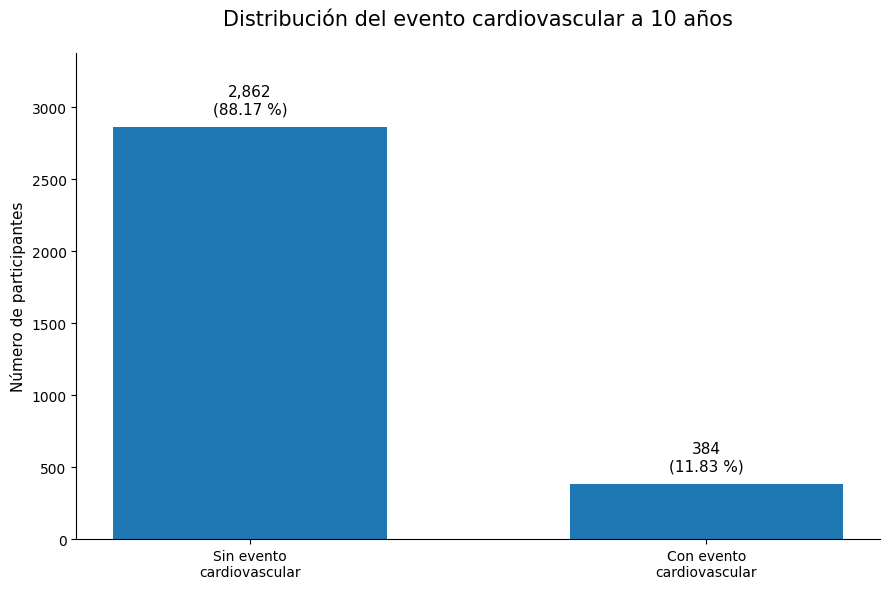

In [766]:
import matplotlib.pyplot as plt

# Etiquetas y valores
categorias = [
    "Sin evento\ncardiovascular",
    "Con evento\ncardiovascular"
]

participantes = [
    distribucion_evento.loc[0],
    distribucion_evento.loc[1]
]

porcentajes = [
    porcentaje_evento.loc[0],
    porcentaje_evento.loc[1]
]


# Creamos una figura más amplia
fig, ax = plt.subplots(figsize=(9, 6))

barras = ax.bar(
    categorias,
    participantes,
    width=0.6
)


# Título y eje vertical
ax.set_title(
    "Distribución del evento cardiovascular a 10 años",
    fontsize=15,
    pad=20
)

ax.set_ylabel(
    "Número de participantes",
    fontsize=11
)


# Dejamos espacio por encima de la barra más alta
ax.set_ylim(
    0,
    max(participantes) * 1.18
)


# Añadimos las etiquetas encima de las barras
for barra, numero, porcentaje in zip(
    barras,
    participantes,
    porcentajes
):
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + max(participantes) * 0.025,
        f"{numero:,}\n({porcentaje:.2f} %)",
        ha="center",
        va="bottom",
        fontsize=11
    )


# Simplificamos el diseño
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)

plt.tight_layout()
plt.show()

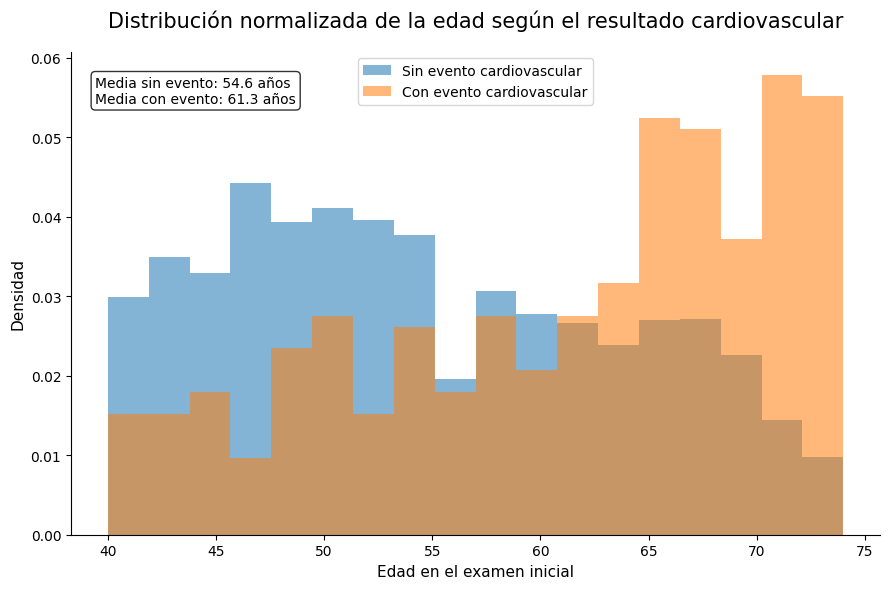

In [767]:
# Separamos las edades según el resultado observado

edad_sin_evento = datos_eda.loc[
    datos_eda["EVENTO_CV_10_ANIOS"] == 0,
    "EDAD"
]

edad_con_evento = datos_eda.loc[
    datos_eda["EVENTO_CV_10_ANIOS"] == 1,
    "EDAD"
]


fig, ax = plt.subplots(figsize=(9, 6))

# density=True transforma las frecuencias en distribuciones comparables

ax.hist(
    edad_sin_evento,
    bins=18,
    density=True,
    alpha=0.55,
    label="Sin evento cardiovascular"
)

ax.hist(
    edad_con_evento,
    bins=18,
    density=True,
    alpha=0.55,
    label="Con evento cardiovascular"
)


ax.set_title(
    "Distribución normalizada de la edad según el resultado cardiovascular",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Edad en el examen inicial",
    fontsize=11
)

ax.set_ylabel(
    "Densidad",
    fontsize=11
)


# Mostramos las medias mediante texto para evitar líneas confusas

texto_medias = (
    f"Media sin evento: {edad_sin_evento.mean():.1f} años\n"
    f"Media con evento: {edad_con_evento.mean():.1f} años"
)

ax.text(
    0.03,
    0.95,
    texto_medias,
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

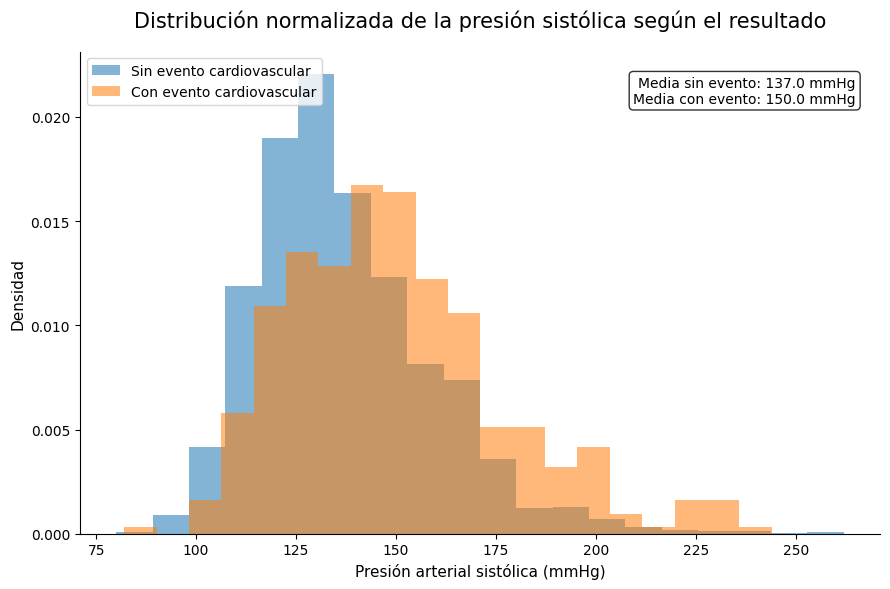

In [768]:
# Separamos la presión sistólica según el resultado observado

presion_sin_evento = datos_eda.loc[
    datos_eda["EVENTO_CV_10_ANIOS"] == 0,
    "PRESION_SISTOLICA"
]

presion_con_evento = datos_eda.loc[
    datos_eda["EVENTO_CV_10_ANIOS"] == 1,
    "PRESION_SISTOLICA"
]


fig, ax = plt.subplots(figsize=(9, 6))

# Usamos densidad para comparar grupos de tamaños diferentes

ax.hist(
    presion_sin_evento,
    bins=20,
    density=True,
    alpha=0.55,
    label="Sin evento cardiovascular"
)

ax.hist(
    presion_con_evento,
    bins=20,
    density=True,
    alpha=0.55,
    label="Con evento cardiovascular"
)


ax.set_title(
    "Distribución normalizada de la presión sistólica según el resultado",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Presión arterial sistólica (mmHg)",
    fontsize=11
)

ax.set_ylabel(
    "Densidad",
    fontsize=11
)


# Resumen de las medias

texto_medias = (
    f"Media sin evento: {presion_sin_evento.mean():.1f} mmHg\n"
    f"Media con evento: {presion_con_evento.mean():.1f} mmHg"
)

ax.text(
    0.97,
    0.95,
    texto_medias,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)


ax.legend(
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

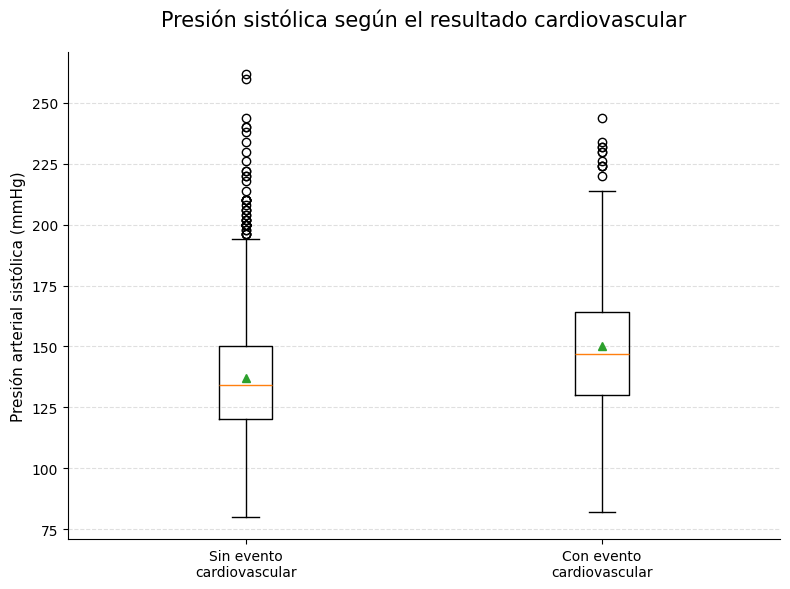

In [769]:
# Preparamos los dos grupos que queremos comparar

datos_boxplot_presion = [
    presion_sin_evento,
    presion_con_evento
]

etiquetas_presion = [
    "Sin evento\ncardiovascular",
    "Con evento\ncardiovascular"
]


# Creamos el diagrama de caja

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    datos_boxplot_presion,
    tick_labels=etiquetas_presion,
    showmeans=True
)


# Añadimos el título y la etiqueta del eje vertical

ax.set_title(
    "Presión sistólica según el resultado cardiovascular",
    fontsize=15,
    pad=18
)

ax.set_ylabel(
    "Presión arterial sistólica (mmHg)",
    fontsize=11
)


# Añadimos una cuadrícula horizontal suave
# para facilitar la comparación de los valores

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# Eliminamos los bordes superior y derecho

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Ajustamos el tamaño de las etiquetas

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)


# Ajustamos automáticamente los márgenes

plt.tight_layout()

plt.show()

In [770]:
def calcular_atipicos_iqr(serie):
    """
    Calcula los posibles valores atípicos de una variable
    mediante el criterio de 1,5 veces el rango intercuartílico.
    """

    # Primer y tercer cuartil
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    # Rango intercuartílico
    iqr = q3 - q1

    # Límites utilizados por el boxplot
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Identificamos los valores fuera de esos límites
    mascara_atipicos = (
        (serie < limite_inferior)
        | (serie > limite_superior)
    )

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Número de atípicos": mascara_atipicos.sum(),
        "Porcentaje de atípicos": (
            mascara_atipicos.mean() * 100
        )
    }


# Aplicamos la función a los dos grupos

atipicos_presion_sin_evento = calcular_atipicos_iqr(
    presion_sin_evento
)

atipicos_presion_con_evento = calcular_atipicos_iqr(
    presion_con_evento
)


# Construimos una tabla comparativa

tabla_atipicos_presion = pd.DataFrame(
    [
        atipicos_presion_sin_evento,
        atipicos_presion_con_evento
    ],
    index=[
        "Sin evento cardiovascular",
        "Con evento cardiovascular"
    ]
).round(2)


print("Análisis de posibles valores atípicos de presión sistólica:")

display(tabla_atipicos_presion)

Análisis de posibles valores atípicos de presión sistólica:


,Q1,Q3,IQR,Límite inferior,Límite superior,Número de atípicos,Porcentaje de atípicos
Sin evento cardiovascular,120.0,150.0,30.0,75.0,195.0,46,1.61
Con evento cardiovascular,130.0,164.0,34.0,79.0,215.0,11,2.86


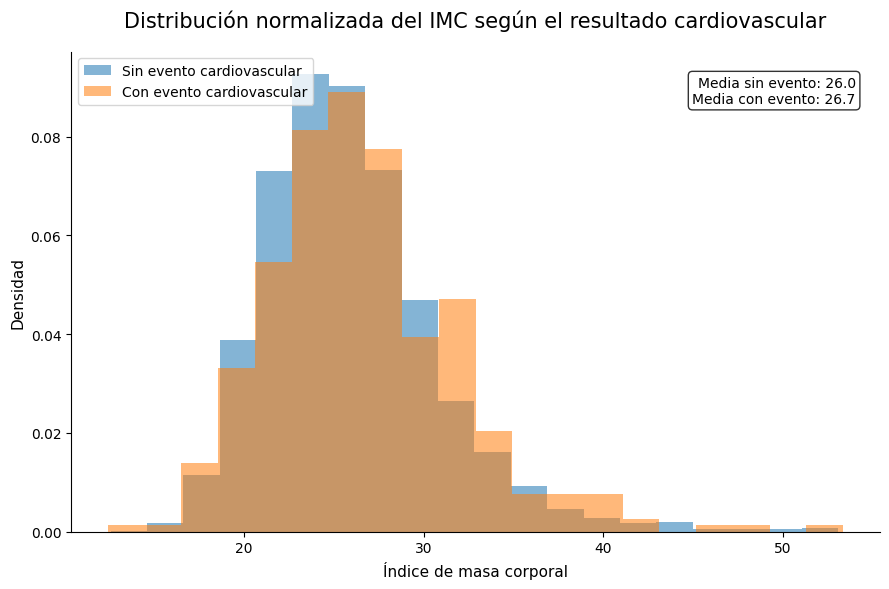

In [771]:
# Separamos el IMC según el resultado cardiovascular

imc_sin_evento = datos_eda.loc[
    datos_eda["EVENTO_CV_10_ANIOS"] == 0,
    "IMC"
]

imc_con_evento = datos_eda.loc[
    datos_eda["EVENTO_CV_10_ANIOS"] == 1,
    "IMC"
]


# Creamos histogramas normalizados para poder comparar
# correctamente grupos de distinto tamaño

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    imc_sin_evento,
    bins=20,
    density=True,
    alpha=0.55,
    label="Sin evento cardiovascular"
)

ax.hist(
    imc_con_evento,
    bins=20,
    density=True,
    alpha=0.55,
    label="Con evento cardiovascular"
)


# Título y nombres de los ejes

ax.set_title(
    "Distribución normalizada del IMC según el resultado cardiovascular",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Índice de masa corporal",
    fontsize=11
)

ax.set_ylabel(
    "Densidad",
    fontsize=11
)


# Mostramos las medias de ambos grupos

texto_medias = (
    f"Media sin evento: {imc_sin_evento.mean():.1f}\n"
    f"Media con evento: {imc_con_evento.mean():.1f}"
)

ax.text(
    0.97,
    0.95,
    texto_medias,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)


ax.legend(
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

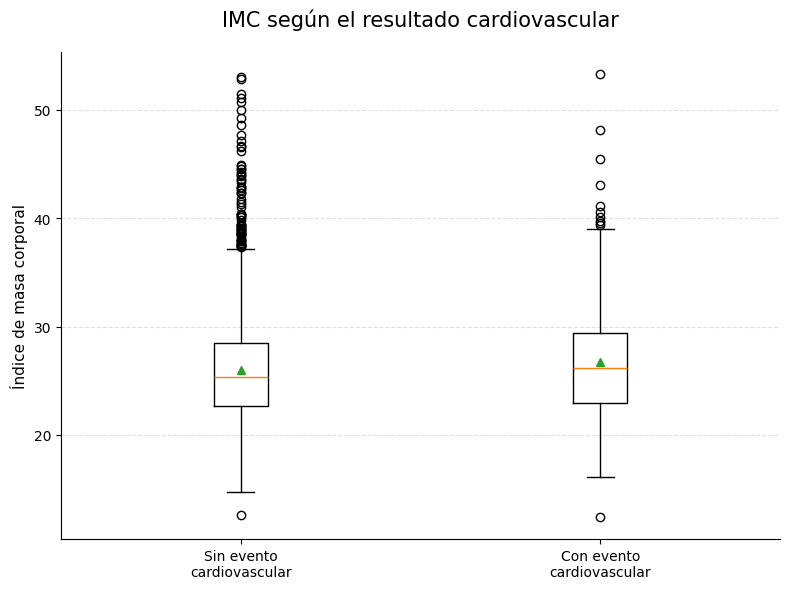

In [772]:
# Preparamos los dos grupos

datos_boxplot_imc = [
    imc_sin_evento,
    imc_con_evento
]

etiquetas_imc = [
    "Sin evento\ncardiovascular",
    "Con evento\ncardiovascular"
]


# Creamos el diagrama de caja

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    datos_boxplot_imc,
    tick_labels=etiquetas_imc,
    showmeans=True
)


# Título y etiqueta del eje vertical

ax.set_title(
    "IMC según el resultado cardiovascular",
    fontsize=15,
    pad=18
)

ax.set_ylabel(
    "Índice de masa corporal",
    fontsize=11
)


# Cuadrícula horizontal para facilitar la lectura

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# Simplificamos el diseño

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)


plt.tight_layout()
plt.show()

In [773]:
# Aplicamos el criterio del rango intercuartílico
# a los dos grupos de IMC

atipicos_imc_sin_evento = calcular_atipicos_iqr(
    imc_sin_evento
)

atipicos_imc_con_evento = calcular_atipicos_iqr(
    imc_con_evento
)


# Construimos una tabla comparativa

tabla_atipicos_imc = pd.DataFrame(
    [
        atipicos_imc_sin_evento,
        atipicos_imc_con_evento
    ],
    index=[
        "Sin evento cardiovascular",
        "Con evento cardiovascular"
    ]
).round(2)


print("Análisis de posibles valores atípicos del IMC:")

display(tabla_atipicos_imc)

Análisis de posibles valores atípicos del IMC:


,Q1,Q3,IQR,Límite inferior,Límite superior,Número de atípicos,Porcentaje de atípicos
Sin evento cardiovascular,22.65,28.48,5.82,13.92,37.21,73,2.55
Con evento cardiovascular,22.91,29.39,6.48,13.19,39.11,11,2.86


In [774]:
# Recuperamos peso y altura para poder interpretar
# correctamente los valores extremos del IMC

datos_revision_imc = datos_eda.merge(
    muestra_elegible_estricta[
        [
            "SEQNUM",
            "PESO_KG",
            "ALTURA_CM"
        ]
    ],
    on="SEQNUM",
    how="left",
    validate="one_to_one"
)


# Ordenamos los participantes de menor a mayor IMC

datos_revision_imc = datos_revision_imc.sort_values(
    by="IMC"
)


print("Diez participantes con menor IMC:")

display(
    datos_revision_imc[
        [
            "SEQNUM",
            "PESO_KG",
            "ALTURA_CM",
            "IMC",
            "EDAD",
            "EVENTO_CV_10_ANIOS"
        ]
    ].head(10).round(2)
)


print("\nDiez participantes con mayor IMC:")

display(
    datos_revision_imc[
        [
            "SEQNUM",
            "PESO_KG",
            "ALTURA_CM",
            "IMC",
            "EDAD",
            "EVENTO_CV_10_ANIOS"
        ]
    ].tail(10).sort_values(
        by="IMC",
        ascending=False
    ).round(2)
)

Diez participantes con menor IMC:


,SEQNUM,PESO_KG,ALTURA_CM,IMC,EDAD,EVENTO_CV_10_ANIOS
1307,14099,32.43,161.6,12.42,46,1
109,01112,41.05,180.7,12.57,56,0
114,01124,39.58,163.9,14.73,63,0
1131,12261,38.9,160.8,15.04,67,0
1112,11882,48.31,177.3,15.37,57,0
2952,24050,47.74,176.2,15.38,46,0
1801,19152,43.54,166.6,15.69,47,0
1071,11361,45.36,168.5,15.98,69,0
2056,21063,48.08,172.8,16.1,62,1
682,07327,39.8,155.9,16.38,53,0



Diez participantes con mayor IMC:


,SEQNUM,PESO_KG,ALTURA_CM,IMC,EDAD,EVENTO_CV_10_ANIOS
1096,11846,145.26,165.0,53.36,57,1
147,01511,129.84,156.4,53.08,68,0
723,07685,125.53,154.1,52.86,45,0
1113,11885,132.34,160.3,51.5,40,0
687,07341,134.94,162.5,51.1,61,0
2210,21465,134.26,162.7,50.72,59,0
2440,22305,136.3,165.1,50.0,57,0
773,08158,135.06,165.6,49.25,60,0
1108,11874,138.8,169.0,48.6,55,0
1368,15039,126.44,162.1,48.12,51,1


In [775]:
# =========================================================
# Tasa de eventos según el sexo
# =========================================================

resumen_sexo = (
    datos_eda
    .groupby("HOMBRE")
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EVENTOS=("EVENTO_CV_10_ANIOS", "sum"),
        TASA_EVENTO=("EVENTO_CV_10_ANIOS", "mean")
    )
    .reset_index()
)

resumen_sexo["SEXO"] = (
    resumen_sexo["HOMBRE"]
    .map({
        0: "Mujer",
        1: "Hombre"
    })
)

resumen_sexo["TASA_EVENTO_PCT"] = (
    resumen_sexo["TASA_EVENTO"]
    .mul(100)
    .round(2)
)


print("Eventos cardiovasculares según el sexo:")

display(
    resumen_sexo[
        [
            "SEXO",
            "PARTICIPANTES",
            "EVENTOS",
            "TASA_EVENTO_PCT"
        ]
    ]
)


# =========================================================
# Tasa de eventos según el tabaquismo
# =========================================================

resumen_tabaquismo = (
    datos_eda
    .groupby("FUMADOR_ACTUAL")
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EVENTOS=("EVENTO_CV_10_ANIOS", "sum"),
        TASA_EVENTO=("EVENTO_CV_10_ANIOS", "mean")
    )
    .reset_index()
)

resumen_tabaquismo["TABAQUISMO"] = (
    resumen_tabaquismo["FUMADOR_ACTUAL"]
    .map({
        0: "No fumador actual",
        1: "Fumador actual"
    })
)

resumen_tabaquismo["TASA_EVENTO_PCT"] = (
    resumen_tabaquismo["TASA_EVENTO"]
    .mul(100)
    .round(2)
)


print("\nEventos cardiovasculares según el tabaquismo:")

display(
    resumen_tabaquismo[
        [
            "TABAQUISMO",
            "PARTICIPANTES",
            "EVENTOS",
            "TASA_EVENTO_PCT"
        ]
    ]
)

Eventos cardiovasculares según el sexo:


,SEXO,PARTICIPANTES,EVENTOS,TASA_EVENTO_PCT
0,Mujer,1769,144,8.14
1,Hombre,1477,240,16.25



Eventos cardiovasculares según el tabaquismo:


,TABAQUISMO,PARTICIPANTES,EVENTOS,TASA_EVENTO_PCT
0,No fumador actual,2156,222,10.30
1,Fumador actual,1090,162,14.86


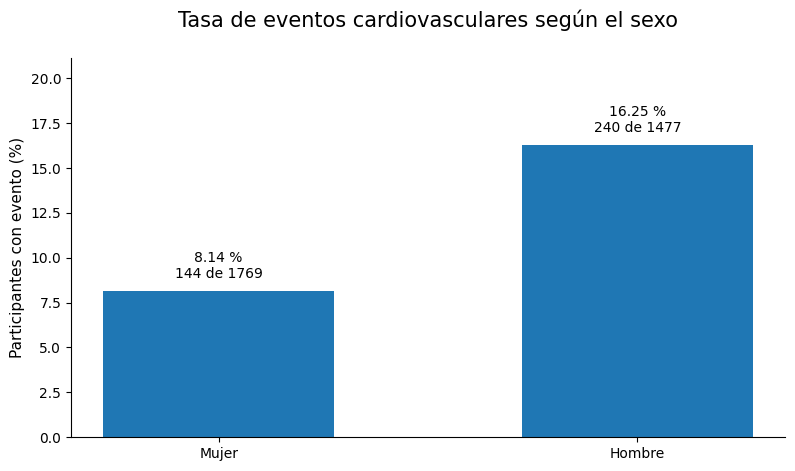

In [776]:
# Tasa de eventos cardiovasculares según el sexo

fig, ax = plt.subplots(figsize=(8.5, 5.5))

barras_sexo = ax.bar(
    resumen_sexo["SEXO"],
    resumen_sexo["TASA_EVENTO_PCT"],
    width=0.55
)

ax.set_title(
    "Tasa de eventos cardiovasculares según el sexo",
    fontsize=15,
    pad=22
)

ax.set_ylabel(
    "Participantes con evento (%)",
    fontsize=11
)

# Espacio suficiente sobre las barras
altura_maxima = resumen_sexo["TASA_EVENTO_PCT"].max()
ax.set_ylim(0, altura_maxima * 1.30)

# Etiquetas sobre las barras
for barra, porcentaje, eventos, participantes in zip(
    barras_sexo,
    resumen_sexo["TASA_EVENTO_PCT"],
    resumen_sexo["EVENTOS"],
    resumen_sexo["PARTICIPANTES"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + altura_maxima * 0.035,
        f"{porcentaje:.2f} %\n{eventos} de {participantes}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

fig.subplots_adjust(
    top=0.84,
    bottom=0.15,
    left=0.13,
    right=0.97
)

plt.show()

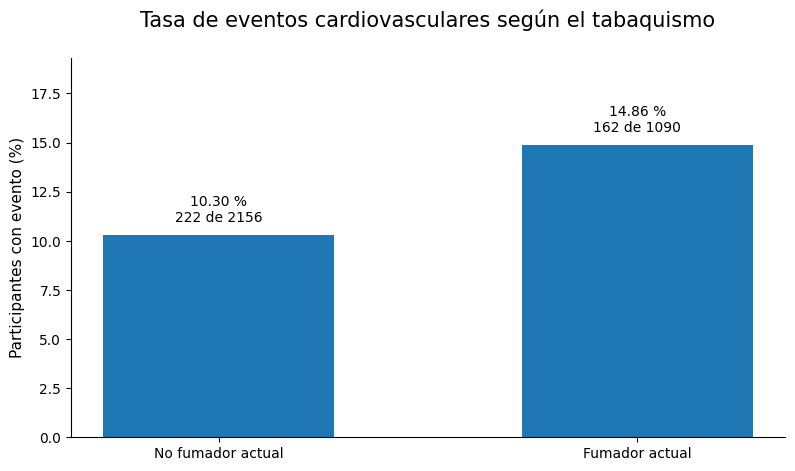

In [777]:
# Tasa de eventos cardiovasculares según el tabaquismo

fig, ax = plt.subplots(figsize=(8.5, 5.5))

barras_tabaco = ax.bar(
    resumen_tabaquismo["TABAQUISMO"],
    resumen_tabaquismo["TASA_EVENTO_PCT"],
    width=0.55
)

ax.set_title(
    "Tasa de eventos cardiovasculares según el tabaquismo",
    fontsize=15,
    pad=22
)

ax.set_ylabel(
    "Participantes con evento (%)",
    fontsize=11
)

# Espacio suficiente sobre las barras
altura_maxima = resumen_tabaquismo["TASA_EVENTO_PCT"].max()
ax.set_ylim(0, altura_maxima * 1.30)

# Etiquetas sobre las barras
for barra, porcentaje, eventos, participantes in zip(
    barras_tabaco,
    resumen_tabaquismo["TASA_EVENTO_PCT"],
    resumen_tabaquismo["EVENTOS"],
    resumen_tabaquismo["PARTICIPANTES"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + altura_maxima * 0.035,
        f"{porcentaje:.2f} %\n{eventos} de {participantes}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

fig.subplots_adjust(
    top=0.84,
    bottom=0.15,
    left=0.13,
    right=0.97
)

plt.show()

In [778]:
# Seleccionamos las variables numéricas y binarias
# que utilizaremos en los modelos

variables_correlacion = [
    "EDAD",
    "HOMBRE",
    "FUMADOR_ACTUAL",
    "PRESION_SISTOLICA",
    "IMC",
    "EVENTO_CV_10_ANIOS"
]


# Calculamos la matriz de correlaciones

matriz_correlacion = (
    datos_eda[variables_correlacion]
    .astype(float)
    .corr()
)


print("Matriz de correlaciones:")

display(
    matriz_correlacion.round(2)
)

Matriz de correlaciones:


,EDAD,HOMBRE,FUMADOR_ACTUAL,PRESION_SISTOLICA,IMC,EVENTO_CV_10_ANIOS
EDAD,1.00,-0.01,-0.21,0.34,0.07,0.23
HOMBRE,-0.01,1.00,0.11,0.00,-0.01,0.13
FUMADOR_ACTUAL,-0.21,0.11,1.00,-0.11,-0.13,0.07
PRESION_SISTOLICA,0.34,0.00,-0.11,1.00,0.26,0.18
IMC,0.07,-0.01,-0.13,0.26,1.00,0.05
EVENTO_CV_10_ANIOS,0.23,0.13,0.07,0.18,0.05,1.00


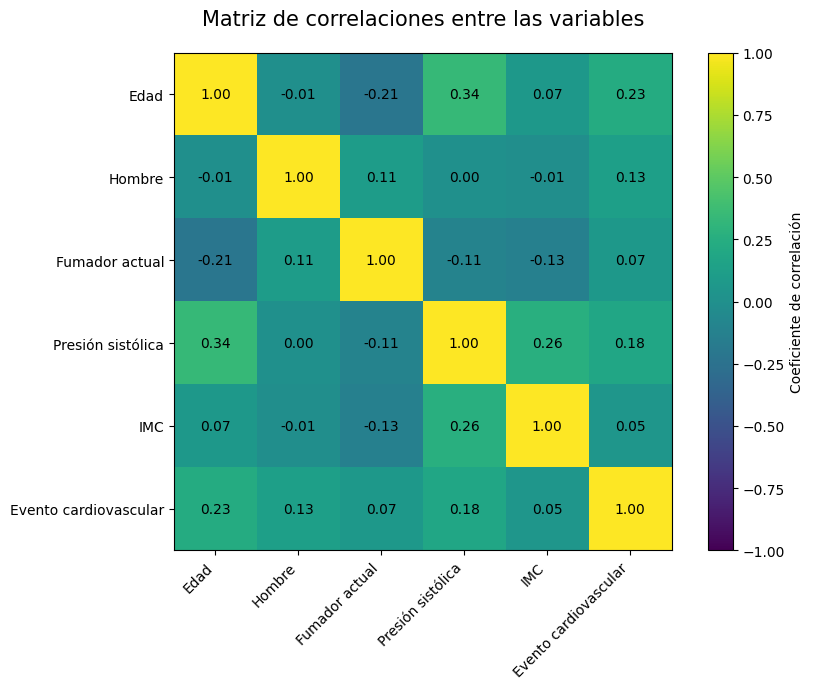

In [779]:
# Creamos una representación visual de la matriz de correlaciones

fig, ax = plt.subplots(figsize=(10, 7))

imagen = ax.imshow(
    matriz_correlacion,
    vmin=-1,
    vmax=1
)


# Nombres más claros para el gráfico

etiquetas_correlacion = [
    "Edad",
    "Hombre",
    "Fumador actual",
    "Presión sistólica",
    "IMC",
    "Evento cardiovascular"
]


ax.set_xticks(
    range(len(etiquetas_correlacion)),
    labels=etiquetas_correlacion,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(etiquetas_correlacion)),
    labels=etiquetas_correlacion
)


# Escribimos los coeficientes dentro de cada celda

for fila in range(len(etiquetas_correlacion)):
    for columna in range(len(etiquetas_correlacion)):

        valor = matriz_correlacion.iloc[fila, columna]

        ax.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )


ax.set_title(
    "Matriz de correlaciones entre las variables",
    fontsize=15,
    pad=20
)


barra = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

barra.set_label(
    "Coeficiente de correlación",
    fontsize=10
)


plt.tight_layout()
plt.show()

In [780]:
# Creamos intervalos de edad de cinco años

intervalos_edad = [
    40,
    45,
    50,
    55,
    60,
    65,
    70,
    75
]

etiquetas_edad = [
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-64",
    "65-69",
    "70-74"
]


# Creamos una nueva variable categórica
# sin modificar el dataset original de modelización

datos_eda["GRUPO_EDAD"] = pd.cut(
    datos_eda["EDAD"],
    bins=intervalos_edad,
    labels=etiquetas_edad,
    right=False,
    include_lowest=True
)


# Calculamos participantes, eventos y tasa de eventos

resumen_grupos_edad = (
    datos_eda
    .groupby(
        "GRUPO_EDAD",
        observed=False
    )
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EVENTOS=("EVENTO_CV_10_ANIOS", "sum"),
        TASA_EVENTO=("EVENTO_CV_10_ANIOS", "mean")
    )
    .reset_index()
)


# Convertimos la tasa a porcentaje

resumen_grupos_edad["TASA_EVENTO_PCT"] = (
    resumen_grupos_edad["TASA_EVENTO"]
    .mul(100)
    .round(2)
)


print("Tasa de eventos cardiovasculares por grupo de edad:")

display(
    resumen_grupos_edad[
        [
            "GRUPO_EDAD",
            "PARTICIPANTES",
            "EVENTOS",
            "TASA_EVENTO_PCT"
        ]
    ]
)

Tasa de eventos cardiovasculares por grupo de edad:


,GRUPO_EDAD,PARTICIPANTES,EVENTOS,TASA_EVENTO_PCT
0,40-44,458,27,5.90
1,45-49,582,32,5.50
2,50-54,583,39,6.69
3,55-59,507,53,10.45
4,60-64,386,49,12.69
5,65-69,450,89,19.78
6,70-74,280,95,33.93


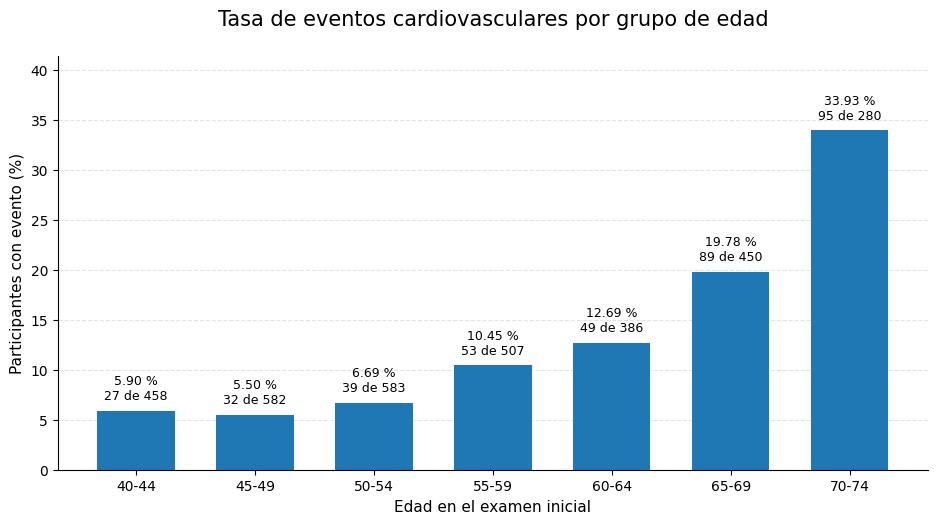

In [781]:
# Gráfico de la tasa de eventos cardiovasculares
# por intervalos de edad

fig, ax = plt.subplots(figsize=(10, 6))

barras_edad = ax.bar(
    resumen_grupos_edad["GRUPO_EDAD"].astype(str),
    resumen_grupos_edad["TASA_EVENTO_PCT"],
    width=0.65
)


# Título y ejes

ax.set_title(
    "Tasa de eventos cardiovasculares por grupo de edad",
    fontsize=15,
    pad=22
)

ax.set_xlabel(
    "Edad en el examen inicial",
    fontsize=11
)

ax.set_ylabel(
    "Participantes con evento (%)",
    fontsize=11
)


# Dejamos espacio por encima de la barra más alta

altura_maxima = resumen_grupos_edad["TASA_EVENTO_PCT"].max()

ax.set_ylim(
    0,
    altura_maxima * 1.22
)


# Añadimos la tasa, el número de eventos
# y el tamaño de cada grupo

for barra, porcentaje, eventos, participantes in zip(
    barras_edad,
    resumen_grupos_edad["TASA_EVENTO_PCT"],
    resumen_grupos_edad["EVENTOS"],
    resumen_grupos_edad["PARTICIPANTES"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + altura_maxima * 0.025,
        (
            f"{porcentaje:.2f} %\n"
            f"{eventos} de {participantes}"
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )


# Cuadrícula horizontal suave

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)


# Simplificamos los bordes

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)


fig.subplots_adjust(
    top=0.84,
    bottom=0.15,
    left=0.11,
    right=0.98
)

plt.show()

In [782]:
# Creamos intervalos descriptivos de presión sistólica

intervalos_presion = [
    80,
    120,
    140,
    160,
    180,
    300
]

etiquetas_presion = [
    "Menos de 120",
    "120-139",
    "140-159",
    "160-179",
    "180 o más"
]


# Creamos la variable categórica

datos_eda["GRUPO_PRESION"] = pd.cut(
    datos_eda["PRESION_SISTOLICA"],
    bins=intervalos_presion,
    labels=etiquetas_presion,
    right=False,
    include_lowest=True
)


# Calculamos el tamaño, el número de eventos
# y la tasa de eventos de cada grupo

resumen_grupos_presion = (
    datos_eda
    .groupby(
        "GRUPO_PRESION",
        observed=False
    )
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EVENTOS=("EVENTO_CV_10_ANIOS", "sum"),
        TASA_EVENTO=("EVENTO_CV_10_ANIOS", "mean")
    )
    .reset_index()
)


# Convertimos la tasa en porcentaje

resumen_grupos_presion["TASA_EVENTO_PCT"] = (
    resumen_grupos_presion["TASA_EVENTO"]
    .mul(100)
    .round(2)
)


print("Tasa de eventos cardiovasculares por presión sistólica:")

display(
    resumen_grupos_presion[
        [
            "GRUPO_PRESION",
            "PARTICIPANTES",
            "EVENTOS",
            "TASA_EVENTO_PCT"
        ]
    ]
)

Tasa de eventos cardiovasculares por presión sistólica:


,GRUPO_PRESION,PARTICIPANTES,EVENTOS,TASA_EVENTO_PCT
0,Menos de 120,591,39,6.60
1,120-139,1249,101,8.09
2,140-159,806,117,14.52
3,160-179,408,73,17.89
4,180 o más,192,54,28.12


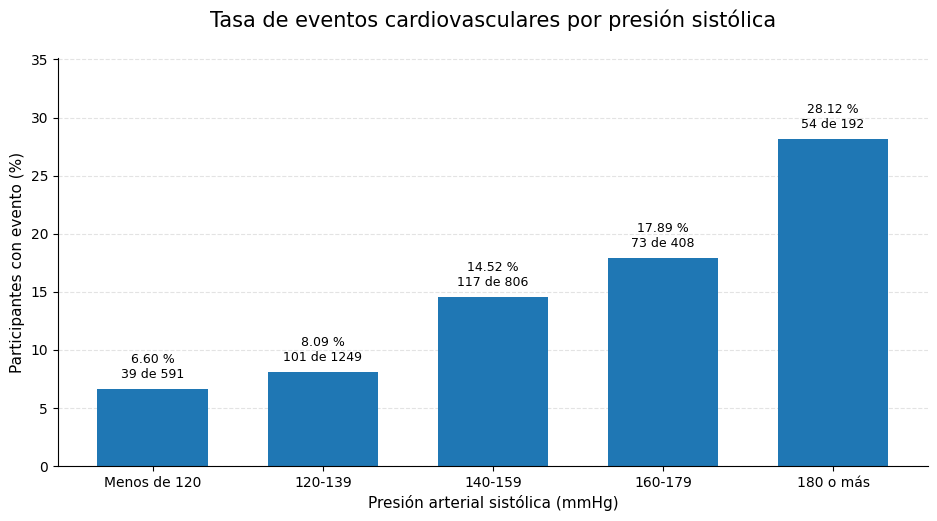

In [783]:
# Gráfico de la tasa de eventos cardiovasculares
# según el intervalo de presión sistólica

fig, ax = plt.subplots(figsize=(10, 6))

barras_presion = ax.bar(
    resumen_grupos_presion["GRUPO_PRESION"].astype(str),
    resumen_grupos_presion["TASA_EVENTO_PCT"],
    width=0.65
)


# Título y nombres de los ejes

ax.set_title(
    "Tasa de eventos cardiovasculares por presión sistólica",
    fontsize=15,
    pad=22
)

ax.set_xlabel(
    "Presión arterial sistólica (mmHg)",
    fontsize=11
)

ax.set_ylabel(
    "Participantes con evento (%)",
    fontsize=11
)


# Dejamos espacio sobre la barra más alta

altura_maxima = resumen_grupos_presion[
    "TASA_EVENTO_PCT"
].max()

ax.set_ylim(
    0,
    altura_maxima * 1.25
)


# Añadimos la tasa, los eventos y el tamaño del grupo

for barra, porcentaje, eventos, participantes in zip(
    barras_presion,
    resumen_grupos_presion["TASA_EVENTO_PCT"],
    resumen_grupos_presion["EVENTOS"],
    resumen_grupos_presion["PARTICIPANTES"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + altura_maxima * 0.025,
        (
            f"{porcentaje:.2f} %\n"
            f"{eventos} de {participantes}"
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )


# Cuadrícula horizontal suave

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)


# Simplificamos el diseño

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)


fig.subplots_adjust(
    top=0.84,
    bottom=0.16,
    left=0.11,
    right=0.98
)

plt.show()

In [784]:
# Creamos intervalos descriptivos de IMC

intervalos_imc = [
    0,
    18.5,
    25,
    30,
    35,
    40,
    float("inf")
]

etiquetas_imc = [
    "Menos de 18,5",
    "18,5-24,9",
    "25,0-29,9",
    "30,0-34,9",
    "35,0-39,9",
    "40 o más"
]


# Creamos una variable categórica de IMC

datos_eda["GRUPO_IMC"] = pd.cut(
    datos_eda["IMC"],
    bins=intervalos_imc,
    labels=etiquetas_imc,
    right=False,
    include_lowest=True
)


# Calculamos el número de participantes,
# el número de eventos y la tasa de cada grupo

resumen_grupos_imc = (
    datos_eda
    .groupby(
        "GRUPO_IMC",
        observed=False
    )
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EVENTOS=("EVENTO_CV_10_ANIOS", "sum"),
        TASA_EVENTO=("EVENTO_CV_10_ANIOS", "mean")
    )
    .reset_index()
)


# Transformamos la tasa en porcentaje

resumen_grupos_imc["TASA_EVENTO_PCT"] = (
    resumen_grupos_imc["TASA_EVENTO"]
    .mul(100)
    .round(2)
)


print("Tasa de eventos cardiovasculares por categoría de IMC:")

display(
    resumen_grupos_imc[
        [
            "GRUPO_IMC",
            "PARTICIPANTES",
            "EVENTOS",
            "TASA_EVENTO_PCT"
        ]
    ]
)

Tasa de eventos cardiovasculares por categoría de IMC:


,GRUPO_IMC,PARTICIPANTES,EVENTOS,TASA_EVENTO_PCT
0,"Menos de 18,5",83,13,15.66
1,"18,5-24,9",1396,138,9.89
2,"25,0-29,9",1204,146,12.13
3,"30,0-34,9",411,64,15.57
4,"35,0-39,9",105,16,15.24
5,40 o más,47,7,14.89


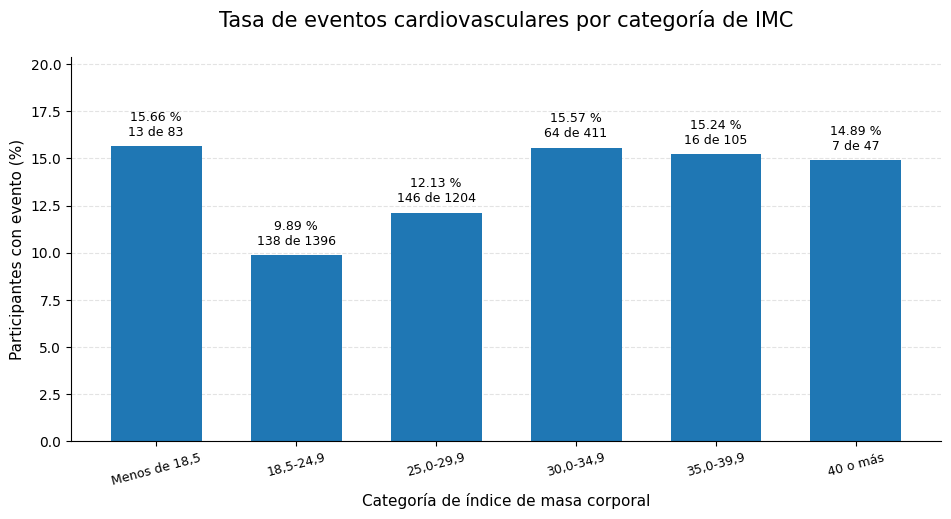

In [785]:
# Gráfico de la tasa de eventos cardiovasculares
# según la categoría de IMC

fig, ax = plt.subplots(figsize=(10, 6))

barras_imc = ax.bar(
    resumen_grupos_imc["GRUPO_IMC"].astype(str),
    resumen_grupos_imc["TASA_EVENTO_PCT"],
    width=0.65
)


# Título y nombres de los ejes

ax.set_title(
    "Tasa de eventos cardiovasculares por categoría de IMC",
    fontsize=15,
    pad=22
)

ax.set_xlabel(
    "Categoría de índice de masa corporal",
    fontsize=11
)

ax.set_ylabel(
    "Participantes con evento (%)",
    fontsize=11
)


# Dejamos espacio sobre las barras

altura_maxima = resumen_grupos_imc[
    "TASA_EVENTO_PCT"
].max()

ax.set_ylim(
    0,
    altura_maxima * 1.30
)


# Añadimos tasa, eventos y tamaño del grupo

for barra, porcentaje, eventos, participantes in zip(
    barras_imc,
    resumen_grupos_imc["TASA_EVENTO_PCT"],
    resumen_grupos_imc["EVENTOS"],
    resumen_grupos_imc["PARTICIPANTES"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + altura_maxima * 0.025,
        (
            f"{porcentaje:.2f} %\n"
            f"{eventos} de {participantes}"
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )


# Cuadrícula horizontal

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)


# Simplificamos los bordes

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelsize=9,
    rotation=15
)

ax.tick_params(
    axis="y",
    labelsize=10
)


fig.subplots_adjust(
    top=0.84,
    bottom=0.20,
    left=0.11,
    right=0.98
)

plt.show()

In [786]:
# Calculamos la tasa de eventos para cada combinación
# de grupo de edad y grupo de presión sistólica

tabla_eventos_edad_presion = pd.pivot_table(
    datos_eda,
    values="EVENTO_CV_10_ANIOS",
    index="GRUPO_EDAD",
    columns="GRUPO_PRESION",
    aggfunc="mean",
    observed=False
).mul(100).round(2)


# Calculamos también cuántos participantes hay
# en cada combinación

tabla_participantes_edad_presion = pd.pivot_table(
    datos_eda,
    values="SEQNUM",
    index="GRUPO_EDAD",
    columns="GRUPO_PRESION",
    aggfunc="count",
    observed=False
)


print("Tasa de eventos (%) según edad y presión sistólica:")

display(tabla_eventos_edad_presion)


print("\nNúmero de participantes en cada combinación:")

display(tabla_participantes_edad_presion)

Tasa de eventos (%) según edad y presión sistólica:


GRUPO_PRESION,Menos de 120,120-139,140-159,160-179,180 o más
GRUPO_EDAD,,,,,
40-44,3.03,6.53,7.25,19.05,0.00
45-49,7.30,2.94,7.89,7.50,10.53
50-54,2.59,5.08,8.84,10.53,18.52
55-59,4.94,8.24,13.97,7.32,34.62
60-64,14.58,7.97,14.41,15.79,20.00
65-69,13.79,15.38,19.15,26.09,26.67
70-74,40.00,25.32,33.33,35.59,45.65



Número de participantes en cada combinación:


GRUPO_PRESION,Menos de 120,120-139,140-159,160-179,180 o más
GRUPO_EDAD,,,,,
40-44,165,199,69,21,4
45-49,137,272,114,40,19
50-54,116,236,147,57,27
55-59,81,182,136,82,26
60-64,48,138,118,57,25
65-69,29,143,141,92,45
70-74,15,79,81,59,46


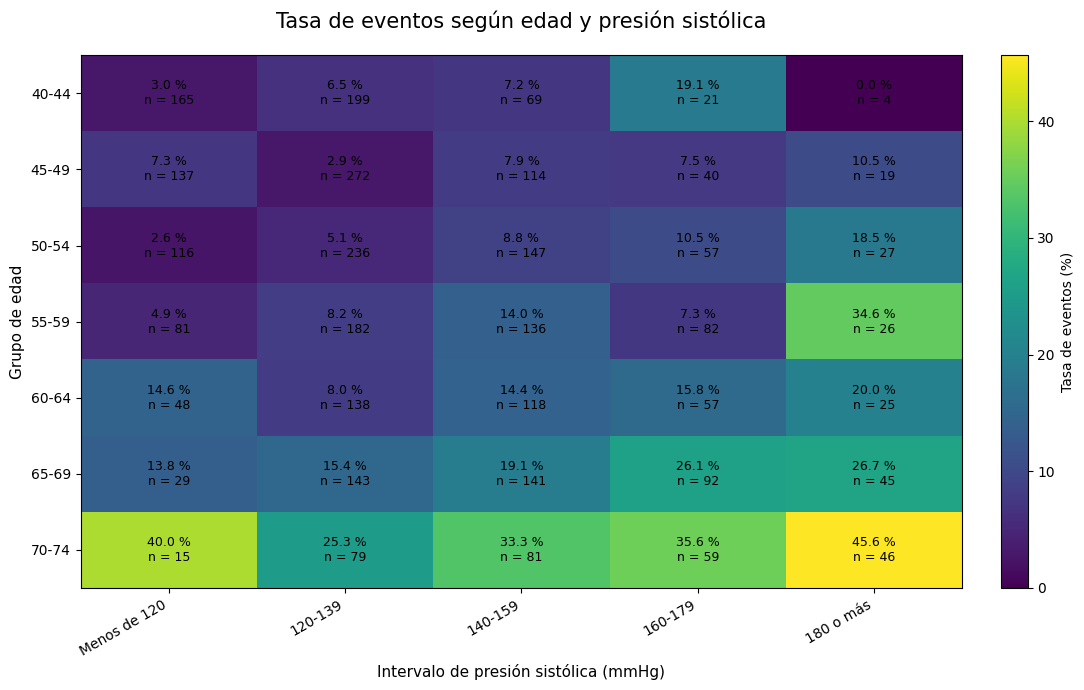

In [787]:
# Preparamos las matrices en formato numérico

matriz_tasas = tabla_eventos_edad_presion.to_numpy(
    dtype=float
)

matriz_tamanos = tabla_participantes_edad_presion.to_numpy(
    dtype=float
)


# Creamos el mapa de calor

fig, ax = plt.subplots(figsize=(11, 7))

imagen = ax.imshow(
    matriz_tasas,
    aspect="auto"
)


# Etiquetas de los ejes

ax.set_xticks(
    range(len(tabla_eventos_edad_presion.columns)),
    labels=tabla_eventos_edad_presion.columns.astype(str),
    rotation=30,
    ha="right"
)

ax.set_yticks(
    range(len(tabla_eventos_edad_presion.index)),
    labels=tabla_eventos_edad_presion.index.astype(str)
)


ax.set_title(
    "Tasa de eventos según edad y presión sistólica",
    fontsize=15,
    pad=20
)

ax.set_xlabel(
    "Intervalo de presión sistólica (mmHg)",
    fontsize=11
)

ax.set_ylabel(
    "Grupo de edad",
    fontsize=11
)


# Escribimos la tasa y el tamaño del grupo en cada celda

for fila in range(matriz_tasas.shape[0]):

    for columna in range(matriz_tasas.shape[1]):

        tasa = matriz_tasas[fila, columna]
        participantes = matriz_tamanos[fila, columna]

        if pd.notna(tasa):

            texto = (
                f"{tasa:.1f} %\n"
                f"n = {int(participantes)}"
            )

            ax.text(
                columna,
                fila,
                texto,
                ha="center",
                va="center",
                fontsize=9
            )


# Barra lateral con la escala de porcentajes

barra = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

barra.set_label(
    "Tasa de eventos (%)",
    fontsize=10
)


plt.tight_layout()
plt.show()

In [788]:
# Creamos una etiqueta combinando sexo y tabaquismo

mapa_grupos = {
    (0, 0): "Mujer no fumadora",
    (0, 1): "Mujer fumadora",
    (1, 0): "Hombre no fumador",
    (1, 1): "Hombre fumador"
}

datos_eda["GRUPO_SEXO_TABACO"] = [
    mapa_grupos[(hombre, fumador)]
    for hombre, fumador in zip(
        datos_eda["HOMBRE"],
        datos_eda["FUMADOR_ACTUAL"]
    )
]


# Calculamos participantes, eventos, tasa y edad media

resumen_sexo_tabaco = (
    datos_eda
    .groupby("GRUPO_SEXO_TABACO")
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EVENTOS=("EVENTO_CV_10_ANIOS", "sum"),
        TASA_EVENTO=("EVENTO_CV_10_ANIOS", "mean"),
        EDAD_MEDIA=("EDAD", "mean"),
        PRESION_MEDIA=("PRESION_SISTOLICA", "mean")
    )
    .reset_index()
)


# Convertimos la tasa en porcentaje

resumen_sexo_tabaco["TASA_EVENTO_PCT"] = (
    resumen_sexo_tabaco["TASA_EVENTO"]
    .mul(100)
    .round(2)
)


# Ordenamos los grupos de forma lógica

orden_grupos = [
    "Mujer no fumadora",
    "Mujer fumadora",
    "Hombre no fumador",
    "Hombre fumador"
]

resumen_sexo_tabaco["GRUPO_SEXO_TABACO"] = pd.Categorical(
    resumen_sexo_tabaco["GRUPO_SEXO_TABACO"],
    categories=orden_grupos,
    ordered=True
)

resumen_sexo_tabaco = resumen_sexo_tabaco.sort_values(
    "GRUPO_SEXO_TABACO"
)


print("Eventos según la combinación de sexo y tabaquismo:")

display(
    resumen_sexo_tabaco[
        [
            "GRUPO_SEXO_TABACO",
            "PARTICIPANTES",
            "EVENTOS",
            "TASA_EVENTO_PCT",
            "EDAD_MEDIA",
            "PRESION_MEDIA"
        ]
    ].round(2)
)

Eventos según la combinación de sexo y tabaquismo:


,GRUPO_SEXO_TABACO,PARTICIPANTES,EVENTOS,TASA_EVENTO_PCT,EDAD_MEDIA,PRESION_MEDIA
3,Mujer no fumadora,1258,96,7.63,56.78,140.64
2,Mujer fumadora,511,48,9.39,52.25,133.06
1,Hombre no fumador,898,126,14.03,56.90,139.76
0,Hombre fumador,579,114,19.69,52.92,136.78


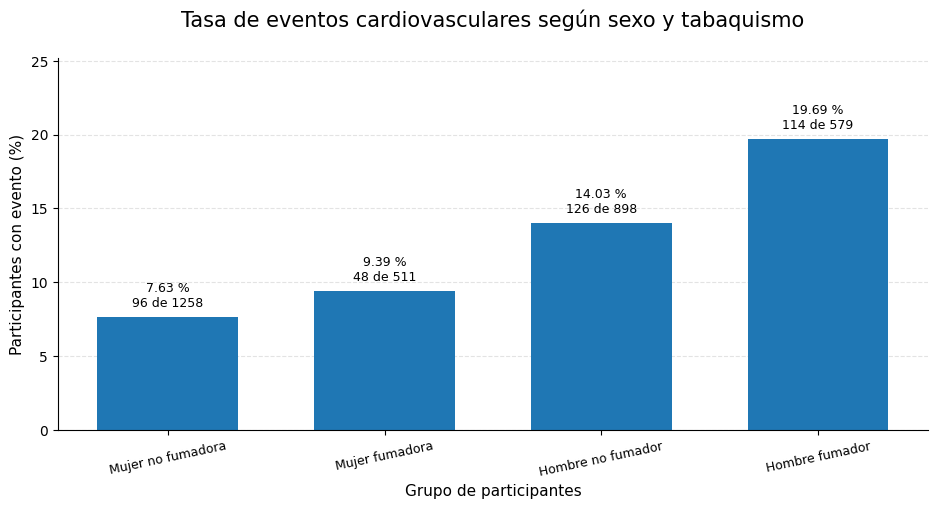

In [789]:
# Gráfico de la tasa de eventos según sexo y tabaquismo

fig, ax = plt.subplots(figsize=(10, 6))

barras_sexo_tabaco = ax.bar(
    resumen_sexo_tabaco["GRUPO_SEXO_TABACO"].astype(str),
    resumen_sexo_tabaco["TASA_EVENTO_PCT"],
    width=0.65
)


# Título y ejes

ax.set_title(
    "Tasa de eventos cardiovasculares según sexo y tabaquismo",
    fontsize=15,
    pad=22
)

ax.set_xlabel(
    "Grupo de participantes",
    fontsize=11
)

ax.set_ylabel(
    "Participantes con evento (%)",
    fontsize=11
)


# Dejamos espacio por encima de las barras

altura_maxima = resumen_sexo_tabaco[
    "TASA_EVENTO_PCT"
].max()

ax.set_ylim(
    0,
    altura_maxima * 1.28
)


# Añadimos tasa, eventos y número de participantes

for barra, porcentaje, eventos, participantes in zip(
    barras_sexo_tabaco,
    resumen_sexo_tabaco["TASA_EVENTO_PCT"],
    resumen_sexo_tabaco["EVENTOS"],
    resumen_sexo_tabaco["PARTICIPANTES"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + altura_maxima * 0.025,
        (
            f"{porcentaje:.2f} %\n"
            f"{eventos} de {participantes}"
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )


# Cuadrícula horizontal

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)


# Simplificamos el diseño

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelsize=9,
    rotation=12
)

ax.tick_params(
    axis="y",
    labelsize=10
)


fig.subplots_adjust(
    top=0.84,
    bottom=0.22,
    left=0.11,
    right=0.98
)

plt.show()

In [790]:
# =========================================================
# 1. Resumen descriptivo según el resultado cardiovascular
# =========================================================

resumen_final_eda = (
    datos_eda
    .groupby("EVENTO_CV_10_ANIOS")
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        EDAD_MEDIA=("EDAD", "mean"),
        EDAD_MEDIANA=("EDAD", "median"),
        PRESION_MEDIA=("PRESION_SISTOLICA", "mean"),
        PRESION_MEDIANA=("PRESION_SISTOLICA", "median"),
        IMC_MEDIO=("IMC", "mean"),
        IMC_MEDIANO=("IMC", "median"),
        PORCENTAJE_HOMBRES=("HOMBRE", "mean"),
        PORCENTAJE_FUMADORES=("FUMADOR_ACTUAL", "mean")
    )
    .reset_index()
)


# Convertimos las proporciones en porcentajes

resumen_final_eda["PORCENTAJE_HOMBRES"] = (
    resumen_final_eda["PORCENTAJE_HOMBRES"]
    .mul(100)
)

resumen_final_eda["PORCENTAJE_FUMADORES"] = (
    resumen_final_eda["PORCENTAJE_FUMADORES"]
    .mul(100)
)


# Sustituimos los códigos 0 y 1 por etiquetas descriptivas

resumen_final_eda["RESULTADO"] = (
    resumen_final_eda["EVENTO_CV_10_ANIOS"]
    .map({
        0: "Sin evento cardiovascular",
        1: "Con evento cardiovascular"
    })
)


print("Resumen final según el resultado cardiovascular:")

display(
    resumen_final_eda[
        [
            "RESULTADO",
            "PARTICIPANTES",
            "EDAD_MEDIA",
            "EDAD_MEDIANA",
            "PRESION_MEDIA",
            "PRESION_MEDIANA",
            "IMC_MEDIO",
            "IMC_MEDIANO",
            "PORCENTAJE_HOMBRES",
            "PORCENTAJE_FUMADORES"
        ]
    ].round(2)
)


# =========================================================
# 2. Comprobación del dataset original de modelización
# =========================================================

print("\nComprobación del dataset de modelización:")

print("\nDimensiones:")
print(datos_modelado.shape)

print("\nColumnas:")
print(datos_modelado.columns.tolist())

print("\nValores ausentes:")
print(datos_modelado.isna().sum())

print("\nParticipantes duplicados:")
print(datos_modelado["SEQNUM"].duplicated().sum())

print("\nDistribución de la variable objetivo:")
print(
    datos_modelado["EVENTO_CV_10_ANIOS"]
    .value_counts()
    .sort_index()
)


# =========================================================
# 3. Variables auxiliares creadas solo para el EDA
# =========================================================

variables_auxiliares_eda = [
    columna
    for columna in datos_eda.columns
    if columna not in datos_modelado.columns
]

print("\nVariables auxiliares creadas únicamente para el EDA:")

print(variables_auxiliares_eda)

Resumen final según el resultado cardiovascular:


,RESULTADO,PARTICIPANTES,EDAD_MEDIA,EDAD_MEDIANA,PRESION_MEDIA,PRESION_MEDIANA,IMC_MEDIO,IMC_MEDIANO,PORCENTAJE_HOMBRES,PORCENTAJE_FUMADORES
0,Sin evento cardiovascular,2862,54.63,54.0,136.97,134.0,25.96,25.37,43.22,32.42
1,Con evento cardiovascular,384,61.26,64.0,150.02,147.0,26.7,26.21,62.5,42.19



Comprobación del dataset de modelización:

Dimensiones:
(3246, 7)

Columnas:
['SEQNUM', 'EDAD', 'HOMBRE', 'FUMADOR_ACTUAL', 'PRESION_SISTOLICA', 'IMC', 'EVENTO_CV_10_ANIOS']

Valores ausentes:
SEQNUM                0
EDAD                  0
HOMBRE                0
FUMADOR_ACTUAL        0
PRESION_SISTOLICA     0
IMC                   0
EVENTO_CV_10_ANIOS    0
dtype: int64

Participantes duplicados:
0

Distribución de la variable objetivo:
EVENTO_CV_10_ANIOS
0    2862
1     384
Name: count, dtype: int64

Variables auxiliares creadas únicamente para el EDA:
['GRUPO_EDAD', 'GRUPO_PRESION', 'GRUPO_IMC', 'GRUPO_SEXO_TABACO']


## Fase 3 — Análisis exploratorio de datos

### 1. Objetivo de la fase

El objetivo del análisis exploratorio fue comprender las características de la muestra antes de dividir los datos y entrenar los modelos.

Durante esta fase se analizaron:

- La distribución de la variable objetivo.
- La edad.
- La presión arterial sistólica.
- El índice de masa corporal.
- El sexo.
- El tabaquismo actual.
- Los posibles valores atípicos.
- Las relaciones entre las variables.
- La combinación de diferentes factores de riesgo.

El análisis realizado es descriptivo. Las diferencias observadas no implican causalidad ni permiten conocer todavía la importancia independiente de cada variable.

---

### 2. Dataset analizado

La muestra final provisional contiene:

- **3.246 participantes únicos**.
- **2.862 participantes sin evento cardiovascular**.
- **384 participantes con evento cardiovascular durante los siguientes diez años**.

La tasa global de eventos es del:

- **11,83 %** para la clase positiva.
- **88,17 %** para la clase negativa.

El conjunto de datos no contiene:

- Valores ausentes.
- Identificadores duplicados.
- Filas repetidas.

Las variables disponibles son:

- Edad.
- Sexo.
- Tabaquismo actual.
- Presión arterial sistólica.
- Índice de masa corporal.
- Evento cardiovascular a diez años.

---

### 3. Desbalanceo de la variable objetivo

La clase positiva es claramente minoritaria:

- 2.862 personas no sufrieron el evento.
- 384 personas sí lo sufrieron.

Esto representa un problema de clasificación desbalanceada.

Un modelo que predijera siempre que no ocurrirá el evento obtendría una accuracy aproximada del 88 %, pero no identificaría correctamente a ninguna persona con evento cardiovascular.

Por este motivo, la comparación de modelos no se basará únicamente en la accuracy.

Se utilizarán también:

- Sensibilidad o recall.
- Especificidad.
- Precision.
- F1-score.
- ROC-AUC.
- Brier score.
- Curvas de calibración.
- Matriz de confusión.

---

### 4. Edad

La edad mostró la asociación descriptiva más clara con el evento cardiovascular.

Resultados medios:

- Sin evento: **54,63 años**.
- Con evento: **61,26 años**.

La tasa de eventos aumentó especialmente en los grupos de mayor edad:

- 40–44 años: 5,90 %.
- 45–49 años: 5,50 %.
- 50–54 años: 6,69 %.
- 55–59 años: 10,45 %.
- 60–64 años: 12,69 %.
- 65–69 años: 19,78 %.
- 70–74 años: 33,93 %.

En el grupo de 70 a 74 años, aproximadamente una de cada tres personas sufrió un evento cardiovascular durante los siguientes diez años.

La correlación entre edad y evento fue de aproximadamente `0,23`, la mayor entre las variables analizadas.

---

### 5. Presión arterial sistólica

La presión sistólica también mostró una relación clara con el resultado futuro.

Valores medios:

- Sin evento: **136,97 mmHg**.
- Con evento: **150,02 mmHg**.

La tasa de eventos aumentó progresivamente con la presión sistólica:

- Menos de 120 mmHg: 6,60 %.
- 120–139 mmHg: 8,09 %.
- 140–159 mmHg: 14,52 %.
- 160–179 mmHg: 17,89 %.
- 180 mmHg o más: 28,12 %.

La correlación entre presión sistólica y evento fue de aproximadamente `0,18`.

La presión sistólica también estaba moderadamente relacionada con:

- La edad: correlación aproximada de `0,34`.
- El IMC: correlación aproximada de `0,26`.

---

### 6. Índice de masa corporal

La relación entre IMC y evento cardiovascular fue más débil e irregular.

Valores medios:

- Sin evento: **25,96**.
- Con evento: **26,70**.

Tasas de eventos por categoría:

- Menos de 18,5: 15,66 %.
- 18,5–24,9: 9,89 %.
- 25,0–29,9: 12,13 %.
- 30,0–34,9: 15,57 %.
- 35,0–39,9: 15,24 %.
- 40 o más: 14,89 %.

La tasa aumentó entre el intervalo de peso normal y la obesidad moderada, pero no continuó creciendo de manera uniforme en las categorías superiores.

Los grupos extremos contenían pocos participantes, por lo que sus tasas son menos estables.

La correlación lineal entre IMC y evento fue baja, aproximadamente `0,05`. Esto no implica necesariamente que el IMC sea inútil, ya que su relación podría ser no lineal o depender de otros factores.

---

### 7. Sexo

Las tasas de eventos fueron:

- Mujeres: **8,14 %**.
- Hombres: **16,25 %**.

La tasa observada entre los hombres fue aproximadamente el doble que entre las mujeres.

La correlación entre ser hombre y el evento cardiovascular fue de aproximadamente `0,13`.

Esta diferencia es descriptiva y todavía no tiene en cuenta simultáneamente la edad, la presión arterial, el tabaquismo y el IMC.

---

### 8. Tabaquismo actual

Las tasas de eventos fueron:

- No fumadores actuales: **10,30 %**.
- Fumadores actuales: **14,86 %**.

Los fumadores presentaron una tasa superior de eventos cardiovasculares.

La correlación lineal entre tabaquismo y evento fue aproximadamente `0,07`.

Aunque este valor es relativamente pequeño, el tabaquismo podría aportar información predictiva cuando se combine con las demás variables.

---

### 9. Combinación de sexo y tabaquismo

Las tasas de eventos fueron:

- Mujer no fumadora: 7,63 %.
- Mujer fumadora: 9,39 %.
- Hombre no fumador: 14,03 %.
- Hombre fumador: 19,69 %.

El grupo de hombres fumadores presentó la tasa más alta.

Los participantes fumadores eran, de media, más jóvenes y tenían una presión algo menor que los no fumadores de su mismo sexo. A pesar de ello, presentaban una tasa superior de eventos.

Este resultado sugiere que el tabaquismo puede aportar información adicional, aunque será necesario confirmarlo mediante un modelo multivariable.

---

### 10. Combinación de edad y presión sistólica

Se analizó conjuntamente la tasa de eventos por intervalos de edad y presión sistólica.

Las tasas más elevadas aparecieron generalmente en participantes de mayor edad y presión más alta.

Algunos ejemplos fueron:

- 70–74 años y presión de 160–179 mmHg: 35,59 %.
- 70–74 años y presión de 180 mmHg o más: 45,65 %.
- 65–69 años y presión de 180 mmHg o más: 26,67 %.

Algunas combinaciones contenían pocos participantes. Por tanto, las tasas extremas calculadas sobre grupos pequeños deben interpretarse con prudencia.

Este análisis muestra que el riesgo cardiovascular no depende de una única variable, sino de la combinación de varios factores.

---

### 11. Correlaciones entre predictores

Las correlaciones con el evento cardiovascular fueron aproximadamente:

- Edad: `0,23`.
- Presión sistólica: `0,18`.
- Hombre: `0,13`.
- Fumador actual: `0,07`.
- IMC: `0,05`.

No se encontraron correlaciones extremadamente elevadas entre las variables predictoras.

La mayor correlación entre predictores fue la existente entre edad y presión sistólica, con un valor aproximado de `0,34`.

Por tanto, no se observa inicialmente un problema grave de multicolinealidad.

La matriz de correlaciones solo representa relaciones lineales. Una correlación baja no descarta relaciones no lineales o interacciones entre variables.

---

### 12. Valores atípicos

Se utilizó el criterio de 1,5 veces el rango intercuartílico para identificar posibles valores atípicos.

#### Presión sistólica

- Sin evento: 46 valores atípicos, equivalentes al 1,61 %.
- Con evento: 11 valores atípicos, equivalentes al 2,86 %.

#### IMC

- Sin evento: 73 valores atípicos, equivalentes al 2,55 %.
- Con evento: 11 valores atípicos, equivalentes al 2,86 %.

Se revisaron específicamente los pesos, alturas e IMC más extremos.

No se encontraron errores evidentes de cálculo ni valores incompatibles con las mediciones originales.

Los valores extremos se conservarán porque:

- Son pocos.
- Pueden representar situaciones clínicas reales.
- Están dentro de los rangos válidos del conjunto de datos.
- Su eliminación podría excluir participantes de especial interés cardiovascular.

Posteriormente podrá realizarse un análisis de sensibilidad para comprobar si afectan de manera importante a los resultados.

---

### 13. Principales conclusiones del análisis exploratorio

Las variables con patrones descriptivos más claros fueron:

1. Edad.
2. Presión arterial sistólica.
3. Sexo.
4. Tabaquismo actual.

El IMC mostró una relación más débil y posiblemente no lineal.

Los participantes que sufrieron un evento cardiovascular presentaban, en promedio:

- Mayor edad.
- Mayor presión sistólica.
- Un IMC ligeramente superior.
- Mayor proporción de hombres.
- Mayor proporción de fumadores actuales.

La edad y la presión mostraron un aumento claro de la tasa de eventos al analizarse por intervalos.

---

### 14. Limitaciones del análisis exploratorio

Las asociaciones encontradas son descriptivas.

No permiten afirmar que:

- Una variable sea causa directa del evento.
- Una variable sea predictiva de forma independiente.
- Las diferencias observadas no estén influidas por otros factores.
- Los intervalos utilizados representen reglas clínicas definitivas.

La importancia ajustada de cada variable se estudiará posteriormente mediante la regresión logística y los métodos de interpretabilidad del modelo Gradient Boosting.

---

### 15. Integridad del dataset de modelización

Las variables auxiliares utilizadas para crear gráficos y tablas se almacenaron únicamente en `datos_eda`:

- `GRUPO_EDAD`.
- `GRUPO_PRESION`.
- `GRUPO_IMC`.
- `GRUPO_SEXO_TABACO`.

El dataset original `datos_modelado` permanece intacto y contiene:

- 3.246 filas.
- 7 columnas.
- Ningún valor ausente.
- Ningún participante duplicado.
- 384 eventos positivos.

---

### 16. Resultado de la fase

El análisis exploratorio confirma que los datos presentan patrones clínicamente coherentes y que las variables seleccionadas contienen información potencialmente útil para estimar el riesgo cardiovascular.

La siguiente fase consistirá en:

- Separar predictores y variable objetivo.
- Crear los conjuntos de entrenamiento y prueba.
- Mantener la proporción de eventos mediante estratificación.
- Evitar cualquier fuga de información.
- Definir el procedimiento de validación.
- Preparar una comparación justa entre WHO 2019, regresión logística y Gradient Boosting.

In [791]:
# =========================================================
# 1. Definimos las variables predictoras
# =========================================================

columnas_predictoras = [
    "EDAD",
    "HOMBRE",
    "FUMADOR_ACTUAL",
    "PRESION_SISTOLICA",
    "IMC"
]


# X contiene la información que utilizarán los modelos
# para realizar las predicciones

X = datos_modelado[
    columnas_predictoras
].copy()


# y contiene la variable que queremos predecir:
# 0 = no sufrió el evento cardiovascular
# 1 = sí sufrió el evento cardiovascular

y = datos_modelado[
    "EVENTO_CV_10_ANIOS"
].copy()


# Conservamos el identificador por separado para mantener
# la trazabilidad, pero no se utilizará como predictor

ids = datos_modelado[
    "SEQNUM"
].copy()


# =========================================================
# 2. Comprobaciones iniciales
# =========================================================

print("Dimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

print("\nVariables predictoras:")
print(X.columns.tolist())

print("\nPrimeras filas de X:")
display(X.head())

print("\nDistribución de la variable objetivo:")
print(
    y.value_counts()
    .sort_index()
)

print("\nDistribución porcentual:")
print(
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nValores ausentes en X:")
print(X.isna().sum())

print("\nValores ausentes en y:")
print(y.isna().sum())

Dimensiones de X:
(3246, 5)

Dimensiones de y:
(3246,)

Variables predictoras:
['EDAD', 'HOMBRE', 'FUMADOR_ACTUAL', 'PRESION_SISTOLICA', 'IMC']

Primeras filas de X:


,EDAD,HOMBRE,FUMADOR_ACTUAL,PRESION_SISTOLICA,IMC
55,44,1,1,156.0,28.201265
56,42,1,1,140.0,26.046575
57,70,0,0,182.0,28.596805
58,68,1,0,142.0,22.73539
59,47,0,0,122.0,23.863837



Distribución de la variable objetivo:
EVENTO_CV_10_ANIOS
0    2862
1     384
Name: count, dtype: int64

Distribución porcentual:
EVENTO_CV_10_ANIOS
0    88.17
1    11.83
Name: proportion, dtype: float64

Valores ausentes en X:
EDAD                 0
HOMBRE               0
FUMADOR_ACTUAL       0
PRESION_SISTOLICA    0
IMC                  0
dtype: int64

Valores ausentes en y:
0


In [792]:
from sklearn.model_selection import train_test_split


# Dividimos simultáneamente:
# - las variables predictoras;
# - la variable objetivo;
# - los identificadores de los participantes.

(
    X_train,
    X_test,
    y_train,
    y_test,
    ids_train,
    ids_test
) = train_test_split(
    X,
    y,
    ids,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# =========================================================
# Comprobamos el tamaño de cada conjunto
# =========================================================

print("Dimensiones del conjunto de entrenamiento:")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("ids_train:", ids_train.shape)


print("\nDimensiones del conjunto de prueba:")

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("ids_test:", ids_test.shape)


# =========================================================
# Revisamos la distribución de las clases
# =========================================================

def resumir_distribucion_clases(serie):
    """
    Devuelve el número y el porcentaje de participantes
    pertenecientes a cada clase.
    """

    conteo = (
        serie
        .value_counts()
        .sort_index()
    )

    porcentaje = (
        serie
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    return pd.DataFrame({
        "PARTICIPANTES": conteo,
        "PORCENTAJE": porcentaje
    })


print("\nDistribución en el conjunto de entrenamiento:")

display(
    resumir_distribucion_clases(y_train)
)


print("\nDistribución en el conjunto de prueba:")

display(
    resumir_distribucion_clases(y_test)
)


# =========================================================
# Comprobamos que ningún participante aparezca
# simultáneamente en entrenamiento y prueba
# =========================================================

ids_train_set = set(ids_train)
ids_test_set = set(ids_test)

participantes_compartidos = (
    ids_train_set
    & ids_test_set
)


print("\nParticipantes presentes en ambos conjuntos:")
print(len(participantes_compartidos))


print("\nNúmero total de participantes tras la división:")
print(
    len(X_train) + len(X_test)
)

Dimensiones del conjunto de entrenamiento:
X_train: (2596, 5)
y_train: (2596,)
ids_train: (2596,)

Dimensiones del conjunto de prueba:
X_test: (650, 5)
y_test: (650,)
ids_test: (650,)

Distribución en el conjunto de entrenamiento:


,PARTICIPANTES,PORCENTAJE
EVENTO_CV_10_ANIOS,,
0,2289,88.17
1,307,11.83



Distribución en el conjunto de prueba:


,PARTICIPANTES,PORCENTAJE
EVENTO_CV_10_ANIOS,,
0,573,88.15
1,77,11.85



Participantes presentes en ambos conjuntos:
0

Número total de participantes tras la división:
3246


In [793]:
from sklearn.model_selection import StratifiedKFold


# =========================================================
# 1. Definimos la estrategia de validación cruzada
# =========================================================

validacion_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================================================
# 2. Auditamos la composición de cada partición
# =========================================================

resumen_particiones = []

indices_validacion_totales = []


for numero_fold, (
    indices_entrenamiento,
    indices_validacion
) in enumerate(
    validacion_cruzada.split(
        X_train,
        y_train
    ),
    start=1
):

    # StratifiedKFold devuelve posiciones,
    # por eso utilizamos .iloc

    y_entrenamiento_fold = y_train.iloc[
        indices_entrenamiento
    ]

    y_validacion_fold = y_train.iloc[
        indices_validacion
    ]


    # Guardamos los índices utilizados como validación
    # para comprobar después que cada fila aparece una vez

    indices_validacion_totales.extend(
        indices_validacion
    )


    resumen_particiones.append({
        "FOLD": numero_fold,

        "N_TRAIN": len(y_entrenamiento_fold),
        "POSITIVOS_TRAIN": int(
            y_entrenamiento_fold.sum()
        ),
        "PORCENTAJE_POSITIVOS_TRAIN": round(
            y_entrenamiento_fold.mean() * 100,
            2
        ),

        "N_VALIDACION": len(y_validacion_fold),
        "POSITIVOS_VALIDACION": int(
            y_validacion_fold.sum()
        ),
        "PORCENTAJE_POSITIVOS_VALIDACION": round(
            y_validacion_fold.mean() * 100,
            2
        )
    })


tabla_particiones = pd.DataFrame(
    resumen_particiones
)


print("Composición de las cinco particiones:")

display(tabla_particiones)


# =========================================================
# 3. Comprobaciones de integridad
# =========================================================

print(
    "\nNúmero total de apariciones "
    "en los conjuntos de validación:"
)
print(len(indices_validacion_totales))


print(
    "\nFilas diferentes utilizadas como validación:"
)
print(len(set(indices_validacion_totales)))


print(
    "\nTamaño del conjunto de entrenamiento original:"
)
print(len(X_train))


print(
    "\n¿Cada fila aparece exactamente una vez "
    "como validación?"
)

print(
    len(indices_validacion_totales) == len(X_train)
    and
    len(set(indices_validacion_totales)) == len(X_train)
)

Composición de las cinco particiones:


,FOLD,N_TRAIN,POSITIVOS_TRAIN,PORCENTAJE_POSITIVOS_TRAIN,N_VALIDACION,POSITIVOS_VALIDACION,PORCENTAJE_POSITIVOS_VALIDACION
0,1,2076,245,11.80,520,62,11.92
1,2,2077,246,11.84,519,61,11.75
2,3,2077,246,11.84,519,61,11.75
3,4,2077,246,11.84,519,61,11.75
4,5,2077,245,11.80,519,62,11.95



Número total de apariciones en los conjuntos de validación:
2596

Filas diferentes utilizadas como validación:
2596

Tamaño del conjunto de entrenamiento original:
2596

¿Cada fila aparece exactamente una vez como validación?
True


In [794]:
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier


# =========================================================
# 1. Separamos variables continuas y binarias
# =========================================================

variables_continuas = [
    "EDAD",
    "PRESION_SISTOLICA",
    "IMC"
]

variables_binarias = [
    "HOMBRE",
    "FUMADOR_ACTUAL"
]


# =========================================================
# 2. Preprocesamiento para la regresión logística
# =========================================================
#
# Las variables continuas se estandarizan.
# Las variables binarias permanecen como 0 y 1.

preprocesamiento_logistico = ColumnTransformer(
    transformers=[
        (
            "variables_continuas",
            StandardScaler(),
            variables_continuas
        ),
        (
            "variables_binarias",
            "passthrough",
            variables_binarias
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


# =========================================================
# 3. Pipeline de regresión logística
# =========================================================

pipeline_logistica = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesamiento_logistico
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)


# =========================================================
# 4. Pipeline de Gradient Boosting
# =========================================================
#
# Los árboles no necesitan el mismo escalado que
# la regresión logística, por lo que reciben las
# variables en sus unidades originales.

pipeline_gradient_boosting = Pipeline(
    steps=[
        (
            "modelo",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)


# =========================================================
# 5. Mostramos visualmente los pipelines
# =========================================================

set_config(display="diagram")


print("Pipeline de regresión logística:")

display(pipeline_logistica)


print("\nPipeline de Gradient Boosting:")

display(pipeline_gradient_boosting)


# =========================================================
# 6. Comprobaciones
# =========================================================

print("\nVariables continuas que serán estandarizadas:")
print(variables_continuas)

print("\nVariables binarias que conservarán valores 0 y 1:")
print(variables_binarias)

print("\n¿Se ha entrenado algún modelo?")
print(False)

Pipeline de regresión logística:


Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('variables_continuas',
                                                  StandardScaler(),
                                                  ['EDAD', 'PRESION_SISTOLICA',
                                                   'IMC']),
                                                 ('variables_binarias',
                                                  'passthrough',
                                                  ['HOMBRE',
                                                   'FUMADOR_ACTUAL'])],
                                   verbose_feature_names_out=False)),
                ('modelo', LogisticRegression(max_iter=2000))])


Pipeline de Gradient Boosting:


Pipeline(steps=[('modelo', GradientBoostingClassifier(random_state=42))])


Variables continuas que serán estandarizadas:
['EDAD', 'PRESION_SISTOLICA', 'IMC']

Variables binarias que conservarán valores 0 y 1:
['HOMBRE', 'FUMADOR_ACTUAL']

¿Se ha entrenado algún modelo?
False


In [795]:
from sklearn.metrics import make_scorer, recall_score
from sklearn.metrics import get_scorer_names


# =========================================================
# 1. Creamos una métrica específica para la especificidad
# =========================================================
#
# La especificidad mide la proporción de negativos reales
# que el modelo identifica correctamente.
#
# Es equivalente al recall de la clase negativa.

scorer_especificidad = make_scorer(
    recall_score,
    pos_label=0
)


# =========================================================
# 2. Definimos las métricas que utilizaremos
#    durante la validación cruzada
# =========================================================

metricas_validacion = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "especificidad": scorer_especificidad,
    "brier_negativo": "neg_brier_score"
}


# =========================================================
# 3. Indicamos la métrica principal
# =========================================================
#
# ROC-AUC será la métrica principal para comparar
# inicialmente la capacidad de discriminación.
#
# Las demás métricas también serán necesarias para
# comprender el comportamiento completo del modelo.

metrica_principal = "roc_auc"


# =========================================================
# 4. Comprobamos que las métricas de scikit-learn existen
# =========================================================

scorers_disponibles = get_scorer_names()

metricas_texto = [
    valor
    for valor in metricas_validacion.values()
    if isinstance(valor, str)
]

metricas_no_disponibles = [
    metrica
    for metrica in metricas_texto
    if metrica not in scorers_disponibles
]


print("Métricas definidas para la validación:")

for nombre in metricas_validacion:
    print("-", nombre)


print("\nMétrica principal:")
print(metrica_principal)


print("\nMétricas no disponibles en la instalación actual:")
print(metricas_no_disponibles)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)


print("\n¿Se ha entrenado algún modelo?")
print(False)

Métricas definidas para la validación:
- roc_auc
- recall
- precision
- f1
- accuracy
- balanced_accuracy
- especificidad
- brier_negativo

Métrica principal:
roc_auc

Métricas no disponibles en la instalación actual:
[]

¿Se ha utilizado el conjunto de prueba?
False

¿Se ha entrenado algún modelo?
False


In [796]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import precision_score, f1_score


# =========================================================
# 1. Evitamos advertencias cuando un modelo
#    no predice ningún caso positivo
# =========================================================
#
# El baseline probablemente predecirá siempre la clase 0.
# En ese caso, la precision y el F1 de la clase positiva
# no pueden calcularse mediante su fórmula habitual.
#
# Indicamos que deben tomar el valor 0 sin mostrar avisos.

scorer_precision_segura = make_scorer(
    precision_score,
    zero_division=0
)

scorer_f1_seguro = make_scorer(
    f1_score,
    zero_division=0
)


# Actualizamos estas dos métricas dentro del diccionario

metricas_validacion["precision"] = (
    scorer_precision_segura
)

metricas_validacion["f1"] = (
    scorer_f1_seguro
)


# =========================================================
# 2. Creamos el modelo baseline
# =========================================================
#
# strategy="prior":
# - ignora las variables predictoras;
# - utiliza la proporción de clases del entrenamiento;
# - predice como clase la categoría mayoritaria.

modelo_baseline = DummyClassifier(
    strategy="prior"
)


# =========================================================
# 3. Aplicamos validación cruzada estratificada
#    utilizando únicamente el conjunto de entrenamiento
# =========================================================

resultados_baseline_cv = cross_validate(
    estimator=modelo_baseline,
    X=X_train,
    y=y_train,
    cv=validacion_cruzada,
    scoring=metricas_validacion,
    return_train_score=False,
    n_jobs=-1
)


# =========================================================
# 4. Resumimos las métricas de los cinco folds
# =========================================================

resumen_baseline = []


for nombre_metrica in metricas_validacion:

    valores = resultados_baseline_cv[
        f"test_{nombre_metrica}"
    ].copy()

    nombre_presentacion = nombre_metrica


    # Scikit-learn devuelve el Brier con signo negativo
    # porque internamente trata todas las métricas
    # como valores donde "más alto es mejor".
    #
    # Lo devolvemos a su escala normal:
    # cuanto menor sea el Brier score, mejor.

    if nombre_metrica == "brier_negativo":

        valores = -valores

        nombre_presentacion = "brier_score"


    resumen_baseline.append({
        "METRICA": nombre_presentacion,
        "MEDIA_CV": valores.mean(),
        "DESVIACION_CV": valores.std(),
        "MINIMO": valores.min(),
        "MAXIMO": valores.max()
    })


tabla_baseline_cv = pd.DataFrame(
    resumen_baseline
)


print("Resultados del modelo baseline mediante validación cruzada:")

display(
    tabla_baseline_cv.round(4)
)


# =========================================================
# 5. Comprobaciones
# =========================================================

print("\nNúmero de folds evaluados:")
print(validacion_cruzada.get_n_splits())


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)


print("\nParticipantes empleados:")
print(len(X_train))


print("\nParticipantes reservados para la evaluación final:")
print(len(X_test))

Resultados del modelo baseline mediante validación cruzada:


,METRICA,MEDIA_CV,DESVIACION_CV,MINIMO,MAXIMO
0,roc_auc,0.5000,0.0000,0.5000,0.5000
1,recall,0.0000,0.0000,0.0000,0.0000
2,precision,0.0000,0.0000,0.0000,0.0000
3,f1,0.0000,0.0000,0.0000,0.0000
4,accuracy,0.8817,0.0009,0.8805,0.8825
5,balanced_accuracy,0.5000,0.0000,0.5000,0.5000
6,especificidad,1.0000,0.0000,1.0000,1.0000
7,brier_score,0.1043,0.0007,0.1037,0.1052



Número de folds evaluados:
5

¿Se ha utilizado el conjunto de prueba?
False

Participantes empleados:
2596

Participantes reservados para la evaluación final:
650


## Fase 4 — Preparación de los datos y estrategia de validación

### 1. Objetivo de la fase

El objetivo de esta fase fue preparar una estrategia de entrenamiento y evaluación que permitiera comparar de forma justa:

1. WHO 2019 Cardiovascular Risk Chart.
2. Regresión logística.
3. Gradient Boosting.

Se establecieron procedimientos para:

- Separar predictores y variable objetivo.
- Reservar un conjunto de prueba.
- Mantener la proporción de eventos.
- Aplicar validación cruzada.
- Evitar fugas de información.
- Definir métricas de evaluación.
- Construir un modelo básico de referencia.

---

### 2. Variables predictoras y variable objetivo

Las variables predictoras se almacenaron en `X`:

- Edad.
- Sexo.
- Tabaquismo actual.
- Presión arterial sistólica.
- Índice de masa corporal.

La variable objetivo se almacenó en `y`:

- `0`: no se produjo un evento cardiovascular durante los diez años siguientes.
- `1`: se produjo un evento cardiovascular durante los diez años siguientes.

El identificador anónimo `SEQNUM` se conservó por separado en `ids`.

No se utilizó como predictor, porque no contiene información clínica y podría introducir patrones artificiales.

---

### 3. División entre entrenamiento y prueba

La muestra de 3.246 participantes se dividió mediante una separación estratificada:

- **80 % para entrenamiento**.
- **20 % para prueba**.

Resultados:

#### Conjunto de entrenamiento

- 2.596 participantes.
- 2.289 sin evento.
- 307 con evento.
- Tasa de eventos: 11,83 %.

#### Conjunto de prueba

- 650 participantes.
- 573 sin evento.
- 77 con evento.
- Tasa de eventos: 11,85 %.

La estratificación permitió conservar prácticamente la misma proporción de positivos en ambos conjuntos.

No existen participantes compartidos entre entrenamiento y prueba.

---

### 4. Función del conjunto de prueba

El conjunto de prueba permanecerá reservado hasta la evaluación final.

No se utilizará para:

- Entrenar modelos.
- Elegir hiperparámetros.
- Seleccionar configuraciones.
- Elegir umbrales.
- Decidir transformaciones basándose en sus resultados.

Esta separación permite obtener una estimación más honesta del rendimiento en participantes no utilizados durante el desarrollo de los modelos.

---

### 5. Validación cruzada

Dentro del conjunto de entrenamiento se definió una validación cruzada estratificada de cinco particiones.

En cada iteración:

- Cuatro particiones se utilizarán para entrenar.
- Una partición se utilizará para validar.
- El proceso se repetirá cinco veces.
- Cada participante actuará exactamente una vez como dato de validación.

Cada fold mantuvo una tasa de eventos cercana al 11,8 %.

Se comprobó que los 2.596 participantes del conjunto de entrenamiento aparecieron exactamente una vez en las particiones de validación.

El conjunto de prueba no intervino en este procedimiento.

---

### 6. Pipeline de regresión logística

Para la regresión logística se construyó una `Pipeline` formada por:

1. Preprocesamiento.
2. Modelo de regresión logística.

Las variables continuas que serán estandarizadas son:

- Edad.
- Presión arterial sistólica.
- IMC.

La estandarización transforma los valores utilizando la media y la desviación típica calculadas exclusivamente con los datos de entrenamiento de cada partición.

Las variables binarias permanecen codificadas como `0` y `1`:

- Hombre.
- Fumador actual.

Incluir el escalado dentro de la Pipeline evita que la información de validación o prueba influya en el preprocesamiento.

---

### 7. Pipeline de Gradient Boosting

Gradient Boosting utilizará directamente las cinco variables en sus unidades originales.

No necesita estandarización porque está formado por árboles de decisión, que realizan divisiones mediante puntos de corte.

El modelo se configuró con una semilla fija para garantizar la reproducibilidad.

Todavía no se han seleccionado sus hiperparámetros definitivos.

---

### 8. Modelo WHO 2019

WHO 2019 no necesita entrenamiento, porque es un modelo clínico previamente establecido.

Sus probabilidades se calcularán directamente a partir de:

- Edad.
- Sexo.
- Tabaquismo.
- Presión arterial sistólica.
- IMC.

Se evaluará sobre los mismos participantes del conjunto de prueba que los modelos de machine learning.

---

### 9. Métricas definidas

Se definieron las siguientes métricas:

- ROC-AUC.
- Recall o sensibilidad.
- Especificidad.
- Precision.
- F1-score.
- Accuracy.
- Balanced accuracy.
- Brier score.

La métrica principal para estudiar inicialmente la discriminación será ROC-AUC.

Sin embargo, ningún modelo será elegido utilizando una única métrica.

También será necesario evaluar:

- La capacidad de detectar eventos.
- La capacidad de reconocer negativos.
- El equilibrio entre ambas clases.
- La calidad de las probabilidades.
- La calibración.

---

### 10. Modelo baseline

Se construyó un modelo básico de referencia mediante `DummyClassifier`.

Este modelo:

- Ignora las variables clínicas.
- Utiliza la prevalencia del entrenamiento como probabilidad.
- Predice siempre la clase mayoritaria al aplicar el umbral de 0,5.

Resultados medios en validación cruzada:

- ROC-AUC: 0,50.
- Recall: 0,00.
- Precision: 0,00.
- F1-score: 0,00.
- Accuracy: 0,8817.
- Balanced accuracy: 0,50.
- Especificidad: 1,00.
- Brier score: 0,1043.

---

### 11. Interpretación del baseline

Aunque alcanza aproximadamente un 88 % de accuracy, no identifica ningún evento cardiovascular.

Su elevada accuracy se debe únicamente a que la clase negativa representa aproximadamente el 88 % de la muestra.

Este resultado demuestra que la accuracy aislada puede ser engañosa en problemas desbalanceados.

Los modelos desarrollados posteriormente deberán:

- Superar un ROC-AUC de 0,50.
- Detectar una proporción relevante de eventos.
- Mantener un equilibrio razonable entre sensibilidad y especificidad.
- Obtener un Brier score inferior a 0,1043.
- Producir probabilidades mejor calibradas que una predicción constante.

---

### 12. Prevención de fugas de información

La estrategia establecida evita utilizar información del conjunto de prueba durante el desarrollo.

Además:

- El escalado se realizará dentro de la Pipeline.
- La selección de configuraciones se realizará mediante validación cruzada.
- Los tres enfoques se compararán sobre las mismas personas.
- La evaluación final se realizará una sola vez sobre el conjunto de prueba reservado.

---

### 13. Resultado de la fase

Al finalizar esta fase se dispone de:

- Predictores y objetivo correctamente separados.
- Un conjunto de entrenamiento estratificado.
- Un conjunto de prueba reservado.
- Una validación cruzada estratificada de cinco folds.
- Pipelines reproducibles.
- Métricas de evaluación definidas.
- Un modelo baseline de referencia.
- Una estrategia para evitar fugas de información.

La siguiente fase consistirá en desarrollar y validar los tres enfoques predictivos, comenzando por la regresión logística como modelo estadístico interpretable.

In [797]:
# =========================================================
# 1. Función para convertir los datos a las categorías
#    empleadas por la tabla WHO 2019
# =========================================================

def crear_categorias_who(datos):
    """
    Convierte las cinco variables clínicas originales
    en las categorías utilizadas por la tabla WHO 2019
    no basada en laboratorio.

    La función devuelve una copia y no modifica
    el DataFrame recibido.
    """

    datos_who = datos.copy()


    # -----------------------------------------------------
    # Grupo de edad
    # -----------------------------------------------------

    datos_who["WHO_EDAD"] = pd.cut(
        datos_who["EDAD"],
        bins=[
            40,
            45,
            50,
            55,
            60,
            65,
            70,
            75
        ],
        labels=[
            "40-44",
            "45-49",
            "50-54",
            "55-59",
            "60-64",
            "65-69",
            "70-74"
        ],
        right=False,
        include_lowest=True
    )


    # -----------------------------------------------------
    # Grupo de presión arterial sistólica
    # -----------------------------------------------------

    datos_who["WHO_PRESION"] = pd.cut(
        datos_who["PRESION_SISTOLICA"],
        bins=[
            float("-inf"),
            120,
            140,
            160,
            180,
            float("inf")
        ],
        labels=[
            "<120",
            "120-139",
            "140-159",
            "160-179",
            ">=180"
        ],
        right=False
    )


    # -----------------------------------------------------
    # Grupo de índice de masa corporal
    # -----------------------------------------------------
    #
    # Interpretamos el intervalo mostrado como 30-35
    # en la tabla como 30 hasta menos de 35,
    # porque la siguiente categoría comienza en >=35.

    datos_who["WHO_IMC"] = pd.cut(
        datos_who["IMC"],
        bins=[
            float("-inf"),
            20,
            25,
            30,
            35,
            float("inf")
        ],
        labels=[
            "<20",
            "20-24",
            "25-29",
            "30-<35",
            ">=35"
        ],
        right=False
    )


    # -----------------------------------------------------
    # Sexo
    # -----------------------------------------------------

    datos_who["WHO_SEXO"] = (
        datos_who["HOMBRE"]
        .map({
            1: "Hombre",
            0: "Mujer"
        })
    )


    # -----------------------------------------------------
    # Tabaquismo actual
    # -----------------------------------------------------

    datos_who["WHO_TABACO"] = (
        datos_who["FUMADOR_ACTUAL"]
        .map({
            1: "Fumador",
            0: "No fumador"
        })
    )


    return datos_who

In [798]:
# Aplicamos provisionalmente las categorías al conjunto
# de entrenamiento, sin utilizar todavía el test

X_train_who = crear_categorias_who(
    X_train
)


columnas_categoricas_who = [
    "WHO_EDAD",
    "WHO_PRESION",
    "WHO_IMC",
    "WHO_SEXO",
    "WHO_TABACO"
]


print("Primeros participantes con sus categorías WHO:")

display(
    X_train_who[
        [
            "EDAD",
            "PRESION_SISTOLICA",
            "IMC",
            "HOMBRE",
            "FUMADOR_ACTUAL"
        ]
        + columnas_categoricas_who
    ].head(10)
)


print("\nValores ausentes en las categorías WHO:")

print(
    X_train_who[
        columnas_categoricas_who
    ].isna().sum()
)


print("\nDistribución por grupo de edad:")

print(
    X_train_who["WHO_EDAD"]
    .value_counts()
    .sort_index()
)


print("\nDistribución por grupo de presión sistólica:")

print(
    X_train_who["WHO_PRESION"]
    .value_counts()
    .sort_index()
)


print("\nDistribución por grupo de IMC:")

print(
    X_train_who["WHO_IMC"]
    .value_counts()
    .sort_index()
)


print("\nDistribución por sexo:")

print(
    X_train_who["WHO_SEXO"]
    .value_counts()
)


print("\nDistribución por tabaquismo:")

print(
    X_train_who["WHO_TABACO"]
    .value_counts()
)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

print("\n¿Se ha entrenado algún modelo?")
print(False)

Primeros participantes con sus categorías WHO:


,EDAD,PRESION_SISTOLICA,IMC,HOMBRE,FUMADOR_ACTUAL,WHO_EDAD,WHO_PRESION,WHO_IMC,WHO_SEXO,WHO_TABACO
2674,56,130.0,21.252592,1,0,55-59,120-139,20-24,Hombre,No fumador
1754,41,126.0,25.918328,1,1,40-44,120-139,25-29,Hombre,Fumador
7156,61,116.0,28.031411,1,0,60-64,<120,25-29,Hombre,No fumador
6758,42,118.0,27.237842,1,0,40-44,<120,25-29,Hombre,No fumador
4287,40,96.0,23.243798,0,1,40-44,<120,20-24,Mujer,Fumador
2763,71,144.0,17.197821,0,1,70-74,140-159,<20,Mujer,Fumador
5792,70,150.0,33.577431,1,0,70-74,140-159,30-<35,Hombre,No fumador
6395,64,146.0,20.745122,0,1,60-64,140-159,20-24,Mujer,Fumador
3528,51,124.0,23.821499,0,0,50-54,120-139,20-24,Mujer,No fumador
6700,73,130.0,27.706747,0,0,70-74,120-139,25-29,Mujer,No fumador



Valores ausentes en las categorías WHO:
WHO_EDAD       0
WHO_PRESION    0
WHO_IMC        0
WHO_SEXO       0
WHO_TABACO     0
dtype: int64

Distribución por grupo de edad:
WHO_EDAD
40-44    372
45-49    459
50-54    466
55-59    421
60-64    310
65-69    358
70-74    210
Name: count, dtype: int64

Distribución por grupo de presión sistólica:
WHO_PRESION
<120        466
120-139    1004
140-159     642
160-179     327
>=180       157
Name: count, dtype: int64

Distribución por grupo de IMC:
WHO_IMC
<20        178
20-24     1001
25-29      963
30-<35     331
>=35       123
Name: count, dtype: int64

Distribución por sexo:
WHO_SEXO
Mujer     1418
Hombre    1178
Name: count, dtype: int64

Distribución por tabaquismo:
WHO_TABACO
No fumador    1706
Fumador        890
Name: count, dtype: int64

¿Se ha utilizado el conjunto de prueba?
False

¿Se ha entrenado algún modelo?
False


In [799]:
# =========================================================
# 1. Orden de las categorías dentro de la tabla WHO
# =========================================================

orden_imc_who = [
    "<20",
    "20-24",
    "25-29",
    "30-<35",
    ">=35"
]

# Cada fila oficial contiene 20 valores en este orden:
#
# 1. Hombre no fumador: 5 categorías de IMC
# 2. Hombre fumador:    5 categorías de IMC
# 3. Mujer no fumadora: 5 categorías de IMC
# 4. Mujer fumadora:    5 categorías de IMC


# =========================================================
# 2. Valores oficiales de riesgo para
#    High-income North America
# =========================================================

valores_who_norteamerica = {

    # -----------------------------------------------------
    # Edad 70-74
    # -----------------------------------------------------

    ("70-74", ">=180"): [
        31, 33, 35, 37, 39,
        38, 40, 42, 45, 47,
        25, 26, 27, 28, 29,
        36, 37, 38, 40, 41
    ],

    ("70-74", "160-179"): [
        26, 28, 29, 31, 33,
        32, 34, 36, 38, 40,
        21, 21, 22, 23, 24,
        30, 31, 32, 33, 35
    ],

    ("70-74", "140-159"): [
        22, 23, 25, 26, 28,
        27, 29, 31, 33, 35,
        17, 18, 18, 19, 20,
        25, 26, 27, 28, 29
    ],

    ("70-74", "120-139"): [
        18, 20, 21, 22, 24,
        23, 25, 26, 28, 29,
        14, 15, 15, 16, 16,
        21, 22, 22, 23, 24
    ],

    ("70-74", "<120"): [
        15, 16, 17, 19, 20,
        19, 21, 22, 23, 25,
        11, 12, 12, 13, 13,
        17, 18, 19, 19, 20
    ],


    # -----------------------------------------------------
    # Edad 65-69
    # -----------------------------------------------------

    ("65-69", ">=180"): [
        25, 27, 29, 31, 33,
        33, 35, 37, 40, 43,
        19, 20, 21, 22, 23,
        30, 32, 33, 34, 36
    ],

    ("65-69", "160-179"): [
        20, 22, 24, 25, 27,
        27, 29, 31, 34, 36,
        15, 16, 17, 18, 18,
        25, 26, 27, 28, 29
    ],

    ("65-69", "140-159"): [
        17, 18, 19, 21, 23,
        22, 24, 26, 28, 30,
        12, 13, 13, 14, 15,
        20, 21, 22, 23, 24
    ],

    ("65-69", "120-139"): [
        14, 15, 16, 17, 19,
        18, 20, 22, 23, 25,
        10, 10, 11, 11, 12,
        16, 17, 18, 19, 20
    ],

    ("65-69", "<120"): [
        11, 12, 13, 14, 15,
        15, 16, 18, 19, 21,
        8, 8, 9, 9, 9,
        13, 14, 14, 15, 16
    ],


    # -----------------------------------------------------
    # Edad 60-64
    # -----------------------------------------------------

    ("60-64", ">=180"): [
        20, 21, 23, 25, 28,
        28, 30, 33, 36, 39,
        14, 15, 16, 17, 18,
        25, 27, 28, 29, 31
    ],

    ("60-64", "160-179"): [
        16, 17, 19, 21, 23,
        22, 25, 27, 29, 32,
        11, 12, 12, 13, 14,
        20, 21, 22, 24, 25
    ],

    ("60-64", "140-159"): [
        13, 14, 15, 17, 18,
        18, 20, 22, 24, 26,
        9, 9, 10, 10, 11,
        16, 17, 18, 19, 20
    ],

    ("60-64", "120-139"): [
        10, 11, 12, 13, 15,
        15, 16, 18, 20, 22,
        7, 7, 8, 8, 8,
        12, 13, 14, 15, 16
    ],

    ("60-64", "<120"): [
        8, 9, 10, 11, 12,
        12, 13, 14, 16, 17,
        5, 6, 6, 6, 7,
        10, 10, 11, 12, 12
    ],


    # -----------------------------------------------------
    # Edad 55-59
    # -----------------------------------------------------

    ("55-59", ">=180"): [
        15, 17, 19, 21, 23,
        23, 26, 29, 32, 35,
        11, 12, 12, 13, 14,
        21, 23, 24, 25, 27
    ],

    ("55-59", "160-179"): [
        12, 13, 15, 17, 19,
        19, 21, 23, 26, 28,
        8, 9, 9, 10, 10,
        16, 17, 18, 20, 21
    ],

    ("55-59", "140-159"): [
        9, 10, 12, 13, 15,
        15, 16, 18, 20, 23,
        6, 7, 7, 7, 8,
        13, 13, 14, 15, 16
    ],

    ("55-59", "120-139"): [
        7, 8, 9, 10, 12,
        12, 13, 15, 16, 18,
        5, 5, 5, 6, 6,
        10, 10, 11, 12, 13
    ],

    ("55-59", "<120"): [
        6, 6, 7, 8, 9,
        9, 10, 12, 13, 15,
        4, 4, 4, 4, 5,
        7, 8, 8, 9, 10
    ],


    # -----------------------------------------------------
    # Edad 50-54
    # -----------------------------------------------------

    ("50-54", ">=180"): [
        12, 14, 15, 17, 20,
        20, 22, 25, 28, 32,
        8, 9, 9, 10, 10,
        18, 19, 20, 21, 23
    ],

    ("50-54", "160-179"): [
        9, 10, 12, 13, 15,
        15, 17, 20, 22, 25,
        6, 6, 7, 7, 8,
        13, 14, 15, 16, 17
    ],

    ("50-54", "140-159"): [
        7, 8, 9, 10, 12,
        12, 13, 15, 17, 20,
        4, 5, 5, 5, 6,
        10, 11, 11, 12, 13
    ],

    ("50-54", "120-139"): [
        5, 6, 7, 8, 9,
        9, 10, 12, 14, 16,
        3, 3, 4, 4, 4,
        7, 8, 9, 9, 10
    ],

    ("50-54", "<120"): [
        4, 5, 5, 6, 7,
        7, 8, 9, 11, 12,
        2, 3, 3, 3, 3,
        5, 6, 6, 7, 7
    ],


    # -----------------------------------------------------
    # Edad 45-49
    # -----------------------------------------------------

    ("45-49", ">=180"): [
        9, 11, 12, 14, 16,
        17, 19, 22, 25, 28,
        6, 7, 7, 8, 8,
        15, 16, 17, 18, 20
    ],

    ("45-49", "160-179"): [
        7, 8, 9, 11, 12,
        13, 14, 17, 19, 22,
        4, 5, 5, 5, 6,
        11, 12, 12, 13, 15
    ],

    ("45-49", "140-159"): [
        5, 6, 7, 8, 9,
        9, 11, 13, 15, 17,
        3, 3, 4, 4, 4,
        8, 8, 9, 10, 11
    ],

    ("45-49", "120-139"): [
        4, 5, 5, 6, 7,
        7, 8, 10, 11, 13,
        2, 2, 3, 3, 3,
        6, 6, 7, 7, 8
    ],

    ("45-49", "<120"): [
        3, 3, 4, 5, 5,
        5, 6, 7, 9, 10,
        2, 2, 2, 2, 2,
        4, 4, 5, 5, 6
    ],


    # -----------------------------------------------------
    # Edad 40-44
    # -----------------------------------------------------

    ("40-44", ">=180"): [
        7, 8, 10, 12, 14,
        14, 16, 19, 22, 26,
        5, 5, 5, 6, 6,
        12, 13, 14, 15, 17
    ],

    ("40-44", "160-179"): [
        5, 6, 7, 9, 10,
        10, 12, 14, 17, 20,
        3, 3, 4, 4, 4,
        9, 9, 10, 11, 12
    ],

    ("40-44", "140-159"): [
        4, 5, 5, 6, 8,
        8, 9, 11, 13, 15,
        2, 2, 3, 3, 3,
        6, 7, 7, 8, 9
    ],

    ("40-44", "120-139"): [
        3, 3, 4, 5, 6,
        6, 7, 8, 9, 11,
        2, 2, 2, 2, 2,
        4, 5, 5, 6, 6
    ],

    ("40-44", "<120"): [
        2, 2, 3, 3, 4,
        4, 5, 6, 7, 9,
        1, 1, 1, 1, 1,
        3, 3, 4, 4, 5
    ]
}


# =========================================================
# 3. Convertimos los valores en una tabla larga
# =========================================================

filas_tabla_who = []

grupos_columnas = [
    ("Hombre", "No fumador"),
    ("Hombre", "Fumador"),
    ("Mujer", "No fumador"),
    ("Mujer", "Fumador")
]


for (
    grupo_edad,
    grupo_presion
), valores in valores_who_norteamerica.items():

    # Cada fila debe contener exactamente:
    # 4 grupos × 5 categorías de IMC = 20 valores

    if len(valores) != 20:
        raise ValueError(
            f"La combinación {grupo_edad}, {grupo_presion} "
            f"no contiene 20 valores."
        )

    posicion = 0

    for sexo, tabaco in grupos_columnas:

        for grupo_imc in orden_imc_who:

            filas_tabla_who.append({
                "WHO_EDAD": grupo_edad,
                "WHO_PRESION": grupo_presion,
                "WHO_IMC": grupo_imc,
                "WHO_SEXO": sexo,
                "WHO_TABACO": tabaco,
                "RIESGO_WHO_PCT": valores[posicion]
            })

            posicion += 1


tabla_riesgo_who = pd.DataFrame(
    filas_tabla_who
)


# La probabilidad se expresa entre 0 y 1
# para poder utilizar posteriormente las métricas.

tabla_riesgo_who["PROBABILIDAD_WHO"] = (
    tabla_riesgo_who["RIESGO_WHO_PCT"] / 100
)


# =========================================================
# 4. Auditoría de la tabla construida
# =========================================================

columnas_clave_who = [
    "WHO_EDAD",
    "WHO_PRESION",
    "WHO_IMC",
    "WHO_SEXO",
    "WHO_TABACO"
]


print("Dimensiones de la tabla WHO:")
print(tabla_riesgo_who.shape)


print("\nCombinaciones duplicadas:")
print(
    tabla_riesgo_who
    .duplicated(subset=columnas_clave_who)
    .sum()
)


print("\nValores ausentes:")
print(tabla_riesgo_who.isna().sum())


print("\nRiesgo mínimo y máximo:")
print(
    tabla_riesgo_who["RIESGO_WHO_PCT"]
    .agg(["min", "max"])
)


print("\nPrimeras diez combinaciones:")

display(
    tabla_riesgo_who.head(10)
)

Dimensiones de la tabla WHO:
(700, 7)

Combinaciones duplicadas:
0

Valores ausentes:
WHO_EDAD            0
WHO_PRESION         0
WHO_IMC             0
WHO_SEXO            0
WHO_TABACO          0
RIESGO_WHO_PCT      0
PROBABILIDAD_WHO    0
dtype: int64

Riesgo mínimo y máximo:
min     1
max    47
Name: RIESGO_WHO_PCT, dtype: int64

Primeras diez combinaciones:


,WHO_EDAD,WHO_PRESION,WHO_IMC,WHO_SEXO,WHO_TABACO,RIESGO_WHO_PCT,PROBABILIDAD_WHO
0,70-74,>=180,<20,Hombre,No fumador,31,0.31
1,70-74,>=180,20-24,Hombre,No fumador,33,0.33
2,70-74,>=180,25-29,Hombre,No fumador,35,0.35
3,70-74,>=180,30-<35,Hombre,No fumador,37,0.37
4,70-74,>=180,>=35,Hombre,No fumador,39,0.39
5,70-74,>=180,<20,Hombre,Fumador,38,0.38
6,70-74,>=180,20-24,Hombre,Fumador,40,0.40
7,70-74,>=180,25-29,Hombre,Fumador,42,0.42
8,70-74,>=180,30-<35,Hombre,Fumador,45,0.45
9,70-74,>=180,>=35,Hombre,Fumador,47,0.47


In [800]:
# =========================================================
# 1. Preparamos los participantes del entrenamiento
# =========================================================
#
# X_train_who ya contiene las variables originales
# y las cinco categorías necesarias para consultar
# la tabla WHO.

predicciones_who_train = X_train_who.copy()


# Conservamos el índice original para poder relacionar
# correctamente cada participante con y_train.

predicciones_who_train["INDICE_ORIGINAL"] = (
    predicciones_who_train.index
)


# Añadimos el identificador anónimo del participante.
# Se utiliza únicamente para mantener la trazabilidad.

predicciones_who_train["SEQNUM"] = ids_train


# =========================================================
# 2. Asignamos a cada participante su riesgo WHO
# =========================================================
#
# La unión busca una coincidencia exacta mediante:
#
# - grupo de edad;
# - grupo de presión sistólica;
# - grupo de IMC;
# - sexo;
# - tabaquismo.

predicciones_who_train = predicciones_who_train.merge(
    tabla_riesgo_who,
    on=columnas_clave_who,
    how="left",
    validate="many_to_one"
)


# Recuperamos el índice original después de la unión

predicciones_who_train = (
    predicciones_who_train
    .set_index("INDICE_ORIGINAL")
    .sort_index()
)


# =========================================================
# 3. Incorporamos el resultado cardiovascular real
# =========================================================
#
# La variable objetivo no interviene en el cálculo WHO.
# Solo se añade después para evaluar las predicciones.

predicciones_who_train["EVENTO_CV_10_ANIOS"] = (
    y_train.loc[
        predicciones_who_train.index
    ]
    .astype(int)
)


# =========================================================
# 4. Auditamos la asignación de riesgos
# =========================================================

print("Participantes del conjunto de entrenamiento:")
print(len(X_train))


print("\nParticipantes con riesgo WHO asignado:")
print(len(predicciones_who_train))


print("\nValores ausentes en el riesgo WHO:")

print(
    predicciones_who_train[
        [
            "RIESGO_WHO_PCT",
            "PROBABILIDAD_WHO"
        ]
    ]
    .isna()
    .sum()
)


print("\nParticipantes duplicados:")

print(
    predicciones_who_train[
        "SEQNUM"
    ]
    .duplicated()
    .sum()
)


print("\nRango de riesgo WHO asignado:")

print(
    predicciones_who_train[
        "RIESGO_WHO_PCT"
    ]
    .agg(["min", "max"])
)


print("\nResumen de las probabilidades WHO:")

print(
    predicciones_who_train[
        "PROBABILIDAD_WHO"
    ]
    .describe()
)


print("\nDistribución de los porcentajes de riesgo asignados:")

print(
    predicciones_who_train[
        "RIESGO_WHO_PCT"
    ]
    .value_counts()
    .sort_index()
)


# =========================================================
# 5. Mostramos algunos ejemplos
# =========================================================

columnas_ejemplo_who = [
    "SEQNUM",
    "EDAD",
    "WHO_EDAD",
    "HOMBRE",
    "WHO_SEXO",
    "FUMADOR_ACTUAL",
    "WHO_TABACO",
    "PRESION_SISTOLICA",
    "WHO_PRESION",
    "IMC",
    "WHO_IMC",
    "RIESGO_WHO_PCT",
    "PROBABILIDAD_WHO",
    "EVENTO_CV_10_ANIOS"
]


print("\nEjemplos de riesgos WHO asignados:")

display(
    predicciones_who_train[
        columnas_ejemplo_who
    ]
    .head(10)
)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Participantes del conjunto de entrenamiento:
2596

Participantes con riesgo WHO asignado:
2596

Valores ausentes en el riesgo WHO:
RIESGO_WHO_PCT      0
PROBABILIDAD_WHO    0
dtype: int64

Participantes duplicados:
0

Rango de riesgo WHO asignado:
min     1
max    42
Name: RIESGO_WHO_PCT, dtype: int64

Resumen de las probabilidades WHO:
count    2596.000000
mean        0.107581
std         0.072820
min         0.010000
25%         0.050000
50%         0.090000
75%         0.150000
max         0.420000
Name: PROBABILIDAD_WHO, dtype: float64

Distribución de los porcentajes de riesgo asignados:
RIESGO_WHO_PCT
1      48
2     161
3     162
4     146
5     217
6     144
7     190
8     180
9     123
10    159
11     69
12    118
13    109
14     50
15    107
16     74
17     69
18     76
19     49
20     48
21     50
22     52
23     29
24     24
25     23
26     22
27     20
28     13
29     24
30      1
31      8
32      3
33      7
34      4
35      6
36      2
37      3
38      1
39   

,SEQNUM,EDAD,WHO_EDAD,HOMBRE,WHO_SEXO,FUMADOR_ACTUAL,WHO_TABACO,PRESION_SISTOLICA,WHO_PRESION,IMC,WHO_IMC,RIESGO_WHO_PCT,PROBABILIDAD_WHO,EVENTO_CV_10_ANIOS
INDICE_ORIGINAL,,,,,,,,,,,,,,
55,00228,44,40-44,1,Hombre,1,Fumador,156.0,140-159,28.201265,25-29,11,0.11,0
57,00236,70,70-74,0,Mujer,0,No fumador,182.0,>=180,28.596805,25-29,27,0.27,0
58,00237,68,65-69,1,Hombre,0,No fumador,142.0,140-159,22.73539,20-24,18,0.18,1
59,00238,47,45-49,0,Mujer,0,No fumador,122.0,120-139,23.863837,20-24,2,0.02,0
61,00241,55,55-59,0,Mujer,0,No fumador,166.0,160-179,35.318912,>=35,10,0.10,0
62,00243,54,50-54,1,Hombre,0,No fumador,160.0,160-179,28.300118,25-29,12,0.12,0
63,00244,56,55-59,0,Mujer,1,Fumador,116.0,<120,20.008981,20-24,8,0.08,0
66,00248,53,50-54,1,Hombre,0,No fumador,138.0,120-139,25.945398,25-29,7,0.07,0
67,00250,67,65-69,1,Hombre,0,No fumador,122.0,120-139,22.575508,20-24,15,0.15,0



¿Se ha utilizado el conjunto de prueba?
False


In [801]:
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)


# =========================================================
# 1. Separamos el resultado real y la probabilidad WHO
# =========================================================

y_who_train = predicciones_who_train[
    "EVENTO_CV_10_ANIOS"
].astype(int)

probabilidades_who_train = predicciones_who_train[
    "PROBABILIDAD_WHO"
].astype(float)


# =========================================================
# 2. Calculamos métricas que no necesitan un umbral
# =========================================================

roc_auc_who_train = roc_auc_score(
    y_who_train,
    probabilidades_who_train
)

brier_who_train = brier_score_loss(
    y_who_train,
    probabilidades_who_train
)

average_precision_who_train = average_precision_score(
    y_who_train,
    probabilidades_who_train
)


# Prevalencia realmente observada

prevalencia_observada_train = y_who_train.mean()


# Riesgo medio estimado por WHO

riesgo_medio_who_train = probabilidades_who_train.mean()


# Diferencia entre el riesgo medio estimado
# y la proporción realmente observada

diferencia_calibracion_media = (
    riesgo_medio_who_train
    - prevalencia_observada_train
)


# =========================================================
# 3. Construimos una tabla resumen
# =========================================================

tabla_metricas_who_train = pd.DataFrame({
    "METRICA": [
        "ROC-AUC",
        "Average precision",
        "Brier score",
        "Prevalencia observada",
        "Riesgo medio estimado por WHO",
        "Diferencia media estimado - observado"
    ],
    "VALOR": [
        roc_auc_who_train,
        average_precision_who_train,
        brier_who_train,
        prevalencia_observada_train,
        riesgo_medio_who_train,
        diferencia_calibracion_media
    ]
})


print(
    "Evaluación probabilística de WHO "
    "en el conjunto de entrenamiento:"
)

display(
    tabla_metricas_who_train.round(4)
)


# =========================================================
# 4. Comparamos el riesgo asignado según el resultado real
# =========================================================

resumen_riesgo_who_por_evento = (
    predicciones_who_train
    .groupby("EVENTO_CV_10_ANIOS")
    .agg(
        PARTICIPANTES=("SEQNUM", "size"),
        RIESGO_MEDIO_PCT=("RIESGO_WHO_PCT", "mean"),
        RIESGO_MEDIANO_PCT=("RIESGO_WHO_PCT", "median"),
        RIESGO_MINIMO_PCT=("RIESGO_WHO_PCT", "min"),
        RIESGO_MAXIMO_PCT=("RIESGO_WHO_PCT", "max")
    )
    .reset_index()
)


resumen_riesgo_who_por_evento["RESULTADO"] = (
    resumen_riesgo_who_por_evento[
        "EVENTO_CV_10_ANIOS"
    ]
    .map({
        0: "Sin evento cardiovascular",
        1: "Con evento cardiovascular"
    })
)


print("\nRiesgo WHO según el resultado realmente observado:")

display(
    resumen_riesgo_who_por_evento[
        [
            "RESULTADO",
            "PARTICIPANTES",
            "RIESGO_MEDIO_PCT",
            "RIESGO_MEDIANO_PCT",
            "RIESGO_MINIMO_PCT",
            "RIESGO_MAXIMO_PCT"
        ]
    ].round(2)
)


# =========================================================
# 5. Comprobaciones
# =========================================================

print("\nParticipantes evaluados:")
print(len(y_who_train))

print("\nParticipantes positivos:")
print(int(y_who_train.sum()))

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Evaluación probabilística de WHO en el conjunto de entrenamiento:


,METRICA,VALOR
0,ROC-AUC,0.7545
1,Average precision,0.2929
2,Brier score,0.0949
3,Prevalencia observada,0.1183
4,Riesgo medio estimado por WHO,0.1076
5,Diferencia media estimado - observado,-0.0107



Riesgo WHO según el resultado realmente observado:


,RESULTADO,PARTICIPANTES,RIESGO_MEDIO_PCT,RIESGO_MEDIANO_PCT,RIESGO_MINIMO_PCT,RIESGO_MAXIMO_PCT
0,Sin evento cardiovascular,2289,9.92,8.0,1,42
1,Con evento cardiovascular,307,17.00,16.0,2,42



Participantes evaluados:
2596

Participantes positivos:
307

¿Se ha utilizado el conjunto de prueba?
False


In [802]:
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score
)


# Umbrales de riesgo que analizaremos provisionalmente

umbrales_who = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]


# Aquí guardaremos los resultados de cada umbral

resultados_umbrales_who = []


# Evaluamos uno por uno los diferentes umbrales

for umbral in umbrales_who:

    # Convertimos las probabilidades WHO en clases:
    # 1 = riesgo igual o superior al umbral
    # 0 = riesgo inferior al umbral

    predicciones_clase = (
        probabilidades_who_train >= umbral
    ).astype(int)


    # Calculamos la matriz de confusión

    tn, fp, fn, tp = confusion_matrix(
        y_who_train,
        predicciones_clase,
        labels=[0, 1]
    ).ravel()


    # Sensibilidad:
    # proporción de eventos reales detectados

    sensibilidad = recall_score(
        y_who_train,
        predicciones_clase,
        zero_division=0
    )


    # Especificidad:
    # proporción de participantes sin evento
    # correctamente identificados

    especificidad = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    # Precision:
    # de las predicciones positivas,
    # proporción que realmente sufrió el evento

    precision = precision_score(
        y_who_train,
        predicciones_clase,
        zero_division=0
    )


    # F1-score

    f1 = f1_score(
        y_who_train,
        predicciones_clase,
        zero_division=0
    )


    # Accuracy

    accuracy = accuracy_score(
        y_who_train,
        predicciones_clase
    )


    # Balanced accuracy

    balanced_accuracy = balanced_accuracy_score(
        y_who_train,
        predicciones_clase
    )


    # Guardamos los resultados del umbral actual

    resultados_umbrales_who.append({
        "UMBRAL": umbral,
        "UMBRAL_PCT": umbral * 100,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "SENSIBILIDAD": sensibilidad,
        "ESPECIFICIDAD": especificidad,
        "PRECISION": precision,
        "F1_SCORE": f1,
        "ACCURACY": accuracy,
        "BALANCED_ACCURACY": balanced_accuracy,
        "PREDICCIONES_POSITIVAS": int(
            predicciones_clase.sum()
        )
    })


# Convertimos los resultados en una tabla

tabla_umbrales_who = pd.DataFrame(
    resultados_umbrales_who
)


print("Rendimiento de WHO con distintos umbrales:")

display(
    tabla_umbrales_who[
        [
            "UMBRAL_PCT",
            "SENSIBILIDAD",
            "ESPECIFICIDAD",
            "PRECISION",
            "F1_SCORE",
            "ACCURACY",
            "BALANCED_ACCURACY",
            "PREDICCIONES_POSITIVAS"
        ]
    ].round(4)
)

Rendimiento de WHO con distintos umbrales:


,UMBRAL_PCT,SENSIBILIDAD,ESPECIFICIDAD,PRECISION,F1_SCORE,ACCURACY,BALANCED_ACCURACY,PREDICCIONES_POSITIVAS
0,5.0,0.9674,0.2215,0.1429,0.2490,0.3097,0.5945,2079
1,10.0,0.8078,0.5732,0.2024,0.3238,0.6009,0.6905,1225
2,15.0,0.5961,0.7654,0.2542,0.3564,0.7454,0.6807,720
3,20.0,0.3681,0.8986,0.3275,0.3466,0.8359,0.6334,345
4,25.0,0.1922,0.9637,0.4155,0.2628,0.8725,0.5780,142
5,30.0,0.0619,0.9908,0.4750,0.1095,0.8810,0.5264,40


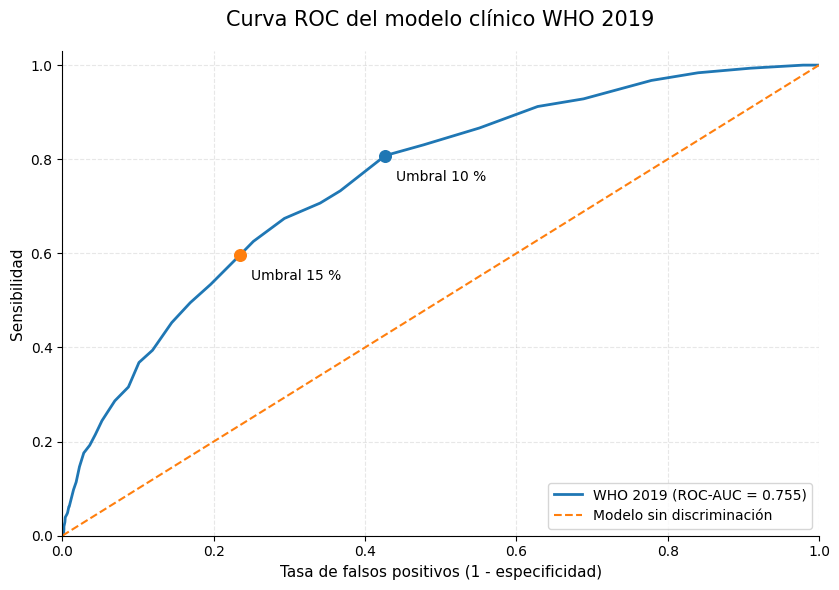

In [803]:
from sklearn.metrics import roc_curve


# =========================================================
# 1. Calculamos los puntos de la curva ROC
# =========================================================
#
# fpr:
# tasa de falsos positivos = 1 - especificidad
#
# tpr:
# tasa de verdaderos positivos = sensibilidad
#
# umbrales_roc:
# puntos de corte asociados a cada combinación

fpr_who, tpr_who, umbrales_roc_who = roc_curve(
    y_who_train,
    probabilidades_who_train
)


# =========================================================
# 2. Creamos el gráfico
# =========================================================

fig, ax = plt.subplots(figsize=(8.5, 6))


# Curva ROC del modelo WHO

ax.plot(
    fpr_who,
    tpr_who,
    linewidth=2,
    label=(
        "WHO 2019 "
        f"(ROC-AUC = {roc_auc_who_train:.3f})"
    )
)


# Línea de referencia de un modelo sin discriminación

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Modelo sin discriminación"
)


# =========================================================
# 3. Señalamos los umbrales del 10 % y del 15 %
# =========================================================

umbrales_destacados = [
    0.10,
    0.15
]


for umbral_destacado in umbrales_destacados:

    # Buscamos el punto de la curva cuyo umbral
    # sea el más próximo al valor que queremos mostrar

    indice_mas_cercano = abs(
        umbrales_roc_who - umbral_destacado
    ).argmin()

    fpr_punto = fpr_who[indice_mas_cercano]
    tpr_punto = tpr_who[indice_mas_cercano]

    ax.scatter(
        fpr_punto,
        tpr_punto,
        s=70,
        zorder=3
    )

    ax.annotate(
        f"Umbral {umbral_destacado * 100:.0f} %",
        xy=(fpr_punto, tpr_punto),
        xytext=(8, -18),
        textcoords="offset points",
        fontsize=10
    )


# =========================================================
# 4. Diseño del gráfico
# =========================================================

ax.set_title(
    "Curva ROC del modelo clínico WHO 2019",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Tasa de falsos positivos (1 - especificidad)",
    fontsize=11
)

ax.set_ylabel(
    "Sensibilidad",
    fontsize=11
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.03)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Calibración del modelo WHO por grupos de riesgo:


,RIESGO_MEDIO_ESTIMADO_PCT,FRECUENCIA_REAL_EVENTOS_PCT,DIFERENCIA_PUNTOS_PCT
0,2.31,1.35,0.96
1,4.60,4.68,-0.09
2,6.57,5.69,0.88
3,8.41,5.94,2.47
4,10.88,11.85,-0.97
5,13.99,16.17,-2.17
6,17.77,21.20,-3.43
7,25.45,32.66,-7.21


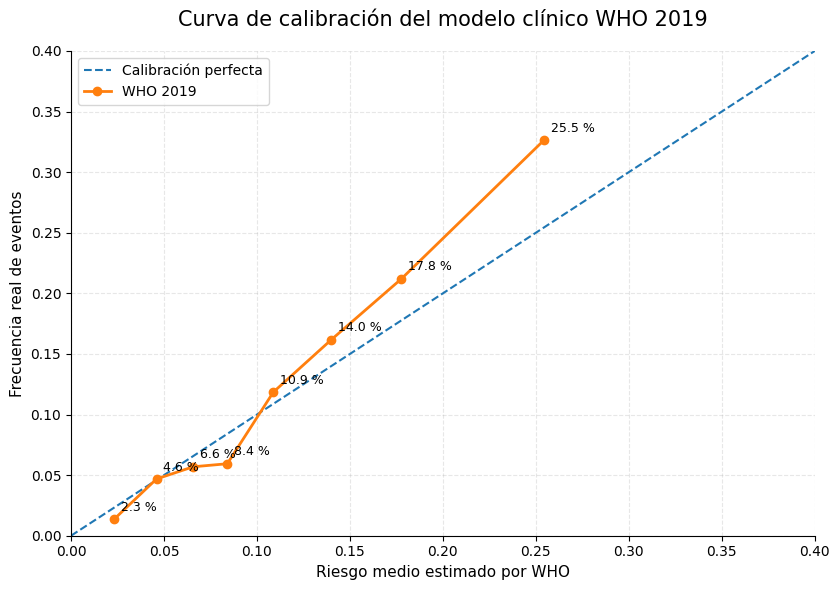


¿Se ha utilizado el conjunto de prueba?
False


In [804]:
from sklearn.calibration import calibration_curve


# =========================================================
# 1. Calculamos la curva de calibración
# =========================================================
#
# strategy="quantile" intenta crear grupos con un número
# parecido de participantes.

fraccion_positivos_who, probabilidad_media_who = (
    calibration_curve(
        y_true=y_who_train,
        y_prob=probabilidades_who_train,
        n_bins=8,
        strategy="quantile"
    )
)


# =========================================================
# 2. Creamos una tabla descriptiva de calibración
# =========================================================

tabla_calibracion_who = pd.DataFrame({
    "RIESGO_MEDIO_ESTIMADO": probabilidad_media_who,
    "FRECUENCIA_REAL_EVENTOS": fraccion_positivos_who
})


tabla_calibracion_who["RIESGO_MEDIO_ESTIMADO_PCT"] = (
    tabla_calibracion_who["RIESGO_MEDIO_ESTIMADO"]
    .mul(100)
)

tabla_calibracion_who["FRECUENCIA_REAL_EVENTOS_PCT"] = (
    tabla_calibracion_who["FRECUENCIA_REAL_EVENTOS"]
    .mul(100)
)

tabla_calibracion_who["DIFERENCIA_PUNTOS_PCT"] = (
    tabla_calibracion_who["RIESGO_MEDIO_ESTIMADO_PCT"]
    - tabla_calibracion_who["FRECUENCIA_REAL_EVENTOS_PCT"]
)


print("Calibración del modelo WHO por grupos de riesgo:")

display(
    tabla_calibracion_who[
        [
            "RIESGO_MEDIO_ESTIMADO_PCT",
            "FRECUENCIA_REAL_EVENTOS_PCT",
            "DIFERENCIA_PUNTOS_PCT"
        ]
    ].round(2)
)


# =========================================================
# 3. Representamos la curva de calibración
# =========================================================

fig, ax = plt.subplots(figsize=(8.5, 6))


# Línea de calibración perfecta

ax.plot(
    [0, 0.40],
    [0, 0.40],
    linestyle="--",
    linewidth=1.5,
    label="Calibración perfecta"
)


# Curva observada del modelo WHO

ax.plot(
    probabilidad_media_who,
    fraccion_positivos_who,
    marker="o",
    linewidth=2,
    label="WHO 2019"
)


# Añadimos la probabilidad media de cada grupo

for probabilidad, frecuencia in zip(
    probabilidad_media_who,
    fraccion_positivos_who
):

    ax.annotate(
        f"{probabilidad * 100:.1f} %",
        xy=(probabilidad, frecuencia),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=9
    )


# =========================================================
# 4. Diseño del gráfico
# =========================================================

ax.set_title(
    "Curva de calibración del modelo clínico WHO 2019",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Riesgo medio estimado por WHO",
    fontsize=11
)

ax.set_ylabel(
    "Frecuencia real de eventos",
    fontsize=11
)

ax.set_xlim(0, 0.40)
ax.set_ylim(0, 0.40)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# =========================================================
# 5. Comprobación
# =========================================================

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

In [805]:
import numpy as np

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score
)


# =========================================================
# 1. Umbral que maximiza el índice de Youden
# =========================================================

fpr_who, tpr_who, umbrales_roc_who = roc_curve(
    y_who_train,
    probabilidades_who_train
)

indice_youden = (
    tpr_who - fpr_who
)

# Excluimos posibles umbrales infinitos
mascara_umbrales_validos = np.isfinite(
    umbrales_roc_who
)

indices_validos = np.where(
    mascara_umbrales_validos
)[0]

indice_mejor_youden = indices_validos[
    np.argmax(
        indice_youden[
            mascara_umbrales_validos
        ]
    )
]

umbral_youden_who = (
    umbrales_roc_who[
        indice_mejor_youden
    ]
)


# =========================================================
# 2. Umbral que maximiza el F1-score
# =========================================================

precision_pr, recall_pr, umbrales_pr = (
    precision_recall_curve(
        y_who_train,
        probabilidades_who_train
    )
)

# precision y recall tienen un elemento más
# que el vector de umbrales

precision_para_umbrales = (
    precision_pr[:-1]
)

recall_para_umbrales = (
    recall_pr[:-1]
)

f1_por_umbral = np.divide(
    2
    * precision_para_umbrales
    * recall_para_umbrales,

    precision_para_umbrales
    + recall_para_umbrales,

    out=np.zeros_like(
        precision_para_umbrales
    ),

    where=(
        precision_para_umbrales
        + recall_para_umbrales
    ) != 0
)

indice_mejor_f1 = np.argmax(
    f1_por_umbral
)

umbral_f1_who = umbrales_pr[
    indice_mejor_f1
]


# =========================================================
# 3. Función para evaluar cualquier umbral
# =========================================================

def evaluar_umbral_who(
    nombre,
    umbral
):
    """
    Calcula las métricas de clasificación de WHO
    para un umbral determinado.
    """

    predicciones = (
        probabilidades_who_train
        >= umbral
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_who_train,
        predicciones,
        labels=[0, 1]
    ).ravel()

    sensibilidad = recall_score(
        y_who_train,
        predicciones,
        zero_division=0
    )

    especificidad = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    return {
        "CRITERIO": nombre,
        "UMBRAL": umbral,
        "UMBRAL_PCT": umbral * 100,
        "SENSIBILIDAD": sensibilidad,
        "ESPECIFICIDAD": especificidad,
        "PRECISION": precision_score(
            y_who_train,
            predicciones,
            zero_division=0
        ),
        "F1_SCORE": f1_score(
            y_who_train,
            predicciones,
            zero_division=0
        ),
        "ACCURACY": accuracy_score(
            y_who_train,
            predicciones
        ),
        "BALANCED_ACCURACY":
            balanced_accuracy_score(
                y_who_train,
                predicciones
            ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "PREDICCIONES_POSITIVAS":
            int(predicciones.sum())
    }


# =========================================================
# 4. Comparamos los candidatos
# =========================================================

candidatos_umbrales_who = [
    ("Umbral WHO 10 %", 0.10),
    ("Umbral intermedio 15 %", 0.15),
    ("Riesgo WHO alto 20 %", 0.20),
    ("Máximo índice de Youden", umbral_youden_who),
    ("Máximo F1-score", umbral_f1_who)
]


resultados_candidatos_who = [
    evaluar_umbral_who(
        nombre,
        umbral
    )
    for nombre, umbral
    in candidatos_umbrales_who
]


tabla_candidatos_who = pd.DataFrame(
    resultados_candidatos_who
)


print("Comparación de los umbrales candidatos de WHO:")

display(
    tabla_candidatos_who[
        [
            "CRITERIO",
            "UMBRAL_PCT",
            "SENSIBILIDAD",
            "ESPECIFICIDAD",
            "PRECISION",
            "F1_SCORE",
            "BALANCED_ACCURACY",
            "FN",
            "FP",
            "PREDICCIONES_POSITIVAS"
        ]
    ].round(4)
)


print("\nUmbral que maximiza el índice de Youden:")
print(
    round(
        umbral_youden_who * 100,
        2
    ),
    "%"
)


print("\nUmbral que maximiza el F1-score:")
print(
    round(
        umbral_f1_who * 100,
        2
    ),
    "%"
)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Comparación de los umbrales candidatos de WHO:


,CRITERIO,UMBRAL_PCT,SENSIBILIDAD,ESPECIFICIDAD,PRECISION,F1_SCORE,BALANCED_ACCURACY,FN,FP,PREDICCIONES_POSITIVAS
0,Umbral WHO 10 %,10.0,0.8078,0.5732,0.2024,0.3238,0.6905,59,977,1225
1,Umbral intermedio 15 %,15.0,0.5961,0.7654,0.2542,0.3564,0.6807,124,537,720
2,Riesgo WHO alto 20 %,20.0,0.3681,0.8986,0.3275,0.3466,0.6334,194,232,345
3,Máximo índice de Youden,10.0,0.8078,0.5732,0.2024,0.3238,0.6905,59,977,1225
4,Máximo F1-score,17.0,0.4951,0.8309,0.2820,0.3593,0.6630,155,387,539



Umbral que maximiza el índice de Youden:
10.0 %

Umbral que maximiza el F1-score:
17.0 %

¿Se ha utilizado el conjunto de prueba?
False


Umbral WHO principal:
10 %

Umbral WHO alternativo:
17 %

Resultados de WHO con el umbral principal del 10 %:


,METRICA,VALOR
0,Sensibilidad,0.8078
1,Especificidad,0.5732
2,Precision,0.2024
3,F1-score,0.3238
4,Accuracy,0.6009
5,Balanced accuracy,0.6905



Componentes de la matriz de confusión:


,RESULTADO,PARTICIPANTES
0,Verdaderos negativos,1312
1,Falsos positivos,977
2,Falsos negativos,59
3,Verdaderos positivos,248


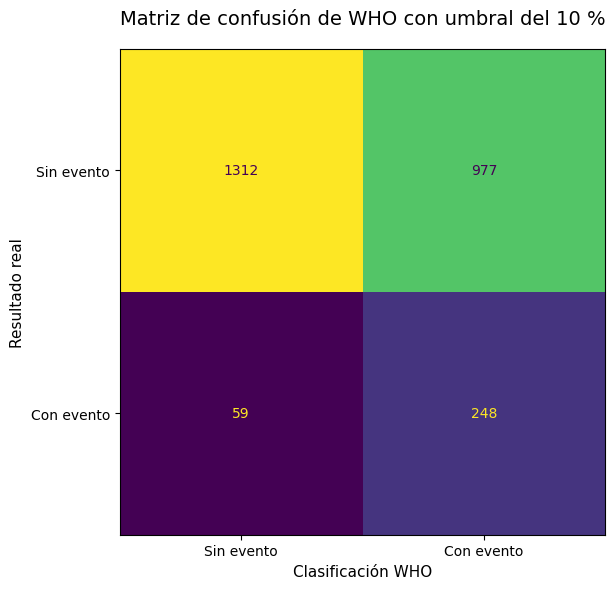


Participantes evaluados:
2596

Predicciones positivas:
1225

¿Se ha utilizado el conjunto de prueba?
False


In [806]:
from sklearn.metrics import ConfusionMatrixDisplay


# =========================================================
# 1. Fijamos los umbrales seleccionados utilizando
#    exclusivamente el conjunto de entrenamiento
# =========================================================

umbral_who_principal = 0.10

umbral_who_alternativo = umbral_f1_who


print("Umbral WHO principal:")
print(f"{umbral_who_principal * 100:.0f} %")

print("\nUmbral WHO alternativo:")
print(f"{umbral_who_alternativo * 100:.0f} %")


# =========================================================
# 2. Creamos la clasificación del umbral principal
# =========================================================

predicciones_who_train["PREDICCION_WHO_10"] = (
    predicciones_who_train["PROBABILIDAD_WHO"]
    >= umbral_who_principal
).astype(int)


y_pred_who_train = predicciones_who_train[
    "PREDICCION_WHO_10"
]


# =========================================================
# 3. Calculamos la matriz de confusión
# =========================================================

matriz_confusion_who_train = confusion_matrix(
    y_who_train,
    y_pred_who_train,
    labels=[0, 1]
)


tn_who, fp_who, fn_who, tp_who = (
    matriz_confusion_who_train.ravel()
)


# =========================================================
# 4. Calculamos las métricas del umbral principal
# =========================================================

sensibilidad_who_10 = recall_score(
    y_who_train,
    y_pred_who_train,
    zero_division=0
)

especificidad_who_10 = (
    tn_who / (tn_who + fp_who)
)

precision_who_10 = precision_score(
    y_who_train,
    y_pred_who_train,
    zero_division=0
)

f1_who_10 = f1_score(
    y_who_train,
    y_pred_who_train,
    zero_division=0
)

accuracy_who_10 = accuracy_score(
    y_who_train,
    y_pred_who_train
)

balanced_accuracy_who_10 = (
    balanced_accuracy_score(
        y_who_train,
        y_pred_who_train
    )
)


tabla_clasificacion_who_train = pd.DataFrame({
    "METRICA": [
        "Sensibilidad",
        "Especificidad",
        "Precision",
        "F1-score",
        "Accuracy",
        "Balanced accuracy"
    ],
    "VALOR": [
        sensibilidad_who_10,
        especificidad_who_10,
        precision_who_10,
        f1_who_10,
        accuracy_who_10,
        balanced_accuracy_who_10
    ]
})


print(
    "\nResultados de WHO con el umbral principal "
    "del 10 %:"
)

display(
    tabla_clasificacion_who_train.round(4)
)


print("\nComponentes de la matriz de confusión:")

tabla_confusion_who = pd.DataFrame({
    "RESULTADO": [
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos"
    ],
    "PARTICIPANTES": [
        tn_who,
        fp_who,
        fn_who,
        tp_who
    ]
})

display(tabla_confusion_who)


# =========================================================
# 5. Representamos la matriz de confusión
# =========================================================

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_who_train,
    display_labels=[
        "Sin evento",
        "Con evento"
    ]
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)


ax.set_title(
    "Matriz de confusión de WHO con umbral del 10 %",
    fontsize=14,
    pad=18
)

ax.set_xlabel(
    "Clasificación WHO",
    fontsize=11
)

ax.set_ylabel(
    "Resultado real",
    fontsize=11
)

plt.tight_layout()
plt.show()


# =========================================================
# 6. Comprobaciones
# =========================================================

print("\nParticipantes evaluados:")
print(len(y_who_train))

print("\nPredicciones positivas:")
print(int(y_pred_who_train.sum()))

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

## Fase 5.1 — Implementación y validación interna del modelo clínico WHO 2019

### 1. Objetivo del bloque

El primer enfoque evaluado fue el modelo clínico:

**WHO 2019 Cardiovascular Risk Chart**

Se utilizó la versión:

- No basada en análisis de laboratorio.
- Correspondiente a la región High-income North America.
- Diseñada para personas de entre 40 y 74 años.

Este modelo estima el riesgo de sufrir un evento cardiovascular durante los siguientes diez años mediante:

- Edad.
- Sexo.
- Tabaquismo actual.
- Presión arterial sistólica.
- Índice de masa corporal.

WHO 2019 es un modelo clínico previamente establecido. Por tanto, no necesita ser entrenado con los datos del proyecto.

---

### 2. Categorización de las variables

Las variables continuas se transformaron en los intervalos utilizados por las tablas WHO.

#### Edad

- 40–44 años.
- 45–49 años.
- 50–54 años.
- 55–59 años.
- 60–64 años.
- 65–69 años.
- 70–74 años.

#### Presión arterial sistólica

- Menos de 120 mmHg.
- 120–139 mmHg.
- 140–159 mmHg.
- 160–179 mmHg.
- 180 mmHg o más.

#### Índice de masa corporal

- Menos de 20.
- 20–24.
- 25–29.
- 30 hasta menos de 35.
- 35 o más.

También se utilizaron las categorías:

- Hombre o mujer.
- Fumador o no fumador actual.

Los 2.596 participantes del conjunto de entrenamiento recibieron correctamente las cinco categorías WHO, sin valores ausentes.

---

### 3. Construcción de la tabla de riesgo

La tabla clínica completa contiene:

- 7 categorías de edad.
- 5 categorías de presión sistólica.
- 5 categorías de IMC.
- 2 categorías de sexo.
- 2 categorías de tabaquismo.

Esto genera:

`7 × 5 × 5 × 2 × 2 = 700 combinaciones`

Se construyó una tabla de consulta con las 700 combinaciones posibles y su porcentaje de riesgo correspondiente.

La auditoría mostró:

- 700 combinaciones.
- Ninguna combinación duplicada.
- Ningún valor ausente.
- Riesgo mínimo del 1 %.
- Riesgo máximo del 47 %.

Los porcentajes se transformaron también en probabilidades entre 0 y 1 para poder calcular métricas predictivas.

---

### 4. Asignación del riesgo a los participantes

Cada participante del conjunto de entrenamiento se unió con su combinación exacta de:

- Edad.
- Presión sistólica.
- IMC.
- Sexo.
- Tabaquismo.

Los 2.596 participantes recibieron correctamente un porcentaje WHO.

La variable objetivo real no participó en el cálculo del riesgo. Se añadió posteriormente únicamente para evaluar el modelo.

El conjunto de prueba no fue utilizado.

---

### 5. Rendimiento probabilístico

El modelo WHO obtuvo en el conjunto de entrenamiento:

- **ROC-AUC: 0,7545**
- **Average Precision: 0,2029**
- **Brier score: 0,0948**

El baseline había obtenido:

- ROC-AUC: 0,50.
- Brier score: 0,1043.

Por tanto, WHO mostró:

- Una capacidad de discriminación claramente superior al azar.
- Una mejor calidad probabilística que el baseline.
- Capacidad para asignar riesgos mayores a las personas que posteriormente sufrieron un evento.

---

### 6. Riesgo asignado según el resultado real

El riesgo medio estimado fue:

- Sin evento cardiovascular: **9,92 %**.
- Con evento cardiovascular: **17,00 %**.

Esto indica que WHO asignó, en promedio, un riesgo claramente superior a quienes realmente sufrieron un evento.

Sin embargo, existe solapamiento entre ambos grupos:

- Algunas personas sin evento recibieron riesgos elevados.
- Algunas personas con evento recibieron riesgos bajos.

Por tanto, el modelo discrimina de forma razonable, pero no separa perfectamente ambas clases.

---

### 7. Calibración global

La prevalencia observada en el entrenamiento fue:

- **11,83 %**

El riesgo medio estimado por WHO fue:

- **10,76 %**

La diferencia fue de aproximadamente:

- **−1,07 puntos porcentuales**

Por tanto, WHO infravaloró ligeramente el riesgo cardiovascular medio de la muestra.

---

### 8. Calibración por grupos de riesgo

En los grupos de riesgo bajo y medio, las probabilidades WHO se encontraron relativamente cerca de la frecuencia observada.

En los niveles de riesgo elevado apareció una infravaloración más clara.

En el grupo de mayor riesgo:

- Riesgo medio estimado: **25,45 %**.
- Frecuencia real de eventos: **32,66 %**.
- Diferencia: aproximadamente **−7,21 puntos porcentuales**.

Esto indica que WHO puede estar infravalorando especialmente el riesgo de los participantes con mayor riesgo clínico dentro de esta muestra.

---

### 9. Curva ROC

La curva ROC permaneció claramente por encima de la diagonal correspondiente a un modelo sin discriminación.

El ROC-AUC de 0,7545 indica que, al escoger aleatoriamente:

- una persona que sufrió un evento;
- y una persona que no lo sufrió;

WHO asignará generalmente un riesgo superior a la persona que sufrió el evento en aproximadamente el 75 % de las comparaciones.

---

### 10. Evaluación de diferentes umbrales

Se estudiaron varios puntos de corte para convertir el riesgo probabilístico en una clasificación binaria.

#### Umbral del 10 %

- Sensibilidad: 80,78 %.
- Especificidad: 57,32 %.
- Precision: 20,24 %.
- F1-score: 0,3238.
- Balanced accuracy: 0,6905.

#### Umbral del 15 %

- Sensibilidad: 59,61 %.
- Especificidad: 76,54 %.
- Precision: 25,42 %.
- F1-score: 0,3564.
- Balanced accuracy: 0,6807.

#### Umbral del 17 %

- Sensibilidad: 49,51 %.
- Especificidad: 83,09 %.
- Precision: 28,20 %.
- F1-score: 0,3593.
- Balanced accuracy: 0,6630.

#### Umbral del 20 %

- Sensibilidad: 36,81 %.
- Especificidad: 89,86 %.
- Precision: 32,75 %.
- F1-score: 0,3468.
- Balanced accuracy: 0,6334.

---

### 11. Selección del umbral principal

Se eligió el **10 % como umbral principal** porque:

- Maximiza el índice de Youden.
- Obtiene la mayor balanced accuracy.
- Detecta aproximadamente ocho de cada diez eventos.
- Es un punto de corte clínicamente interpretable.
- Prioriza reducir el número de eventos no detectados.

El umbral del **17 %** se conservará como alternativa para un análisis de sensibilidad, ya que maximiza el F1-score y genera menos falsos positivos.

---

### 12. Matriz de confusión con el umbral del 10 %

Con el umbral principal se obtuvieron:

- **1.312 verdaderos negativos.**
- **977 falsos positivos.**
- **59 falsos negativos.**
- **248 verdaderos positivos.**

WHO detectó:

- 248 de los 307 eventos reales.
- El 80,78 % de los casos positivos.

Sin embargo, clasificó también como riesgo elevado a 977 participantes que no sufrieron el evento.

Este comportamiento refleja el coste de priorizar una sensibilidad elevada.

---

### 13. Interpretación del modelo WHO

WHO 2019 ofrece:

- Una discriminación razonable.
- Probabilidades globalmente coherentes.
- Una interpretación clínica directa.
- Una referencia real con la que comparar los modelos desarrollados en el proyecto.

Sus principales limitaciones dentro de esta muestra son:

- Uso de categorías en lugar de valores continuos exactos.
- Infravaloración del riesgo en los participantes de mayor riesgo.
- Elevado número de falsos positivos con el umbral del 10 %.
- Imposibilidad de adaptar sus parámetros a las características particulares de la muestra.

---

### 14. Prevención de fuga de información

Todas las decisiones tomadas hasta este momento se basaron exclusivamente en el conjunto de entrenamiento.

El conjunto de prueba de 650 participantes no se utilizó para:

- Elegir el umbral.
- Analizar la calibración.
- Calcular la curva ROC.
- Seleccionar configuraciones.
- Evaluar provisionalmente el modelo.

El umbral principal del 10 % queda fijado antes de la evaluación final sobre el conjunto de prueba.

---

### 15. Resultado del bloque

El modelo clínico WHO 2019 queda correctamente implementado y preparado para la comparación final.

Se conservarán:

- Las probabilidades WHO.
- El umbral principal del 10 %.
- El umbral alternativo del 17 %.
- Las métricas probabilísticas.
- Los resultados de calibración.
- La matriz de confusión obtenida en entrenamiento.

El siguiente bloque consistirá en desarrollar la regresión logística como modelo estadístico interpretable.

In [807]:
# =========================================================
# 1. Evaluamos la regresión logística inicial
#    mediante validación cruzada
# =========================================================

resultados_logistica_base_cv = cross_validate(
    estimator=pipeline_logistica,
    X=X_train,
    y=y_train,
    cv=validacion_cruzada,
    scoring=metricas_validacion,
    return_train_score=True,
    n_jobs=-1
)


# =========================================================
# 2. Resumimos las métricas de los cinco folds
# =========================================================

resumen_logistica_base = []


for nombre_metrica in metricas_validacion:

    valores_train = resultados_logistica_base_cv[
        f"train_{nombre_metrica}"
    ].copy()

    valores_validacion = resultados_logistica_base_cv[
        f"test_{nombre_metrica}"
    ].copy()

    nombre_presentacion = nombre_metrica


    # Scikit-learn devuelve el Brier score
    # con signo negativo dentro del sistema de scoring.
    # Recuperamos su valor habitual: menor es mejor.

    if nombre_metrica == "brier_negativo":

        valores_train = -valores_train

        valores_validacion = -valores_validacion

        nombre_presentacion = "brier_score"


    resumen_logistica_base.append({
        "METRICA": nombre_presentacion,

        "MEDIA_TRAIN": valores_train.mean(),

        "MEDIA_VALIDACION": (
            valores_validacion.mean()
        ),

        "DESVIACION_VALIDACION": (
            valores_validacion.std()
        ),

        "MINIMO_VALIDACION": (
            valores_validacion.min()
        ),

        "MAXIMO_VALIDACION": (
            valores_validacion.max()
        ),

        "DIFERENCIA_TRAIN_VALIDACION": (
            valores_train.mean()
            - valores_validacion.mean()
        )
    })


tabla_logistica_base_cv = pd.DataFrame(
    resumen_logistica_base
)


print(
    "Resultados de la regresión logística inicial "
    "mediante validación cruzada:"
)

display(
    tabla_logistica_base_cv.round(4)
)


# =========================================================
# 3. Comparación con el baseline
# =========================================================

comparacion_baseline_logistica = (
    tabla_baseline_cv[
        [
            "METRICA",
            "MEDIA_CV"
        ]
    ]
    .rename(
        columns={
            "MEDIA_CV": "BASELINE"
        }
    )
    .merge(
        tabla_logistica_base_cv[
            [
                "METRICA",
                "MEDIA_VALIDACION"
            ]
        ],
        on="METRICA",
        how="inner"
    )
    .rename(
        columns={
            "MEDIA_VALIDACION":
            "REGRESION_LOGISTICA"
        }
    )
)


print("\nComparación con el modelo baseline:")

display(
    comparacion_baseline_logistica.round(4)
)


# =========================================================
# 4. Comprobaciones
# =========================================================

print("\nNúmero de folds evaluados:")
print(validacion_cruzada.get_n_splits())


print("\nParticipantes utilizados:")
print(len(X_train))


print("\nParticipantes reservados para test:")
print(len(X_test))


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Resultados de la regresión logística inicial mediante validación cruzada:


,METRICA,MEDIA_TRAIN,MEDIA_VALIDACION,DESVIACION_VALIDACION,MINIMO_VALIDACION,MAXIMO_VALIDACION,DIFERENCIA_TRAIN_VALIDACION
0,roc_auc,0.7563,0.7535,0.0359,0.6965,0.7955,0.0028
1,recall,0.0415,0.0456,0.0159,0.0323,0.0656,-0.0041
2,precision,0.6753,0.7400,0.2498,0.4000,1.0000,-0.0647
3,f1,0.0778,0.0854,0.0293,0.0606,0.1231,-0.0077
4,accuracy,0.8844,0.8848,0.0033,0.8805,0.8902,-0.0004
5,balanced_accuracy,0.5195,0.5215,0.0086,0.5131,0.5328,-0.0020
6,especificidad,0.9975,0.9974,0.0025,0.9934,1.0000,0.0001
7,brier_score,0.0932,0.0939,0.0043,0.0894,0.1004,-0.0006



Comparación con el modelo baseline:


,METRICA,BASELINE,REGRESION_LOGISTICA
0,roc_auc,0.5000,0.7535
1,recall,0.0000,0.0456
2,precision,0.0000,0.7400
3,f1,0.0000,0.0854
4,accuracy,0.8817,0.8848
5,balanced_accuracy,0.5000,0.5215
6,especificidad,1.0000,0.9974
7,brier_score,0.1043,0.0939



Número de folds evaluados:
5

Participantes utilizados:
2596

Participantes reservados para test:
650

¿Se ha utilizado el conjunto de prueba?
False


In [808]:
from sklearn.model_selection import GridSearchCV


# =========================================================
# 1. Definimos las configuraciones que se compararán
# =========================================================
#
# C controla la intensidad de la regularización:
#
# - C pequeño: regularización más fuerte.
# - C grande: regularización más débil.
#
# Compararemos:
#
# - L1: puede reducir algunos coeficientes hasta cero.
# - L2: reduce los coeficientes de forma más gradual.

parametros_logistica = {
    "modelo__solver": [
        "liblinear"
    ],

    "modelo__penalty": [
        "l1",
        "l2"
    ],

    "modelo__C": [
        0.01,
        0.03,
        0.1,
        0.3,
        1,
        3,
        10,
        30,
        100
    ]
}


# =========================================================
# 2. Definimos las métricas de la búsqueda
# =========================================================
#
# ROC-AUC se utilizará para seleccionar la configuración.
# También guardaremos el Brier score para evaluar
# la calidad de las probabilidades.

metricas_busqueda_logistica = {
    "roc_auc": "roc_auc",
    "brier_negativo": "neg_brier_score"
}


# =========================================================
# 3. Creamos la búsqueda de hiperparámetros
# =========================================================

busqueda_logistica = GridSearchCV(
    estimator=pipeline_logistica,
    param_grid=parametros_logistica,
    scoring=metricas_busqueda_logistica,
    refit="roc_auc",
    cv=validacion_cruzada,
    return_train_score=True,
    n_jobs=-1
)


# =========================================================
# 4. Ajustamos únicamente con el conjunto de entrenamiento
# =========================================================

busqueda_logistica.fit(
    X_train,
    y_train
)


# =========================================================
# 5. Convertimos los resultados en una tabla
# =========================================================

resultados_busqueda_logistica = pd.DataFrame(
    busqueda_logistica.cv_results_
)


tabla_busqueda_logistica = resultados_busqueda_logistica[
    [
        "param_modelo__penalty",
        "param_modelo__C",
        "mean_train_roc_auc",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_train_brier_negativo",
        "mean_test_brier_negativo",
        "rank_test_roc_auc"
    ]
].copy()


# Convertimos el Brier score a su escala normal:
# cuanto menor sea, mejor.

tabla_busqueda_logistica["BRIER_TRAIN"] = (
    -tabla_busqueda_logistica[
        "mean_train_brier_negativo"
    ]
)

tabla_busqueda_logistica["BRIER_VALIDACION"] = (
    -tabla_busqueda_logistica[
        "mean_test_brier_negativo"
    ]
)


# Renombramos las columnas

tabla_busqueda_logistica = (
    tabla_busqueda_logistica
    .rename(
        columns={
            "param_modelo__penalty": "PENALIZACION",
            "param_modelo__C": "C",
            "mean_train_roc_auc": "ROC_AUC_TRAIN",
            "mean_test_roc_auc": "ROC_AUC_VALIDACION",
            "std_test_roc_auc": "DESVIACION_ROC_AUC",
            "rank_test_roc_auc": "POSICION_ROC_AUC"
        }
    )
    .drop(
        columns=[
            "mean_train_brier_negativo",
            "mean_test_brier_negativo"
        ]
    )
    .sort_values(
        by="POSICION_ROC_AUC"
    )
)


print(
    "Resultados de la búsqueda de hiperparámetros "
    "de la regresión logística:"
)

display(
    tabla_busqueda_logistica
    .head(18)
    .round(4)
)


# =========================================================
# 6. Mostramos la configuración seleccionada
# =========================================================

print("\nMejores hiperparámetros:")
print(
    busqueda_logistica.best_params_
)


print("\nMejor ROC-AUC medio de validación:")
print(
    round(
        busqueda_logistica.best_score_,
        4
    )
)


# Guardamos el mejor pipeline encontrado

mejor_pipeline_logistica = (
    busqueda_logistica.best_estimator_
)


# =========================================================
# 7. Comprobaciones
# =========================================================

print("\nNúmero de configuraciones comparadas:")
print(
    len(resultados_busqueda_logistica)
)


print("\nParticipantes utilizados para el ajuste:")
print(
    len(X_train)
)


print("\nParticipantes reservados para test:")
print(
    len(X_test)
)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Resultados de la búsqueda de hiperparámetros de la regresión logística:


,PENALIZACION,C,ROC_AUC_TRAIN,ROC_AUC_VALIDACION,DESVIACION_ROC_AUC,POSICION_ROC_AUC,BRIER_TRAIN,BRIER_VALIDACION
11,l2,3.00,0.7564,0.7536,0.0360,1,0.0932,0.0939
13,l2,10.00,0.7564,0.7536,0.0360,2,0.0932,0.0939
10,l1,3.00,0.7563,0.7536,0.0360,3,0.0932,0.0939
12,l1,10.00,0.7564,0.7535,0.0360,4,0.0932,0.0939
15,l2,30.00,0.7564,0.7535,0.0360,5,0.0932,0.0939
8,l1,1.00,0.7562,0.7535,0.0359,6,0.0932,0.0939
16,l1,100.00,0.7564,0.7535,0.0360,7,0.0932,0.0939
14,l1,30.00,0.7564,0.7535,0.0360,8,0.0932,0.0939
17,l2,100.00,0.7564,0.7535,0.0360,9,0.0932,0.0939
9,l2,1.00,0.7562,0.7534,0.0360,10,0.0932,0.0938



Mejores hiperparámetros:
{'modelo__C': 3, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}

Mejor ROC-AUC medio de validación:
0.7536

Número de configuraciones comparadas:
18

Participantes utilizados para el ajuste:
2596

Participantes reservados para test:
650

¿Se ha utilizado el conjunto de prueba?
False


In [809]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)


# =========================================================
# 1. Guardamos la configuración seleccionada
# =========================================================

hiperparametros_logistica_seleccionados = (
    busqueda_logistica.best_params_.copy()
)

modelo_logistica_seleccionado = (
    mejor_pipeline_logistica
)


print("Configuración seleccionada:")
print(hiperparametros_logistica_seleccionados)


# =========================================================
# 2. Generamos probabilidades out-of-fold
# =========================================================
#
# Cada participante recibe una predicción realizada
# por un modelo que no fue entrenado con esa persona.

probabilidades_logistica_oof_array = cross_val_predict(
    estimator=modelo_logistica_seleccionado,
    X=X_train,
    y=y_train,
    cv=validacion_cruzada,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# Convertimos el resultado en una Serie y conservamos
# los índices originales de los participantes.

probabilidades_logistica_oof = pd.Series(
    probabilidades_logistica_oof_array,
    index=X_train.index,
    name="PROBABILIDAD_LOGISTICA_OOF"
)


# =========================================================
# 3. Comprobaciones de integridad
# =========================================================

print("\nParticipantes del conjunto de entrenamiento:")
print(len(X_train))

print("\nProbabilidades out-of-fold generadas:")
print(len(probabilidades_logistica_oof))

print("\nValores ausentes:")
print(probabilidades_logistica_oof.isna().sum())

print("\nProbabilidad mínima y máxima:")
print(
    probabilidades_logistica_oof
    .agg(["min", "max"])
)


# =========================================================
# 4. Métricas probabilísticas out-of-fold
# =========================================================

roc_auc_logistica_oof = roc_auc_score(
    y_train,
    probabilidades_logistica_oof
)

average_precision_logistica_oof = (
    average_precision_score(
        y_train,
        probabilidades_logistica_oof
    )
)

brier_logistica_oof = brier_score_loss(
    y_train,
    probabilidades_logistica_oof
)

riesgo_medio_logistica_oof = (
    probabilidades_logistica_oof.mean()
)

prevalencia_train = y_train.mean()


tabla_metricas_logistica_oof = pd.DataFrame({
    "METRICA": [
        "ROC-AUC",
        "Average precision",
        "Brier score",
        "Prevalencia observada",
        "Riesgo medio estimado",
        "Diferencia estimado - observado"
    ],
    "VALOR": [
        roc_auc_logistica_oof,
        average_precision_logistica_oof,
        brier_logistica_oof,
        prevalencia_train,
        riesgo_medio_logistica_oof,
        riesgo_medio_logistica_oof - prevalencia_train
    ]
})


print(
    "\nEvaluación probabilística out-of-fold "
    "de la regresión logística:"
)

display(
    tabla_metricas_logistica_oof.round(4)
)


# =========================================================
# 5. Comparación probabilística inicial con WHO
# =========================================================

comparacion_probabilistica_train = pd.DataFrame({
    "MODELO": [
        "WHO 2019",
        "Regresión logística"
    ],
    "ROC_AUC": [
        roc_auc_who_train,
        roc_auc_logistica_oof
    ],
    "AVERAGE_PRECISION": [
        average_precision_who_train,
        average_precision_logistica_oof
    ],
    "BRIER_SCORE": [
        brier_who_train,
        brier_logistica_oof
    ],
    "RIESGO_MEDIO_ESTIMADO": [
        riesgo_medio_who_train,
        riesgo_medio_logistica_oof
    ]
})


print(
    "\nComparación probabilística inicial "
    "dentro del entrenamiento:"
)

display(
    comparacion_probabilistica_train.round(4)
)


# =========================================================
# 6. Comprobación final
# =========================================================

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Configuración seleccionada:
{'modelo__C': 3, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}

Participantes del conjunto de entrenamiento:
2596

Probabilidades out-of-fold generadas:
2596

Valores ausentes:
0

Probabilidad mínima y máxima:
min    0.005269
max    0.796525
Name: PROBABILIDAD_LOGISTICA_OOF, dtype: float64

Evaluación probabilística out-of-fold de la regresión logística:


,METRICA,VALOR
0,ROC-AUC,0.7521
1,Average precision,0.3070
2,Brier score,0.0939
3,Prevalencia observada,0.1183
4,Riesgo medio estimado,0.1187
5,Diferencia estimado - observado,0.0005



Comparación probabilística inicial dentro del entrenamiento:


,MODELO,ROC_AUC,AVERAGE_PRECISION,BRIER_SCORE,RIESGO_MEDIO_ESTIMADO
0,WHO 2019,0.7545,0.2929,0.0949,0.1076
1,Regresión logística,0.7521,0.3070,0.0939,0.1187



¿Se ha utilizado el conjunto de prueba?
False


Calibración out-of-fold de la regresión logística:


,RIESGO_MEDIO_ESTIMADO_PCT,FRECUENCIA_REAL_EVENTOS_PCT,DIFERENCIA_PUNTOS_PCT
0,1.75,1.54,0.21
1,3.37,4.01,-0.64
2,5.21,5.23,-0.02
3,7.43,6.48,0.94
4,10.09,11.73,-1.63
5,13.87,13.23,0.64
6,19.60,18.83,0.77
7,33.64,33.54,0.10


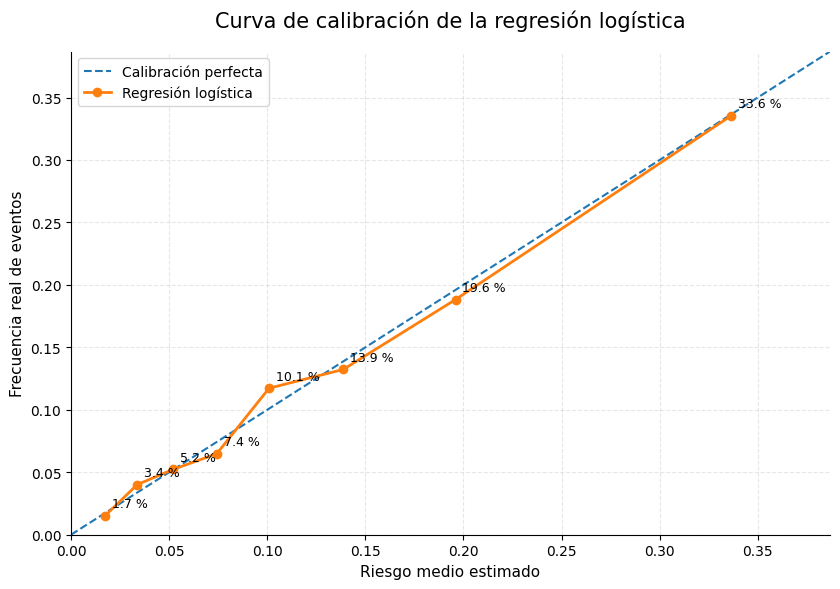


¿Se ha utilizado el conjunto de prueba?
False


In [810]:
from sklearn.calibration import calibration_curve


# =========================================================
# 1. Calculamos la curva de calibración
#    usando las probabilidades out-of-fold
# =========================================================

fraccion_positivos_logistica, probabilidad_media_logistica = (
    calibration_curve(
        y_true=y_train,
        y_prob=probabilidades_logistica_oof,
        n_bins=8,
        strategy="quantile"
    )
)


# =========================================================
# 2. Creamos una tabla descriptiva
# =========================================================

tabla_calibracion_logistica = pd.DataFrame({
    "RIESGO_MEDIO_ESTIMADO": probabilidad_media_logistica,
    "FRECUENCIA_REAL_EVENTOS": fraccion_positivos_logistica
})


tabla_calibracion_logistica[
    "RIESGO_MEDIO_ESTIMADO_PCT"
] = (
    tabla_calibracion_logistica[
        "RIESGO_MEDIO_ESTIMADO"
    ]
    .mul(100)
)


tabla_calibracion_logistica[
    "FRECUENCIA_REAL_EVENTOS_PCT"
] = (
    tabla_calibracion_logistica[
        "FRECUENCIA_REAL_EVENTOS"
    ]
    .mul(100)
)


tabla_calibracion_logistica[
    "DIFERENCIA_PUNTOS_PCT"
] = (
    tabla_calibracion_logistica[
        "RIESGO_MEDIO_ESTIMADO_PCT"
    ]
    - tabla_calibracion_logistica[
        "FRECUENCIA_REAL_EVENTOS_PCT"
    ]
)


print(
    "Calibración out-of-fold de la "
    "regresión logística:"
)

display(
    tabla_calibracion_logistica[
        [
            "RIESGO_MEDIO_ESTIMADO_PCT",
            "FRECUENCIA_REAL_EVENTOS_PCT",
            "DIFERENCIA_PUNTOS_PCT"
        ]
    ].round(2)
)


# =========================================================
# 3. Representamos la curva de calibración
# =========================================================

limite_grafico = max(
    probabilidad_media_logistica.max(),
    fraccion_positivos_logistica.max()
) * 1.15


fig, ax = plt.subplots(figsize=(8.5, 6))


# Calibración perfecta

ax.plot(
    [0, limite_grafico],
    [0, limite_grafico],
    linestyle="--",
    linewidth=1.5,
    label="Calibración perfecta"
)


# Regresión logística

ax.plot(
    probabilidad_media_logistica,
    fraccion_positivos_logistica,
    marker="o",
    linewidth=2,
    label="Regresión logística"
)


# Etiquetamos cada grupo con su riesgo medio

for probabilidad, frecuencia in zip(
    probabilidad_media_logistica,
    fraccion_positivos_logistica
):

    ax.annotate(
        f"{probabilidad * 100:.1f} %",
        xy=(probabilidad, frecuencia),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=9
    )


ax.set_title(
    "Curva de calibración de la regresión logística",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Riesgo medio estimado",
    fontsize=11
)

ax.set_ylabel(
    "Frecuencia real de eventos",
    fontsize=11
)

ax.set_xlim(0, limite_grafico)
ax.set_ylim(0, limite_grafico)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

In [811]:
import numpy as np

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score
)


# =========================================================
# 1. Umbral que maximiza el índice de Youden
# =========================================================

fpr_logistica, tpr_logistica, umbrales_roc_logistica = (
    roc_curve(
        y_train,
        probabilidades_logistica_oof
    )
)


indice_youden_logistica = (
    tpr_logistica - fpr_logistica
)


# Eliminamos posibles umbrales infinitos

mascara_umbrales_validos = np.isfinite(
    umbrales_roc_logistica
)

indices_validos = np.where(
    mascara_umbrales_validos
)[0]


indice_mejor_youden_logistica = indices_validos[
    np.argmax(
        indice_youden_logistica[
            mascara_umbrales_validos
        ]
    )
]


umbral_youden_logistica = (
    umbrales_roc_logistica[
        indice_mejor_youden_logistica
    ]
)


# =========================================================
# 2. Umbral que maximiza el F1-score
# =========================================================

precision_pr_logistica, recall_pr_logistica, umbrales_pr_logistica = (
    precision_recall_curve(
        y_train,
        probabilidades_logistica_oof
    )
)


# Precision y recall contienen un elemento más
# que el vector de umbrales

precision_para_umbrales = (
    precision_pr_logistica[:-1]
)

recall_para_umbrales = (
    recall_pr_logistica[:-1]
)


f1_por_umbral_logistica = np.divide(
    2
    * precision_para_umbrales
    * recall_para_umbrales,

    precision_para_umbrales
    + recall_para_umbrales,

    out=np.zeros_like(
        precision_para_umbrales
    ),

    where=(
        precision_para_umbrales
        + recall_para_umbrales
    ) != 0
)


indice_mejor_f1_logistica = np.argmax(
    f1_por_umbral_logistica
)


umbral_f1_logistica = (
    umbrales_pr_logistica[
        indice_mejor_f1_logistica
    ]
)


# =========================================================
# 3. Función para evaluar cada umbral
# =========================================================

def evaluar_umbral_logistica(nombre, umbral):
    """
    Calcula las métricas de clasificación de la regresión
    logística para un umbral determinado.
    """

    predicciones = (
        probabilidades_logistica_oof >= umbral
    ).astype(int)


    tn, fp, fn, tp = confusion_matrix(
        y_train,
        predicciones,
        labels=[0, 1]
    ).ravel()


    sensibilidad = recall_score(
        y_train,
        predicciones,
        zero_division=0
    )


    especificidad = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    return {
        "CRITERIO": nombre,
        "UMBRAL": umbral,
        "UMBRAL_PCT": umbral * 100,
        "SENSIBILIDAD": sensibilidad,
        "ESPECIFICIDAD": especificidad,
        "PRECISION": precision_score(
            y_train,
            predicciones,
            zero_division=0
        ),
        "F1_SCORE": f1_score(
            y_train,
            predicciones,
            zero_division=0
        ),
        "ACCURACY": accuracy_score(
            y_train,
            predicciones
        ),
        "BALANCED_ACCURACY": balanced_accuracy_score(
            y_train,
            predicciones
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "PREDICCIONES_POSITIVAS": int(
            predicciones.sum()
        )
    }


# =========================================================
# 4. Comparamos varios umbrales candidatos
# =========================================================

candidatos_umbrales_logistica = [
    ("Umbral del 10 %", 0.10),
    ("Umbral del 15 %", 0.15),
    ("Umbral del 20 %", 0.20),
    ("Umbral predeterminado del 50 %", 0.50),
    (
        "Máximo índice de Youden",
        umbral_youden_logistica
    ),
    (
        "Máximo F1-score",
        umbral_f1_logistica
    )
]


resultados_candidatos_logistica = [
    evaluar_umbral_logistica(
        nombre,
        umbral
    )
    for nombre, umbral
    in candidatos_umbrales_logistica
]


tabla_candidatos_logistica = pd.DataFrame(
    resultados_candidatos_logistica
)


print(
    "Comparación de umbrales candidatos "
    "de la regresión logística:"
)

display(
    tabla_candidatos_logistica[
        [
            "CRITERIO",
            "UMBRAL_PCT",
            "SENSIBILIDAD",
            "ESPECIFICIDAD",
            "PRECISION",
            "F1_SCORE",
            "ACCURACY",
            "BALANCED_ACCURACY",
            "FN",
            "FP",
            "PREDICCIONES_POSITIVAS"
        ]
    ].round(4)
)


print("\nUmbral que maximiza el índice de Youden:")

print(
    round(
        umbral_youden_logistica * 100,
        2
    ),
    "%"
)


print("\nUmbral que maximiza el F1-score:")

print(
    round(
        umbral_f1_logistica * 100,
        2
    ),
    "%"
)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Comparación de umbrales candidatos de la regresión logística:


,CRITERIO,UMBRAL_PCT,SENSIBILIDAD,ESPECIFICIDAD,PRECISION,F1_SCORE,ACCURACY,BALANCED_ACCURACY,FN,FP,PREDICCIONES_POSITIVAS
0,Umbral del 10 %,10.0000,0.7492,0.6007,0.2010,0.3170,0.6183,0.6749,77,914,1144
1,Umbral del 15 %,15.0000,0.5928,0.7615,0.2500,0.3517,0.7415,0.6772,125,546,728
2,Umbral del 20 %,20.0000,0.4495,0.8585,0.2987,0.3589,0.8101,0.6540,169,324,462
3,Umbral predeterminado del 50 %,50.0000,0.0456,0.9969,0.6667,0.0854,0.8844,0.5213,293,7,21
4,Máximo índice de Youden,11.2266,0.7231,0.6518,0.2179,0.3348,0.6602,0.6875,85,797,1019
5,Máximo F1-score,17.8215,0.5147,0.8257,0.2837,0.3657,0.7889,0.6702,149,399,557



Umbral que maximiza el índice de Youden:
11.23 %

Umbral que maximiza el F1-score:
17.82 %

¿Se ha utilizado el conjunto de prueba?
False


Umbral principal de la regresión logística:
11.23 %

Umbral alternativo de la regresión logística:
17.82 %

Resultados out-of-fold con el umbral principal:


,METRICA,VALOR
0,Sensibilidad,0.7231
1,Especificidad,0.6518
2,Precision,0.2179
3,F1-score,0.3348
4,Accuracy,0.6602
5,Balanced accuracy,0.6875



Componentes de la matriz de confusión:


,RESULTADO,PARTICIPANTES
0,Verdaderos negativos,1492
1,Falsos positivos,797
2,Falsos negativos,85
3,Verdaderos positivos,222


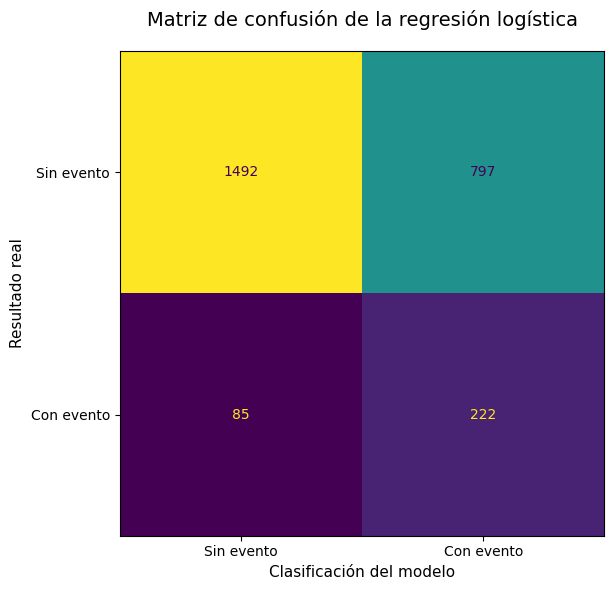


Participantes evaluados:
2596

Predicciones positivas:
1019

¿Se ha utilizado el conjunto de prueba?
False


In [812]:
from sklearn.metrics import ConfusionMatrixDisplay


# =========================================================
# 1. Fijamos los umbrales seleccionados
# =========================================================

umbral_logistica_principal = float(
    umbral_youden_logistica
)

umbral_logistica_alternativo = float(
    umbral_f1_logistica
)


print("Umbral principal de la regresión logística:")

print(
    f"{umbral_logistica_principal * 100:.2f} %"
)


print("\nUmbral alternativo de la regresión logística:")

print(
    f"{umbral_logistica_alternativo * 100:.2f} %"
)


# =========================================================
# 2. Convertimos las probabilidades out-of-fold
#    en clases usando el umbral principal
# =========================================================

predicciones_logistica_oof = (
    probabilidades_logistica_oof
    >= umbral_logistica_principal
).astype(int)


# =========================================================
# 3. Calculamos la matriz de confusión
# =========================================================

matriz_confusion_logistica_oof = confusion_matrix(
    y_train,
    predicciones_logistica_oof,
    labels=[0, 1]
)


tn_logistica, fp_logistica, fn_logistica, tp_logistica = (
    matriz_confusion_logistica_oof.ravel()
)


# =========================================================
# 4. Calculamos las métricas de clasificación
# =========================================================

sensibilidad_logistica = recall_score(
    y_train,
    predicciones_logistica_oof,
    zero_division=0
)


especificidad_logistica = (
    tn_logistica
    / (tn_logistica + fp_logistica)
)


precision_logistica = precision_score(
    y_train,
    predicciones_logistica_oof,
    zero_division=0
)


f1_logistica = f1_score(
    y_train,
    predicciones_logistica_oof,
    zero_division=0
)


accuracy_logistica = accuracy_score(
    y_train,
    predicciones_logistica_oof
)


balanced_accuracy_logistica = (
    balanced_accuracy_score(
        y_train,
        predicciones_logistica_oof
    )
)


tabla_clasificacion_logistica_oof = pd.DataFrame({
    "METRICA": [
        "Sensibilidad",
        "Especificidad",
        "Precision",
        "F1-score",
        "Accuracy",
        "Balanced accuracy"
    ],
    "VALOR": [
        sensibilidad_logistica,
        especificidad_logistica,
        precision_logistica,
        f1_logistica,
        accuracy_logistica,
        balanced_accuracy_logistica
    ]
})


print(
    "\nResultados out-of-fold con el "
    "umbral principal:"
)

display(
    tabla_clasificacion_logistica_oof.round(4)
)


# =========================================================
# 5. Mostramos los componentes de la matriz
# =========================================================

tabla_confusion_logistica = pd.DataFrame({
    "RESULTADO": [
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos"
    ],
    "PARTICIPANTES": [
        tn_logistica,
        fp_logistica,
        fn_logistica,
        tp_logistica
    ]
})


print("\nComponentes de la matriz de confusión:")

display(
    tabla_confusion_logistica
)


# =========================================================
# 6. Representamos la matriz de confusión
# =========================================================

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_logistica_oof,
    display_labels=[
        "Sin evento",
        "Con evento"
    ]
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)


ax.set_title(
    "Matriz de confusión de la regresión logística",
    fontsize=14,
    pad=18
)

ax.set_xlabel(
    "Clasificación del modelo",
    fontsize=11
)

ax.set_ylabel(
    "Resultado real",
    fontsize=11
)


plt.tight_layout()
plt.show()


# =========================================================
# 7. Comprobaciones
# =========================================================

print("\nParticipantes evaluados:")
print(len(y_train))

print("\nPredicciones positivas:")
print(int(predicciones_logistica_oof.sum()))

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

In [813]:
import numpy as np
import pandas as pd


# =========================================================
# 1. Extraemos el preprocesamiento y el modelo ajustado
# =========================================================
#
# GridSearchCV ajustó automáticamente la mejor configuración
# utilizando todo el conjunto de entrenamiento.

preprocesador_logistica = (
    mejor_pipeline_logistica
    .named_steps["preprocesamiento"]
)

modelo_logistica_final_train = (
    mejor_pipeline_logistica
    .named_steps["modelo"]
)


# Obtenemos los nombres de las variables después
# de aplicar el preprocesamiento.

nombres_variables_logistica = (
    preprocesador_logistica
    .get_feature_names_out()
)


# Obtenemos los coeficientes aprendidos.

coeficientes_logistica = (
    modelo_logistica_final_train.coef_[0]
)


# =========================================================
# 2. Coeficientes en la escala de entrenamiento
# =========================================================

tabla_coeficientes_logistica = pd.DataFrame({
    "VARIABLE": nombres_variables_logistica,
    "COEFICIENTE": coeficientes_logistica
})


tabla_coeficientes_logistica["ODDS_RATIO"] = np.exp(
    tabla_coeficientes_logistica["COEFICIENTE"]
)


tabla_coeficientes_logistica["DIRECCION"] = np.where(
    tabla_coeficientes_logistica["COEFICIENTE"] > 0,
    "Aumenta el riesgo estimado",
    "Reduce el riesgo estimado"
)


print(
    "Coeficientes de la regresión logística "
    "en la escala de entrenamiento:"
)

display(
    tabla_coeficientes_logistica.round(4)
)


# =========================================================
# 3. Recuperamos las desviaciones típicas del escalado
# =========================================================

escalador_logistica = (
    preprocesador_logistica
    .named_transformers_["variables_continuas"]
)


escalas_continuas = dict(
    zip(
        variables_continuas,
        escalador_logistica.scale_
    )
)


tabla_escalas_logistica = pd.DataFrame({
    "VARIABLE": list(
        escalas_continuas.keys()
    ),
    "DESVIACION_TIPICA": list(
        escalas_continuas.values()
    )
})


print(
    "\nDesviaciones típicas utilizadas "
    "en el escalado:"
)

display(
    tabla_escalas_logistica.round(4)
)


# =========================================================
# 4. Definimos incrementos fáciles de interpretar
# =========================================================

incrementos_interpretables = {
    "EDAD": 5,
    "PRESION_SISTOLICA": 10,
    "IMC": 5,
    "HOMBRE": 1,
    "FUMADOR_ACTUAL": 1
}


etiquetas_interpretables = {
    "EDAD": "Por cada 5 años adicionales",
    "PRESION_SISTOLICA":
        "Por cada 10 mmHg adicionales",
    "IMC":
        "Por cada 5 puntos adicionales de IMC",
    "HOMBRE":
        "Hombre frente a mujer",
    "FUMADOR_ACTUAL":
        "Fumador actual frente a no fumador"
}


# =========================================================
# 5. Traducimos los coeficientes a unidades originales
# =========================================================

filas_interpretacion = []


for variable, coeficiente in zip(
    nombres_variables_logistica,
    coeficientes_logistica
):

    incremento = incrementos_interpretables[
        variable
    ]


    # Las variables continuas fueron estandarizadas.
    # Dividimos el coeficiente entre la desviación típica
    # para recuperar su efecto en la unidad original.

    if variable in variables_continuas:

        coeficiente_unidad_original = (
            coeficiente
            / escalas_continuas[variable]
        )

    else:

        # Las variables binarias conservaron valores 0 y 1.

        coeficiente_unidad_original = coeficiente


    odds_ratio_incremento = np.exp(
        coeficiente_unidad_original
        * incremento
    )


    cambio_odds_pct = (
        odds_ratio_incremento - 1
    ) * 100


    filas_interpretacion.append({
        "VARIABLE": variable,
        "INTERPRETACION":
            etiquetas_interpretables[variable],
        "ODDS_RATIO":
            odds_ratio_incremento,
        "CAMBIO_ODDS_PCT":
            cambio_odds_pct
    })


tabla_interpretacion_logistica = pd.DataFrame(
    filas_interpretacion
)


print(
    "\nInterpretación en unidades "
    "más comprensibles:"
)

display(
    tabla_interpretacion_logistica.round(3)
)


# =========================================================
# 6. Intercepto del modelo
# =========================================================

intercepto_logistica = float(
    modelo_logistica_final_train.intercept_[0]
)


print("\nIntercepto del modelo:")

print(
    round(
        intercepto_logistica,
        4
    )
)


# =========================================================
# 7. Comprobación final
# =========================================================

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Coeficientes de la regresión logística en la escala de entrenamiento:


,VARIABLE,COEFICIENTE,ODDS_RATIO,DIRECCION
0,EDAD,0.7348,2.0851,Aumenta el riesgo estimado
1,PRESION_SISTOLICA,0.3330,1.3951,Aumenta el riesgo estimado
2,IMC,0.1100,1.1163,Aumenta el riesgo estimado
3,HOMBRE,0.8540,2.3489,Aumenta el riesgo estimado
4,FUMADOR_ACTUAL,0.8478,2.3345,Aumenta el riesgo estimado



Desviaciones típicas utilizadas en el escalado:


,VARIABLE,DESVIACION_TIPICA
0,EDAD,9.3665
1,PRESION_SISTOLICA,23.1366
2,IMC,4.9180



Interpretación en unidades más comprensibles:


,VARIABLE,INTERPRETACION,ODDS_RATIO,CAMBIO_ODDS_PCT
0,EDAD,Por cada 5 años adicionales,1.480,48.032
1,PRESION_SISTOLICA,Por cada 10 mmHg adicionales,1.155,15.479
2,IMC,Por cada 5 puntos adicionales de IMC,1.118,11.836
3,HOMBRE,Hombre frente a mujer,2.349,134.893
4,FUMADOR_ACTUAL,Fumador actual frente a no fumador,2.335,133.451



Intercepto del modelo:
-3.055

¿Se ha utilizado el conjunto de prueba?
False


In [814]:
from sklearn.base import clone
from sklearn.utils import resample

import numpy as np
import pandas as pd


# =========================================================
# 1. Configuración del bootstrap
# =========================================================

n_bootstrap = 500

resultados_bootstrap_logistica = []


# Incrementos utilizados para interpretar los coeficientes

incrementos_bootstrap = {
    "EDAD": 5,
    "PRESION_SISTOLICA": 10,
    "IMC": 5,
    "HOMBRE": 1,
    "FUMADOR_ACTUAL": 1
}


etiquetas_bootstrap = {
    "EDAD": "Por cada 5 años adicionales",
    "PRESION_SISTOLICA": "Por cada 10 mmHg adicionales",
    "IMC": "Por cada 5 puntos adicionales de IMC",
    "HOMBRE": "Hombre frente a mujer",
    "FUMADOR_ACTUAL": "Fumador actual frente a no fumador"
}


# =========================================================
# 2. Repetimos el ajuste sobre muestras bootstrap
# =========================================================

for iteracion in range(n_bootstrap):

    # Extraemos una muestra con reemplazo.
    # Conservamos aproximadamente la proporción de eventos.

    X_bootstrap, y_bootstrap = resample(
        X_train,
        y_train,
        replace=True,
        n_samples=len(X_train),
        random_state=iteracion,
        stratify=y_train
    )


    # Clonamos el pipeline para comenzar cada ajuste
    # con un modelo nuevo.

    modelo_bootstrap = clone(
        modelo_logistica_seleccionado
    )


    modelo_bootstrap.fit(
        X_bootstrap,
        y_bootstrap
    )


    # Recuperamos el preprocesador y el clasificador.

    preprocesador_bootstrap = (
        modelo_bootstrap
        .named_steps["preprocesamiento"]
    )

    clasificador_bootstrap = (
        modelo_bootstrap
        .named_steps["modelo"]
    )


    # Nombres y coeficientes de las variables.

    nombres_bootstrap = (
        preprocesador_bootstrap
        .get_feature_names_out()
    )

    coeficientes_bootstrap = (
        clasificador_bootstrap.coef_[0]
    )


    # Recuperamos las desviaciones típicas utilizadas
    # para escalar las variables continuas.

    escalador_bootstrap = (
        preprocesador_bootstrap
        .named_transformers_["variables_continuas"]
    )

    escalas_bootstrap = dict(
        zip(
            variables_continuas,
            escalador_bootstrap.scale_
        )
    )


    # Convertimos cada coeficiente en un odds ratio
    # interpretable en unidades originales.

    for variable, coeficiente in zip(
        nombres_bootstrap,
        coeficientes_bootstrap
    ):

        incremento = incrementos_bootstrap[variable]


        if variable in variables_continuas:

            coeficiente_original = (
                coeficiente
                / escalas_bootstrap[variable]
            )

        else:

            coeficiente_original = coeficiente


        odds_ratio_bootstrap = np.exp(
            coeficiente_original * incremento
        )


        resultados_bootstrap_logistica.append({
            "ITERACION": iteracion + 1,
            "VARIABLE": variable,
            "INTERPRETACION": etiquetas_bootstrap[variable],
            "ODDS_RATIO": odds_ratio_bootstrap
        })


# =========================================================
# 3. Convertimos los resultados en una tabla
# =========================================================

resultados_bootstrap_logistica = pd.DataFrame(
    resultados_bootstrap_logistica
)


# =========================================================
# 4. Calculamos intervalos bootstrap del 95 %
# =========================================================

intervalos_bootstrap_logistica = (
    resultados_bootstrap_logistica
    .groupby(
        [
            "VARIABLE",
            "INTERPRETACION"
        ]
    )["ODDS_RATIO"]
    .agg(
        OR_MEDIANA="median",
        IC_2_5=lambda serie: serie.quantile(0.025),
        IC_97_5=lambda serie: serie.quantile(0.975)
    )
    .reset_index()
)


# =========================================================
# 5. Añadimos la estimación del modelo principal
# =========================================================

estimaciones_principales = (
    tabla_interpretacion_logistica[
        [
            "VARIABLE",
            "ODDS_RATIO"
        ]
    ]
    .rename(
        columns={
            "ODDS_RATIO": "OR_MODELO_PRINCIPAL"
        }
    )
)


intervalos_bootstrap_logistica = (
    intervalos_bootstrap_logistica
    .merge(
        estimaciones_principales,
        on="VARIABLE",
        how="left"
    )
)


# =========================================================
# 6. Ordenamos las variables
# =========================================================

orden_variables_logistica = [
    "EDAD",
    "PRESION_SISTOLICA",
    "IMC",
    "HOMBRE",
    "FUMADOR_ACTUAL"
]


intervalos_bootstrap_logistica["VARIABLE"] = pd.Categorical(
    intervalos_bootstrap_logistica["VARIABLE"],
    categories=orden_variables_logistica,
    ordered=True
)


intervalos_bootstrap_logistica = (
    intervalos_bootstrap_logistica
    .sort_values("VARIABLE")
)


# =========================================================
# 7. Mostramos los resultados
# =========================================================

print(
    "Odds ratios e intervalos bootstrap del 95 %:"
)

display(
    intervalos_bootstrap_logistica[
        [
            "VARIABLE",
            "INTERPRETACION",
            "OR_MODELO_PRINCIPAL",
            "OR_MEDIANA",
            "IC_2_5",
            "IC_97_5"
        ]
    ].round(3)
)


# =========================================================
# 8. Comprobaciones
# =========================================================

print("\nNúmero de muestras bootstrap:")
print(n_bootstrap)


print("\nAjustes almacenados por variable:")

print(
    resultados_bootstrap_logistica[
        "VARIABLE"
    ]
    .value_counts()
    .sort_index()
)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Odds ratios e intervalos bootstrap del 95 %:


,VARIABLE,INTERPRETACION,OR_MODELO_PRINCIPAL,OR_MEDIANA,IC_2_5,IC_97_5
0,EDAD,Por cada 5 años adicionales,1.480,1.483,1.365,1.596
4,PRESION_SISTOLICA,Por cada 10 mmHg adicionales,1.155,1.158,1.101,1.217
3,IMC,Por cada 5 puntos adicionales de IMC,1.118,1.116,0.978,1.288
2,HOMBRE,Hombre frente a mujer,2.349,2.376,1.850,2.964
1,FUMADOR_ACTUAL,Fumador actual frente a no fumador,2.335,2.325,1.808,3.115



Número de muestras bootstrap:
500

Ajustes almacenados por variable:
VARIABLE
EDAD                 500
FUMADOR_ACTUAL       500
HOMBRE               500
IMC                  500
PRESION_SISTOLICA    500
Name: count, dtype: int64

¿Se ha utilizado el conjunto de prueba?
False


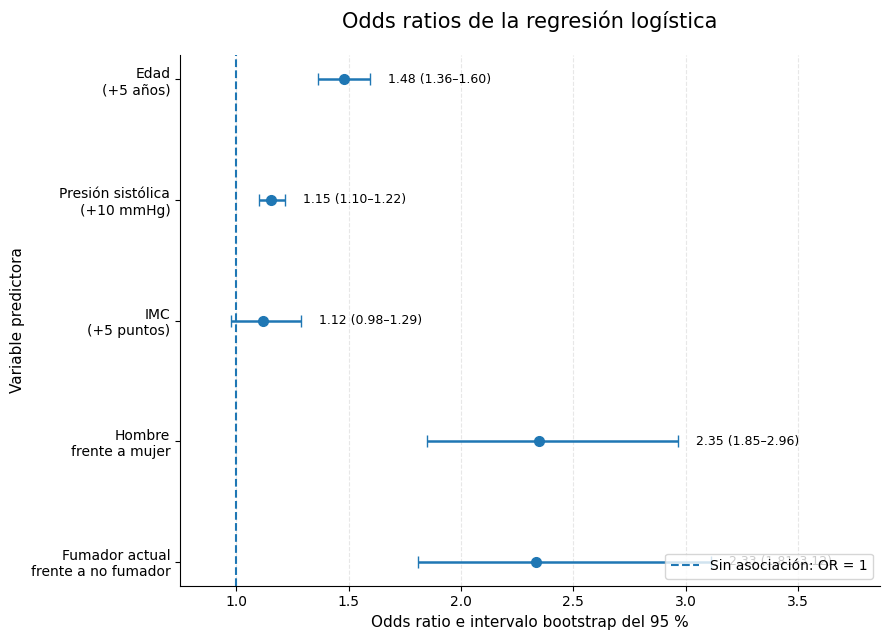

¿Se ha utilizado el conjunto de prueba?
False


In [815]:
# =========================================================
# 1. Preparamos la tabla para el gráfico
# =========================================================

tabla_forest_logistica = (
    intervalos_bootstrap_logistica
    .copy()
)


# Etiquetas más breves para el eje vertical

etiquetas_forest = {
    "EDAD": "Edad\n(+5 años)",
    "PRESION_SISTOLICA": "Presión sistólica\n(+10 mmHg)",
    "IMC": "IMC\n(+5 puntos)",
    "HOMBRE": "Hombre\nfrente a mujer",
    "FUMADOR_ACTUAL": "Fumador actual\nfrente a no fumador"
}


tabla_forest_logistica["ETIQUETA"] = (
    tabla_forest_logistica["VARIABLE"]
    .astype(str)
    .map(etiquetas_forest)
)


# Invertimos el orden para mostrar la edad arriba

tabla_forest_logistica = (
    tabla_forest_logistica
    .iloc[::-1]
    .reset_index(drop=True)
)


# =========================================================
# 2. Calculamos la longitud de las barras de error
# =========================================================

errores_inferiores = (
    tabla_forest_logistica["OR_MODELO_PRINCIPAL"]
    - tabla_forest_logistica["IC_2_5"]
)

errores_superiores = (
    tabla_forest_logistica["IC_97_5"]
    - tabla_forest_logistica["OR_MODELO_PRINCIPAL"]
)


errores_forest = np.vstack([
    errores_inferiores,
    errores_superiores
])


# =========================================================
# 3. Creamos el forest plot
# =========================================================

fig, ax = plt.subplots(figsize=(9, 6.5))

posiciones = np.arange(
    len(tabla_forest_logistica)
)


ax.errorbar(
    tabla_forest_logistica["OR_MODELO_PRINCIPAL"],
    posiciones,
    xerr=errores_forest,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.8
)


# Línea de referencia:
# OR = 1 representa ausencia de asociación

ax.axvline(
    1,
    linestyle="--",
    linewidth=1.5,
    label="Sin asociación: OR = 1"
)


# Etiquetas de las variables

ax.set_yticks(
    posiciones,
    labels=tabla_forest_logistica["ETIQUETA"]
)


ax.set_title(
    "Odds ratios de la regresión logística",
    fontsize=15,
    pad=20
)

ax.set_xlabel(
    "Odds ratio e intervalo bootstrap del 95 %",
    fontsize=11
)

ax.set_ylabel(
    "Variable predictora",
    fontsize=11
)


# Añadimos el valor numérico al lado de cada intervalo

for posicion, fila in tabla_forest_logistica.iterrows():

    texto = (
        f"{fila['OR_MODELO_PRINCIPAL']:.2f} "
        f"({fila['IC_2_5']:.2f}–{fila['IC_97_5']:.2f})"
    )

    ax.text(
        fila["IC_97_5"] + 0.08,
        posicion,
        texto,
        va="center",
        fontsize=9
    )


# Dejamos espacio suficiente para las etiquetas numéricas

limite_superior_x = (
    tabla_forest_logistica["IC_97_5"].max()
    + 0.75
)

ax.set_xlim(
    0.75,
    limite_superior_x
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()


print("¿Se ha utilizado el conjunto de prueba?")
print(False)

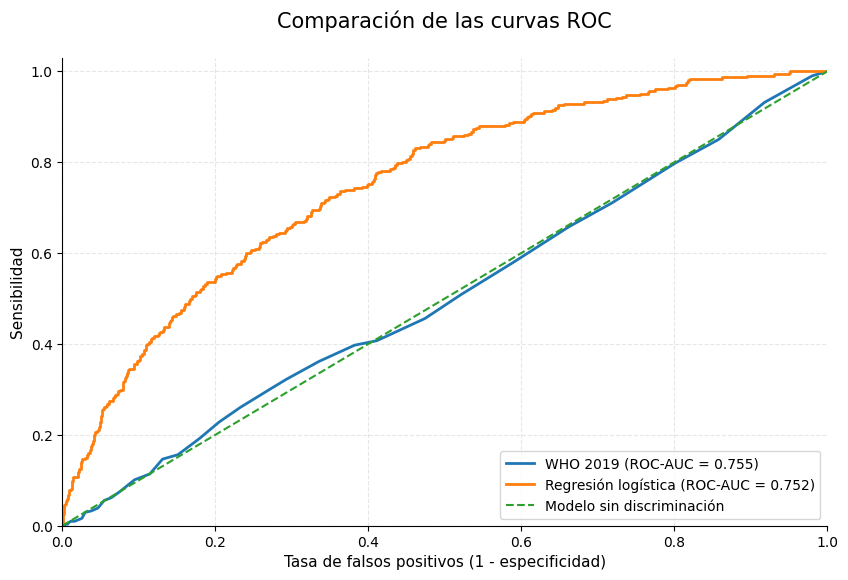

In [816]:
from sklearn.metrics import roc_curve


# Calculamos las curvas ROC

fpr_who_comparacion, tpr_who_comparacion, _ = roc_curve(
    y_train,
    probabilidades_who_train
)

fpr_logistica_comparacion, tpr_logistica_comparacion, _ = roc_curve(
    y_train,
    probabilidades_logistica_oof
)


# Creamos el gráfico

fig, ax = plt.subplots(figsize=(9, 6.5))

ax.plot(
    fpr_who_comparacion,
    tpr_who_comparacion,
    linewidth=2,
    label=(
        "WHO 2019 "
        f"(ROC-AUC = {roc_auc_who_train:.3f})"
    )
)

ax.plot(
    fpr_logistica_comparacion,
    tpr_logistica_comparacion,
    linewidth=2,
    label=(
        "Regresión logística "
        f"(ROC-AUC = {roc_auc_logistica_oof:.3f})"
    )
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Modelo sin discriminación"
)


# Título y ejes

ax.set_title(
    "Comparación de las curvas ROC",
    fontsize=15,
    pad=22
)

ax.set_xlabel(
    "Tasa de falsos positivos (1 - especificidad)",
    fontsize=11
)

ax.set_ylabel(
    "Sensibilidad",
    fontsize=11
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.03)


# Diseño

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="lower right",
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(
    top=0.86,
    bottom=0.14,
    left=0.12,
    right=0.97
)

plt.show()

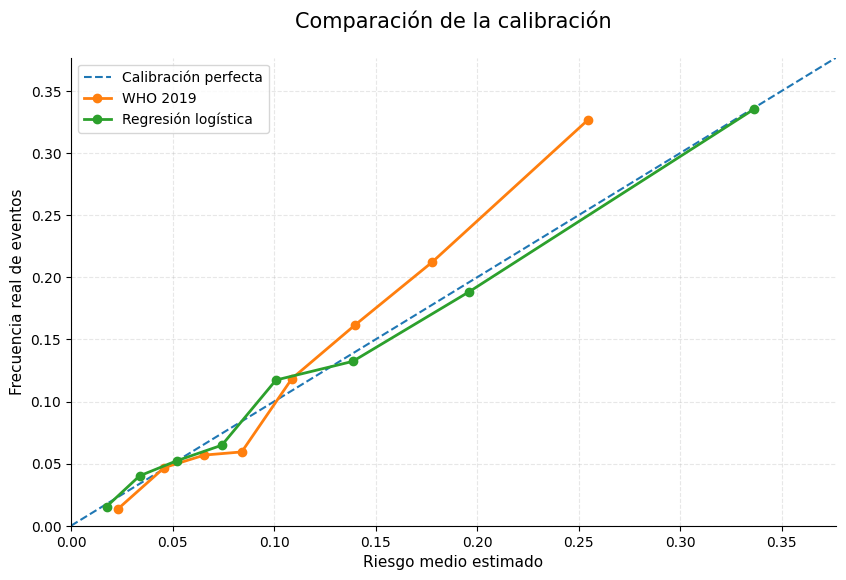

Participantes incluidos en la comparación:
2596

¿Se ha utilizado el conjunto de prueba?
False


In [817]:
# Determinamos un límite común para ambos ejes

limite_calibracion = max(
    probabilidad_media_who.max(),
    fraccion_positivos_who.max(),
    probabilidad_media_logistica.max(),
    fraccion_positivos_logistica.max()
) * 1.12


# Creamos el gráfico

fig, ax = plt.subplots(figsize=(9, 6.5))


# Línea de calibración perfecta

ax.plot(
    [0, limite_calibracion],
    [0, limite_calibracion],
    linestyle="--",
    linewidth=1.5,
    label="Calibración perfecta"
)


# Modelo WHO

ax.plot(
    probabilidad_media_who,
    fraccion_positivos_who,
    marker="o",
    linewidth=2,
    label="WHO 2019"
)


# Regresión logística

ax.plot(
    probabilidad_media_logistica,
    fraccion_positivos_logistica,
    marker="o",
    linewidth=2,
    label="Regresión logística"
)


# Título y ejes

ax.set_title(
    "Comparación de la calibración",
    fontsize=15,
    pad=22
)

ax.set_xlabel(
    "Riesgo medio estimado",
    fontsize=11
)

ax.set_ylabel(
    "Frecuencia real de eventos",
    fontsize=11
)

ax.set_xlim(
    0,
    limite_calibracion
)

ax.set_ylim(
    0,
    limite_calibracion
)


# Diseño

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left",
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(
    top=0.86,
    bottom=0.14,
    left=0.12,
    right=0.97
)

plt.show()


print("Participantes incluidos en la comparación:")
print(len(y_train))

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

## Fase 5.2 — Construcción y validación interna de la regresión logística

### 1. Objetivo del bloque

El segundo enfoque predictivo desarrollado fue una regresión logística.

Este modelo estima la probabilidad de sufrir un evento cardiovascular durante los siguientes diez años a partir de:

- Edad.
- Sexo.
- Tabaquismo actual.
- Presión arterial sistólica.
- Índice de masa corporal.

A diferencia de WHO 2019, la regresión logística aprende sus coeficientes utilizando los datos del conjunto de entrenamiento y emplea los valores continuos exactos de edad, presión e IMC.

---

### 2. Preprocesamiento

La regresión logística se integró en una `Pipeline` para evitar fugas de información.

Las variables continuas fueron estandarizadas:

- Edad.
- Presión arterial sistólica.
- IMC.

Las variables binarias conservaron su codificación original:

- Hombre: 1; mujer: 0.
- Fumador actual: 1; no fumador actual: 0.

Durante la validación cruzada, el escalado se calculó únicamente con las observaciones utilizadas para entrenar cada fold.

---

### 3. Configuración inicial

La configuración inicial utilizó:

- Regularización L2.
- Parámetro `C = 1`.
- Umbral de clasificación predeterminado de 0,50.
- Validación cruzada estratificada de cinco folds.

Resultados medios de validación:

- ROC-AUC: **0,7535**.
- Recall: **0,0458**.
- Precision: **0,7400**.
- F1-score: **0,0854**.
- Accuracy: **0,8848**.
- Balanced accuracy: **0,5215**.
- Especificidad: **0,9974**.
- Brier score: **0,0939**.

El ROC-AUC y el Brier score mostraron que las probabilidades contenían información útil. Sin embargo, el umbral de 0,50 resultó inadecuado porque solo detectaba aproximadamente el 4,6 % de los eventos.

La elevada accuracy se debía principalmente al predominio de la clase negativa.

---

### 4. Diferencias entre entrenamiento y validación

Los resultados de entrenamiento y validación fueron muy similares.

Por ejemplo:

- ROC-AUC en entrenamiento: **0,7563**.
- ROC-AUC en validación: **0,7535**.
- Diferencia aproximada: **0,0028**.

No se observaron señales relevantes de sobreajuste en la configuración inicial.

---

### 5. Ajuste de hiperparámetros

Se compararon 18 configuraciones mediante validación cruzada:

- Regularización L1 y L2.
- Valores de `C` entre 0,01 y 100.
- Solver `liblinear`.

La configuración seleccionada fue:

- Regularización: **L2**.
- `C = 3`.
- Solver: **liblinear**.

Su ROC-AUC medio de validación fue:

- **0,7536**.

La mejora respecto a la configuración inicial fue mínima. Esto indica que el rendimiento de la regresión logística era estable ante distintos niveles razonables de regularización.

Las configuraciones con regularización excesivamente fuerte, especialmente `C = 0,01`, presentaron un rendimiento inferior.

---

### 6. Predicciones out-of-fold

Para evaluar el modelo y seleccionar el umbral se generaron probabilidades `out-of-fold`.

Cada participante del entrenamiento recibió una predicción procedente de un modelo que no había sido ajustado con sus propios datos.

Se obtuvieron:

- 2.596 probabilidades.
- Ningún valor ausente.
- Una predicción para cada participante del entrenamiento.

Este procedimiento proporciona una estimación más realista que predecir sobre los mismos datos utilizados para ajustar el modelo.

---

### 7. Rendimiento probabilístico out-of-fold

Los resultados fueron:

- ROC-AUC: **0,7521**.
- Average Precision: **0,3070**.
- Brier score: **0,0939**.
- Prevalencia observada: **11,83 %**.
- Riesgo medio estimado: **11,87 %**.

La diferencia entre el riesgo medio estimado y la prevalencia observada fue de aproximadamente:

- **0,05 puntos porcentuales**.

Esto indica una calibración global muy buena.

---

### 8. Curva de calibración

La curva de calibración mostró que las probabilidades estimadas estaban próximas a las frecuencias reales de eventos.

Algunos resultados por grupos fueron:

- Riesgo estimado de 5,21 % frente a 5,23 % observado.
- Riesgo estimado de 13,87 % frente a 13,23 % observado.
- Riesgo estimado de 19,60 % frente a 18,83 % observado.
- Riesgo estimado de 33,64 % frente a 33,54 % observado.

La mayor diferencia apareció en el grupo con un riesgo medio estimado del 10,09 %, donde la frecuencia observada fue del 11,73 %.

En general, la regresión logística presentó una calibración interna muy próxima a la diagonal de calibración perfecta.

---

### 9. Selección del umbral principal

Se analizaron distintos puntos de corte utilizando exclusivamente las probabilidades out-of-fold.

El umbral predeterminado del 50 % fue descartado porque presentaba:

- Sensibilidad: **4,56 %**.
- Especificidad: **99,69 %**.
- Balanced accuracy: **52,13 %**.

El umbral que maximizó el índice de Youden fue:

- **11,23 %**.

Resultados con este punto de corte:

- Sensibilidad: **72,31 %**.
- Especificidad: **65,18 %**.
- Precision: **21,79 %**.
- F1-score: **0,3348**.
- Accuracy: **66,02 %**.
- Balanced accuracy: **68,75 %**.

Este umbral se eligió como principal porque ofrecía el mejor equilibrio entre sensibilidad y especificidad.

---

### 10. Umbral alternativo

El umbral que maximizó el F1-score fue:

- **17,82 %**.

Resultados:

- Sensibilidad: **51,47 %**.
- Especificidad: **82,57 %**.
- Precision: **28,37 %**.
- F1-score: **0,3657**.
- Balanced accuracy: **67,02 %**.

Este umbral genera menos falsos positivos, pero deja escapar aproximadamente la mitad de los eventos.

Se conservará como alternativa para un análisis de sensibilidad.

---

### 11. Matriz de confusión con el umbral principal

Utilizando el umbral del 11,23 %, se obtuvieron:

- **1.492 verdaderos negativos**.
- **797 falsos positivos**.
- **85 falsos negativos**.
- **222 verdaderos positivos**.

El modelo detectó:

- 222 de los 307 eventos reales.
- Aproximadamente el 72,3 % de los casos positivos.

Las clasificaciones proceden de predicciones out-of-fold, por lo que cada participante fue evaluado por un modelo que no había sido entrenado con sus propios datos.

---

### 12. Interpretación de los coeficientes

Los coeficientes se transformaron en odds ratios utilizando unidades clínicamente más comprensibles.

Manteniendo constantes las demás variables:

- Por cada 5 años adicionales de edad, las odds aumentaron aproximadamente un **48,0 %**.
- Por cada 10 mmHg adicionales de presión sistólica, las odds aumentaron aproximadamente un **15,5 %**.
- Por cada 5 puntos adicionales de IMC, las odds aumentaron aproximadamente un **11,8 %**.
- Ser hombre frente a mujer multiplicó las odds aproximadamente por **2,35**.
- Ser fumador actual frente a no fumador las multiplicó aproximadamente por **2,33**.

Los odds ratios no representan incrementos directos de probabilidad y no demuestran causalidad.

---

### 13. Estabilidad mediante bootstrap

Se realizaron 500 muestras bootstrap para estudiar la estabilidad de los odds ratios.

Resultados:

#### Edad, por cada 5 años

- Odds ratio principal: **1,48**.
- Intervalo bootstrap del 95 %: **1,37–1,60**.

#### Presión sistólica, por cada 10 mmHg

- Odds ratio principal: **1,16**.
- Intervalo bootstrap del 95 %: **1,10–1,22**.

#### IMC, por cada 5 puntos

- Odds ratio principal: **1,12**.
- Intervalo bootstrap del 95 %: **0,98–1,29**.

#### Hombre frente a mujer

- Odds ratio principal: **2,35**.
- Intervalo bootstrap del 95 %: **1,85–2,96**.

#### Fumador actual frente a no fumador

- Odds ratio principal: **2,34**.
- Intervalo bootstrap del 95 %: **1,81–3,12**.

Edad, presión, sexo y tabaquismo presentaron intervalos completamente superiores a 1.

El intervalo del IMC incluyó ligeramente el valor 1, mostrando una mayor incertidumbre sobre su asociación lineal ajustada.

---

### 14. Comparación interna con WHO 2019

Los dos modelos mostraron una capacidad de discriminación muy parecida:

- WHO 2019: ROC-AUC **0,7545**.
- Regresión logística: ROC-AUC **0,7521**.

La diferencia fue muy pequeña y no permite afirmar una superioridad clara en discriminación.

La regresión logística presentó ventajas provisionales en:

- Average Precision: 0,3070 frente a 0,2029.
- Brier score: 0,0939 frente a 0,0948.
- Mejor correspondencia entre el riesgo medio estimado y la prevalencia observada.
- Mejor calibración en los grupos de riesgo elevado.
- Uso de valores continuos exactos.

WHO presentó una sensibilidad superior con su umbral principal:

- WHO: 80,78 %.
- Regresión logística: 72,31 %.

La regresión logística consiguió una especificidad mayor y generó menos falsos positivos:

- WHO: 977 falsos positivos.
- Regresión logística: 797 falsos positivos.

Esta comparación sigue siendo interna y provisional.

---

### 15. Prevención de fugas de información

Todas las decisiones se tomaron exclusivamente con el conjunto de entrenamiento:

- Ajuste de hiperparámetros.
- Generación de probabilidades out-of-fold.
- Selección de umbrales.
- Evaluación de calibración.
- Interpretación de coeficientes.
- Bootstrap.
- Comparación provisional con WHO.

El conjunto de prueba de 650 participantes continúa completamente reservado.

---

### 16. Resultado del bloque

La regresión logística queda configurada con:

- Regularización L2.
- `C = 3`.
- Solver `liblinear`.
- Umbral principal del 11,23 %.
- Umbral alternativo del 17,82 %.
- Cinco predictores clínicos.
- Probabilidades bien calibradas.
- Coeficientes interpretables.
- Intervalos bootstrap del 95 %.

El siguiente bloque consistirá en desarrollar Gradient Boosting como modelo de machine learning capaz de representar relaciones no lineales e interacciones entre las variables.

In [818]:
# =========================================================
# Fase 5.3 — Gradient Boosting
# Validación inicial del modelo
# =========================================================

# Evaluamos el pipeline inicial de Gradient Boosting
# mediante la misma validación cruzada estratificada.

resultados_gb_base_cv = cross_validate(
    estimator=pipeline_gradient_boosting,
    X=X_train,
    y=y_train,
    cv=validacion_cruzada,
    scoring=metricas_validacion,
    return_train_score=True,
    n_jobs=-1
)


# =========================================================
# Resumimos las métricas
# =========================================================

resumen_gb_base = []


for nombre_metrica in metricas_validacion:

    valores_train = resultados_gb_base_cv[
        f"train_{nombre_metrica}"
    ].copy()

    valores_validacion = resultados_gb_base_cv[
        f"test_{nombre_metrica}"
    ].copy()

    nombre_presentacion = nombre_metrica


    # El Brier score aparece con signo negativo
    # en el sistema de scoring de scikit-learn.

    if nombre_metrica == "brier_negativo":

        valores_train = -valores_train
        valores_validacion = -valores_validacion

        nombre_presentacion = "brier_score"


    resumen_gb_base.append({
        "METRICA": nombre_presentacion,
        "MEDIA_TRAIN": valores_train.mean(),
        "MEDIA_VALIDACION": valores_validacion.mean(),
        "DESVIACION_VALIDACION": valores_validacion.std(),
        "MINIMO_VALIDACION": valores_validacion.min(),
        "MAXIMO_VALIDACION": valores_validacion.max(),
        "DIFERENCIA_TRAIN_VALIDACION": (
            valores_train.mean()
            - valores_validacion.mean()
        )
    })


tabla_gb_base_cv = pd.DataFrame(
    resumen_gb_base
)


print(
    "Resultados iniciales de Gradient Boosting "
    "mediante validación cruzada:"
)

display(
    tabla_gb_base_cv.round(4)
)


# =========================================================
# Comparación provisional con WHO y regresión logística
# =========================================================

comparacion_inicial_modelos = pd.DataFrame({
    "MODELO": [
        "WHO 2019",
        "Regresión logística",
        "Gradient Boosting inicial"
    ],
    "ROC_AUC": [
        roc_auc_who_train,
        roc_auc_logistica_oof,
        tabla_gb_base_cv.loc[
            tabla_gb_base_cv["METRICA"] == "roc_auc",
            "MEDIA_VALIDACION"
        ].iloc[0]
    ],
    "BRIER_SCORE": [
        brier_who_train,
        brier_logistica_oof,
        tabla_gb_base_cv.loc[
            tabla_gb_base_cv["METRICA"] == "brier_score",
            "MEDIA_VALIDACION"
        ].iloc[0]
    ],
    "BALANCED_ACCURACY": [
        balanced_accuracy_who_10,
        balanced_accuracy_logistica,
        tabla_gb_base_cv.loc[
            tabla_gb_base_cv["METRICA"] == "balanced_accuracy",
            "MEDIA_VALIDACION"
        ].iloc[0]
    ]
})


print(
    "\nComparación provisional de los tres modelos:"
)

display(
    comparacion_inicial_modelos.round(4)
)


# =========================================================
# Comprobaciones
# =========================================================

print("\nNúmero de folds evaluados:")
print(validacion_cruzada.get_n_splits())

print("\nParticipantes utilizados:")
print(len(X_train))

print("\nParticipantes reservados para test:")
print(len(X_test))

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Resultados iniciales de Gradient Boosting mediante validación cruzada:


,METRICA,MEDIA_TRAIN,MEDIA_VALIDACION,DESVIACION_VALIDACION,MINIMO_VALIDACION,MAXIMO_VALIDACION,DIFERENCIA_TRAIN_VALIDACION
0,roc_auc,0.8831,0.7327,0.0311,0.6837,0.7601,0.1504
1,recall,0.2207,0.0748,0.0162,0.0492,0.0968,0.1458
2,precision,0.9247,0.3809,0.1055,0.2308,0.5556,0.5438
3,f1,0.3560,0.1245,0.0263,0.0811,0.1558,0.2315
4,accuracy,0.9057,0.8756,0.0044,0.8690,0.8827,0.0301
5,balanced_accuracy,0.6091,0.5289,0.0090,0.5137,0.5385,0.0802
6,especificidad,0.9976,0.9830,0.0045,0.9782,0.9913,0.0146
7,brier_score,0.0712,0.0996,0.0047,0.0939,0.1073,-0.0284



Comparación provisional de los tres modelos:


,MODELO,ROC_AUC,BRIER_SCORE,BALANCED_ACCURACY
0,WHO 2019,0.7545,0.0949,0.6905
1,Regresión logística,0.7521,0.0939,0.6875
2,Gradient Boosting inicial,0.7327,0.0996,0.5289



Número de folds evaluados:
5

Participantes utilizados:
2596

Participantes reservados para test:
650

¿Se ha utilizado el conjunto de prueba?
False


In [819]:
from sklearn.model_selection import GridSearchCV


# =========================================================
# 1. Definimos una búsqueda prudente de hiperparámetros
# =========================================================
#
# El objetivo es reducir el sobreajuste observado.
#
# Probamos modelos más simples:
# - árboles poco profundos;
# - pocas hojas efectivas;
# - menor tasa de aprendizaje;
# - mínimo de observaciones por hoja más alto.

parametros_gb = {
    "modelo__n_estimators": [
        50,
        100
    ],

    "modelo__learning_rate": [
        0.03,
        0.05,
        0.10
    ],

    "modelo__max_depth": [
        1,
        2
    ],

    "modelo__min_samples_leaf": [
        30,
        80
    ],

    "modelo__subsample": [
        0.8,
        1.0
    ]
}


# =========================================================
# 2. Métricas de búsqueda
# =========================================================
#
# Seleccionaremos por ROC-AUC, igual que en la regresión
# logística, pero también guardaremos el Brier score.

metricas_busqueda_gb = {
    "roc_auc": "roc_auc",
    "brier_negativo": "neg_brier_score"
}


# =========================================================
# 3. Creamos la búsqueda
# =========================================================

busqueda_gb = GridSearchCV(
    estimator=pipeline_gradient_boosting,
    param_grid=parametros_gb,
    scoring=metricas_busqueda_gb,
    refit="roc_auc",
    cv=validacion_cruzada,
    return_train_score=True,
    n_jobs=-1
)


# =========================================================
# 4. Ajustamos usando solo el conjunto de entrenamiento
# =========================================================

busqueda_gb.fit(
    X_train,
    y_train
)


# =========================================================
# 5. Convertimos los resultados en una tabla
# =========================================================

resultados_busqueda_gb = pd.DataFrame(
    busqueda_gb.cv_results_
)


tabla_busqueda_gb = resultados_busqueda_gb[
    [
        "param_modelo__n_estimators",
        "param_modelo__learning_rate",
        "param_modelo__max_depth",
        "param_modelo__min_samples_leaf",
        "param_modelo__subsample",
        "mean_train_roc_auc",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_train_brier_negativo",
        "mean_test_brier_negativo",
        "rank_test_roc_auc"
    ]
].copy()


# Convertimos el Brier score a escala normal:
# menor es mejor.

tabla_busqueda_gb["BRIER_TRAIN"] = (
    -tabla_busqueda_gb["mean_train_brier_negativo"]
)

tabla_busqueda_gb["BRIER_VALIDACION"] = (
    -tabla_busqueda_gb["mean_test_brier_negativo"]
)


# Renombramos columnas

tabla_busqueda_gb = (
    tabla_busqueda_gb
    .rename(
        columns={
            "param_modelo__n_estimators": "N_ESTIMATORS",
            "param_modelo__learning_rate": "LEARNING_RATE",
            "param_modelo__max_depth": "MAX_DEPTH",
            "param_modelo__min_samples_leaf": "MIN_SAMPLES_LEAF",
            "param_modelo__subsample": "SUBSAMPLE",
            "mean_train_roc_auc": "ROC_AUC_TRAIN",
            "mean_test_roc_auc": "ROC_AUC_VALIDACION",
            "std_test_roc_auc": "DESVIACION_ROC_AUC",
            "rank_test_roc_auc": "POSICION_ROC_AUC"
        }
    )
    .drop(
        columns=[
            "mean_train_brier_negativo",
            "mean_test_brier_negativo"
        ]
    )
)


# Calculamos diferencia train-validación para detectar sobreajuste

tabla_busqueda_gb["DIFERENCIA_TRAIN_VALIDACION"] = (
    tabla_busqueda_gb["ROC_AUC_TRAIN"]
    - tabla_busqueda_gb["ROC_AUC_VALIDACION"]
)


tabla_busqueda_gb = (
    tabla_busqueda_gb
    .sort_values(
        by="POSICION_ROC_AUC"
    )
)


print(
    "Resultados de la búsqueda de hiperparámetros "
    "de Gradient Boosting:"
)

display(
    tabla_busqueda_gb
    .head(20)
    .round(4)
)


# =========================================================
# 6. Mejor configuración encontrada
# =========================================================

print("\nMejores hiperparámetros:")
print(
    busqueda_gb.best_params_
)


print("\nMejor ROC-AUC medio de validación:")
print(
    round(
        busqueda_gb.best_score_,
        4
    )
)


mejor_pipeline_gb = (
    busqueda_gb.best_estimator_
)


# =========================================================
# 7. Comprobaciones
# =========================================================

print("\nNúmero de configuraciones comparadas:")
print(
    len(resultados_busqueda_gb)
)


print("\nParticipantes utilizados para el ajuste:")
print(
    len(X_train)
)


print("\nParticipantes reservados para test:")
print(
    len(X_test)
)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Resultados de la búsqueda de hiperparámetros de Gradient Boosting:


,N_ESTIMATORS,LEARNING_RATE,MAX_DEPTH,MIN_SAMPLES_LEAF,SUBSAMPLE,ROC_AUC_TRAIN,ROC_AUC_VALIDACION,DESVIACION_ROC_AUC,POSICION_ROC_AUC,BRIER_TRAIN,BRIER_VALIDACION,DIFERENCIA_TRAIN_VALIDACION
30,100,0.05,2,80,0.8,0.7928,0.7562,0.0299,1,0.0896,0.0941,0.0366
35,100,0.10,1,30,1.0,0.7754,0.7533,0.0299,2,0.0915,0.0940,0.0221
38,100,0.10,1,80,0.8,0.7740,0.7533,0.0304,3,0.0916,0.0941,0.0207
34,100,0.10,1,30,0.8,0.7766,0.7533,0.0292,4,0.0911,0.0942,0.0233
44,50,0.10,2,80,0.8,0.7934,0.7531,0.0277,5,0.0896,0.0943,0.0402
26,100,0.05,2,30,0.8,0.7973,0.7526,0.0278,6,0.0885,0.0948,0.0446
14,100,0.03,2,80,0.8,0.7820,0.7525,0.0276,7,0.0915,0.0946,0.0295
46,100,0.10,2,80,0.8,0.8110,0.7523,0.0292,8,0.0870,0.0947,0.0587
24,50,0.05,2,30,0.8,0.7813,0.7523,0.0298,9,0.0914,0.0951,0.0290
47,100,0.10,2,80,1.0,0.8118,0.7520,0.0281,10,0.0870,0.0950,0.0598



Mejores hiperparámetros:
{'modelo__learning_rate': 0.05, 'modelo__max_depth': 2, 'modelo__min_samples_leaf': 80, 'modelo__n_estimators': 100, 'modelo__subsample': 0.8}

Mejor ROC-AUC medio de validación:
0.7562

Número de configuraciones comparadas:
48

Participantes utilizados para el ajuste:
2596

Participantes reservados para test:
650

¿Se ha utilizado el conjunto de prueba?
False


In [820]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)


# =========================================================
# 1. Guardamos la configuración seleccionada
# =========================================================

hiperparametros_gb_seleccionados = (
    busqueda_gb.best_params_.copy()
)

modelo_gb_seleccionado = (
    mejor_pipeline_gb
)


print("Configuración seleccionada de Gradient Boosting:")
print(hiperparametros_gb_seleccionados)


# =========================================================
# 2. Generamos probabilidades out-of-fold
# =========================================================
#
# Cada participante recibe una probabilidad generada
# por un modelo que no fue entrenado con ese participante.

probabilidades_gb_oof_array = cross_val_predict(
    estimator=modelo_gb_seleccionado,
    X=X_train,
    y=y_train,
    cv=validacion_cruzada,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# Conservamos los índices originales

probabilidades_gb_oof = pd.Series(
    probabilidades_gb_oof_array,
    index=X_train.index,
    name="PROBABILIDAD_GB_OOF"
)


# =========================================================
# 3. Comprobaciones de integridad
# =========================================================

print("\nParticipantes del conjunto de entrenamiento:")
print(len(X_train))

print("\nProbabilidades out-of-fold generadas:")
print(len(probabilidades_gb_oof))

print("\nValores ausentes:")
print(probabilidades_gb_oof.isna().sum())

print("\nProbabilidad mínima y máxima:")
print(
    probabilidades_gb_oof
    .agg(["min", "max"])
)


# =========================================================
# 4. Métricas probabilísticas out-of-fold
# =========================================================

roc_auc_gb_oof = roc_auc_score(
    y_train,
    probabilidades_gb_oof
)

average_precision_gb_oof = average_precision_score(
    y_train,
    probabilidades_gb_oof
)

brier_gb_oof = brier_score_loss(
    y_train,
    probabilidades_gb_oof
)

riesgo_medio_gb_oof = (
    probabilidades_gb_oof.mean()
)

prevalencia_train = (
    y_train.mean()
)


tabla_metricas_gb_oof = pd.DataFrame({
    "METRICA": [
        "ROC-AUC",
        "Average precision",
        "Brier score",
        "Prevalencia observada",
        "Riesgo medio estimado",
        "Diferencia estimado - observado"
    ],
    "VALOR": [
        roc_auc_gb_oof,
        average_precision_gb_oof,
        brier_gb_oof,
        prevalencia_train,
        riesgo_medio_gb_oof,
        riesgo_medio_gb_oof - prevalencia_train
    ]
})


print(
    "\nEvaluación probabilística out-of-fold "
    "de Gradient Boosting:"
)

display(
    tabla_metricas_gb_oof.round(4)
)


# =========================================================
# 5. Comparación probabilística interna
# =========================================================

comparacion_probabilistica_tres_modelos = pd.DataFrame({
    "MODELO": [
        "WHO 2019",
        "Regresión logística",
        "Gradient Boosting"
    ],
    "ROC_AUC": [
        roc_auc_who_train,
        roc_auc_logistica_oof,
        roc_auc_gb_oof
    ],
    "AVERAGE_PRECISION": [
        average_precision_who_train,
        average_precision_logistica_oof,
        average_precision_gb_oof
    ],
    "BRIER_SCORE": [
        brier_who_train,
        brier_logistica_oof,
        brier_gb_oof
    ],
    "RIESGO_MEDIO_ESTIMADO": [
        riesgo_medio_who_train,
        riesgo_medio_logistica_oof,
        riesgo_medio_gb_oof
    ]
})


print(
    "\nComparación probabilística interna "
    "de los tres modelos:"
)

display(
    comparacion_probabilistica_tres_modelos.round(4)
)


# =========================================================
# 6. Comprobación final
# =========================================================

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Configuración seleccionada de Gradient Boosting:
{'modelo__learning_rate': 0.05, 'modelo__max_depth': 2, 'modelo__min_samples_leaf': 80, 'modelo__n_estimators': 100, 'modelo__subsample': 0.8}

Participantes del conjunto de entrenamiento:
2596

Probabilidades out-of-fold generadas:
2596

Valores ausentes:
0

Probabilidad mínima y máxima:
min    0.018909
max    0.626636
Name: PROBABILIDAD_GB_OOF, dtype: float64

Evaluación probabilística out-of-fold de Gradient Boosting:


,METRICA,VALOR
0,ROC-AUC,0.7544
1,Average precision,0.3005
2,Brier score,0.0941
3,Prevalencia observada,0.1183
4,Riesgo medio estimado,0.1177
5,Diferencia estimado - observado,-0.0006



Comparación probabilística interna de los tres modelos:


,MODELO,ROC_AUC,AVERAGE_PRECISION,BRIER_SCORE,RIESGO_MEDIO_ESTIMADO
0,WHO 2019,0.7545,0.2929,0.0949,0.1076
1,Regresión logística,0.7521,0.3070,0.0939,0.1187
2,Gradient Boosting,0.7544,0.3005,0.0941,0.1177



¿Se ha utilizado el conjunto de prueba?
False


Calibración out-of-fold de Gradient Boosting:


,RIESGO_MEDIO_ESTIMADO_PCT,FRECUENCIA_REAL_EVENTOS_PCT,DIFERENCIA_PUNTOS_PCT
0,2.69,1.23,1.46
1,4.19,4.01,0.18
2,5.53,4.31,1.22
3,7.42,7.72,-0.29
4,9.81,9.26,0.55
5,12.74,15.38,-2.64
6,18.60,21.60,-3.01
7,33.16,31.08,2.08


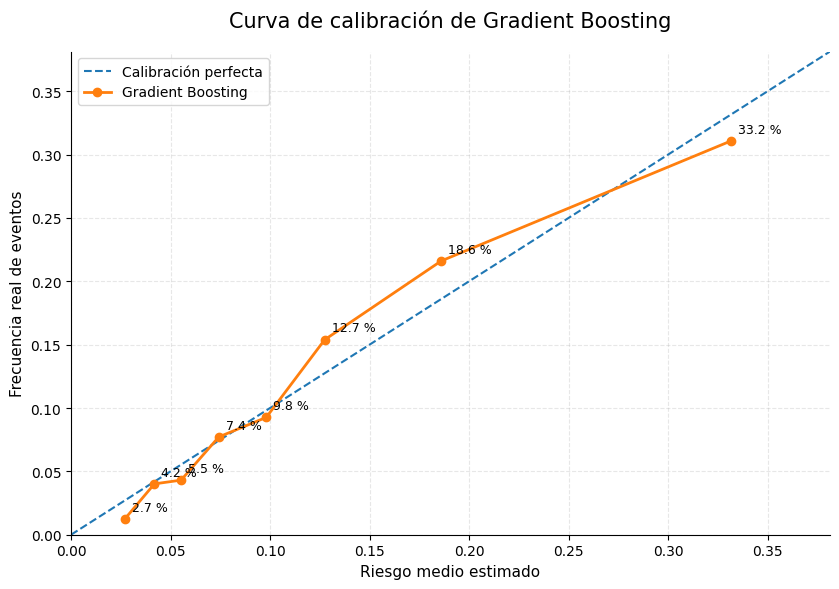


¿Se ha utilizado el conjunto de prueba?
False


In [821]:
from sklearn.calibration import calibration_curve


# =========================================================
# 1. Calculamos la curva de calibración de Gradient Boosting
# =========================================================

fraccion_positivos_gb, probabilidad_media_gb = calibration_curve(
    y_true=y_train,
    y_prob=probabilidades_gb_oof,
    n_bins=8,
    strategy="quantile"
)


# =========================================================
# 2. Creamos una tabla descriptiva
# =========================================================

tabla_calibracion_gb = pd.DataFrame({
    "RIESGO_MEDIO_ESTIMADO": probabilidad_media_gb,
    "FRECUENCIA_REAL_EVENTOS": fraccion_positivos_gb
})


tabla_calibracion_gb["RIESGO_MEDIO_ESTIMADO_PCT"] = (
    tabla_calibracion_gb["RIESGO_MEDIO_ESTIMADO"]
    .mul(100)
)

tabla_calibracion_gb["FRECUENCIA_REAL_EVENTOS_PCT"] = (
    tabla_calibracion_gb["FRECUENCIA_REAL_EVENTOS"]
    .mul(100)
)

tabla_calibracion_gb["DIFERENCIA_PUNTOS_PCT"] = (
    tabla_calibracion_gb["RIESGO_MEDIO_ESTIMADO_PCT"]
    - tabla_calibracion_gb["FRECUENCIA_REAL_EVENTOS_PCT"]
)


print(
    "Calibración out-of-fold de Gradient Boosting:"
)

display(
    tabla_calibracion_gb[
        [
            "RIESGO_MEDIO_ESTIMADO_PCT",
            "FRECUENCIA_REAL_EVENTOS_PCT",
            "DIFERENCIA_PUNTOS_PCT"
        ]
    ].round(2)
)


# =========================================================
# 3. Representamos la curva de calibración
# =========================================================

limite_grafico = max(
    probabilidad_media_gb.max(),
    fraccion_positivos_gb.max()
) * 1.15


fig, ax = plt.subplots(figsize=(8.5, 6))


# Línea de calibración perfecta

ax.plot(
    [0, limite_grafico],
    [0, limite_grafico],
    linestyle="--",
    linewidth=1.5,
    label="Calibración perfecta"
)


# Curva de Gradient Boosting

ax.plot(
    probabilidad_media_gb,
    fraccion_positivos_gb,
    marker="o",
    linewidth=2,
    label="Gradient Boosting"
)


# Etiquetamos cada punto con su riesgo medio estimado

for probabilidad, frecuencia in zip(
    probabilidad_media_gb,
    fraccion_positivos_gb
):

    ax.annotate(
        f"{probabilidad * 100:.1f} %",
        xy=(probabilidad, frecuencia),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=9
    )


ax.set_title(
    "Curva de calibración de Gradient Boosting",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Riesgo medio estimado",
    fontsize=11
)

ax.set_ylabel(
    "Frecuencia real de eventos",
    fontsize=11
)

ax.set_xlim(0, limite_grafico)
ax.set_ylim(0, limite_grafico)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

In [822]:
import numpy as np

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score
)


# =========================================================
# 1. Umbral que maximiza el índice de Youden
# =========================================================

fpr_gb, tpr_gb, umbrales_roc_gb = roc_curve(
    y_train,
    probabilidades_gb_oof
)


indice_youden_gb = (
    tpr_gb - fpr_gb
)


# Eliminamos posibles umbrales infinitos

mascara_umbrales_validos = np.isfinite(
    umbrales_roc_gb
)

indices_validos = np.where(
    mascara_umbrales_validos
)[0]


indice_mejor_youden_gb = indices_validos[
    np.argmax(
        indice_youden_gb[
            mascara_umbrales_validos
        ]
    )
]


umbral_youden_gb = (
    umbrales_roc_gb[
        indice_mejor_youden_gb
    ]
)


# =========================================================
# 2. Umbral que maximiza el F1-score
# =========================================================

precision_pr_gb, recall_pr_gb, umbrales_pr_gb = (
    precision_recall_curve(
        y_train,
        probabilidades_gb_oof
    )
)


# Precision y recall contienen un elemento más
# que el vector de umbrales

precision_para_umbrales = (
    precision_pr_gb[:-1]
)

recall_para_umbrales = (
    recall_pr_gb[:-1]
)


f1_por_umbral_gb = np.divide(
    2
    * precision_para_umbrales
    * recall_para_umbrales,

    precision_para_umbrales
    + recall_para_umbrales,

    out=np.zeros_like(
        precision_para_umbrales
    ),

    where=(
        precision_para_umbrales
        + recall_para_umbrales
    ) != 0
)


indice_mejor_f1_gb = np.argmax(
    f1_por_umbral_gb
)


umbral_f1_gb = (
    umbrales_pr_gb[
        indice_mejor_f1_gb
    ]
)


# =========================================================
# 3. Función para evaluar un umbral
# =========================================================

def evaluar_umbral_gb(nombre, umbral):
    """
    Calcula las métricas de clasificación de Gradient Boosting
    para un umbral determinado.
    """

    predicciones = (
        probabilidades_gb_oof >= umbral
    ).astype(int)


    tn, fp, fn, tp = confusion_matrix(
        y_train,
        predicciones,
        labels=[0, 1]
    ).ravel()


    sensibilidad = recall_score(
        y_train,
        predicciones,
        zero_division=0
    )


    especificidad = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    return {
        "CRITERIO": nombre,
        "UMBRAL": umbral,
        "UMBRAL_PCT": umbral * 100,
        "SENSIBILIDAD": sensibilidad,
        "ESPECIFICIDAD": especificidad,
        "PRECISION": precision_score(
            y_train,
            predicciones,
            zero_division=0
        ),
        "F1_SCORE": f1_score(
            y_train,
            predicciones,
            zero_division=0
        ),
        "ACCURACY": accuracy_score(
            y_train,
            predicciones
        ),
        "BALANCED_ACCURACY": balanced_accuracy_score(
            y_train,
            predicciones
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "PREDICCIONES_POSITIVAS": int(
            predicciones.sum()
        )
    }


# =========================================================
# 4. Comparamos distintos umbrales candidatos
# =========================================================

candidatos_umbrales_gb = [
    ("Umbral del 10 %", 0.10),
    ("Umbral del 15 %", 0.15),
    ("Umbral del 20 %", 0.20),
    ("Umbral predeterminado del 50 %", 0.50),
    (
        "Máximo índice de Youden",
        umbral_youden_gb
    ),
    (
        "Máximo F1-score",
        umbral_f1_gb
    )
]


resultados_candidatos_gb = [
    evaluar_umbral_gb(
        nombre,
        umbral
    )
    for nombre, umbral
    in candidatos_umbrales_gb
]


tabla_candidatos_gb = pd.DataFrame(
    resultados_candidatos_gb
)


print(
    "Comparación de umbrales candidatos "
    "de Gradient Boosting:"
)

display(
    tabla_candidatos_gb[
        [
            "CRITERIO",
            "UMBRAL_PCT",
            "SENSIBILIDAD",
            "ESPECIFICIDAD",
            "PRECISION",
            "F1_SCORE",
            "ACCURACY",
            "BALANCED_ACCURACY",
            "FN",
            "FP",
            "PREDICCIONES_POSITIVAS"
        ]
    ].round(4)
)


print("\nUmbral que maximiza el índice de Youden:")

print(
    round(
        umbral_youden_gb * 100,
        2
    ),
    "%"
)


print("\nUmbral que maximiza el F1-score:")

print(
    round(
        umbral_f1_gb * 100,
        2
    ),
    "%"
)


print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Comparación de umbrales candidatos de Gradient Boosting:


,CRITERIO,UMBRAL_PCT,SENSIBILIDAD,ESPECIFICIDAD,PRECISION,F1_SCORE,ACCURACY,BALANCED_ACCURACY,FN,FP,PREDICCIONES_POSITIVAS
0,Umbral del 10 %,10.0000,0.7524,0.6151,0.2077,0.3256,0.6314,0.6838,76,881,1112
1,Umbral del 15 %,15.0000,0.5570,0.7894,0.2619,0.3562,0.7619,0.6732,136,482,653
2,Umbral del 20 %,20.0000,0.3876,0.8681,0.2827,0.3269,0.8112,0.6278,188,302,421
3,Umbral predeterminado del 50 %,50.0000,0.0391,0.9965,0.6000,0.0734,0.8833,0.5178,295,8,20
4,Máximo índice de Youden,10.7343,0.7394,0.6553,0.2234,0.3432,0.6653,0.6974,80,789,1016
5,Máximo F1-score,16.6231,0.5212,0.8196,0.2792,0.3636,0.7843,0.6704,147,413,573



Umbral que maximiza el índice de Youden:
10.73 %

Umbral que maximiza el F1-score:
16.62 %

¿Se ha utilizado el conjunto de prueba?
False


Umbral principal de Gradient Boosting:
10.73 %

Umbral alternativo de Gradient Boosting:
16.62 %

Resultados out-of-fold de Gradient Boosting con el umbral principal:


,METRICA,VALOR
0,Sensibilidad,0.7394
1,Especificidad,0.6553
2,Precision,0.2234
3,F1-score,0.3432
4,Accuracy,0.6653
5,Balanced accuracy,0.6974



Componentes de la matriz de confusión:


,RESULTADO,PARTICIPANTES
0,Verdaderos negativos,1500
1,Falsos positivos,789
2,Falsos negativos,80
3,Verdaderos positivos,227


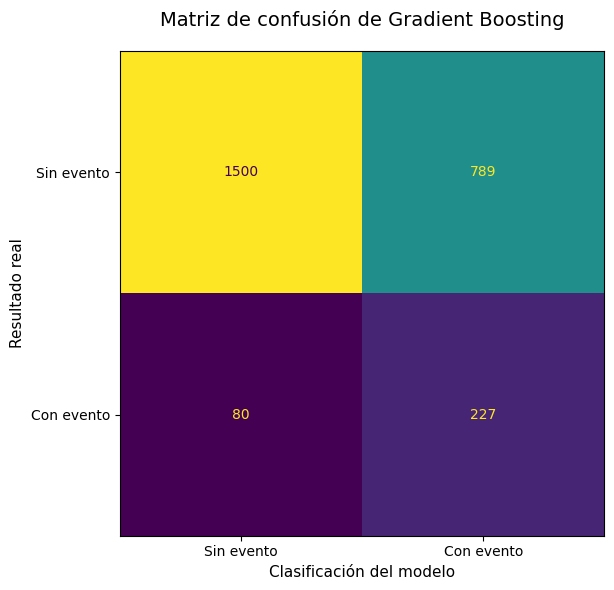


Participantes evaluados:
2596

Predicciones positivas:
1016

¿Se ha utilizado el conjunto de prueba?
False


In [823]:
from sklearn.metrics import ConfusionMatrixDisplay


# =========================================================
# 1. Fijamos los umbrales seleccionados
# =========================================================

umbral_gb_principal = float(
    umbral_youden_gb
)

umbral_gb_alternativo = float(
    umbral_f1_gb
)


print("Umbral principal de Gradient Boosting:")

print(
    f"{umbral_gb_principal * 100:.2f} %"
)


print("\nUmbral alternativo de Gradient Boosting:")

print(
    f"{umbral_gb_alternativo * 100:.2f} %"
)


# =========================================================
# 2. Convertimos las probabilidades out-of-fold
#    en clases usando el umbral principal
# =========================================================

predicciones_gb_oof = (
    probabilidades_gb_oof
    >= umbral_gb_principal
).astype(int)


# =========================================================
# 3. Calculamos la matriz de confusión
# =========================================================

matriz_confusion_gb_oof = confusion_matrix(
    y_train,
    predicciones_gb_oof,
    labels=[0, 1]
)


tn_gb, fp_gb, fn_gb, tp_gb = (
    matriz_confusion_gb_oof.ravel()
)


# =========================================================
# 4. Calculamos las métricas de clasificación
# =========================================================

sensibilidad_gb = recall_score(
    y_train,
    predicciones_gb_oof,
    zero_division=0
)


especificidad_gb = (
    tn_gb
    / (tn_gb + fp_gb)
)


precision_gb = precision_score(
    y_train,
    predicciones_gb_oof,
    zero_division=0
)


f1_gb = f1_score(
    y_train,
    predicciones_gb_oof,
    zero_division=0
)


accuracy_gb = accuracy_score(
    y_train,
    predicciones_gb_oof
)


balanced_accuracy_gb = balanced_accuracy_score(
    y_train,
    predicciones_gb_oof
)


tabla_clasificacion_gb_oof = pd.DataFrame({
    "METRICA": [
        "Sensibilidad",
        "Especificidad",
        "Precision",
        "F1-score",
        "Accuracy",
        "Balanced accuracy"
    ],
    "VALOR": [
        sensibilidad_gb,
        especificidad_gb,
        precision_gb,
        f1_gb,
        accuracy_gb,
        balanced_accuracy_gb
    ]
})


print(
    "\nResultados out-of-fold de Gradient Boosting "
    "con el umbral principal:"
)

display(
    tabla_clasificacion_gb_oof.round(4)
)


# =========================================================
# 5. Mostramos los componentes de la matriz
# =========================================================

tabla_confusion_gb = pd.DataFrame({
    "RESULTADO": [
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos"
    ],
    "PARTICIPANTES": [
        tn_gb,
        fp_gb,
        fn_gb,
        tp_gb
    ]
})


print("\nComponentes de la matriz de confusión:")

display(
    tabla_confusion_gb
)


# =========================================================
# 6. Representamos la matriz de confusión
# =========================================================

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_gb_oof,
    display_labels=[
        "Sin evento",
        "Con evento"
    ]
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)


ax.set_title(
    "Matriz de confusión de Gradient Boosting",
    fontsize=14,
    pad=18
)

ax.set_xlabel(
    "Clasificación del modelo",
    fontsize=11
)

ax.set_ylabel(
    "Resultado real",
    fontsize=11
)


plt.tight_layout()
plt.show()


# =========================================================
# 7. Comprobaciones
# =========================================================

print("\nParticipantes evaluados:")
print(len(y_train))

print("\nPredicciones positivas:")
print(int(predicciones_gb_oof.sum()))

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

In [824]:
from sklearn.inspection import permutation_importance


# =========================================================
# 1. Extraemos el modelo Gradient Boosting ajustado
# =========================================================
#
# GridSearchCV ajustó la mejor configuración utilizando
# todo el conjunto de entrenamiento.

modelo_gb_final_train = (
    mejor_pipeline_gb
    .named_steps["modelo"]
)


# =========================================================
# 2. Importancia interna del modelo
# =========================================================
#
# Gradient Boosting calcula una importancia interna
# basada en cuánto ayudan las variables a reducir el error
# dentro de los árboles.

importancias_internas_gb = (
    modelo_gb_final_train
    .feature_importances_
)


tabla_importancia_interna_gb = pd.DataFrame({
    "VARIABLE": X_train.columns,
    "IMPORTANCIA_INTERNA": importancias_internas_gb
})


tabla_importancia_interna_gb = (
    tabla_importancia_interna_gb
    .sort_values(
        by="IMPORTANCIA_INTERNA",
        ascending=False
    )
)


print("Importancia interna de variables en Gradient Boosting:")

display(
    tabla_importancia_interna_gb.round(4)
)


# =========================================================
# 3. Importancia por permutación
# =========================================================
#
# La importancia por permutación mide cuánto empeora
# el ROC-AUC cuando desordenamos una variable.
#
# Si al desordenar una variable el rendimiento cae mucho,
# esa variable era importante para el modelo.

resultado_permutacion_gb = permutation_importance(
    estimator=mejor_pipeline_gb,
    X=X_train,
    y=y_train,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)


tabla_importancia_permutacion_gb = pd.DataFrame({
    "VARIABLE": X_train.columns,
    "IMPORTANCIA_MEDIA": (
        resultado_permutacion_gb.importances_mean
    ),
    "IMPORTANCIA_DESVIACION": (
        resultado_permutacion_gb.importances_std
    )
})


tabla_importancia_permutacion_gb = (
    tabla_importancia_permutacion_gb
    .sort_values(
        by="IMPORTANCIA_MEDIA",
        ascending=False
    )
)


print("\nImportancia por permutación en Gradient Boosting:")

display(
    tabla_importancia_permutacion_gb.round(4)
)


# =========================================================
# 4. Comprobaciones
# =========================================================

print("\nVariables utilizadas por el modelo:")
print(X_train.columns.tolist())

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Importancia interna de variables en Gradient Boosting:


,VARIABLE,IMPORTANCIA_INTERNA
0,EDAD,0.4835
3,PRESION_SISTOLICA,0.1640
1,HOMBRE,0.1258
4,IMC,0.1217
2,FUMADOR_ACTUAL,0.1051



Importancia por permutación en Gradient Boosting:


,VARIABLE,IMPORTANCIA_MEDIA,IMPORTANCIA_DESVIACION
0,EDAD,0.1338,0.0109
1,HOMBRE,0.0462,0.0068
3,PRESION_SISTOLICA,0.0393,0.0052
2,FUMADOR_ACTUAL,0.0352,0.0052
4,IMC,0.0237,0.0026



Variables utilizadas por el modelo:
['EDAD', 'HOMBRE', 'FUMADOR_ACTUAL', 'PRESION_SISTOLICA', 'IMC']

¿Se ha utilizado el conjunto de prueba?
False


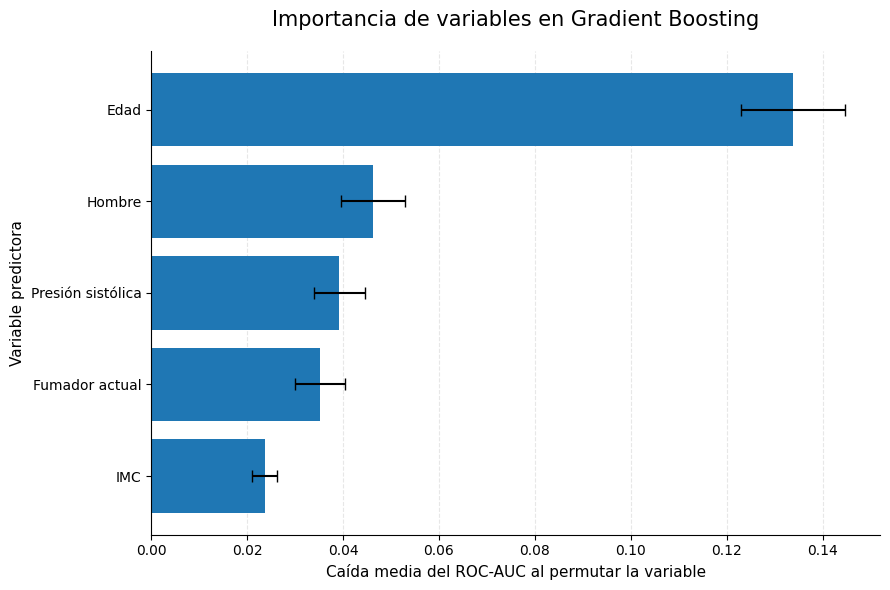

¿Se ha utilizado el conjunto de prueba?
False


In [825]:
# =========================================================
# Gráfico de importancia por permutación
# =========================================================

tabla_grafico_importancia_gb = (
    tabla_importancia_permutacion_gb
    .sort_values(
        by="IMPORTANCIA_MEDIA",
        ascending=True
    )
    .copy()
)


# Etiquetas más claras para el gráfico

etiquetas_variables_gb = {
    "EDAD": "Edad",
    "HOMBRE": "Hombre",
    "FUMADOR_ACTUAL": "Fumador actual",
    "PRESION_SISTOLICA": "Presión sistólica",
    "IMC": "IMC"
}


tabla_grafico_importancia_gb["ETIQUETA"] = (
    tabla_grafico_importancia_gb["VARIABLE"]
    .map(etiquetas_variables_gb)
)


# Creamos el gráfico

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    tabla_grafico_importancia_gb["ETIQUETA"],
    tabla_grafico_importancia_gb["IMPORTANCIA_MEDIA"],
    xerr=tabla_grafico_importancia_gb["IMPORTANCIA_DESVIACION"],
    capsize=4
)


ax.set_title(
    "Importancia de variables en Gradient Boosting",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Caída media del ROC-AUC al permutar la variable",
    fontsize=11
)

ax.set_ylabel(
    "Variable predictora",
    fontsize=11
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.show()


print("¿Se ha utilizado el conjunto de prueba?")
print(False)

In [826]:
# Tabla por grupos de riesgo de Gradient Boosting

tabla_grupos_riesgo_gb = pd.DataFrame({
    "EVENTO_REAL": y_train,
    "PROBABILIDAD_GB": probabilidades_gb_oof
})

tabla_grupos_riesgo_gb["GRUPO_NUMERICO"] = pd.qcut(
    tabla_grupos_riesgo_gb["PROBABILIDAD_GB"],
    q=5,
    labels=False,
    duplicates="drop"
)

etiquetas_grupos = {
    0: "Muy bajo",
    1: "Bajo",
    2: "Medio",
    3: "Alto",
    4: "Muy alto"
}

tabla_grupos_riesgo_gb["GRUPO_RIESGO"] = (
    tabla_grupos_riesgo_gb["GRUPO_NUMERICO"]
    .map(etiquetas_grupos)
)

resumen_grupos_riesgo_gb = (
    tabla_grupos_riesgo_gb
    .groupby(
        ["GRUPO_NUMERICO", "GRUPO_RIESGO"],
        observed=True
    )
    .agg(
        PARTICIPANTES=("EVENTO_REAL", "size"),
        RIESGO_MINIMO_PCT=("PROBABILIDAD_GB", lambda x: x.min() * 100),
        RIESGO_MEDIO_PCT=("PROBABILIDAD_GB", lambda x: x.mean() * 100),
        RIESGO_MAXIMO_PCT=("PROBABILIDAD_GB", lambda x: x.max() * 100),
        EVENTOS_REALES=("EVENTO_REAL", "sum"),
        TASA_EVENTO_REAL_PCT=("EVENTO_REAL", lambda x: x.mean() * 100)
    )
    .reset_index()
    .sort_values("GRUPO_NUMERICO")
)

total_eventos_train = y_train.sum()

resumen_grupos_riesgo_gb["PORCENTAJE_EVENTOS_CAPTURADOS"] = (
    resumen_grupos_riesgo_gb["EVENTOS_REALES"]
    / total_eventos_train
    * 100
)

print(
    "Distribución de eventos reales por grupos "
    "de riesgo estimado de Gradient Boosting:"
)

display(
    resumen_grupos_riesgo_gb[
        [
            "GRUPO_RIESGO",
            "PARTICIPANTES",
            "RIESGO_MINIMO_PCT",
            "RIESGO_MEDIO_PCT",
            "RIESGO_MAXIMO_PCT",
            "EVENTOS_REALES",
            "TASA_EVENTO_REAL_PCT",
            "PORCENTAJE_EVENTOS_CAPTURADOS"
        ]
    ].round(2)
)

print("\nParticipantes evaluados:")
print(len(tabla_grupos_riesgo_gb))

print("\nEventos reales totales:")
print(int(total_eventos_train))

print("\nEventos reales sumados en la tabla:")
print(int(resumen_grupos_riesgo_gb["EVENTOS_REALES"].sum()))

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Distribución de eventos reales por grupos de riesgo estimado de Gradient Boosting:


,GRUPO_RIESGO,PARTICIPANTES,RIESGO_MINIMO_PCT,RIESGO_MEDIO_PCT,RIESGO_MAXIMO_PCT,EVENTOS_REALES,TASA_EVENTO_REAL_PCT,PORCENTAJE_EVENTOS_CAPTURADOS
0,Muy bajo,520,1.89,3.15,4.33,11,2.12,3.58
1,Bajo,519,4.33,5.42,6.67,26,5.01,8.47
2,Medio,519,6.68,8.61,10.63,41,7.90,13.36
3,Alto,519,10.63,13.42,17.97,81,15.61,26.38
4,Muy alto,519,17.97,28.28,62.66,148,28.52,48.21



Participantes evaluados:
2596

Eventos reales totales:
307

Eventos reales sumados en la tabla:
307

¿Se ha utilizado el conjunto de prueba?
False


## Cierre de la Fase 5.3 — Gradient Boosting

En esta fase se construyó y validó internamente el modelo Gradient Boosting.

Primero se evaluó una configuración inicial, pero mostró señales claras de sobreajuste. Por ello se realizó una búsqueda de hiperparámetros para obtener un modelo más prudente y con mejor capacidad de generalización.

La configuración finalmente seleccionada fue:

- `n_estimators = 100`
- `learning_rate = 0.05`
- `max_depth = 2`
- `min_samples_leaf = 80`
- `subsample = 0.8`

Con esta configuración, Gradient Boosting obtuvo en predicciones out-of-fold:

- ROC-AUC: **0,7544**
- Average Precision: **0,3005**
- Brier score: **0,0941**
- Riesgo medio estimado: **11,77 %**
- Prevalencia observada: **11,83 %**

El umbral principal se seleccionó mediante el índice de Youden y quedó fijado en:

- **10,73 %**

Con este umbral, el modelo obtuvo:

- Sensibilidad: **73,94 %**
- Especificidad: **65,53 %**
- Precision: **22,34 %**
- F1-score: **0,3432**
- Balanced accuracy: **69,74 %**

La matriz de confusión mostró:

- **1.500 verdaderos negativos**
- **789 falsos positivos**
- **80 falsos negativos**
- **227 verdaderos positivos**

El análisis de importancia de variables mostró que la variable más relevante fue la edad, seguida de sexo, presión sistólica, tabaquismo actual e IMC.

Además, la tabla por grupos de riesgo mostró que el modelo ordena correctamente a los participantes: la tasa real de eventos aumenta desde el grupo de menor riesgo hasta el grupo de mayor riesgo.

El grupo de riesgo muy alto concentró el **48,21 % de todos los eventos reales**, lo que indica que Gradient Boosting identifica adecuadamente una parte importante de los participantes con mayor riesgo.

Todas las decisiones de esta fase se tomaron utilizando únicamente el conjunto de entrenamiento. El conjunto de prueba continúa reservado para la evaluación final.

In [827]:
# =========================================================
# Comparación interna final de los tres modelos
# =========================================================

comparacion_interna_tres_modelos = pd.DataFrame({
    "MODELO": [
        "WHO 2019",
        "Regresión logística",
        "Gradient Boosting"
    ],

    "UMBRAL_PRINCIPAL_PCT": [
        umbral_who_principal * 100,
        umbral_logistica_principal * 100,
        umbral_gb_principal * 100
    ],

    "ROC_AUC": [
        roc_auc_who_train,
        roc_auc_logistica_oof,
        roc_auc_gb_oof
    ],

    "AVERAGE_PRECISION": [
        average_precision_who_train,
        average_precision_logistica_oof,
        average_precision_gb_oof
    ],

    "BRIER_SCORE": [
        brier_who_train,
        brier_logistica_oof,
        brier_gb_oof
    ],

    "RIESGO_MEDIO_ESTIMADO_PCT": [
        riesgo_medio_who_train * 100,
        riesgo_medio_logistica_oof * 100,
        riesgo_medio_gb_oof * 100
    ],

    "SENSIBILIDAD": [
        sensibilidad_who_10,
        sensibilidad_logistica,
        sensibilidad_gb
    ],

    "ESPECIFICIDAD": [
        especificidad_who_10,
        especificidad_logistica,
        especificidad_gb
    ],

    "PRECISION": [
        precision_who_10,
        precision_logistica,
        precision_gb
    ],

    "F1_SCORE": [
        f1_who_10,
        f1_logistica,
        f1_gb
    ],

    "ACCURACY": [
        accuracy_who_10,
        accuracy_logistica,
        accuracy_gb
    ],

    "BALANCED_ACCURACY": [
        balanced_accuracy_who_10,
        balanced_accuracy_logistica,
        balanced_accuracy_gb
    ],

    "FALSOS_NEGATIVOS": [
        fn_who,
        fn_logistica,
        fn_gb
    ],

    "FALSOS_POSITIVOS": [
        fp_who,
        fp_logistica,
        fp_gb
    ],

    "VERDADEROS_POSITIVOS": [
        tp_who,
        tp_logistica,
        tp_gb
    ],

    "VERDADEROS_NEGATIVOS": [
        tn_who,
        tn_logistica,
        tn_gb
    ]
})


print("Comparación interna de los tres modelos:")

display(
    comparacion_interna_tres_modelos.round(4)
)


# =========================================================
# Diferencias principales respecto a WHO
# =========================================================

diferencias_respecto_who = comparacion_interna_tres_modelos.copy()

metricas_a_comparar = [
    "ROC_AUC",
    "AVERAGE_PRECISION",
    "BRIER_SCORE",
    "SENSIBILIDAD",
    "ESPECIFICIDAD",
    "F1_SCORE",
    "BALANCED_ACCURACY",
    "FALSOS_NEGATIVOS",
    "FALSOS_POSITIVOS"
]


valores_who = (
    diferencias_respecto_who
    .loc[
        diferencias_respecto_who["MODELO"] == "WHO 2019",
        metricas_a_comparar
    ]
    .iloc[0]
)


for metrica in metricas_a_comparar:

    diferencias_respecto_who[
        f"DIF_{metrica}_VS_WHO"
    ] = (
        diferencias_respecto_who[metrica]
        - valores_who[metrica]
    )


print("\nDiferencias respecto a WHO 2019:")

display(
    diferencias_respecto_who[
        [
            "MODELO"
        ]
        +
        [
            f"DIF_{metrica}_VS_WHO"
            for metrica in metricas_a_comparar
        ]
    ].round(4)
)


# =========================================================
# Comprobación final
# =========================================================

print("\nParticipantes incluidos en la comparación:")
print(len(y_train))

print("\n¿Se ha utilizado el conjunto de prueba?")
print(False)

Comparación interna de los tres modelos:


,MODELO,UMBRAL_PRINCIPAL_PCT,ROC_AUC,AVERAGE_PRECISION,BRIER_SCORE,RIESGO_MEDIO_ESTIMADO_PCT,SENSIBILIDAD,ESPECIFICIDAD,PRECISION,F1_SCORE,ACCURACY,BALANCED_ACCURACY,FALSOS_NEGATIVOS,FALSOS_POSITIVOS,VERDADEROS_POSITIVOS,VERDADEROS_NEGATIVOS
0,WHO 2019,10.0000,0.7545,0.2929,0.0949,10.7581,0.8078,0.5732,0.2024,0.3238,0.6009,0.6905,59,977,248,1312
1,Regresión logística,11.2266,0.7521,0.3070,0.0939,11.8734,0.7231,0.6518,0.2179,0.3348,0.6602,0.6875,85,797,222,1492
2,Gradient Boosting,10.7343,0.7544,0.3005,0.0941,11.7707,0.7394,0.6553,0.2234,0.3432,0.6653,0.6974,80,789,227,1500



Diferencias respecto a WHO 2019:


,MODELO,DIF_ROC_AUC_VS_WHO,DIF_AVERAGE_PRECISION_VS_WHO,DIF_BRIER_SCORE_VS_WHO,DIF_SENSIBILIDAD_VS_WHO,DIF_ESPECIFICIDAD_VS_WHO,DIF_F1_SCORE_VS_WHO,DIF_BALANCED_ACCURACY_VS_WHO,DIF_FALSOS_NEGATIVOS_VS_WHO,DIF_FALSOS_POSITIVOS_VS_WHO
0,WHO 2019,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0
1,Regresión logística,-0.0025,0.0141,-0.0011,-0.0847,0.0786,0.0111,-0.0030,26.0,-180.0
2,Gradient Boosting,-0.0001,0.0076,-0.0008,-0.0684,0.0821,0.0194,0.0069,21.0,-188.0



Participantes incluidos en la comparación:
2596

¿Se ha utilizado el conjunto de prueba?
False


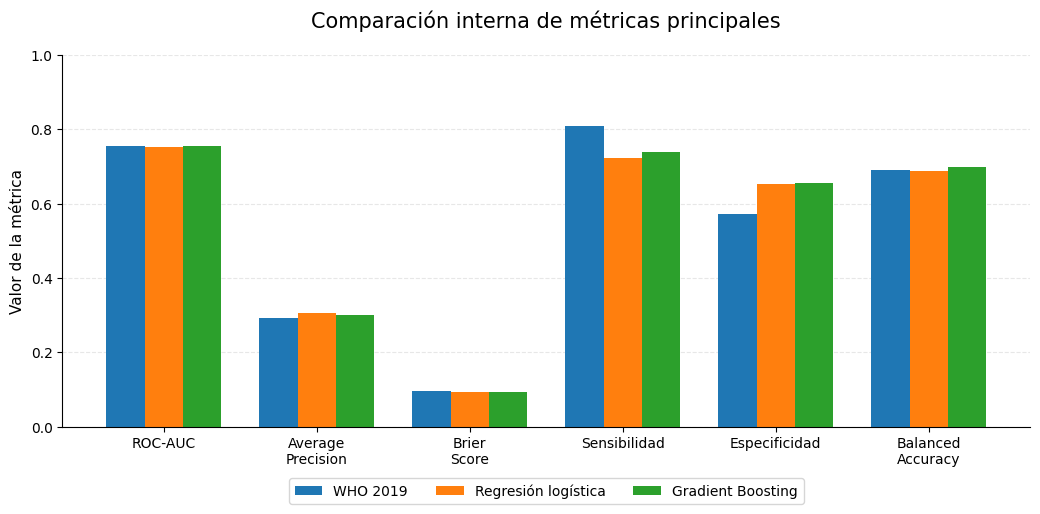

In [828]:
# =========================================================
# Gráfico 1 — Comparación de métricas principales
# =========================================================

metricas_grafico = [
    "ROC_AUC",
    "AVERAGE_PRECISION",
    "BRIER_SCORE",
    "SENSIBILIDAD",
    "ESPECIFICIDAD",
    "BALANCED_ACCURACY"
]

nombres_metricas = [
    "ROC-AUC",
    "Average\nPrecision",
    "Brier\nScore",
    "Sensibilidad",
    "Especificidad",
    "Balanced\nAccuracy"
]


tabla_grafico_metricas = (
    comparacion_interna_tres_modelos[
        ["MODELO"] + metricas_grafico
    ]
    .set_index("MODELO")
)


fig, ax = plt.subplots(figsize=(11, 6))

posiciones = np.arange(
    len(metricas_grafico)
)

ancho_barra = 0.25


for i, modelo in enumerate(tabla_grafico_metricas.index):

    ax.bar(
        posiciones + (i - 1) * ancho_barra,
        tabla_grafico_metricas.loc[modelo],
        width=ancho_barra,
        label=modelo
    )


ax.set_title(
    "Comparación interna de métricas principales",
    fontsize=15,
    pad=20
)

ax.set_ylabel(
    "Valor de la métrica",
    fontsize=11
)

ax.set_xticks(
    posiciones,
    labels=nombres_metricas
)

ax.set_ylim(0, 1)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(
    top=0.86,
    bottom=0.24,
    left=0.10,
    right=0.98
)

plt.show()

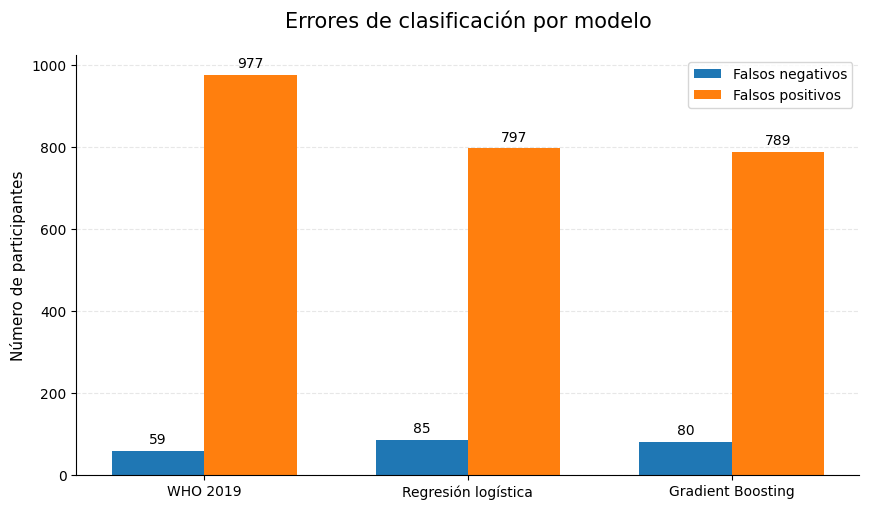

¿Se ha utilizado el conjunto de prueba?
False


In [829]:
# =========================================================
# Gráfico 2 — Comparación de errores de clasificación
# =========================================================

tabla_errores_modelos = (
    comparacion_interna_tres_modelos[
        [
            "MODELO",
            "FALSOS_NEGATIVOS",
            "FALSOS_POSITIVOS"
        ]
    ]
    .copy()
)


fig, ax = plt.subplots(figsize=(9, 6))

posiciones = np.arange(
    len(tabla_errores_modelos)
)

ancho_barra = 0.35


ax.bar(
    posiciones - ancho_barra / 2,
    tabla_errores_modelos["FALSOS_NEGATIVOS"],
    width=ancho_barra,
    label="Falsos negativos"
)

ax.bar(
    posiciones + ancho_barra / 2,
    tabla_errores_modelos["FALSOS_POSITIVOS"],
    width=ancho_barra,
    label="Falsos positivos"
)


ax.set_title(
    "Errores de clasificación por modelo",
    fontsize=15,
    pad=20
)

ax.set_ylabel(
    "Número de participantes",
    fontsize=11
)

ax.set_xticks(
    posiciones,
    labels=tabla_errores_modelos["MODELO"]
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Añadimos etiquetas numéricas

for posicion, fila in tabla_errores_modelos.iterrows():

    ax.text(
        posicion - ancho_barra / 2,
        fila["FALSOS_NEGATIVOS"] + 10,
        str(int(fila["FALSOS_NEGATIVOS"])),
        ha="center",
        va="bottom",
        fontsize=10
    )

    ax.text(
        posicion + ancho_barra / 2,
        fila["FALSOS_POSITIVOS"] + 10,
        str(int(fila["FALSOS_POSITIVOS"])),
        ha="center",
        va="bottom",
        fontsize=10
    )


fig.subplots_adjust(
    top=0.86,
    bottom=0.16,
    left=0.11,
    right=0.98
)

plt.show()


print("¿Se ha utilizado el conjunto de prueba?")
print(False)

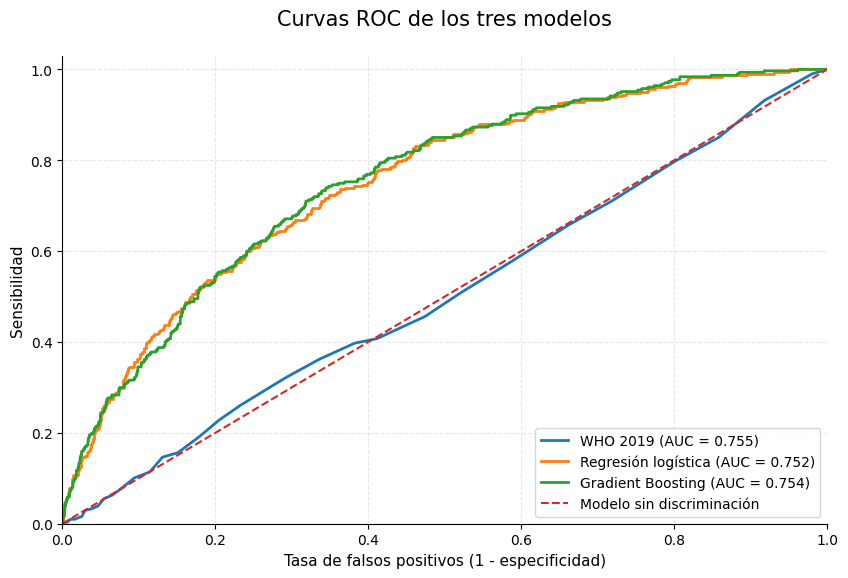

¿Se ha utilizado el conjunto de prueba?
False


In [830]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np


# =========================================================
# Gráfico 3 — Curvas ROC de los tres modelos
# =========================================================

fpr_who_grafico, tpr_who_grafico, _ = roc_curve(
    y_train,
    probabilidades_who_train
)

fpr_logistica_grafico, tpr_logistica_grafico, _ = roc_curve(
    y_train,
    probabilidades_logistica_oof
)

fpr_gb_grafico, tpr_gb_grafico, _ = roc_curve(
    y_train,
    probabilidades_gb_oof
)


fig, ax = plt.subplots(figsize=(9, 6.5))


ax.plot(
    fpr_who_grafico,
    tpr_who_grafico,
    linewidth=2,
    label=f"WHO 2019 (AUC = {roc_auc_who_train:.3f})"
)

ax.plot(
    fpr_logistica_grafico,
    tpr_logistica_grafico,
    linewidth=2,
    label=f"Regresión logística (AUC = {roc_auc_logistica_oof:.3f})"
)

ax.plot(
    fpr_gb_grafico,
    tpr_gb_grafico,
    linewidth=2,
    label=f"Gradient Boosting (AUC = {roc_auc_gb_oof:.3f})"
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Modelo sin discriminación"
)


ax.set_title(
    "Curvas ROC de los tres modelos",
    fontsize=15,
    pad=22
)

ax.set_xlabel(
    "Tasa de falsos positivos (1 - especificidad)",
    fontsize=11
)

ax.set_ylabel(
    "Sensibilidad",
    fontsize=11
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.03)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="lower right",
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(
    top=0.86,
    bottom=0.14,
    left=0.12,
    right=0.97
)

plt.show()


print("¿Se ha utilizado el conjunto de prueba?")
print(False)

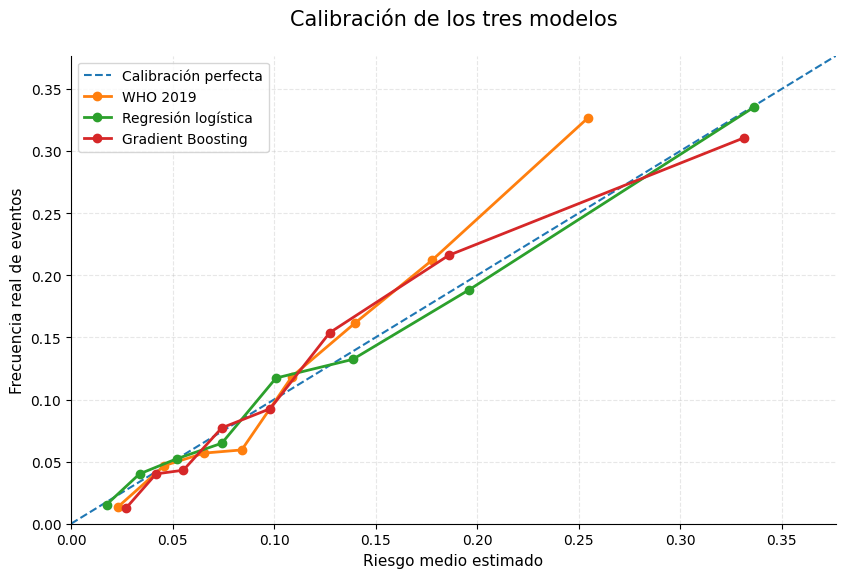

¿Se ha utilizado el conjunto de prueba?
False


In [831]:
# =========================================================
# Gráfico 4 — Calibración de los tres modelos
# =========================================================

limite_calibracion = max(
    probabilidad_media_who.max(),
    fraccion_positivos_who.max(),
    probabilidad_media_logistica.max(),
    fraccion_positivos_logistica.max(),
    probabilidad_media_gb.max(),
    fraccion_positivos_gb.max()
) * 1.12


fig, ax = plt.subplots(figsize=(9, 6.5))


ax.plot(
    [0, limite_calibracion],
    [0, limite_calibracion],
    linestyle="--",
    linewidth=1.5,
    label="Calibración perfecta"
)

ax.plot(
    probabilidad_media_who,
    fraccion_positivos_who,
    marker="o",
    linewidth=2,
    label="WHO 2019"
)

ax.plot(
    probabilidad_media_logistica,
    fraccion_positivos_logistica,
    marker="o",
    linewidth=2,
    label="Regresión logística"
)

ax.plot(
    probabilidad_media_gb,
    fraccion_positivos_gb,
    marker="o",
    linewidth=2,
    label="Gradient Boosting"
)


ax.set_title(
    "Calibración de los tres modelos",
    fontsize=15,
    pad=22
)

ax.set_xlabel(
    "Riesgo medio estimado",
    fontsize=11
)

ax.set_ylabel(
    "Frecuencia real de eventos",
    fontsize=11
)

ax.set_xlim(0, limite_calibracion)
ax.set_ylim(0, limite_calibracion)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left",
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(
    top=0.86,
    bottom=0.14,
    left=0.12,
    right=0.97
)

plt.show()


print("¿Se ha utilizado el conjunto de prueba?")
print(False)

Riesgo medio estimado según el resultado real:


,WHO 2019,Regresión logística,Gradient Boosting
Sin evento,9.92,10.66,10.63
Con evento,17.00,20.90,20.24


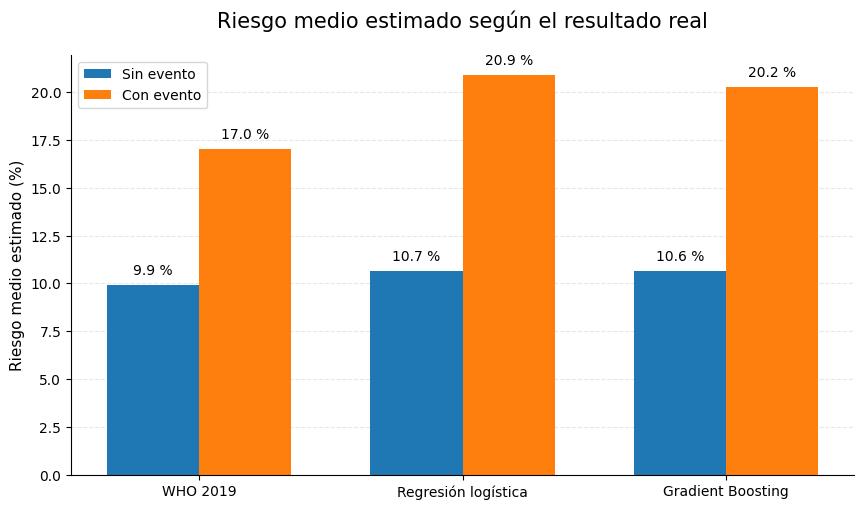

¿Se ha utilizado el conjunto de prueba?
False


In [832]:
# =========================================================
# Gráfico 5 — Riesgo medio estimado según resultado real
# =========================================================

probabilidades_comparacion = pd.DataFrame({
    "RESULTADO_REAL": y_train,
    "WHO 2019": probabilidades_who_train.loc[y_train.index],
    "Regresión logística": probabilidades_logistica_oof.loc[y_train.index],
    "Gradient Boosting": probabilidades_gb_oof.loc[y_train.index]
})


resumen_riesgo_por_resultado = (
    probabilidades_comparacion
    .groupby("RESULTADO_REAL")[
        [
            "WHO 2019",
            "Regresión logística",
            "Gradient Boosting"
        ]
    ]
    .mean()
    .mul(100)
)


resumen_riesgo_por_resultado.index = [
    "Sin evento",
    "Con evento"
]


print("Riesgo medio estimado según el resultado real:")

display(
    resumen_riesgo_por_resultado.round(2)
)


modelos = resumen_riesgo_por_resultado.columns.tolist()

posiciones = np.arange(
    len(modelos)
)

ancho_barra = 0.35


fig, ax = plt.subplots(figsize=(9, 6))


ax.bar(
    posiciones - ancho_barra / 2,
    resumen_riesgo_por_resultado.loc["Sin evento"],
    width=ancho_barra,
    label="Sin evento"
)

ax.bar(
    posiciones + ancho_barra / 2,
    resumen_riesgo_por_resultado.loc["Con evento"],
    width=ancho_barra,
    label="Con evento"
)


ax.set_title(
    "Riesgo medio estimado según el resultado real",
    fontsize=15,
    pad=20
)

ax.set_ylabel(
    "Riesgo medio estimado (%)",
    fontsize=11
)

ax.set_xticks(
    posiciones,
    labels=modelos
)


for i, modelo in enumerate(modelos):

    valor_sin_evento = resumen_riesgo_por_resultado.loc[
        "Sin evento",
        modelo
    ]

    valor_con_evento = resumen_riesgo_por_resultado.loc[
        "Con evento",
        modelo
    ]

    ax.text(
        i - ancho_barra / 2,
        valor_sin_evento + 0.4,
        f"{valor_sin_evento:.1f} %",
        ha="center",
        va="bottom",
        fontsize=10
    )

    ax.text(
        i + ancho_barra / 2,
        valor_con_evento + 0.4,
        f"{valor_con_evento:.1f} %",
        ha="center",
        va="bottom",
        fontsize=10
    )


ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(
    top=0.86,
    bottom=0.16,
    left=0.11,
    right=0.98
)

plt.show()


print("¿Se ha utilizado el conjunto de prueba?")
print(False)

## Fase 5.4 — Comparación interna provisional de los tres modelos

Una vez construidos los tres modelos, se realizó una comparación interna utilizando únicamente el conjunto de entrenamiento.

Los modelos comparados fueron:

- WHO 2019.
- Regresión logística.
- Gradient Boosting.

Esta comparación todavía no representa la evaluación final del proyecto, porque el conjunto de prueba no ha sido utilizado. Su objetivo es resumir el comportamiento relativo de los modelos antes de pasar a la evaluación final en test.

En términos de ROC-AUC, los tres modelos presentaron resultados muy parecidos:

- WHO 2019: **0,7545**.
- Regresión logística: **0,7521**.
- Gradient Boosting: **0,7544**.

Las diferencias fueron muy pequeñas, por lo que no se puede afirmar que un modelo sea claramente superior en discriminación dentro del conjunto de entrenamiento.

La regresión logística destacó por:

- Mejor Brier score.
- Mejor Average Precision.
- Muy buena calibración.
- Mayor interpretabilidad mediante odds ratios.

Gradient Boosting destacó por:

- Mejor balanced accuracy.
- Mejor F1-score.
- Menor número de falsos positivos que WHO.
- Buena capacidad para ordenar a los participantes por grupos de riesgo.

WHO 2019 destacó por:

- Mayor sensibilidad.
- Mayor número de eventos detectados.
- Interpretación clínica directa.

Sin embargo, WHO también generó más falsos positivos que los modelos entrenados con los datos.

La conclusión provisional es que ningún modelo domina claramente en todas las métricas:

- WHO 2019 prioriza la detección de eventos.
- La regresión logística ofrece el mejor equilibrio entre calibración e interpretabilidad.
- Gradient Boosting mejora ligeramente el equilibrio de clasificación.

Esta comparación sigue siendo provisional. La comparación definitiva se realizará en la siguiente fase utilizando por primera vez el conjunto de prueba reservado.

In [833]:
# =========================================================
# Fase 6.1 — Comprobación inicial antes de evaluar en test
# =========================================================

import pandas as pd
import numpy as np


# 1. Comprobamos que existen los objetos necesarios

objetos_necesarios_fase_6 = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "mejor_pipeline_logistica",
    "mejor_pipeline_gb",
    "umbral_who_principal",
    "umbral_logistica_principal",
    "umbral_gb_principal"
]

objetos_faltantes_fase_6 = []

for objeto in objetos_necesarios_fase_6:
    if objeto not in globals():
        objetos_faltantes_fase_6.append(objeto)


print("Comprobación de objetos necesarios para la Fase 6:")

if len(objetos_faltantes_fase_6) == 0:
    print("Todos los objetos necesarios están disponibles.")
else:
    print("Faltan los siguientes objetos:")
    print(objetos_faltantes_fase_6)


# 2. Dimensiones de train y test

if len(objetos_faltantes_fase_6) == 0:

    tabla_dimensiones_fase_6 = pd.DataFrame({
        "CONJUNTO": ["Entrenamiento", "Test"],
        "PARTICIPANTES": [len(X_train), len(X_test)],
        "VARIABLES_PREDICTORAS": [X_train.shape[1], X_test.shape[1]],
        "EVENTOS": [int(y_train.sum()), int(y_test.sum())],
        "NO_EVENTOS": [
            int((y_train == 0).sum()),
            int((y_test == 0).sum())
        ],
        "PREVALENCIA_EVENTO_PCT": [
            y_train.mean() * 100,
            y_test.mean() * 100
        ]
    })

    print("\nDimensiones y distribución de la variable objetivo:")

    display(
        tabla_dimensiones_fase_6.round(2)
    )


# 3. Comprobación de columnas

if len(objetos_faltantes_fase_6) == 0:

    columnas_train = list(X_train.columns)
    columnas_test = list(X_test.columns)

    print("\n¿Train y test tienen exactamente las mismas columnas?")
    print(columnas_train == columnas_test)

    print("\nColumnas utilizadas por los modelos:")
    print(columnas_train)


# 4. Comprobación de participantes repetidos

if len(objetos_faltantes_fase_6) == 0:

    participantes_comunes = set(X_train.index).intersection(
        set(X_test.index)
    )

    print("\nParticipantes presentes tanto en train como en test:")
    print(len(participantes_comunes))


# 5. Umbrales finales fijados antes de usar test

if len(objetos_faltantes_fase_6) == 0:

    tabla_umbrales_finales = pd.DataFrame({
        "MODELO": [
            "WHO 2019",
            "Regresión logística",
            "Gradient Boosting"
        ],
        "UMBRAL_FINAL_PCT": [
            umbral_who_principal * 100,
            umbral_logistica_principal * 100,
            umbral_gb_principal * 100
        ],
        "ORIGEN_DEL_UMBRAL": [
            "Seleccionado antes del test",
            "Seleccionado antes del test",
            "Seleccionado antes del test"
        ]
    })

    print("\nUmbrales finales fijados antes de evaluar en test:")

    display(
        tabla_umbrales_finales.round(2)
    )


# 6. Comprobación metodológica

print("\n¿Se han modificado modelos o umbrales usando el test?")
print(False)

print("\nEstado de la Fase 6:")
print("Preparación inicial completada. El test se usará solo para evaluación final.")

Comprobación de objetos necesarios para la Fase 6:
Todos los objetos necesarios están disponibles.

Dimensiones y distribución de la variable objetivo:


,CONJUNTO,PARTICIPANTES,VARIABLES_PREDICTORAS,EVENTOS,NO_EVENTOS,PREVALENCIA_EVENTO_PCT
0,Entrenamiento,2596,5,307,2289,11.83
1,Test,650,5,77,573,11.85



¿Train y test tienen exactamente las mismas columnas?
True

Columnas utilizadas por los modelos:
['EDAD', 'HOMBRE', 'FUMADOR_ACTUAL', 'PRESION_SISTOLICA', 'IMC']

Participantes presentes tanto en train como en test:
0

Umbrales finales fijados antes de evaluar en test:


,MODELO,UMBRAL_FINAL_PCT,ORIGEN_DEL_UMBRAL
0,WHO 2019,10.00,Seleccionado antes del test
1,Regresión logística,11.23,Seleccionado antes del test
2,Gradient Boosting,10.73,Seleccionado antes del test



¿Se han modificado modelos o umbrales usando el test?
False

Estado de la Fase 6:
Preparación inicial completada. El test se usará solo para evaluación final.


In [834]:
# =========================================================
# Fase 6.2 — Ajuste final con entrenamiento y predicciones en test
# =========================================================

from sklearn.base import clone


# ---------------------------------------------------------
# 1. Ajustamos los modelos finales usando SOLO entrenamiento
# ---------------------------------------------------------

modelo_logistica_final = clone(
    mejor_pipeline_logistica
)

modelo_logistica_final.fit(
    X_train,
    y_train
)


modelo_gb_final = clone(
    mejor_pipeline_gb
)

modelo_gb_final.fit(
    X_train,
    y_train
)


# ---------------------------------------------------------
# 2. Generamos probabilidades en test
# ---------------------------------------------------------

probabilidades_logistica_test = pd.Series(
    modelo_logistica_final.predict_proba(X_test)[:, 1],
    index=X_test.index,
    name="PROBABILIDAD_LOGISTICA_TEST"
)


probabilidades_gb_test = pd.Series(
    modelo_gb_final.predict_proba(X_test)[:, 1],
    index=X_test.index,
    name="PROBABILIDAD_GB_TEST"
)


# ---------------------------------------------------------
# 3. Localizamos la tabla WHO creada en fases anteriores
# ---------------------------------------------------------

columnas_necesarias_who = {
    "WHO_EDAD",
    "WHO_PRESION",
    "WHO_IMC",
    "WHO_SEXO",
    "WHO_TABACO",
    "PROBABILIDAD_WHO"
}


tabla_who_encontrada = None
nombre_tabla_who_encontrada = None


for nombre_objeto, valor_objeto in list(globals().items()):

    if isinstance(valor_objeto, pd.DataFrame):

        columnas_objeto = set(valor_objeto.columns)

        if columnas_necesarias_who.issubset(columnas_objeto):

            tabla_who_encontrada = valor_objeto.copy()
            nombre_tabla_who_encontrada = nombre_objeto
            break


if tabla_who_encontrada is None:

    raise ValueError(
        "No se ha encontrado la tabla WHO con las columnas necesarias."
    )


print("Tabla WHO utilizada:")
print(nombre_tabla_who_encontrada)


# ---------------------------------------------------------
# 4. Creamos las categorías WHO para los participantes de test
# ---------------------------------------------------------

def asignar_grupo_edad_who(edad):

    if edad < 45:
        return "40-44"
    elif edad < 50:
        return "45-49"
    elif edad < 55:
        return "50-54"
    elif edad < 60:
        return "55-59"
    elif edad < 65:
        return "60-64"
    elif edad < 70:
        return "65-69"
    else:
        return "70-74"


def asignar_grupo_presion_who(presion):

    if presion < 120:
        return "<120"
    elif presion < 140:
        return "120-139"
    elif presion < 160:
        return "140-159"
    elif presion < 180:
        return "160-179"
    else:
        return ">=180"


def asignar_grupo_imc_who(imc):

    if imc < 20:
        return "<20"
    elif imc < 25:
        return "20-24"
    elif imc < 30:
        return "25-29"
    elif imc < 35:
        return "30-<35"
    else:
        return ">=35"


tabla_test_who = X_test.copy()

tabla_test_who["WHO_EDAD"] = (
    tabla_test_who["EDAD"]
    .apply(asignar_grupo_edad_who)
)

tabla_test_who["WHO_PRESION"] = (
    tabla_test_who["PRESION_SISTOLICA"]
    .apply(asignar_grupo_presion_who)
)

tabla_test_who["WHO_IMC"] = (
    tabla_test_who["IMC"]
    .apply(asignar_grupo_imc_who)
)

tabla_test_who["WHO_SEXO"] = np.where(
    tabla_test_who["HOMBRE"] == 1,
    "Hombre",
    "Mujer"
)

tabla_test_who["WHO_TABACO"] = np.where(
    tabla_test_who["FUMADOR_ACTUAL"] == 1,
    "Fumador",
    "No fumador"
)


# ---------------------------------------------------------
# 5. Asignamos la probabilidad WHO a cada participante de test
# ---------------------------------------------------------

columnas_union_who = [
    "WHO_EDAD",
    "WHO_PRESION",
    "WHO_IMC",
    "WHO_SEXO",
    "WHO_TABACO"
]


tabla_test_who = (
    tabla_test_who
    .reset_index()
    .merge(
        tabla_who_encontrada[
            columnas_union_who
            +
            [
                "RIESGO_WHO_PCT",
                "PROBABILIDAD_WHO"
            ]
        ],
        on=columnas_union_who,
        how="left"
    )
    .set_index("index")
)


probabilidades_who_test = pd.Series(
    tabla_test_who["PROBABILIDAD_WHO"],
    index=X_test.index,
    name="PROBABILIDAD_WHO_TEST"
)


# ---------------------------------------------------------
# 6. Comprobamos que no hay riesgos WHO sin asignar
# ---------------------------------------------------------

riesgos_who_sin_asignar = (
    probabilidades_who_test
    .isna()
    .sum()
)


print("\nRiesgos WHO sin asignar en test:")
print(riesgos_who_sin_asignar)


if riesgos_who_sin_asignar > 0:

    print("\nEjemplos de participantes sin riesgo WHO asignado:")

    display(
        tabla_test_who[
            tabla_test_who["PROBABILIDAD_WHO"].isna()
        ][
            [
                "EDAD",
                "WHO_EDAD",
                "HOMBRE",
                "WHO_SEXO",
                "FUMADOR_ACTUAL",
                "WHO_TABACO",
                "PRESION_SISTOLICA",
                "WHO_PRESION",
                "IMC",
                "WHO_IMC"
            ]
        ].head(10)
    )


# ---------------------------------------------------------
# 7. Tabla resumen de probabilidades generadas
# ---------------------------------------------------------

tabla_probabilidades_test = pd.DataFrame({
    "EVENTO_REAL": y_test,
    "PROBABILIDAD_WHO": probabilidades_who_test,
    "PROBABILIDAD_LOGISTICA": probabilidades_logistica_test,
    "PROBABILIDAD_GB": probabilidades_gb_test
})


resumen_probabilidades_test = (
    tabla_probabilidades_test[
        [
            "PROBABILIDAD_WHO",
            "PROBABILIDAD_LOGISTICA",
            "PROBABILIDAD_GB"
        ]
    ]
    .agg(
        [
            "min",
            "mean",
            "median",
            "max"
        ]
    )
    .T
)


print("\nResumen de probabilidades en test:")

display(
    resumen_probabilidades_test.round(4)
)


print("\nPrimeras filas de probabilidades en test:")

display(
    tabla_probabilidades_test.head(10).round(4)
)


# ---------------------------------------------------------
# 8. Comprobaciones finales
# ---------------------------------------------------------

print("\nParticipantes evaluados en test:")
print(len(tabla_probabilidades_test))

print("\nEventos reales en test:")
print(int(y_test.sum()))

print("\n¿Se han recalculado umbrales usando test?")
print(False)

Tabla WHO utilizada:
tabla_riesgo_who

Riesgos WHO sin asignar en test:
0

Resumen de probabilidades en test:


,min,mean,median,max
PROBABILIDAD_WHO,0.0100,0.1078,0.0900,0.4200
PROBABILIDAD_LOGISTICA,0.0076,0.1204,0.0864,0.7070
PROBABILIDAD_GB,0.0225,0.1212,0.0899,0.6927



Primeras filas de probabilidades en test:


,EVENTO_REAL,PROBABILIDAD_WHO,PROBABILIDAD_LOGISTICA,PROBABILIDAD_GB
7068,0,0.01,0.0116,0.0250
5928,0,0.06,0.0497,0.0459
5565,0,0.07,0.0550,0.0904
6896,0,0.08,0.0691,0.1103
4044,0,0.04,0.0321,0.0312
3659,0,0.02,0.0136,0.0231
7145,0,0.06,0.0658,0.0530
6052,0,0.23,0.2918,0.4060
491,0,0.15,0.1655,0.1453
4349,0,0.22,0.3314,0.2949



Participantes evaluados en test:
650

Eventos reales en test:
77

¿Se han recalculado umbrales usando test?
False


In [835]:
# =========================================================
# Fase 6.3 — Evaluación probabilística final en test
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)


# ---------------------------------------------------------
# 1. Preparamos probabilidades finales en test
# ---------------------------------------------------------

probabilidades_modelos_test = {
    "WHO 2019": probabilidades_who_test,
    "Regresión logística": probabilidades_logistica_test,
    "Gradient Boosting": probabilidades_gb_test
}


# ---------------------------------------------------------
# 2. Calculamos métricas probabilísticas
# ---------------------------------------------------------

resultados_probabilisticos_test = []

for nombre_modelo, probabilidades_modelo in probabilidades_modelos_test.items():

    probabilidades_modelo = pd.Series(
        probabilidades_modelo,
        index=y_test.index
    ).astype(float)

    roc_auc = roc_auc_score(
        y_test,
        probabilidades_modelo
    )

    average_precision = average_precision_score(
        y_test,
        probabilidades_modelo
    )

    brier = brier_score_loss(
        y_test,
        probabilidades_modelo
    )

    riesgo_medio = probabilidades_modelo.mean()

    diferencia_riesgo_prevalencia = (
        riesgo_medio
        -
        y_test.mean()
    )

    resultados_probabilisticos_test.append({
        "MODELO": nombre_modelo,
        "ROC_AUC_TEST": roc_auc,
        "AVERAGE_PRECISION_TEST": average_precision,
        "BRIER_SCORE_TEST": brier,
        "RIESGO_MEDIO_ESTIMADO_PCT": riesgo_medio * 100,
        "PREVALENCIA_REAL_TEST_PCT": y_test.mean() * 100,
        "DIFERENCIA_RIESGO_PREVALENCIA_PCT": diferencia_riesgo_prevalencia * 100
    })


comparacion_probabilistica_test = pd.DataFrame(
    resultados_probabilisticos_test
)


# ---------------------------------------------------------
# 3. Mostramos comparación probabilística final
# ---------------------------------------------------------

print("Evaluación probabilística final en test:")

display(
    comparacion_probabilistica_test.round(4)
)


# ---------------------------------------------------------
# 4. Identificamos el mejor modelo por cada métrica
# ---------------------------------------------------------

mejor_roc_auc_test = (
    comparacion_probabilistica_test
    .sort_values("ROC_AUC_TEST", ascending=False)
    .iloc[0]
)

mejor_average_precision_test = (
    comparacion_probabilistica_test
    .sort_values("AVERAGE_PRECISION_TEST", ascending=False)
    .iloc[0]
)

mejor_brier_test = (
    comparacion_probabilistica_test
    .sort_values("BRIER_SCORE_TEST", ascending=True)
    .iloc[0]
)

mejor_calibracion_global_test = (
    comparacion_probabilistica_test
    .assign(
        ERROR_ABSOLUTO_CALIBRACION_GLOBAL=lambda df:
        df["DIFERENCIA_RIESGO_PREVALENCIA_PCT"].abs()
    )
    .sort_values("ERROR_ABSOLUTO_CALIBRACION_GLOBAL", ascending=True)
    .iloc[0]
)


print("\nMejor modelo por ROC-AUC:")
print(
    mejor_roc_auc_test["MODELO"],
    "-",
    round(mejor_roc_auc_test["ROC_AUC_TEST"], 4)
)

print("\nMejor modelo por Average Precision:")
print(
    mejor_average_precision_test["MODELO"],
    "-",
    round(mejor_average_precision_test["AVERAGE_PRECISION_TEST"], 4)
)

print("\nMejor modelo por Brier score:")
print(
    mejor_brier_test["MODELO"],
    "-",
    round(mejor_brier_test["BRIER_SCORE_TEST"], 4)
)

print("\nModelo con riesgo medio más cercano a la prevalencia real:")
print(
    mejor_calibracion_global_test["MODELO"],
    "- diferencia:",
    round(
        mejor_calibracion_global_test[
            "DIFERENCIA_RIESGO_PREVALENCIA_PCT"
        ],
        4
    ),
    "puntos porcentuales"
)


# ---------------------------------------------------------
# 5. Comprobación metodológica
# ---------------------------------------------------------

print("\nParticipantes evaluados en test:")
print(len(y_test))

print("\nEventos reales en test:")
print(int(y_test.sum()))

print("\n¿Se han elegido nuevos umbrales usando test?")
print(False)

print("\n¿Se ha modificado algún modelo mirando el test?")
print(False)

Evaluación probabilística final en test:


,MODELO,ROC_AUC_TEST,AVERAGE_PRECISION_TEST,BRIER_SCORE_TEST,RIESGO_MEDIO_ESTIMADO_PCT,PREVALENCIA_REAL_TEST_PCT,DIFERENCIA_RIESGO_PREVALENCIA_PCT
0,WHO 2019,0.7735,0.3588,0.0930,10.7769,11.8462,-1.0692
1,Regresión logística,0.7752,0.3501,0.0912,12.0441,11.8462,0.1979
2,Gradient Boosting,0.7973,0.3854,0.0885,12.1181,11.8462,0.2719



Mejor modelo por ROC-AUC:
Gradient Boosting - 0.7973

Mejor modelo por Average Precision:
Gradient Boosting - 0.3854

Mejor modelo por Brier score:
Gradient Boosting - 0.0885

Modelo con riesgo medio más cercano a la prevalencia real:
Regresión logística - diferencia: 0.1979 puntos porcentuales

Participantes evaluados en test:
650

Eventos reales en test:
77

¿Se han elegido nuevos umbrales usando test?
False

¿Se ha modificado algún modelo mirando el test?
False


In [836]:
# =========================================================
# Fase 6.4 — Evaluación final con umbrales fijados
# =========================================================

from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score
)


# ---------------------------------------------------------
# 1. Definimos función de evaluación con umbral fijo
# ---------------------------------------------------------

def evaluar_modelo_con_umbral_test(
    nombre_modelo,
    probabilidades,
    umbral,
    y_real
):

    probabilidades = pd.Series(
        probabilidades,
        index=y_real.index
    ).astype(float)

    predicciones = (
        probabilidades >= umbral
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_real,
        predicciones,
        labels=[0, 1]
    ).ravel()

    sensibilidad = recall_score(
        y_real,
        predicciones,
        pos_label=1,
        zero_division=0
    )

    especificidad = recall_score(
        y_real,
        predicciones,
        pos_label=0,
        zero_division=0
    )

    precision = precision_score(
        y_real,
        predicciones,
        zero_division=0
    )

    f1 = f1_score(
        y_real,
        predicciones,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_real,
        predicciones
    )

    balanced_accuracy = balanced_accuracy_score(
        y_real,
        predicciones
    )

    return {
        "MODELO": nombre_modelo,
        "UMBRAL_PCT": umbral * 100,
        "SENSIBILIDAD": sensibilidad,
        "ESPECIFICIDAD": especificidad,
        "PRECISION": precision,
        "F1_SCORE": f1,
        "ACCURACY": accuracy,
        "BALANCED_ACCURACY": balanced_accuracy,
        "VERDADEROS_NEGATIVOS": tn,
        "FALSOS_POSITIVOS": fp,
        "FALSOS_NEGATIVOS": fn,
        "VERDADEROS_POSITIVOS": tp,
        "PREDICHOS_POSITIVOS": int(predicciones.sum()),
        "PREDICHOS_POSITIVOS_PCT": predicciones.mean() * 100
    }


# ---------------------------------------------------------
# 2. Evaluamos los tres modelos con sus umbrales finales
# ---------------------------------------------------------

resultados_clasificacion_test = []

resultados_clasificacion_test.append(
    evaluar_modelo_con_umbral_test(
        nombre_modelo="WHO 2019",
        probabilidades=probabilidades_who_test,
        umbral=umbral_who_principal,
        y_real=y_test
    )
)

resultados_clasificacion_test.append(
    evaluar_modelo_con_umbral_test(
        nombre_modelo="Regresión logística",
        probabilidades=probabilidades_logistica_test,
        umbral=umbral_logistica_principal,
        y_real=y_test
    )
)

resultados_clasificacion_test.append(
    evaluar_modelo_con_umbral_test(
        nombre_modelo="Gradient Boosting",
        probabilidades=probabilidades_gb_test,
        umbral=umbral_gb_principal,
        y_real=y_test
    )
)


comparacion_clasificacion_test = pd.DataFrame(
    resultados_clasificacion_test
)


# ---------------------------------------------------------
# 3. Mostramos tabla de clasificación final en test
# ---------------------------------------------------------

print("Evaluación final en test con umbrales fijados previamente:")

display(
    comparacion_clasificacion_test.round(4)
)


# ---------------------------------------------------------
# 4. Mostramos una versión centrada en errores
# ---------------------------------------------------------

tabla_errores_test = comparacion_clasificacion_test[
    [
        "MODELO",
        "UMBRAL_PCT",
        "FALSOS_NEGATIVOS",
        "FALSOS_POSITIVOS",
        "VERDADEROS_POSITIVOS",
        "VERDADEROS_NEGATIVOS",
        "PREDICHOS_POSITIVOS",
        "PREDICHOS_POSITIVOS_PCT"
    ]
].copy()


print("\nResumen de errores y positivos predichos en test:")

display(
    tabla_errores_test.round(2)
)


# ---------------------------------------------------------
# 5. Identificamos mejores modelos por métricas de clasificación
# ---------------------------------------------------------

mejor_sensibilidad_test = (
    comparacion_clasificacion_test
    .sort_values("SENSIBILIDAD", ascending=False)
    .iloc[0]
)

mejor_especificidad_test = (
    comparacion_clasificacion_test
    .sort_values("ESPECIFICIDAD", ascending=False)
    .iloc[0]
)

mejor_f1_test = (
    comparacion_clasificacion_test
    .sort_values("F1_SCORE", ascending=False)
    .iloc[0]
)

mejor_balanced_accuracy_test = (
    comparacion_clasificacion_test
    .sort_values("BALANCED_ACCURACY", ascending=False)
    .iloc[0]
)


print("\nMejor modelo por sensibilidad:")
print(
    mejor_sensibilidad_test["MODELO"],
    "-",
    round(mejor_sensibilidad_test["SENSIBILIDAD"], 4)
)

print("\nMejor modelo por especificidad:")
print(
    mejor_especificidad_test["MODELO"],
    "-",
    round(mejor_especificidad_test["ESPECIFICIDAD"], 4)
)

print("\nMejor modelo por F1-score:")
print(
    mejor_f1_test["MODELO"],
    "-",
    round(mejor_f1_test["F1_SCORE"], 4)
)

print("\nMejor modelo por balanced accuracy:")
print(
    mejor_balanced_accuracy_test["MODELO"],
    "-",
    round(mejor_balanced_accuracy_test["BALANCED_ACCURACY"], 4)
)


# ---------------------------------------------------------
# 6. Comprobación metodológica
# ---------------------------------------------------------

print("\nParticipantes evaluados en test:")
print(len(y_test))

print("\nEventos reales en test:")
print(int(y_test.sum()))

print("\n¿Se han cambiado los umbrales después de ver el test?")
print(False)

print("\n¿Se ha reentrenado algún modelo usando el test?")
print(False)

Evaluación final en test con umbrales fijados previamente:


,MODELO,UMBRAL_PCT,SENSIBILIDAD,ESPECIFICIDAD,PRECISION,F1_SCORE,ACCURACY,BALANCED_ACCURACY,VERDADEROS_NEGATIVOS,FALSOS_POSITIVOS,FALSOS_NEGATIVOS,VERDADEROS_POSITIVOS,PREDICHOS_POSITIVOS,PREDICHOS_POSITIVOS_PCT
0,WHO 2019,10.0000,0.8571,0.5620,0.2082,0.3350,0.5969,0.7095,322,251,11,66,317,48.7692
1,Regresión logística,11.2266,0.7792,0.6440,0.2273,0.3519,0.6600,0.7116,369,204,17,60,264,40.6154
2,Gradient Boosting,10.7343,0.8052,0.6457,0.2340,0.3626,0.6646,0.7255,370,203,15,62,265,40.7692



Resumen de errores y positivos predichos en test:


,MODELO,UMBRAL_PCT,FALSOS_NEGATIVOS,FALSOS_POSITIVOS,VERDADEROS_POSITIVOS,VERDADEROS_NEGATIVOS,PREDICHOS_POSITIVOS,PREDICHOS_POSITIVOS_PCT
0,WHO 2019,10.00,11,251,66,322,317,48.77
1,Regresión logística,11.23,17,204,60,369,264,40.62
2,Gradient Boosting,10.73,15,203,62,370,265,40.77



Mejor modelo por sensibilidad:
WHO 2019 - 0.8571

Mejor modelo por especificidad:
Gradient Boosting - 0.6457

Mejor modelo por F1-score:
Gradient Boosting - 0.3626

Mejor modelo por balanced accuracy:
Gradient Boosting - 0.7255

Participantes evaluados en test:
650

Eventos reales en test:
77

¿Se han cambiado los umbrales después de ver el test?
False

¿Se ha reentrenado algún modelo usando el test?
False


In [837]:
# =========================================================
# Fase 6.5 — Comparación final conjunta en test
# =========================================================

# ---------------------------------------------------------
# 1. Unimos métricas probabilísticas y métricas de umbral
# ---------------------------------------------------------

comparacion_final_test_tres_modelos = (
    comparacion_probabilistica_test
    .merge(
        comparacion_clasificacion_test,
        on="MODELO",
        how="inner"
    )
)


# ---------------------------------------------------------
# 2. Ordenamos columnas para lectura final
# ---------------------------------------------------------

columnas_comparacion_final_test = [
    "MODELO",
    "UMBRAL_PCT",
    "ROC_AUC_TEST",
    "AVERAGE_PRECISION_TEST",
    "BRIER_SCORE_TEST",
    "RIESGO_MEDIO_ESTIMADO_PCT",
    "PREVALENCIA_REAL_TEST_PCT",
    "DIFERENCIA_RIESGO_PREVALENCIA_PCT",
    "SENSIBILIDAD",
    "ESPECIFICIDAD",
    "PRECISION",
    "F1_SCORE",
    "ACCURACY",
    "BALANCED_ACCURACY",
    "FALSOS_NEGATIVOS",
    "FALSOS_POSITIVOS",
    "VERDADEROS_POSITIVOS",
    "VERDADEROS_NEGATIVOS",
    "PREDICHOS_POSITIVOS",
    "PREDICHOS_POSITIVOS_PCT"
]


comparacion_final_test_tres_modelos = (
    comparacion_final_test_tres_modelos[
        columnas_comparacion_final_test
    ]
)


# ---------------------------------------------------------
# 3. Mostramos tabla final completa
# ---------------------------------------------------------

print("Comparación final conjunta de los tres modelos en test:")

display(
    comparacion_final_test_tres_modelos.round(4)
)


# ---------------------------------------------------------
# 4. Creamos tabla resumida para interpretación
# ---------------------------------------------------------

comparacion_final_test_resumida = comparacion_final_test_tres_modelos[
    [
        "MODELO",
        "ROC_AUC_TEST",
        "AVERAGE_PRECISION_TEST",
        "BRIER_SCORE_TEST",
        "SENSIBILIDAD",
        "ESPECIFICIDAD",
        "F1_SCORE",
        "BALANCED_ACCURACY",
        "FALSOS_NEGATIVOS",
        "FALSOS_POSITIVOS"
    ]
].copy()


print("\nTabla final resumida:")

display(
    comparacion_final_test_resumida.round(4)
)


# ---------------------------------------------------------
# 5. Identificamos ganadores por métrica principal
# ---------------------------------------------------------

ganadores_test = pd.DataFrame({
    "CRITERIO": [
        "Mayor ROC-AUC",
        "Mayor Average Precision",
        "Menor Brier score",
        "Mayor sensibilidad",
        "Mayor especificidad",
        "Mayor F1-score",
        "Mayor balanced accuracy",
        "Menor número de falsos negativos",
        "Menor número de falsos positivos"
    ],
    "MODELO_GANADOR": [
        comparacion_final_test_tres_modelos.sort_values(
            "ROC_AUC_TEST",
            ascending=False
        ).iloc[0]["MODELO"],

        comparacion_final_test_tres_modelos.sort_values(
            "AVERAGE_PRECISION_TEST",
            ascending=False
        ).iloc[0]["MODELO"],

        comparacion_final_test_tres_modelos.sort_values(
            "BRIER_SCORE_TEST",
            ascending=True
        ).iloc[0]["MODELO"],

        comparacion_final_test_tres_modelos.sort_values(
            "SENSIBILIDAD",
            ascending=False
        ).iloc[0]["MODELO"],

        comparacion_final_test_tres_modelos.sort_values(
            "ESPECIFICIDAD",
            ascending=False
        ).iloc[0]["MODELO"],

        comparacion_final_test_tres_modelos.sort_values(
            "F1_SCORE",
            ascending=False
        ).iloc[0]["MODELO"],

        comparacion_final_test_tres_modelos.sort_values(
            "BALANCED_ACCURACY",
            ascending=False
        ).iloc[0]["MODELO"],

        comparacion_final_test_tres_modelos.sort_values(
            "FALSOS_NEGATIVOS",
            ascending=True
        ).iloc[0]["MODELO"],

        comparacion_final_test_tres_modelos.sort_values(
            "FALSOS_POSITIVOS",
            ascending=True
        ).iloc[0]["MODELO"]
    ]
})


print("\nModelo ganador según cada criterio:")

display(
    ganadores_test
)


# ---------------------------------------------------------
# 6. Comprobación metodológica
# ---------------------------------------------------------

print("\nParticipantes evaluados en test:")
print(len(y_test))

print("\nEventos reales en test:")
print(int(y_test.sum()))

print("\n¿Se han cambiado modelos o umbrales tras ver estos resultados?")
print(False)

Comparación final conjunta de los tres modelos en test:


,MODELO,UMBRAL_PCT,ROC_AUC_TEST,AVERAGE_PRECISION_TEST,BRIER_SCORE_TEST,RIESGO_MEDIO_ESTIMADO_PCT,PREVALENCIA_REAL_TEST_PCT,DIFERENCIA_RIESGO_PREVALENCIA_PCT,SENSIBILIDAD,ESPECIFICIDAD,PRECISION,F1_SCORE,ACCURACY,BALANCED_ACCURACY,FALSOS_NEGATIVOS,FALSOS_POSITIVOS,VERDADEROS_POSITIVOS,VERDADEROS_NEGATIVOS,PREDICHOS_POSITIVOS,PREDICHOS_POSITIVOS_PCT
0,WHO 2019,10.0000,0.7735,0.3588,0.0930,10.7769,11.8462,-1.0692,0.8571,0.5620,0.2082,0.3350,0.5969,0.7095,11,251,66,322,317,48.7692
1,Regresión logística,11.2266,0.7752,0.3501,0.0912,12.0441,11.8462,0.1979,0.7792,0.6440,0.2273,0.3519,0.6600,0.7116,17,204,60,369,264,40.6154
2,Gradient Boosting,10.7343,0.7973,0.3854,0.0885,12.1181,11.8462,0.2719,0.8052,0.6457,0.2340,0.3626,0.6646,0.7255,15,203,62,370,265,40.7692



Tabla final resumida:


,MODELO,ROC_AUC_TEST,AVERAGE_PRECISION_TEST,BRIER_SCORE_TEST,SENSIBILIDAD,ESPECIFICIDAD,F1_SCORE,BALANCED_ACCURACY,FALSOS_NEGATIVOS,FALSOS_POSITIVOS
0,WHO 2019,0.7735,0.3588,0.0930,0.8571,0.5620,0.3350,0.7095,11,251
1,Regresión logística,0.7752,0.3501,0.0912,0.7792,0.6440,0.3519,0.7116,17,204
2,Gradient Boosting,0.7973,0.3854,0.0885,0.8052,0.6457,0.3626,0.7255,15,203



Modelo ganador según cada criterio:


,CRITERIO,MODELO_GANADOR
0,Mayor ROC-AUC,Gradient Boosting
1,Mayor Average Precision,Gradient Boosting
2,Menor Brier score,Gradient Boosting
3,Mayor sensibilidad,WHO 2019
4,Mayor especificidad,Gradient Boosting
5,Mayor F1-score,Gradient Boosting
6,Mayor balanced accuracy,Gradient Boosting
7,Menor número de falsos negativos,WHO 2019
8,Menor número de falsos positivos,Gradient Boosting



Participantes evaluados en test:
650

Eventos reales en test:
77

¿Se han cambiado modelos o umbrales tras ver estos resultados?
False


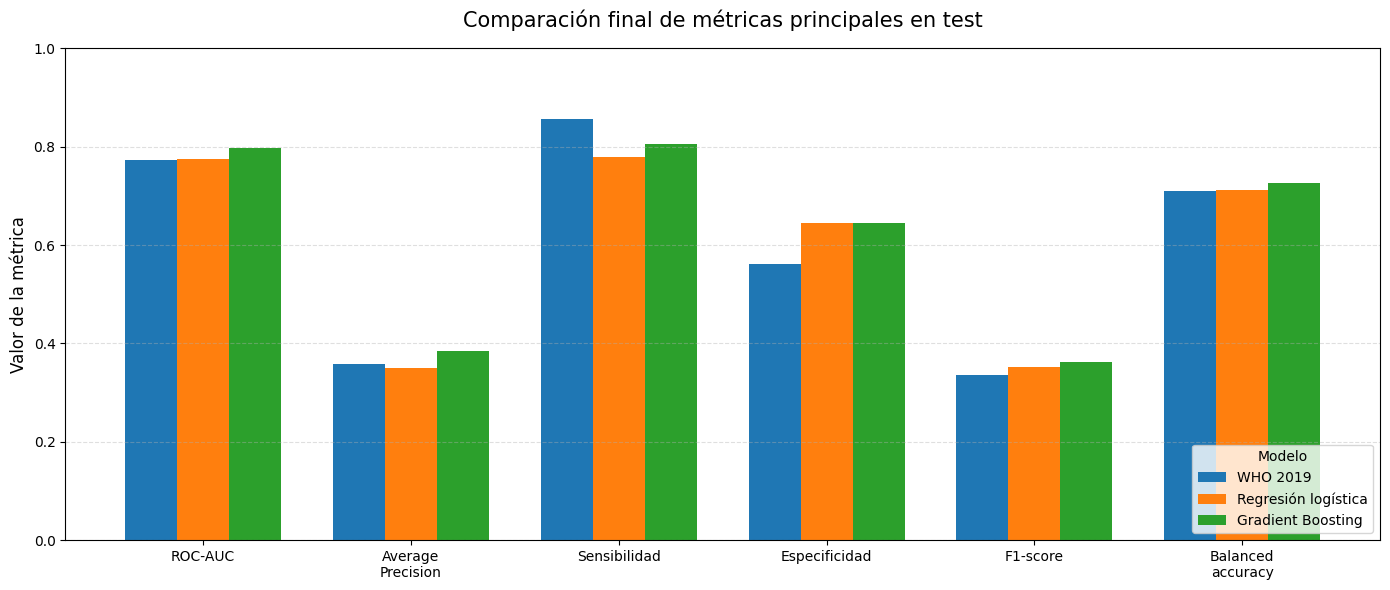

¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [838]:
# =========================================================
# Fase 6.6 — Gráfico final de métricas principales en test
# =========================================================

import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Seleccionamos métricas principales
# ---------------------------------------------------------

metricas_grafico_test = [
    "ROC_AUC_TEST",
    "AVERAGE_PRECISION_TEST",
    "SENSIBILIDAD",
    "ESPECIFICIDAD",
    "F1_SCORE",
    "BALANCED_ACCURACY"
]


tabla_metricas_grafico_test = (
    comparacion_final_test_tres_modelos
    .set_index("MODELO")[metricas_grafico_test]
)


n_modelos = len(tabla_metricas_grafico_test.index)
n_metricas = len(metricas_grafico_test)

x = np.arange(n_metricas)
ancho_barra = 0.25


# ---------------------------------------------------------
# 2. Creamos gráfico comparativo
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 6)
)

for i, modelo in enumerate(tabla_metricas_grafico_test.index):

    desplazamiento = (
        i - (n_modelos - 1) / 2
    ) * ancho_barra

    ax.bar(
        x + desplazamiento,
        tabla_metricas_grafico_test.loc[modelo].values,
        width=ancho_barra,
        label=modelo
    )


ax.set_title(
    "Comparación final de métricas principales en test",
    fontsize=15,
    pad=15
)

ax.set_ylabel(
    "Valor de la métrica",
    fontsize=12
)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "ROC-AUC",
        "Average\nPrecision",
        "Sensibilidad",
        "Especificidad",
        "F1-score",
        "Balanced\naccuracy"
    ],
    fontsize=10
)

ax.set_ylim(0, 1)

ax.legend(
    title="Modelo",
    loc="lower right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Comprobación metodológica
# ---------------------------------------------------------

print("¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

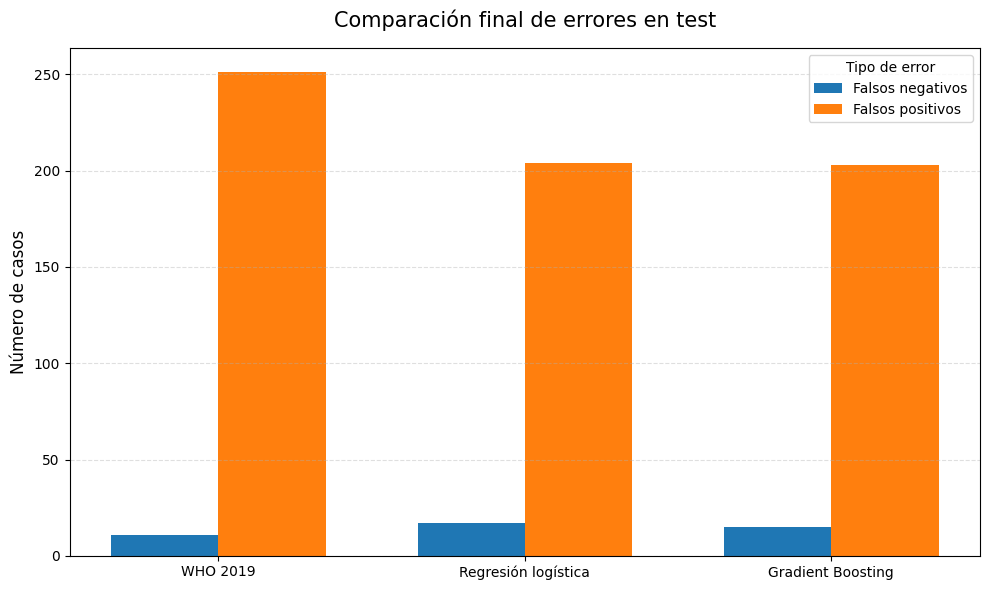

Errores finales en test:


,FALSOS_NEGATIVOS,FALSOS_POSITIVOS
MODELO,,
WHO 2019,11,251
Regresión logística,17,204
Gradient Boosting,15,203



¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [839]:
# =========================================================
# Fase 6.7 — Gráfico final de errores en test
# =========================================================

# ---------------------------------------------------------
# 1. Preparamos tabla de errores
# ---------------------------------------------------------

tabla_errores_grafico_test = (
    comparacion_final_test_tres_modelos[
        [
            "MODELO",
            "FALSOS_NEGATIVOS",
            "FALSOS_POSITIVOS"
        ]
    ]
    .set_index("MODELO")
)


x = np.arange(
    len(tabla_errores_grafico_test.index)
)

ancho_barra = 0.35


# ---------------------------------------------------------
# 2. Creamos gráfico de falsos negativos y falsos positivos
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.bar(
    x - ancho_barra / 2,
    tabla_errores_grafico_test["FALSOS_NEGATIVOS"],
    width=ancho_barra,
    label="Falsos negativos"
)

ax.bar(
    x + ancho_barra / 2,
    tabla_errores_grafico_test["FALSOS_POSITIVOS"],
    width=ancho_barra,
    label="Falsos positivos"
)


ax.set_title(
    "Comparación final de errores en test",
    fontsize=15,
    pad=15
)

ax.set_ylabel(
    "Número de casos",
    fontsize=12
)

ax.set_xticks(x)

ax.set_xticklabels(
    tabla_errores_grafico_test.index,
    rotation=0
)

ax.legend(
    title="Tipo de error"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Mostramos tabla asociada al gráfico
# ---------------------------------------------------------

print("Errores finales en test:")

display(
    tabla_errores_grafico_test
)


# ---------------------------------------------------------
# 4. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

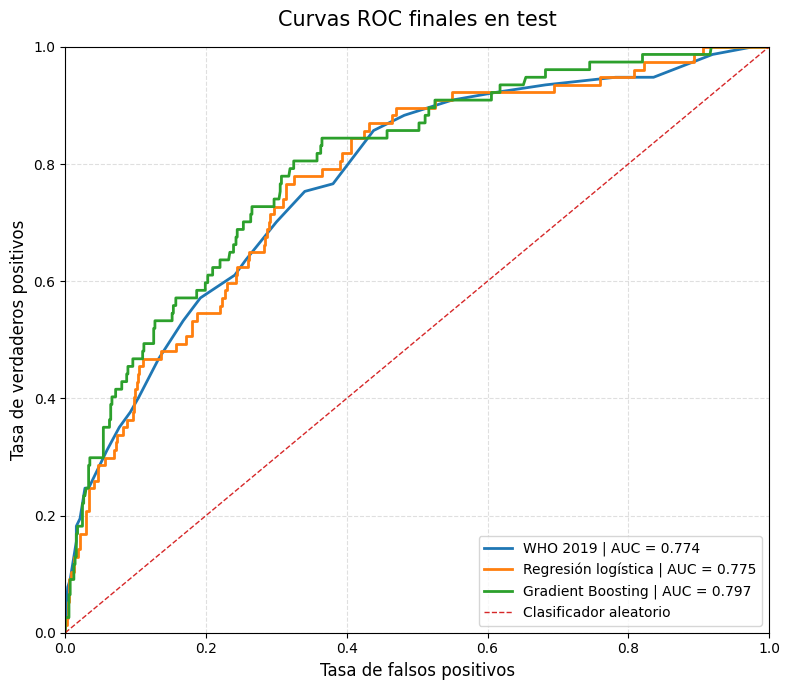

ROC-AUC final en test:


,MODELO,ROC_AUC_TEST
0,WHO 2019,0.7735
1,Regresión logística,0.7752
2,Gradient Boosting,0.7973



¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [840]:
# =========================================================
# Fase 6.8 — Curvas ROC finales en test
# =========================================================

from sklearn.metrics import roc_curve, auc


# ---------------------------------------------------------
# 1. Calculamos curvas ROC de los tres modelos
# ---------------------------------------------------------

fpr_who_test, tpr_who_test, _ = roc_curve(
    y_test,
    probabilidades_who_test
)

fpr_logistica_test, tpr_logistica_test, _ = roc_curve(
    y_test,
    probabilidades_logistica_test
)

fpr_gb_test, tpr_gb_test, _ = roc_curve(
    y_test,
    probabilidades_gb_test
)


auc_who_test = auc(
    fpr_who_test,
    tpr_who_test
)

auc_logistica_test = auc(
    fpr_logistica_test,
    tpr_logistica_test
)

auc_gb_test = auc(
    fpr_gb_test,
    tpr_gb_test
)


# ---------------------------------------------------------
# 2. Creamos gráfico ROC comparativo
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    fpr_who_test,
    tpr_who_test,
    linewidth=2,
    label=f"WHO 2019 | AUC = {auc_who_test:.3f}"
)

ax.plot(
    fpr_logistica_test,
    tpr_logistica_test,
    linewidth=2,
    label=f"Regresión logística | AUC = {auc_logistica_test:.3f}"
)

ax.plot(
    fpr_gb_test,
    tpr_gb_test,
    linewidth=2,
    label=f"Gradient Boosting | AUC = {auc_gb_test:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Clasificador aleatorio"
)


ax.set_title(
    "Curvas ROC finales en test",
    fontsize=15,
    pad=15
)

ax.set_xlabel(
    "Tasa de falsos positivos",
    fontsize=12
)

ax.set_ylabel(
    "Tasa de verdaderos positivos",
    fontsize=12
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(
    loc="lower right"
)

ax.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Mostramos AUC final asociado
# ---------------------------------------------------------

tabla_auc_roc_test = pd.DataFrame({
    "MODELO": [
        "WHO 2019",
        "Regresión logística",
        "Gradient Boosting"
    ],
    "ROC_AUC_TEST": [
        auc_who_test,
        auc_logistica_test,
        auc_gb_test
    ]
})


print("ROC-AUC final en test:")

display(
    tabla_auc_roc_test.round(4)
)


# ---------------------------------------------------------
# 4. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

In [842]:
# =========================================================
# Fase 6.9 — Preparación de tablas de calibración final en test
# =========================================================

# ---------------------------------------------------------
# 1. Función para crear calibración por grupos de riesgo
# ---------------------------------------------------------

def crear_tabla_calibracion_por_modelo(
    nombre_modelo,
    probabilidades,
    y_real,
    n_grupos=5
):

    tabla = pd.DataFrame({
        "EVENTO_REAL": y_real,
        "PROBABILIDAD": pd.Series(
            probabilidades,
            index=y_real.index
        ).astype(float)
    }).copy()

    tabla["GRUPO_NUMERICO"] = pd.qcut(
        tabla["PROBABILIDAD"],
        q=n_grupos,
        labels=False,
        duplicates="drop"
    )

    resumen = (
        tabla
        .groupby("GRUPO_NUMERICO", observed=True)
        .agg(
            PARTICIPANTES=("EVENTO_REAL", "size"),
            RIESGO_MEDIO_ESTIMADO_PCT=("PROBABILIDAD", lambda x: x.mean() * 100),
            EVENTO_REAL_OBSERVADO_PCT=("EVENTO_REAL", lambda x: x.mean() * 100),
            EVENTOS_REALES=("EVENTO_REAL", "sum")
        )
        .reset_index()
    )

    resumen["GRUPO_RIESGO"] = resumen["GRUPO_NUMERICO"].map({
        0: "Muy bajo",
        1: "Bajo",
        2: "Medio",
        3: "Alto",
        4: "Muy alto"
    })

    resumen["MODELO"] = nombre_modelo

    return resumen


# ---------------------------------------------------------
# 2. Creamos tablas de calibración para los tres modelos
# ---------------------------------------------------------

calibracion_who_test = crear_tabla_calibracion_por_modelo(
    "WHO 2019",
    probabilidades_who_test,
    y_test
)

calibracion_logistica_test = crear_tabla_calibracion_por_modelo(
    "Regresión logística",
    probabilidades_logistica_test,
    y_test
)

calibracion_gb_test = crear_tabla_calibracion_por_modelo(
    "Gradient Boosting",
    probabilidades_gb_test,
    y_test
)


# ---------------------------------------------------------
# 3. Unimos las tablas en formato largo
# ---------------------------------------------------------

tabla_calibracion_test_larga = pd.concat(
    [
        calibracion_who_test,
        calibracion_logistica_test,
        calibracion_gb_test
    ],
    ignore_index=True
)


# ---------------------------------------------------------
# 4. Creamos tabla de calibración global
# ---------------------------------------------------------

tabla_calibracion_global_test = comparacion_final_test_tres_modelos[
    [
        "MODELO",
        "RIESGO_MEDIO_ESTIMADO_PCT",
        "PREVALENCIA_REAL_TEST_PCT",
        "DIFERENCIA_RIESGO_PREVALENCIA_PCT",
        "BRIER_SCORE_TEST"
    ]
].copy()


# ---------------------------------------------------------
# 5. Mostramos tablas creadas
# ---------------------------------------------------------

print("Tablas de calibración final en test creadas:")

display(
    tabla_calibracion_test_larga[
        [
            "MODELO",
            "GRUPO_RIESGO",
            "PARTICIPANTES",
            "RIESGO_MEDIO_ESTIMADO_PCT",
            "EVENTO_REAL_OBSERVADO_PCT",
            "EVENTOS_REALES"
        ]
    ].round(2)
)


print("\nCalibración global final en test:")

display(
    tabla_calibracion_global_test.round(4)
)


# ---------------------------------------------------------
# 6. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han cambiado modelos o umbrales para crear estas tablas?")
print(False)

print("\nEstado:")
print("Tablas de calibración preparadas correctamente para los gráficos 6.9.1, 6.9.2 y 6.9.3.")

Tablas de calibración final en test creadas:


,MODELO,GRUPO_RIESGO,PARTICIPANTES,RIESGO_MEDIO_ESTIMADO_PCT,EVENTO_REAL_OBSERVADO_PCT,EVENTOS_REALES
0,WHO 2019,Muy bajo,187,3.47,2.67,5
1,WHO 2019,Bajo,78,6.46,2.56,2
2,WHO 2019,Medio,132,9.36,9.09,12
3,WHO 2019,Alto,141,14.40,15.60,22
4,WHO 2019,Muy alto,112,23.11,32.14,36
5,Regresión logística,Muy bajo,130,2.22,3.08,4
6,Regresión logística,Bajo,130,4.88,1.54,2
7,Regresión logística,Medio,130,8.85,8.46,11
8,Regresión logística,Alto,130,14.61,16.92,22
9,Regresión logística,Muy alto,130,29.66,29.23,38



Calibración global final en test:


,MODELO,RIESGO_MEDIO_ESTIMADO_PCT,PREVALENCIA_REAL_TEST_PCT,DIFERENCIA_RIESGO_PREVALENCIA_PCT,BRIER_SCORE_TEST
0,WHO 2019,10.7769,11.8462,-1.0692,0.0930
1,Regresión logística,12.0441,11.8462,0.1979,0.0912
2,Gradient Boosting,12.1181,11.8462,0.2719,0.0885



¿Se han cambiado modelos o umbrales para crear estas tablas?
False

Estado:
Tablas de calibración preparadas correctamente para los gráficos 6.9.1, 6.9.2 y 6.9.3.


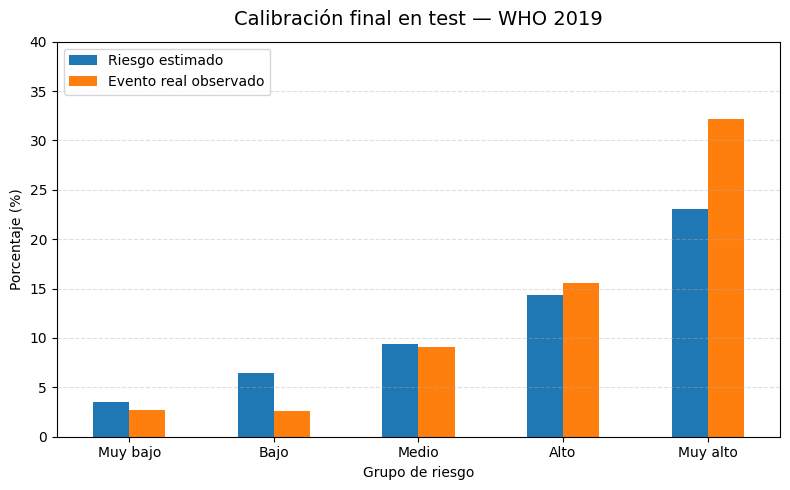

Calibración WHO 2019 en test:


,RIESGO_MEDIO_ESTIMADO_PCT,EVENTO_REAL_OBSERVADO_PCT
GRUPO_RIESGO,,
Muy bajo,3.47,2.67
Bajo,6.46,2.56
Medio,9.36,9.09
Alto,14.40,15.60
Muy alto,23.11,32.14



¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [843]:
# =========================================================
# Fase 6.9.1 — Calibración final en test: WHO 2019
# =========================================================

tabla_who_grafico = calibracion_who_test.set_index("GRUPO_RIESGO")[
    [
        "RIESGO_MEDIO_ESTIMADO_PCT",
        "EVENTO_REAL_OBSERVADO_PCT"
    ]
]

fig, ax = plt.subplots(figsize=(8, 5))

tabla_who_grafico.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Calibración final en test — WHO 2019",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Grupo de riesgo")
ax.set_ylabel("Porcentaje (%)")

ax.set_ylim(0, 40)

ax.legend(
    [
        "Riesgo estimado",
        "Evento real observado"
    ],
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Calibración WHO 2019 en test:")

display(
    tabla_who_grafico.round(2)
)

print("\n¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

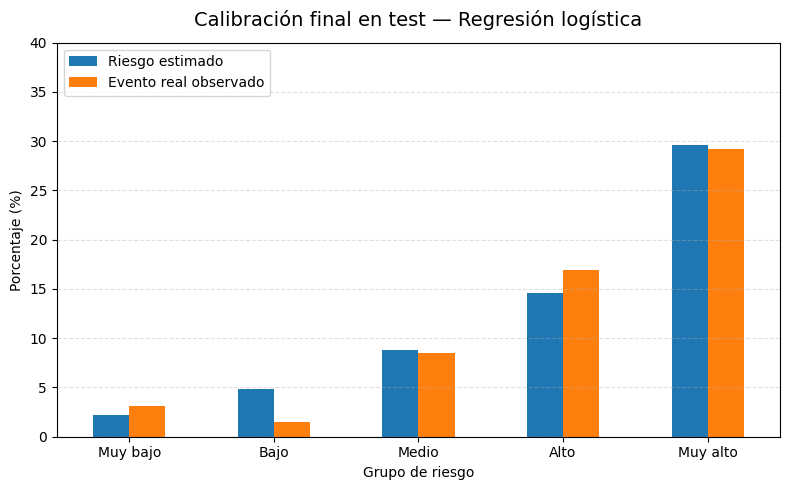

Calibración Regresión logística en test:


,RIESGO_MEDIO_ESTIMADO_PCT,EVENTO_REAL_OBSERVADO_PCT
GRUPO_RIESGO,,
Muy bajo,2.22,3.08
Bajo,4.88,1.54
Medio,8.85,8.46
Alto,14.61,16.92
Muy alto,29.66,29.23



¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [844]:
# =========================================================
# Fase 6.9.2 — Calibración final en test: Regresión logística
# =========================================================

tabla_logistica_grafico = calibracion_logistica_test.set_index("GRUPO_RIESGO")[
    [
        "RIESGO_MEDIO_ESTIMADO_PCT",
        "EVENTO_REAL_OBSERVADO_PCT"
    ]
]

fig, ax = plt.subplots(figsize=(8, 5))

tabla_logistica_grafico.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Calibración final en test — Regresión logística",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Grupo de riesgo")
ax.set_ylabel("Porcentaje (%)")

ax.set_ylim(0, 40)

ax.legend(
    [
        "Riesgo estimado",
        "Evento real observado"
    ],
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Calibración Regresión logística en test:")

display(
    tabla_logistica_grafico.round(2)
)

print("\n¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

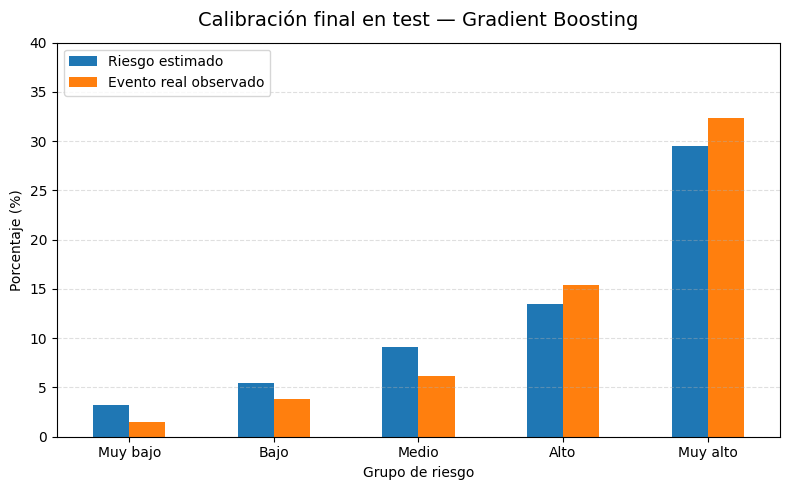

Calibración Gradient Boosting en test:


,RIESGO_MEDIO_ESTIMADO_PCT,EVENTO_REAL_OBSERVADO_PCT
GRUPO_RIESGO,,
Muy bajo,3.18,1.54
Bajo,5.40,3.85
Medio,9.06,6.15
Alto,13.46,15.38
Muy alto,29.49,32.31



¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [845]:
# =========================================================
# Fase 6.9.3 — Calibración final en test: Gradient Boosting
# =========================================================

tabla_gb_grafico = calibracion_gb_test.set_index("GRUPO_RIESGO")[
    [
        "RIESGO_MEDIO_ESTIMADO_PCT",
        "EVENTO_REAL_OBSERVADO_PCT"
    ]
]

fig, ax = plt.subplots(figsize=(8, 5))

tabla_gb_grafico.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Calibración final en test — Gradient Boosting",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Grupo de riesgo")
ax.set_ylabel("Porcentaje (%)")

ax.set_ylim(0, 40)

ax.legend(
    [
        "Riesgo estimado",
        "Evento real observado"
    ],
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Calibración Gradient Boosting en test:")

display(
    tabla_gb_grafico.round(2)
)

print("\n¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

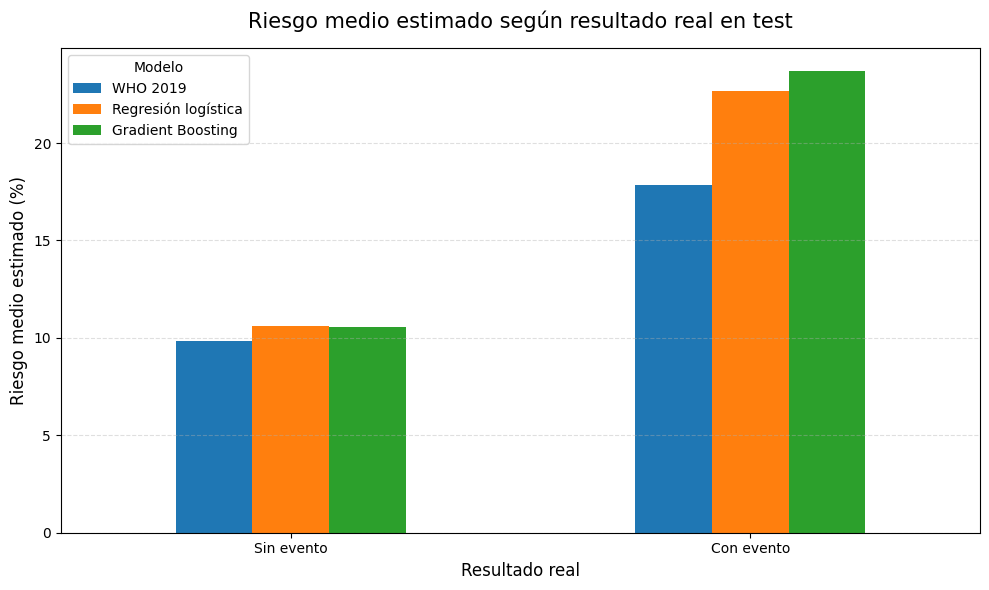

Riesgo medio estimado según resultado real en test:


,WHO 2019,Regresión logística,Gradient Boosting
Sin evento,9.82,10.62,10.57
Con evento,17.87,22.67,23.68



Diferencia de riesgo medio entre participantes con evento y sin evento:


,MODELO,DIFERENCIA_RIESGO_CON_EVENTO_MENOS_SIN_EVENTO_PCT
0,WHO 2019,8.05
1,Regresión logística,12.06
2,Gradient Boosting,13.11



¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [846]:
# =========================================================
# Fase 6.10 — Riesgo medio estimado según resultado real en test
# =========================================================

# ---------------------------------------------------------
# 1. Creamos tabla con resultado real y probabilidades
# ---------------------------------------------------------

tabla_riesgo_por_resultado_test = pd.DataFrame({
    "RESULTADO_REAL": y_test,
    "WHO 2019": probabilidades_who_test,
    "Regresión logística": probabilidades_logistica_test,
    "Gradient Boosting": probabilidades_gb_test
})


# ---------------------------------------------------------
# 2. Calculamos riesgo medio estimado según resultado real
# ---------------------------------------------------------

resumen_riesgo_por_resultado_test = (
    tabla_riesgo_por_resultado_test
    .groupby("RESULTADO_REAL")[
        [
            "WHO 2019",
            "Regresión logística",
            "Gradient Boosting"
        ]
    ]
    .mean()
    .mul(100)
)


resumen_riesgo_por_resultado_test = resumen_riesgo_por_resultado_test.reindex(
    [0, 1]
)

resumen_riesgo_por_resultado_test.index = [
    "Sin evento",
    "Con evento"
]


# ---------------------------------------------------------
# 3. Creamos gráfico comparativo
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

resumen_riesgo_por_resultado_test.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Riesgo medio estimado según resultado real en test",
    fontsize=15,
    pad=15
)

ax.set_xlabel(
    "Resultado real",
    fontsize=12
)

ax.set_ylabel(
    "Riesgo medio estimado (%)",
    fontsize=12
)

ax.legend(
    title="Modelo",
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Mostramos tabla asociada
# ---------------------------------------------------------

print("Riesgo medio estimado según resultado real en test:")

display(
    resumen_riesgo_por_resultado_test.round(2)
)


# ---------------------------------------------------------
# 5. Calculamos diferencia entre participantes con y sin evento
# ---------------------------------------------------------

diferencia_riesgo_evento_test = (
    resumen_riesgo_por_resultado_test.loc["Con evento"]
    -
    resumen_riesgo_por_resultado_test.loc["Sin evento"]
)

tabla_diferencia_riesgo_evento_test = pd.DataFrame({
    "MODELO": diferencia_riesgo_evento_test.index,
    "DIFERENCIA_RIESGO_CON_EVENTO_MENOS_SIN_EVENTO_PCT": diferencia_riesgo_evento_test.values
})


print("\nDiferencia de riesgo medio entre participantes con evento y sin evento:")

display(
    tabla_diferencia_riesgo_evento_test.round(2)
)


# ---------------------------------------------------------
# 6. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

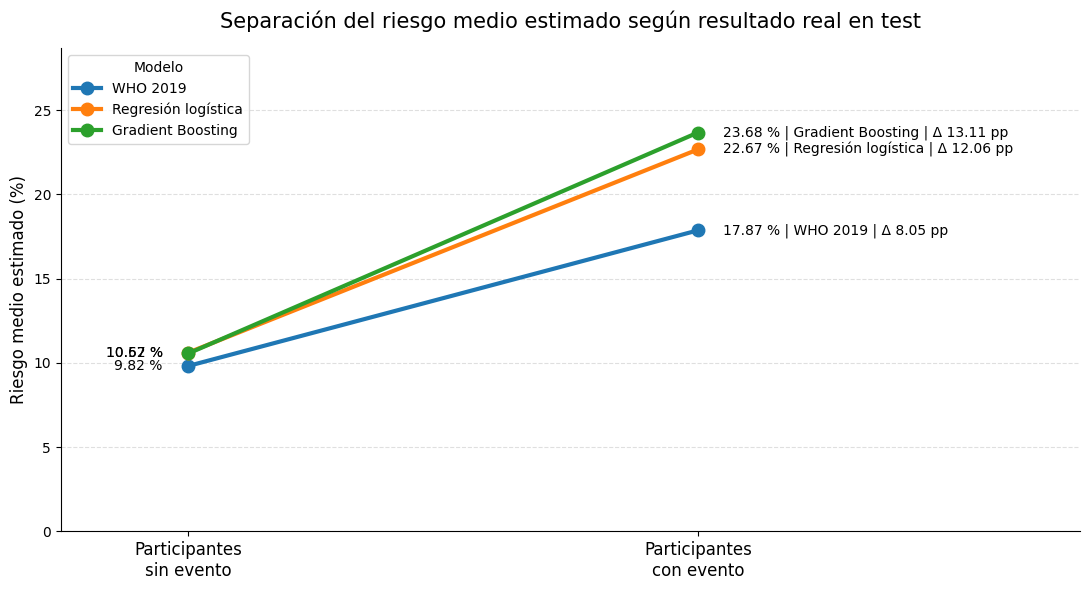

Separación del riesgo medio estimado según resultado real en test:


,MODELO,RIESGO_MEDIO_SIN_EVENTO_PCT,RIESGO_MEDIO_CON_EVENTO_PCT,DIFERENCIA_PUNTOS_PCT
0,WHO 2019,9.82,17.87,8.05
1,Regresión logística,10.62,22.67,12.06
2,Gradient Boosting,10.57,23.68,13.11



¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [847]:
# =========================================================
# Fase 6.11 — Separación del riesgo medio estimado en test
# Versión tipo slope chart
# =========================================================

# ---------------------------------------------------------
# 1. Preparamos los datos
# ---------------------------------------------------------

tabla_separacion_test = pd.DataFrame({
    "MODELO": [
        "WHO 2019",
        "Regresión logística",
        "Gradient Boosting"
    ],
    "RIESGO_MEDIO_SIN_EVENTO_PCT": [
        resumen_riesgo_por_resultado_test.loc["Sin evento", "WHO 2019"],
        resumen_riesgo_por_resultado_test.loc["Sin evento", "Regresión logística"],
        resumen_riesgo_por_resultado_test.loc["Sin evento", "Gradient Boosting"]
    ],
    "RIESGO_MEDIO_CON_EVENTO_PCT": [
        resumen_riesgo_por_resultado_test.loc["Con evento", "WHO 2019"],
        resumen_riesgo_por_resultado_test.loc["Con evento", "Regresión logística"],
        resumen_riesgo_por_resultado_test.loc["Con evento", "Gradient Boosting"]
    ]
})

tabla_separacion_test["DIFERENCIA_PUNTOS_PCT"] = (
    tabla_separacion_test["RIESGO_MEDIO_CON_EVENTO_PCT"]
    -
    tabla_separacion_test["RIESGO_MEDIO_SIN_EVENTO_PCT"]
)


# ---------------------------------------------------------
# 2. Creamos gráfico tipo slope chart
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

x_sin_evento = 0
x_con_evento = 1

for i in range(len(tabla_separacion_test)):

    modelo = tabla_separacion_test.loc[i, "MODELO"]

    riesgo_sin_evento = tabla_separacion_test.loc[
        i,
        "RIESGO_MEDIO_SIN_EVENTO_PCT"
    ]

    riesgo_con_evento = tabla_separacion_test.loc[
        i,
        "RIESGO_MEDIO_CON_EVENTO_PCT"
    ]

    diferencia = tabla_separacion_test.loc[
        i,
        "DIFERENCIA_PUNTOS_PCT"
    ]

    ax.plot(
        [x_sin_evento, x_con_evento],
        [riesgo_sin_evento, riesgo_con_evento],
        marker="o",
        linewidth=3,
        markersize=9,
        label=modelo
    )

    ax.text(
        x_sin_evento - 0.05,
        riesgo_sin_evento,
        f"{riesgo_sin_evento:.2f} %",
        ha="right",
        va="center",
        fontsize=10
    )

    ax.text(
        x_con_evento + 0.05,
        riesgo_con_evento,
        f"{riesgo_con_evento:.2f} % | {modelo} | Δ {diferencia:.2f} pp",
        ha="left",
        va="center",
        fontsize=10
    )


# ---------------------------------------------------------
# 3. Personalizamos el gráfico
# ---------------------------------------------------------

ax.set_title(
    "Separación del riesgo medio estimado según resultado real en test",
    fontsize=15,
    pad=15
)

ax.set_xticks(
    [x_sin_evento, x_con_evento]
)

ax.set_xticklabels(
    [
        "Participantes\nsin evento",
        "Participantes\ncon evento"
    ],
    fontsize=12
)

ax.set_ylabel(
    "Riesgo medio estimado (%)",
    fontsize=12
)

ax.set_xlim(-0.25, 1.75)

ax.set_ylim(
    0,
    tabla_separacion_test["RIESGO_MEDIO_CON_EVENTO_PCT"].max() + 5
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Modelo",
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Mostramos tabla resumen
# ---------------------------------------------------------

print("Separación del riesgo medio estimado según resultado real en test:")

display(
    tabla_separacion_test.round(2)
)


# ---------------------------------------------------------
# 5. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

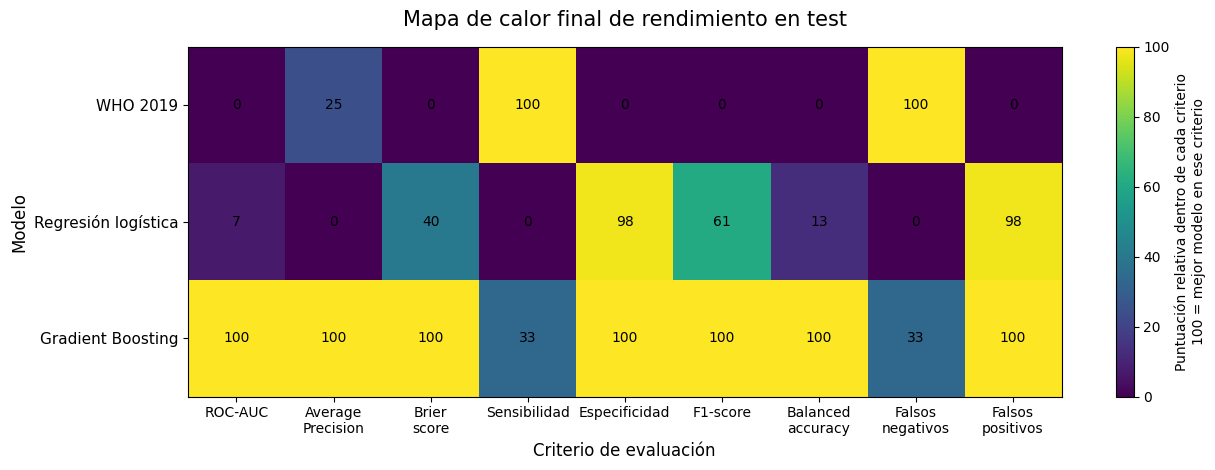

Puntuación relativa por criterio en test:
100 significa mejor resultado dentro de ese criterio.


,ROC_AUC_TEST,AVERAGE_PRECISION_TEST,BRIER_SCORE_TEST,SENSIBILIDAD,ESPECIFICIDAD,F1_SCORE,BALANCED_ACCURACY,FALSOS_NEGATIVOS,FALSOS_POSITIVOS
MODELO,,,,,,,,,
WHO 2019,0.0,24.5,0.0,100.0,0.0,0.0,0.0,100.0,0.0
Regresión logística,7.1,0.0,40.4,0.0,97.9,61.3,12.9,0.0,97.9
Gradient Boosting,100.0,100.0,100.0,33.3,100.0,100.0,100.0,33.3,100.0



Valores originales utilizados para construir el mapa de calor:


,ROC_AUC_TEST,AVERAGE_PRECISION_TEST,BRIER_SCORE_TEST,SENSIBILIDAD,ESPECIFICIDAD,F1_SCORE,BALANCED_ACCURACY,FALSOS_NEGATIVOS,FALSOS_POSITIVOS
MODELO,,,,,,,,,
WHO 2019,0.7735,0.3588,0.0930,0.8571,0.5620,0.3350,0.7095,11,251
Regresión logística,0.7752,0.3501,0.0912,0.7792,0.6440,0.3519,0.7116,17,204
Gradient Boosting,0.7973,0.3854,0.0885,0.8052,0.6457,0.3626,0.7255,15,203



¿Se han cambiado modelos o umbrales para crear este gráfico?
False


In [848]:
# =========================================================
# Fase 6.12 — Mapa de calor final de rendimiento en test
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Seleccionamos criterios finales
# ---------------------------------------------------------

columnas_scorecard = [
    "ROC_AUC_TEST",
    "AVERAGE_PRECISION_TEST",
    "BRIER_SCORE_TEST",
    "SENSIBILIDAD",
    "ESPECIFICIDAD",
    "F1_SCORE",
    "BALANCED_ACCURACY",
    "FALSOS_NEGATIVOS",
    "FALSOS_POSITIVOS"
]

etiquetas_scorecard = [
    "ROC-AUC",
    "Average\nPrecision",
    "Brier\nscore",
    "Sensibilidad",
    "Especificidad",
    "F1-score",
    "Balanced\naccuracy",
    "Falsos\nnegativos",
    "Falsos\npositivos"
]


tabla_scorecard_original = (
    comparacion_final_test_tres_modelos
    .set_index("MODELO")[columnas_scorecard]
    .copy()
)


# ---------------------------------------------------------
# 2. Convertimos cada criterio a puntuación 0-100
#    100 = mejor resultado dentro de ese criterio
# ---------------------------------------------------------

metricas_mayor_mejor = [
    "ROC_AUC_TEST",
    "AVERAGE_PRECISION_TEST",
    "SENSIBILIDAD",
    "ESPECIFICIDAD",
    "F1_SCORE",
    "BALANCED_ACCURACY"
]

metricas_menor_mejor = [
    "BRIER_SCORE_TEST",
    "FALSOS_NEGATIVOS",
    "FALSOS_POSITIVOS"
]


tabla_scorecard_100 = pd.DataFrame(
    index=tabla_scorecard_original.index
)

for columna in metricas_mayor_mejor:

    minimo = tabla_scorecard_original[columna].min()
    maximo = tabla_scorecard_original[columna].max()

    if maximo == minimo:
        tabla_scorecard_100[columna] = 100
    else:
        tabla_scorecard_100[columna] = (
            (tabla_scorecard_original[columna] - minimo)
            /
            (maximo - minimo)
            *
            100
        )


for columna in metricas_menor_mejor:

    minimo = tabla_scorecard_original[columna].min()
    maximo = tabla_scorecard_original[columna].max()

    if maximo == minimo:
        tabla_scorecard_100[columna] = 100
    else:
        tabla_scorecard_100[columna] = (
            (maximo - tabla_scorecard_original[columna])
            /
            (maximo - minimo)
            *
            100
        )


tabla_scorecard_100 = tabla_scorecard_100[columnas_scorecard]


# ---------------------------------------------------------
# 3. Creamos mapa de calor
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 4.8))

imagen = ax.imshow(
    tabla_scorecard_100.values,
    aspect="auto"
)

ax.set_title(
    "Mapa de calor final de rendimiento en test",
    fontsize=15,
    pad=15
)

ax.set_xticks(
    np.arange(len(columnas_scorecard))
)

ax.set_xticklabels(
    etiquetas_scorecard,
    fontsize=10
)

ax.set_yticks(
    np.arange(len(tabla_scorecard_100.index))
)

ax.set_yticklabels(
    tabla_scorecard_100.index,
    fontsize=11
)

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    ha="center"
)


# ---------------------------------------------------------
# 4. Añadimos valores dentro de cada celda
# ---------------------------------------------------------

for i in range(tabla_scorecard_100.shape[0]):

    for j in range(tabla_scorecard_100.shape[1]):

        puntuacion = tabla_scorecard_100.iloc[i, j]

        ax.text(
            j,
            i,
            f"{puntuacion:.0f}",
            ha="center",
            va="center",
            fontsize=10
        )


# ---------------------------------------------------------
# 5. Añadimos barra de color y explicación
# ---------------------------------------------------------

barra_color = fig.colorbar(
    imagen,
    ax=ax
)

barra_color.set_label(
    "Puntuación relativa dentro de cada criterio\n100 = mejor modelo en ese criterio",
    fontsize=10
)

ax.set_xlabel(
    "Criterio de evaluación",
    fontsize=12
)

ax.set_ylabel(
    "Modelo",
    fontsize=12
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 6. Tabla de puntuaciones relativas
# ---------------------------------------------------------

print("Puntuación relativa por criterio en test:")
print("100 significa mejor resultado dentro de ese criterio.")

display(
    tabla_scorecard_100.round(1)
)


# ---------------------------------------------------------
# 7. Tabla original asociada
# ---------------------------------------------------------

print("\nValores originales utilizados para construir el mapa de calor:")

display(
    tabla_scorecard_original.round(4)
)


# ---------------------------------------------------------
# 8. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han cambiado modelos o umbrales para crear este gráfico?")
print(False)

## Cierre de la Fase 6 — Evaluación final en test

En esta fase se realizó la evaluación final de los tres modelos utilizando por primera vez el conjunto de test reservado.

Los modelos evaluados fueron:

- WHO 2019.
- Regresión logística.
- Gradient Boosting.

A diferencia de las fases anteriores, en esta fase no se ajustaron hiperparámetros, no se seleccionaron nuevos umbrales y no se modificaron los modelos a partir de los resultados observados en test. El conjunto de test se utilizó únicamente para evaluar la capacidad de generalización final.

El conjunto de test estuvo formado por **650 participantes**, de los cuales **77 presentaron evento cardiovascular a 10 años**. La prevalencia observada fue del **11,85 %**, muy similar a la del conjunto de entrenamiento, lo que confirma que la partición estratificada mantuvo una distribución equilibrada de la variable objetivo.

### Evaluación probabilística

En términos de discriminación probabilística, Gradient Boosting obtuvo el mejor rendimiento global:

- ROC-AUC: **0,7973**
- Average Precision: **0,3854**
- Brier score: **0,0885**

La regresión logística obtuvo un ROC-AUC de **0,7752** y WHO 2019 obtuvo un ROC-AUC de **0,7735**. Por tanto, los tres modelos mostraron una capacidad razonable para ordenar a los participantes según su nivel de riesgo, aunque Gradient Boosting fue el modelo con mejor discriminación final.

En calibración global, la regresión logística fue el modelo cuyo riesgo medio estimado quedó más cerca de la prevalencia real del test. Sin embargo, Gradient Boosting obtuvo el mejor Brier score, lo que indica una mejor calidad global de sus probabilidades.

### Evaluación con umbrales fijados previamente

Los umbrales utilizados fueron los definidos antes de evaluar el test:

- WHO 2019: **10,00 %**
- Regresión logística: **11,23 %**
- Gradient Boosting: **10,73 %**

Con estos umbrales, WHO 2019 obtuvo la mayor sensibilidad:

- Sensibilidad WHO 2019: **85,71 %**
- Falsos negativos WHO 2019: **11**

Esto significa que WHO 2019 fue el modelo que detectó más eventos reales, aunque a costa de generar más falsos positivos.

Gradient Boosting obtuvo el mejor equilibrio global de clasificación:

- Especificidad: **64,57 %**
- F1-score: **0,3626**
- Balanced accuracy: **72,55 %**
- Falsos positivos: **203**
- Falsos negativos: **15**

La regresión logística presentó resultados intermedios, con buen equilibrio, buena calibración global y una interpretación más sencilla que Gradient Boosting.

### Comparación final de los modelos

La comparación final muestra que ningún modelo domina absolutamente en todos los criterios:

- **WHO 2019** destaca por su alta sensibilidad y por detectar el mayor número de eventos.
- **Regresión logística** destaca por su interpretabilidad y por una calibración global muy cercana a la prevalencia real.
- **Gradient Boosting** destaca por el mejor rendimiento global en test, con mejor ROC-AUC, mejor Average Precision, mejor Brier score, mejor F1-score y mejor balanced accuracy.

El gráfico de errores mostró que WHO 2019 reduce más los falsos negativos, mientras que Gradient Boosting reduce más los falsos positivos.

El análisis de calibración por grupos mostró que los modelos ordenan adecuadamente a los participantes: los grupos de mayor riesgo presentan una mayor proporción real de eventos.

Además, el análisis de separación del riesgo medio mostró que Gradient Boosting fue el modelo que más separó a los participantes con evento y sin evento:

- WHO 2019: diferencia de **8,05 puntos porcentuales**
- Regresión logística: diferencia de **12,06 puntos porcentuales**
- Gradient Boosting: diferencia de **13,11 puntos porcentuales**

Finalmente, el mapa de calor de rendimiento confirmó que Gradient Boosting fue el modelo con mejor perfil global en test, mientras que WHO 2019 mantuvo su principal ventaja en sensibilidad.

### Conclusión de la Fase 6

La evaluación final en test confirma que Gradient Boosting es el modelo con mejor rendimiento global para el modelo con mejor rendimiento global para este conjunto de datos, especialmente si se busca un equilibrio entre discriminación, calidad probabilística y clasificación.

Sin embargo, la elección del modelo dependería del objetivo práctico:

- Si el objetivo principal es detectar el mayor número posible de eventos cardiovasculares, WHO 2019 es una opción muy sensible.
- Si el objetivo es disponer de un modelo interpretable y bien calibrado, la regresión logística es una alternativa sólida.
- Si el objetivo es maximizar el rendimiento predictivo global, Gradient Boosting es el modelo más competitivo.

Con esta fase queda cerrada la evaluación final de modelos. La siguiente parte del proyecto consistirá en organizar los resultados finales, guardar tablas y gráficos, y preparar una carpeta descargable con los principales outputs del análisis.

In [849]:
# =========================================================
# Fase 7.1 — Creación de carpeta final del proyecto
# =========================================================

import os
import shutil
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np


# ---------------------------------------------------------
# 1. Definimos la carpeta principal de resultados
# ---------------------------------------------------------

nombre_carpeta_proyecto = "resultados_proyecto_riesgo_cardiovascular"

ruta_base_resultados = Path(nombre_carpeta_proyecto)

ruta_tablas = ruta_base_resultados / "tablas"
ruta_graficos = ruta_base_resultados / "graficos"
ruta_modelos = ruta_base_resultados / "modelos"
ruta_resumenes = ruta_base_resultados / "resumenes"
ruta_datos = ruta_base_resultados / "datos"


# ---------------------------------------------------------
# 2. Creamos estructura de carpetas
# ---------------------------------------------------------

carpetas_proyecto = [
    ruta_base_resultados,
    ruta_tablas,
    ruta_graficos,
    ruta_modelos,
    ruta_resumenes,
    ruta_datos
]

for carpeta in carpetas_proyecto:
    carpeta.mkdir(
        parents=True,
        exist_ok=True
    )


# ---------------------------------------------------------
# 3. Comprobamos objetos importantes disponibles
# ---------------------------------------------------------

objetos_relevantes_exportacion = [
    "datos_modelado",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "tabla_dimensiones_fase_6",
    "tabla_umbrales_finales",
    "comparacion_probabilistica_test",
    "comparacion_clasificacion_test",
    "comparacion_final_test_tres_modelos",
    "comparacion_final_test_resumida",
    "ganadores_test",
    "tabla_errores_grafico_test",
    "tabla_auc_roc_test",
    "tabla_calibracion_test_larga",
    "tabla_calibracion_global_test",
    "resumen_riesgo_por_resultado_test",
    "tabla_separacion_test",
    "tabla_scorecard_100",
    "tabla_scorecard_original",
    "comparacion_interna_tres_modelos",
    "modelo_logistica_final",
    "modelo_gb_final",
    "probabilidades_who_test",
    "probabilidades_logistica_test",
    "probabilidades_gb_test"
]


registro_objetos_exportacion = []

for objeto in objetos_relevantes_exportacion:

    existe = objeto in globals()

    if existe:
        tipo_objeto = type(globals()[objeto]).__name__
    else:
        tipo_objeto = "No disponible"

    registro_objetos_exportacion.append({
        "OBJETO": objeto,
        "DISPONIBLE": existe,
        "TIPO": tipo_objeto
    })


tabla_registro_objetos_exportacion = pd.DataFrame(
    registro_objetos_exportacion
)


# ---------------------------------------------------------
# 4. Mostramos estructura creada
# ---------------------------------------------------------

tabla_carpetas_proyecto = pd.DataFrame({
    "CARPETA": [
        "Principal",
        "Tablas",
        "Gráficos",
        "Modelos",
        "Resúmenes",
        "Datos"
    ],
    "RUTA": [
        str(ruta_base_resultados),
        str(ruta_tablas),
        str(ruta_graficos),
        str(ruta_modelos),
        str(ruta_resumenes),
        str(ruta_datos)
    ],
    "EXISTE": [
        ruta_base_resultados.exists(),
        ruta_tablas.exists(),
        ruta_graficos.exists(),
        ruta_modelos.exists(),
        ruta_resumenes.exists(),
        ruta_datos.exists()
    ]
})


print("Estructura de carpetas creada para el proyecto:")

display(
    tabla_carpetas_proyecto
)


print("\nObjetos disponibles para exportación:")

display(
    tabla_registro_objetos_exportacion
)


# ---------------------------------------------------------
# 5. Guardamos un registro inicial de exportación
# ---------------------------------------------------------

fecha_exportacion = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

registro_inicial_exportacion = pd.DataFrame({
    "CAMPO": [
        "Proyecto",
        "Fecha de creación de carpeta",
        "Carpeta principal",
        "Estado"
    ],
    "VALOR": [
        "Predicción de riesgo cardiovascular a 10 años",
        fecha_exportacion,
        str(ruta_base_resultados),
        "Estructura inicial creada correctamente"
    ]
})

ruta_registro_inicial = ruta_resumenes / "registro_inicial_exportacion.csv"

registro_inicial_exportacion.to_csv(
    ruta_registro_inicial,
    index=False,
    encoding="utf-8-sig"
)


print("\nRegistro inicial guardado en:")
print(ruta_registro_inicial)


# ---------------------------------------------------------
# 6. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han modificado modelos, umbrales o resultados?")
print(False)

print("\nEstado de la Fase 7.1:")
print("Carpeta principal y subcarpetas creadas correctamente.")

Estructura de carpetas creada para el proyecto:


,CARPETA,RUTA,EXISTE
0,Principal,resultados_proyecto_riesgo_cardiovascular,True
1,Tablas,resultados_proyecto_riesgo_cardiovascular/tablas,True
2,Gráficos,resultados_proyecto_riesgo_cardiovascular/graf...,True
3,Modelos,resultados_proyecto_riesgo_cardiovascular/modelos,True
4,Resúmenes,resultados_proyecto_riesgo_cardiovascular/resu...,True
5,Datos,resultados_proyecto_riesgo_cardiovascular/datos,True



Objetos disponibles para exportación:


,OBJETO,DISPONIBLE,TIPO
0,datos_modelado,True,DataFrame
1,X_train,True,DataFrame
2,X_test,True,DataFrame
3,y_train,True,Series
4,y_test,True,Series
5,tabla_dimensiones_fase_6,True,DataFrame
6,tabla_umbrales_finales,True,DataFrame
7,comparacion_probabilistica_test,True,DataFrame
8,comparacion_clasificacion_test,True,DataFrame
9,comparacion_final_test_tres_modelos,True,DataFrame



Registro inicial guardado en:
resultados_proyecto_riesgo_cardiovascular/resumenes/registro_inicial_exportacion.csv

¿Se han modificado modelos, umbrales o resultados?
False

Estado de la Fase 7.1:
Carpeta principal y subcarpetas creadas correctamente.


In [850]:
# =========================================================
# Fase 7.2 — Exportación de tablas finales del proyecto
# =========================================================

# ---------------------------------------------------------
# 1. Definimos las tablas principales que se van a exportar
# ---------------------------------------------------------

tablas_finales_exportacion = {
    "01_dimensiones_fase_6": tabla_dimensiones_fase_6,
    "02_umbrales_finales": tabla_umbrales_finales,
    "03_comparacion_probabilistica_test": comparacion_probabilistica_test,
    "04_comparacion_clasificacion_test": comparacion_clasificacion_test,
    "05_comparacion_final_test_tres_modelos": comparacion_final_test_tres_modelos,
    "06_comparacion_final_test_resumida": comparacion_final_test_resumida,
    "07_ganadores_test": ganadores_test,
    "08_errores_test": tabla_errores_grafico_test,
    "09_auc_roc_test": tabla_auc_roc_test,
    "10_calibracion_test_larga": tabla_calibracion_test_larga,
    "11_calibracion_global_test": tabla_calibracion_global_test,
    "12_riesgo_por_resultado_test": resumen_riesgo_por_resultado_test,
    "13_separacion_riesgo_test": tabla_separacion_test,
    "14_scorecard_100_test": tabla_scorecard_100,
    "15_scorecard_original_test": tabla_scorecard_original,
    "16_comparacion_interna_entrenamiento": comparacion_interna_tres_modelos
}


# ---------------------------------------------------------
# 2. Exportamos cada tabla en formato CSV
# ---------------------------------------------------------

registro_tablas_exportadas = []

for nombre_archivo, tabla in tablas_finales_exportacion.items():

    ruta_csv = ruta_tablas / f"{nombre_archivo}.csv"

    tabla.to_csv(
        ruta_csv,
        index=True,
        encoding="utf-8-sig"
    )

    registro_tablas_exportadas.append({
        "TABLA": nombre_archivo,
        "FORMATO": "csv",
        "RUTA": str(ruta_csv),
        "FILAS": tabla.shape[0],
        "COLUMNAS": tabla.shape[1],
        "EXPORTADA": ruta_csv.exists()
    })


# ---------------------------------------------------------
# 3. Exportamos también un Excel único con todas las tablas
# ---------------------------------------------------------

ruta_excel_tablas = ruta_tablas / "tablas_finales_proyecto.xlsx"

with pd.ExcelWriter(
    ruta_excel_tablas,
    engine="openpyxl"
) as writer:

    for nombre_archivo, tabla in tablas_finales_exportacion.items():

        nombre_hoja = nombre_archivo[:31]

        tabla.to_excel(
            writer,
            sheet_name=nombre_hoja,
            index=True
        )


registro_tablas_exportadas.append({
    "TABLA": "tablas_finales_proyecto",
    "FORMATO": "xlsx",
    "RUTA": str(ruta_excel_tablas),
    "FILAS": "",
    "COLUMNAS": "",
    "EXPORTADA": ruta_excel_tablas.exists()
})


# ---------------------------------------------------------
# 4. Guardamos también probabilidades finales en test
# ---------------------------------------------------------

tabla_probabilidades_finales_test = pd.DataFrame({
    "EVENTO_REAL": y_test,
    "PROBABILIDAD_WHO": probabilidades_who_test,
    "PROBABILIDAD_LOGISTICA": probabilidades_logistica_test,
    "PROBABILIDAD_GB": probabilidades_gb_test
})

ruta_probabilidades_test = ruta_datos / "probabilidades_finales_test.csv"

tabla_probabilidades_finales_test.to_csv(
    ruta_probabilidades_test,
    index=True,
    encoding="utf-8-sig"
)

registro_tablas_exportadas.append({
    "TABLA": "probabilidades_finales_test",
    "FORMATO": "csv",
    "RUTA": str(ruta_probabilidades_test),
    "FILAS": tabla_probabilidades_finales_test.shape[0],
    "COLUMNAS": tabla_probabilidades_finales_test.shape[1],
    "EXPORTADA": ruta_probabilidades_test.exists()
})


# ---------------------------------------------------------
# 5. Creamos registro de exportación de tablas
# ---------------------------------------------------------

tabla_registro_tablas_exportadas = pd.DataFrame(
    registro_tablas_exportadas
)

ruta_registro_tablas = ruta_resumenes / "registro_tablas_exportadas.csv"

tabla_registro_tablas_exportadas.to_csv(
    ruta_registro_tablas,
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------
# 6. Mostramos resumen de exportación
# ---------------------------------------------------------

print("Tablas finales exportadas:")

display(
    tabla_registro_tablas_exportadas
)


print("\nArchivo Excel con todas las tablas:")
print(ruta_excel_tablas)

print("\nArchivo de probabilidades finales en test:")
print(ruta_probabilidades_test)

print("\nRegistro de exportación guardado en:")
print(ruta_registro_tablas)


# ---------------------------------------------------------
# 7. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han modificado modelos, umbrales o resultados?")
print(False)

print("\nEstado de la Fase 7.2:")
print("Tablas finales exportadas correctamente.")

Tablas finales exportadas:


,TABLA,FORMATO,RUTA,FILAS,COLUMNAS,EXPORTADA
0,01_dimensiones_fase_6,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,2,6,True
1,02_umbrales_finales,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,3,3,True
2,03_comparacion_probabilistica_test,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,3,7,True
3,04_comparacion_clasificacion_test,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,3,14,True
4,05_comparacion_final_test_tres_modelos,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,3,20,True
5,06_comparacion_final_test_resumida,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,3,10,True
6,07_ganadores_test,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,9,2,True
7,08_errores_test,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,3,2,True
8,09_auc_roc_test,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,3,2,True
9,10_calibracion_test_larga,csv,resultados_proyecto_riesgo_cardiovascular/tabl...,15,7,True



Archivo Excel con todas las tablas:
resultados_proyecto_riesgo_cardiovascular/tablas/tablas_finales_proyecto.xlsx

Archivo de probabilidades finales en test:
resultados_proyecto_riesgo_cardiovascular/datos/probabilidades_finales_test.csv

Registro de exportación guardado en:
resultados_proyecto_riesgo_cardiovascular/resumenes/registro_tablas_exportadas.csv

¿Se han modificado modelos, umbrales o resultados?
False

Estado de la Fase 7.2:
Tablas finales exportadas correctamente.


In [851]:
# =========================================================
# Fase 7.3 — Exportación de gráficos finales del proyecto
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc


# ---------------------------------------------------------
# 1. Creamos registro de gráficos exportados
# ---------------------------------------------------------

registro_graficos_exportados = []


def registrar_grafico(nombre, ruta):

    registro_graficos_exportados.append({
        "GRAFICO": nombre,
        "RUTA": str(ruta),
        "EXPORTADO": ruta.exists()
    })


# ---------------------------------------------------------
# 2. Gráfico de métricas principales en test
# ---------------------------------------------------------

metricas_grafico_test = [
    "ROC_AUC_TEST",
    "AVERAGE_PRECISION_TEST",
    "SENSIBILIDAD",
    "ESPECIFICIDAD",
    "F1_SCORE",
    "BALANCED_ACCURACY"
]

tabla_metricas_grafico_test = (
    comparacion_final_test_tres_modelos
    .set_index("MODELO")[metricas_grafico_test]
)

n_modelos = len(tabla_metricas_grafico_test.index)
n_metricas = len(metricas_grafico_test)

x = np.arange(n_metricas)
ancho_barra = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, modelo in enumerate(tabla_metricas_grafico_test.index):

    desplazamiento = (
        i - (n_modelos - 1) / 2
    ) * ancho_barra

    ax.bar(
        x + desplazamiento,
        tabla_metricas_grafico_test.loc[modelo].values,
        width=ancho_barra,
        label=modelo
    )

ax.set_title(
    "Comparación final de métricas principales en test",
    fontsize=15,
    pad=15
)

ax.set_ylabel("Valor de la métrica", fontsize=12)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "ROC-AUC",
        "Average\nPrecision",
        "Sensibilidad",
        "Especificidad",
        "F1-score",
        "Balanced\naccuracy"
    ],
    fontsize=10
)

ax.set_ylim(0, 1)

ax.legend(
    title="Modelo",
    loc="lower right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

ruta_grafico_metricas = ruta_graficos / "01_metricas_principales_test.png"

fig.savefig(
    ruta_grafico_metricas,
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

registrar_grafico(
    "01_metricas_principales_test",
    ruta_grafico_metricas
)


# ---------------------------------------------------------
# 3. Gráfico de errores en test
# ---------------------------------------------------------

tabla_errores_grafico_test = (
    comparacion_final_test_tres_modelos[
        [
            "MODELO",
            "FALSOS_NEGATIVOS",
            "FALSOS_POSITIVOS"
        ]
    ]
    .set_index("MODELO")
)

x = np.arange(
    len(tabla_errores_grafico_test.index)
)

ancho_barra = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - ancho_barra / 2,
    tabla_errores_grafico_test["FALSOS_NEGATIVOS"],
    width=ancho_barra,
    label="Falsos negativos"
)

ax.bar(
    x + ancho_barra / 2,
    tabla_errores_grafico_test["FALSOS_POSITIVOS"],
    width=ancho_barra,
    label="Falsos positivos"
)

ax.set_title(
    "Comparación final de errores en test",
    fontsize=15,
    pad=15
)

ax.set_ylabel("Número de casos", fontsize=12)

ax.set_xticks(x)

ax.set_xticklabels(
    tabla_errores_grafico_test.index,
    rotation=0
)

ax.legend(title="Tipo de error")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

ruta_grafico_errores = ruta_graficos / "02_errores_test.png"

fig.savefig(
    ruta_grafico_errores,
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

registrar_grafico(
    "02_errores_test",
    ruta_grafico_errores
)


# ---------------------------------------------------------
# 4. Curvas ROC finales en test
# ---------------------------------------------------------

fpr_who_test, tpr_who_test, _ = roc_curve(
    y_test,
    probabilidades_who_test
)

fpr_logistica_test, tpr_logistica_test, _ = roc_curve(
    y_test,
    probabilidades_logistica_test
)

fpr_gb_test, tpr_gb_test, _ = roc_curve(
    y_test,
    probabilidades_gb_test
)

auc_who_test = auc(
    fpr_who_test,
    tpr_who_test
)

auc_logistica_test = auc(
    fpr_logistica_test,
    tpr_logistica_test
)

auc_gb_test = auc(
    fpr_gb_test,
    tpr_gb_test
)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(
    fpr_who_test,
    tpr_who_test,
    linewidth=2,
    label=f"WHO 2019 | AUC = {auc_who_test:.3f}"
)

ax.plot(
    fpr_logistica_test,
    tpr_logistica_test,
    linewidth=2,
    label=f"Regresión logística | AUC = {auc_logistica_test:.3f}"
)

ax.plot(
    fpr_gb_test,
    tpr_gb_test,
    linewidth=2,
    label=f"Gradient Boosting | AUC = {auc_gb_test:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Clasificador aleatorio"
)

ax.set_title(
    "Curvas ROC finales en test",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Tasa de falsos positivos", fontsize=12)
ax.set_ylabel("Tasa de verdaderos positivos", fontsize=12)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(loc="lower right")

ax.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

ruta_grafico_roc = ruta_graficos / "03_curvas_roc_test.png"

fig.savefig(
    ruta_grafico_roc,
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

registrar_grafico(
    "03_curvas_roc_test",
    ruta_grafico_roc
)


# ---------------------------------------------------------
# 5. Función para guardar gráficos de calibración por modelo
# ---------------------------------------------------------

def guardar_grafico_calibracion(
    tabla_calibracion,
    nombre_modelo,
    nombre_archivo
):

    tabla_grafico = tabla_calibracion.set_index("GRUPO_RIESGO")[
        [
            "RIESGO_MEDIO_ESTIMADO_PCT",
            "EVENTO_REAL_OBSERVADO_PCT"
        ]
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    tabla_grafico.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(
        f"Calibración final en test — {nombre_modelo}",
        fontsize=14,
        pad=12
    )

    ax.set_xlabel("Grupo de riesgo")
    ax.set_ylabel("Porcentaje (%)")

    ax.set_ylim(0, 40)

    ax.legend(
        [
            "Riesgo estimado",
            "Evento real observado"
        ],
        loc="upper left"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.xticks(rotation=0)
    plt.tight_layout()

    ruta_grafico = ruta_graficos / nombre_archivo

    fig.savefig(
        ruta_grafico,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    registrar_grafico(
        nombre_archivo.replace(".png", ""),
        ruta_grafico
    )


# ---------------------------------------------------------
# 6. Guardamos gráficos de calibración
# ---------------------------------------------------------

guardar_grafico_calibracion(
    calibracion_who_test,
    "WHO 2019",
    "04_calibracion_who_test.png"
)

guardar_grafico_calibracion(
    calibracion_logistica_test,
    "Regresión logística",
    "05_calibracion_logistica_test.png"
)

guardar_grafico_calibracion(
    calibracion_gb_test,
    "Gradient Boosting",
    "06_calibracion_gb_test.png"
)


# ---------------------------------------------------------
# 7. Gráfico de riesgo medio según resultado real
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

resumen_riesgo_por_resultado_test.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Riesgo medio estimado según resultado real en test",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Resultado real", fontsize=12)
ax.set_ylabel("Riesgo medio estimado (%)", fontsize=12)

ax.legend(
    title="Modelo",
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=0)
plt.tight_layout()

ruta_grafico_riesgo_resultado = ruta_graficos / "07_riesgo_medio_resultado_test.png"

fig.savefig(
    ruta_grafico_riesgo_resultado,
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

registrar_grafico(
    "07_riesgo_medio_resultado_test",
    ruta_grafico_riesgo_resultado
)


# ---------------------------------------------------------
# 8. Mapa de calor final de rendimiento
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 4.8))

imagen = ax.imshow(
    tabla_scorecard_100.values,
    aspect="auto"
)

ax.set_title(
    "Mapa de calor final de rendimiento en test",
    fontsize=15,
    pad=15
)

ax.set_xticks(
    np.arange(len(tabla_scorecard_100.columns))
)

ax.set_xticklabels(
    [
        "ROC-AUC",
        "Average\nPrecision",
        "Brier\nscore",
        "Sensibilidad",
        "Especificidad",
        "F1-score",
        "Balanced\naccuracy",
        "Falsos\nnegativos",
        "Falsos\npositivos"
    ],
    fontsize=10
)

ax.set_yticks(
    np.arange(len(tabla_scorecard_100.index))
)

ax.set_yticklabels(
    tabla_scorecard_100.index,
    fontsize=11
)

for i in range(tabla_scorecard_100.shape[0]):

    for j in range(tabla_scorecard_100.shape[1]):

        puntuacion = tabla_scorecard_100.iloc[i, j]

        ax.text(
            j,
            i,
            f"{puntuacion:.0f}",
            ha="center",
            va="center",
            fontsize=10
        )

barra_color = fig.colorbar(
    imagen,
    ax=ax
)

barra_color.set_label(
    "Puntuación relativa dentro de cada criterio\n100 = mejor modelo en ese criterio",
    fontsize=10
)

ax.set_xlabel("Criterio de evaluación", fontsize=12)
ax.set_ylabel("Modelo", fontsize=12)

plt.tight_layout()

ruta_grafico_scorecard = ruta_graficos / "08_mapa_calor_rendimiento_test.png"

fig.savefig(
    ruta_grafico_scorecard,
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

registrar_grafico(
    "08_mapa_calor_rendimiento_test",
    ruta_grafico_scorecard
)


# ---------------------------------------------------------
# 9. Creamos registro de gráficos exportados
# ---------------------------------------------------------

tabla_registro_graficos_exportados = pd.DataFrame(
    registro_graficos_exportados
)

ruta_registro_graficos = ruta_resumenes / "registro_graficos_exportados.csv"

tabla_registro_graficos_exportados.to_csv(
    ruta_registro_graficos,
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------
# 10. Mostramos resumen de exportación
# ---------------------------------------------------------

print("Gráficos finales exportados:")

display(
    tabla_registro_graficos_exportados
)

print("\nRegistro de gráficos guardado en:")
print(ruta_registro_graficos)


# ---------------------------------------------------------
# 11. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han modificado modelos, umbrales o resultados?")
print(False)

print("\nEstado de la Fase 7.3:")
print("Gráficos finales exportados correctamente.")

Gráficos finales exportados:


,GRAFICO,RUTA,EXPORTADO
0,01_metricas_principales_test,resultados_proyecto_riesgo_cardiovascular/graf...,True
1,02_errores_test,resultados_proyecto_riesgo_cardiovascular/graf...,True
2,03_curvas_roc_test,resultados_proyecto_riesgo_cardiovascular/graf...,True
3,04_calibracion_who_test,resultados_proyecto_riesgo_cardiovascular/graf...,True
4,05_calibracion_logistica_test,resultados_proyecto_riesgo_cardiovascular/graf...,True
5,06_calibracion_gb_test,resultados_proyecto_riesgo_cardiovascular/graf...,True
6,07_riesgo_medio_resultado_test,resultados_proyecto_riesgo_cardiovascular/graf...,True
7,08_mapa_calor_rendimiento_test,resultados_proyecto_riesgo_cardiovascular/graf...,True



Registro de gráficos guardado en:
resultados_proyecto_riesgo_cardiovascular/resumenes/registro_graficos_exportados.csv

¿Se han modificado modelos, umbrales o resultados?
False

Estado de la Fase 7.3:
Gráficos finales exportados correctamente.


In [852]:
# =========================================================
# Fase 7.4 — Guardado de modelos y configuración final
# =========================================================

import joblib
import json


# ---------------------------------------------------------
# 1. Guardamos los modelos finales entrenados
# ---------------------------------------------------------

ruta_modelo_logistica = ruta_modelos / "modelo_logistica_final.joblib"
ruta_modelo_gb = ruta_modelos / "modelo_gradient_boosting_final.joblib"

joblib.dump(
    modelo_logistica_final,
    ruta_modelo_logistica
)

joblib.dump(
    modelo_gb_final,
    ruta_modelo_gb
)


# ---------------------------------------------------------
# 2. Guardamos configuración final del proyecto
# ---------------------------------------------------------

configuracion_final_proyecto = {
    "nombre_proyecto": "Predicción de riesgo cardiovascular a 10 años",
    "modelos_comparados": [
        "WHO 2019",
        "Regresión logística",
        "Gradient Boosting"
    ],
    "variable_objetivo": "EVENTO_CV_10_ANIOS",
    "variables_predictoras": list(X_train.columns),
    "participantes_entrenamiento": int(len(X_train)),
    "participantes_test": int(len(X_test)),
    "eventos_entrenamiento": int(y_train.sum()),
    "eventos_test": int(y_test.sum()),
    "prevalencia_entrenamiento_pct": float(y_train.mean() * 100),
    "prevalencia_test_pct": float(y_test.mean() * 100),
    "umbrales_finales": {
        "WHO 2019": float(umbral_who_principal),
        "Regresión logística": float(umbral_logistica_principal),
        "Gradient Boosting": float(umbral_gb_principal)
    },
    "criterio_umbrales": {
        "WHO 2019": "Umbral fijado antes del test",
        "Regresión logística": "Índice de Youden en entrenamiento",
        "Gradient Boosting": "Índice de Youden en entrenamiento"
    },
    "mejor_modelo_global_test": "Gradient Boosting",
    "modelo_mas_sensible_test": "WHO 2019",
    "modelo_mas_interpretable": "Regresión logística",
    "nota_metodologica": (
        "El conjunto de test se utilizó únicamente para evaluación final. "
        "No se ajustaron hiperparámetros ni se modificaron umbrales usando el test."
    )
}

ruta_configuracion_json = ruta_modelos / "configuracion_final_proyecto.json"

with open(
    ruta_configuracion_json,
    "w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        configuracion_final_proyecto,
        archivo_json,
        ensure_ascii=False,
        indent=4
    )


# ---------------------------------------------------------
# 3. Guardamos configuración también en formato CSV
# ---------------------------------------------------------

tabla_configuracion_final = pd.DataFrame({
    "CAMPO": [
        "Nombre del proyecto",
        "Variable objetivo",
        "Variables predictoras",
        "Participantes entrenamiento",
        "Participantes test",
        "Eventos entrenamiento",
        "Eventos test",
        "Prevalencia entrenamiento (%)",
        "Prevalencia test (%)",
        "Umbral WHO 2019 (%)",
        "Umbral regresión logística (%)",
        "Umbral Gradient Boosting (%)",
        "Mejor modelo global en test",
        "Modelo más sensible en test",
        "Modelo más interpretable",
        "Nota metodológica"
    ],
    "VALOR": [
        configuracion_final_proyecto["nombre_proyecto"],
        configuracion_final_proyecto["variable_objetivo"],
        ", ".join(configuracion_final_proyecto["variables_predictoras"]),
        configuracion_final_proyecto["participantes_entrenamiento"],
        configuracion_final_proyecto["participantes_test"],
        configuracion_final_proyecto["eventos_entrenamiento"],
        configuracion_final_proyecto["eventos_test"],
        round(configuracion_final_proyecto["prevalencia_entrenamiento_pct"], 2),
        round(configuracion_final_proyecto["prevalencia_test_pct"], 2),
        round(configuracion_final_proyecto["umbrales_finales"]["WHO 2019"] * 100, 2),
        round(configuracion_final_proyecto["umbrales_finales"]["Regresión logística"] * 100, 2),
        round(configuracion_final_proyecto["umbrales_finales"]["Gradient Boosting"] * 100, 2),
        configuracion_final_proyecto["mejor_modelo_global_test"],
        configuracion_final_proyecto["modelo_mas_sensible_test"],
        configuracion_final_proyecto["modelo_mas_interpretable"],
        configuracion_final_proyecto["nota_metodologica"]
    ]
})

ruta_configuracion_csv = ruta_resumenes / "configuracion_final_proyecto.csv"

tabla_configuracion_final.to_csv(
    ruta_configuracion_csv,
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------
# 4. Creamos registro de modelos y configuración guardada
# ---------------------------------------------------------

registro_modelos_guardados = pd.DataFrame({
    "ELEMENTO": [
        "Modelo regresión logística",
        "Modelo Gradient Boosting",
        "Configuración final JSON",
        "Configuración final CSV"
    ],
    "FORMATO": [
        "joblib",
        "joblib",
        "json",
        "csv"
    ],
    "RUTA": [
        str(ruta_modelo_logistica),
        str(ruta_modelo_gb),
        str(ruta_configuracion_json),
        str(ruta_configuracion_csv)
    ],
    "GUARDADO": [
        ruta_modelo_logistica.exists(),
        ruta_modelo_gb.exists(),
        ruta_configuracion_json.exists(),
        ruta_configuracion_csv.exists()
    ]
})

ruta_registro_modelos = ruta_resumenes / "registro_modelos_configuracion.csv"

registro_modelos_guardados.to_csv(
    ruta_registro_modelos,
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------
# 5. Mostramos resumen
# ---------------------------------------------------------

print("Modelos y configuración final guardados:")

display(
    registro_modelos_guardados
)

print("\nConfiguración final del proyecto:")

display(
    tabla_configuracion_final
)

print("\nRegistro guardado en:")
print(ruta_registro_modelos)


# ---------------------------------------------------------
# 6. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han modificado modelos, umbrales o resultados?")
print(False)

print("\nEstado de la Fase 7.4:")
print("Modelos y configuración final guardados correctamente.")

Modelos y configuración final guardados:


,ELEMENTO,FORMATO,RUTA,GUARDADO
0,Modelo regresión logística,joblib,resultados_proyecto_riesgo_cardiovascular/mode...,True
1,Modelo Gradient Boosting,joblib,resultados_proyecto_riesgo_cardiovascular/mode...,True
2,Configuración final JSON,json,resultados_proyecto_riesgo_cardiovascular/mode...,True
3,Configuración final CSV,csv,resultados_proyecto_riesgo_cardiovascular/resu...,True



Configuración final del proyecto:


,CAMPO,VALOR
0,Nombre del proyecto,Predicción de riesgo cardiovascular a 10 años
1,Variable objetivo,EVENTO_CV_10_ANIOS
2,Variables predictoras,"EDAD, HOMBRE, FUMADOR_ACTUAL, PRESION_SISTOLIC..."
3,Participantes entrenamiento,2596
4,Participantes test,650
5,Eventos entrenamiento,307
6,Eventos test,77
7,Prevalencia entrenamiento (%),11.83
8,Prevalencia test (%),11.85
9,Umbral WHO 2019 (%),10.0



Registro guardado en:
resultados_proyecto_riesgo_cardiovascular/resumenes/registro_modelos_configuracion.csv

¿Se han modificado modelos, umbrales o resultados?
False

Estado de la Fase 7.4:
Modelos y configuración final guardados correctamente.


In [853]:
# =========================================================
# Fase 7.5 — Creación del resumen final del proyecto
# =========================================================

from datetime import datetime


# ---------------------------------------------------------
# 1. Extraemos resultados principales
# ---------------------------------------------------------

fila_who_test = comparacion_final_test_tres_modelos[
    comparacion_final_test_tres_modelos["MODELO"] == "WHO 2019"
].iloc[0]

fila_logistica_test = comparacion_final_test_tres_modelos[
    comparacion_final_test_tres_modelos["MODELO"] == "Regresión logística"
].iloc[0]

fila_gb_test = comparacion_final_test_tres_modelos[
    comparacion_final_test_tres_modelos["MODELO"] == "Gradient Boosting"
].iloc[0]


fecha_resumen = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


# ---------------------------------------------------------
# 2. Creamos resumen en formato Markdown
# ---------------------------------------------------------

resumen_markdown = f"""
# Resumen final del proyecto

## Proyecto

**Título:** Predicción explicable del riesgo cardiovascular a 10 años.

El objetivo del proyecto fue construir y comparar tres enfoques para estimar la probabilidad de sufrir un evento cardiovascular a 10 años:

- WHO 2019 Cardiovascular Risk Chart.
- Regresión logística.
- Gradient Boosting.

La variable objetivo utilizada fue:

- `EVENTO_CV_10_ANIOS`

Las variables predictoras utilizadas fueron:

- `EDAD`
- `HOMBRE`
- `FUMADOR_ACTUAL`
- `PRESION_SISTOLICA`
- `IMC`

## Datos finales

El conjunto final de modelado se dividió en entrenamiento y test de forma estratificada.

| Conjunto | Participantes | Eventos | Prevalencia |
|---|---:|---:|---:|
| Entrenamiento | {len(X_train)} | {int(y_train.sum())} | {y_train.mean() * 100:.2f} % |
| Test | {len(X_test)} | {int(y_test.sum())} | {y_test.mean() * 100:.2f} % |

El conjunto de test se reservó exclusivamente para la evaluación final.

## Umbrales finales

Los umbrales se fijaron antes de evaluar el conjunto de test:

| Modelo | Umbral final |
|---|---:|
| WHO 2019 | {umbral_who_principal * 100:.2f} % |
| Regresión logística | {umbral_logistica_principal * 100:.2f} % |
| Gradient Boosting | {umbral_gb_principal * 100:.2f} % |

No se seleccionaron nuevos umbrales utilizando el conjunto de test.

## Resultados probabilísticos en test

| Modelo | ROC-AUC | Average Precision | Brier score |
|---|---:|---:|---:|
| WHO 2019 | {fila_who_test["ROC_AUC_TEST"]:.4f} | {fila_who_test["AVERAGE_PRECISION_TEST"]:.4f} | {fila_who_test["BRIER_SCORE_TEST"]:.4f} |
| Regresión logística | {fila_logistica_test["ROC_AUC_TEST"]:.4f} | {fila_logistica_test["AVERAGE_PRECISION_TEST"]:.4f} | {fila_logistica_test["BRIER_SCORE_TEST"]:.4f} |
| Gradient Boosting | {fila_gb_test["ROC_AUC_TEST"]:.4f} | {fila_gb_test["AVERAGE_PRECISION_TEST"]:.4f} | {fila_gb_test["BRIER_SCORE_TEST"]:.4f} |

Gradient Boosting obtuvo el mejor rendimiento probabilístico global en test.

## Resultados de clasificación en test

| Modelo | Sensibilidad | Especificidad | F1-score | Balanced accuracy | Falsos negativos | Falsos positivos |
|---|---:|---:|---:|---:|---:|---:|
| WHO 2019 | {fila_who_test["SENSIBILIDAD"]:.4f} | {fila_who_test["ESPECIFICIDAD"]:.4f} | {fila_who_test["F1_SCORE"]:.4f} | {fila_who_test["BALANCED_ACCURACY"]:.4f} | {int(fila_who_test["FALSOS_NEGATIVOS"])} | {int(fila_who_test["FALSOS_POSITIVOS"])} |
| Regresión logística | {fila_logistica_test["SENSIBILIDAD"]:.4f} | {fila_logistica_test["ESPECIFICIDAD"]:.4f} | {fila_logistica_test["F1_SCORE"]:.4f} | {fila_logistica_test["BALANCED_ACCURACY"]:.4f} | {int(fila_logistica_test["FALSOS_NEGATIVOS"])} | {int(fila_logistica_test["FALSOS_POSITIVOS"])} |
| Gradient Boosting | {fila_gb_test["SENSIBILIDAD"]:.4f} | {fila_gb_test["ESPECIFICIDAD"]:.4f} | {fila_gb_test["F1_SCORE"]:.4f} | {fila_gb_test["BALANCED_ACCURACY"]:.4f} | {int(fila_gb_test["FALSOS_NEGATIVOS"])} | {int(fila_gb_test["FALSOS_POSITIVOS"])} |

## Interpretación final

La evaluación final muestra que ningún modelo domina absolutamente todos los criterios.

**WHO 2019** destaca por su alta sensibilidad y por detectar el mayor número de eventos reales. Es el modelo que deja menos falsos negativos, aunque genera más falsos positivos.

**Regresión logística** destaca por su interpretabilidad y por una calibración global muy cercana a la prevalencia real del conjunto de test. Es una alternativa sólida cuando se prioriza explicar el efecto de cada variable.

**Gradient Boosting** obtiene el mejor rendimiento global en test. Presenta el mejor ROC-AUC, el mejor Average Precision, el mejor Brier score, el mejor F1-score y la mejor balanced accuracy.

## Conclusión

El modelo con mejor rendimiento global final fue:

**Gradient Boosting**

Sin embargo, la elección del modelo depende del objetivo:

- Para maximizar la detección de eventos: **WHO 2019**.
- Para obtener interpretabilidad y buena calibración: **Regresión logística**.
- Para maximizar rendimiento predictivo global: **Gradient Boosting**.

## Nota metodológica

El conjunto de test se utilizó únicamente para evaluación final.
No se ajustaron modelos, hiperparámetros ni umbrales utilizando los resultados del test.

Fecha de generación del resumen: {fecha_resumen}
"""


# ---------------------------------------------------------
# 3. Guardamos resumen en Markdown
# ---------------------------------------------------------

ruta_resumen_markdown = ruta_resumenes / "resumen_final_proyecto.md"

with open(
    ruta_resumen_markdown,
    "w",
    encoding="utf-8"
) as archivo_md:

    archivo_md.write(
        resumen_markdown.strip()
    )


# ---------------------------------------------------------
# 4. Creamos resumen ejecutivo en TXT
# ---------------------------------------------------------

resumen_ejecutivo_txt = f"""
RESUMEN EJECUTIVO DEL PROYECTO

Proyecto:
Predicción explicable del riesgo cardiovascular a 10 años.

Modelos comparados:
1. WHO 2019.
2. Regresión logística.
3. Gradient Boosting.

Datos:
- Entrenamiento: {len(X_train)} participantes, {int(y_train.sum())} eventos.
- Test: {len(X_test)} participantes, {int(y_test.sum())} eventos.
- Prevalencia en test: {y_test.mean() * 100:.2f} %.

Resultado final:
Gradient Boosting fue el modelo con mejor rendimiento global en test.

Resultados principales en test:
- ROC-AUC Gradient Boosting: {fila_gb_test["ROC_AUC_TEST"]:.4f}
- Average Precision Gradient Boosting: {fila_gb_test["AVERAGE_PRECISION_TEST"]:.4f}
- Brier score Gradient Boosting: {fila_gb_test["BRIER_SCORE_TEST"]:.4f}
- F1-score Gradient Boosting: {fila_gb_test["F1_SCORE"]:.4f}
- Balanced accuracy Gradient Boosting: {fila_gb_test["BALANCED_ACCURACY"]:.4f}

WHO 2019 fue el modelo más sensible:
- Sensibilidad WHO 2019: {fila_who_test["SENSIBILIDAD"]:.4f}
- Falsos negativos WHO 2019: {int(fila_who_test["FALSOS_NEGATIVOS"])}

Regresión logística fue el modelo más interpretable y con buena calibración global.

Nota metodológica:
El conjunto de test se utilizó únicamente para evaluación final.
No se modificaron modelos ni umbrales a partir de los resultados del test.

Fecha de generación:
{fecha_resumen}
"""


ruta_resumen_txt = ruta_resumenes / "resumen_ejecutivo_proyecto.txt"

with open(
    ruta_resumen_txt,
    "w",
    encoding="utf-8"
) as archivo_txt:

    archivo_txt.write(
        resumen_ejecutivo_txt.strip()
    )


# ---------------------------------------------------------
# 5. Creamos registro de resúmenes generados
# ---------------------------------------------------------

registro_resumenes_generados = pd.DataFrame({
    "ARCHIVO": [
        "resumen_final_proyecto.md",
        "resumen_ejecutivo_proyecto.txt"
    ],
    "FORMATO": [
        "markdown",
        "txt"
    ],
    "RUTA": [
        str(ruta_resumen_markdown),
        str(ruta_resumen_txt)
    ],
    "GENERADO": [
        ruta_resumen_markdown.exists(),
        ruta_resumen_txt.exists()
    ]
})


ruta_registro_resumenes = ruta_resumenes / "registro_resumenes_generados.csv"

registro_resumenes_generados.to_csv(
    ruta_registro_resumenes,
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------
# 6. Mostramos resumen de archivos generados
# ---------------------------------------------------------

print("Resúmenes finales generados:")

display(
    registro_resumenes_generados
)

print("\nResumen final Markdown guardado en:")
print(ruta_resumen_markdown)

print("\nResumen ejecutivo TXT guardado en:")
print(ruta_resumen_txt)

print("\nRegistro de resúmenes guardado en:")
print(ruta_registro_resumenes)


# ---------------------------------------------------------
# 7. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han modificado modelos, umbrales o resultados?")
print(False)

print("\nEstado de la Fase 7.5:")
print("Resumen final del proyecto generado correctamente.")

Resúmenes finales generados:


,ARCHIVO,FORMATO,RUTA,GENERADO
0,resumen_final_proyecto.md,markdown,resultados_proyecto_riesgo_cardiovascular/resu...,True
1,resumen_ejecutivo_proyecto.txt,txt,resultados_proyecto_riesgo_cardiovascular/resu...,True



Resumen final Markdown guardado en:
resultados_proyecto_riesgo_cardiovascular/resumenes/resumen_final_proyecto.md

Resumen ejecutivo TXT guardado en:
resultados_proyecto_riesgo_cardiovascular/resumenes/resumen_ejecutivo_proyecto.txt

Registro de resúmenes guardado en:
resultados_proyecto_riesgo_cardiovascular/resumenes/registro_resumenes_generados.csv

¿Se han modificado modelos, umbrales o resultados?
False

Estado de la Fase 7.5:
Resumen final del proyecto generado correctamente.


In [854]:
# =========================================================
# Fase 7.6 — Comprimir carpeta final en ZIP descargable
# =========================================================

import shutil
from pathlib import Path


# ---------------------------------------------------------
# 1. Definimos ruta del archivo ZIP final
# ---------------------------------------------------------

ruta_zip_sin_extension = Path("resultados_proyecto_riesgo_cardiovascular")

ruta_zip_final = Path(
    "resultados_proyecto_riesgo_cardiovascular.zip"
)


# ---------------------------------------------------------
# 2. Eliminamos ZIP anterior si existiera
# ---------------------------------------------------------

if ruta_zip_final.exists():

    ruta_zip_final.unlink()


# ---------------------------------------------------------
# 3. Comprimimos toda la carpeta del proyecto
# ---------------------------------------------------------

shutil.make_archive(
    base_name=str(ruta_zip_sin_extension),
    format="zip",
    root_dir=".",
    base_dir=str(ruta_base_resultados)
)


# ---------------------------------------------------------
# 4. Comprobamos contenido principal exportado
# ---------------------------------------------------------

archivos_exportados_finales = []

for ruta_archivo in ruta_base_resultados.rglob("*"):

    if ruta_archivo.is_file():

        archivos_exportados_finales.append({
            "ARCHIVO": ruta_archivo.name,
            "CARPETA": str(ruta_archivo.parent),
            "TAMANO_KB": round(ruta_archivo.stat().st_size / 1024, 2)
        })


tabla_archivos_exportados_finales = pd.DataFrame(
    archivos_exportados_finales
).sort_values(
    [
        "CARPETA",
        "ARCHIVO"
    ]
)


# ---------------------------------------------------------
# 5. Creamos registro final de contenido
# ---------------------------------------------------------

ruta_registro_contenido_final = (
    ruta_resumenes / "registro_contenido_final_proyecto.csv"
)

tabla_archivos_exportados_finales.to_csv(
    ruta_registro_contenido_final,
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------
# 6. Comprobamos ZIP final
# ---------------------------------------------------------

zip_creado = ruta_zip_final.exists()

tamano_zip_mb = None

if zip_creado:

    tamano_zip_mb = round(
        ruta_zip_final.stat().st_size / (1024 * 1024),
        2
    )


print("Archivo ZIP final creado:")
print(zip_creado)

print("\nRuta del ZIP final:")
print(ruta_zip_final)

print("\nTamaño del ZIP final en MB:")
print(tamano_zip_mb)


print("\nContenido exportado dentro de la carpeta final:")

display(
    tabla_archivos_exportados_finales
)


print("\nRegistro de contenido final guardado en:")
print(ruta_registro_contenido_final)


# ---------------------------------------------------------
# 7. Descarga automática del ZIP en Google Colab
# ---------------------------------------------------------

try:

    from google.colab import files

    print("\nIniciando descarga del archivo ZIP...")

    files.download(
        str(ruta_zip_final)
    )

except Exception as error:

    print("\nNo se ha podido iniciar la descarga automática.")
    print("Puedes descargar manualmente este archivo:")
    print(ruta_zip_final)
    print("\nDetalle del error:")
    print(error)


# ---------------------------------------------------------
# 8. Comprobación metodológica
# ---------------------------------------------------------

print("\n¿Se han modificado modelos, umbrales o resultados?")
print(False)

print("\nEstado de la Fase 7.6:")
print("Carpeta final comprimida correctamente en un archivo ZIP descargable.")

Archivo ZIP final creado:
True

Ruta del ZIP final:
resultados_proyecto_riesgo_cardiovascular.zip

Tamaño del ZIP final en MB:
1.0

Contenido exportado dentro de la carpeta final:


,ARCHIVO,CARPETA,TAMANO_KB
20,probabilidades_finales_test.csv,resultados_proyecto_riesgo_cardiovascular/datos,32.94
21,01_metricas_principales_test.png,resultados_proyecto_riesgo_cardiovascular/graf...,159.26
23,02_errores_test.png,resultados_proyecto_riesgo_cardiovascular/graf...,122.32
25,03_curvas_roc_test.png,resultados_proyecto_riesgo_cardiovascular/graf...,246.49
26,04_calibracion_who_test.png,resultados_proyecto_riesgo_cardiovascular/graf...,107.79
22,05_calibracion_logistica_test.png,resultados_proyecto_riesgo_cardiovascular/graf...,109.00
27,06_calibracion_gb_test.png,resultados_proyecto_riesgo_cardiovascular/graf...,109.56
24,07_riesgo_medio_resultado_test.png,resultados_proyecto_riesgo_cardiovascular/graf...,134.43
28,08_mapa_calor_rendimiento_test.png,resultados_proyecto_riesgo_cardiovascular/graf...,212.22
1,configuracion_final_proyecto.json,resultados_proyecto_riesgo_cardiovascular/modelos,1.29



Registro de contenido final guardado en:
resultados_proyecto_riesgo_cardiovascular/resumenes/registro_contenido_final_proyecto.csv

Iniciando descarga del archivo ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


¿Se han modificado modelos, umbrales o resultados?
False

Estado de la Fase 7.6:
Carpeta final comprimida correctamente en un archivo ZIP descargable.


## Cierre de la Fase 7 — Exportación y organización final del proyecto

En esta fase se organizaron y exportaron los resultados finales del proyecto en una carpeta estructurada.

Se creó la carpeta principal:

- `resultados_proyecto_riesgo_cardiovascular`

Dentro de ella se generaron varias subcarpetas para organizar los outputs del análisis:

- `tablas`
- `graficos`
- `modelos`
- `resumenes`
- `datos`

En la carpeta de tablas se guardaron los principales resultados del proyecto en formato `.csv` y también un archivo Excel con todas las tablas finales del análisis.

Entre las tablas exportadas se incluyen:

- comparación probabilística final en test;
- comparación final con umbrales;
- tabla resumida de resultados;
- ganadores por criterio;
- errores finales;
- curvas ROC;
- calibración final;
- riesgo medio por resultado real;
- scorecard final;
- comparación interna de entrenamiento.

En la carpeta de gráficos se guardaron los gráficos finales del proyecto en formato `.png`, incluyendo:

- métricas principales en test;
- errores finales;
- curvas ROC;
- calibración por modelo;
- riesgo medio según resultado real;
- mapa de calor final de rendimiento.

En la carpeta de modelos se guardaron los modelos finales entrenados:

- modelo de regresión logística;
- modelo Gradient Boosting.

También se guardó la configuración final del proyecto, incluyendo variables predictoras, variable objetivo, umbrales finales, tamaño de entrenamiento y test, prevalencia y principales conclusiones metodológicas.

En la carpeta de resúmenes se generaron:

- un resumen final del proyecto en formato Markdown;
- un resumen ejecutivo en formato TXT;
- registros de exportación de tablas, gráficos, modelos y contenido final.

Finalmente, se comprimió toda la carpeta en un archivo ZIP descargable:

- `resultados_proyecto_riesgo_cardiovascular.zip`

Esta fase no modificó modelos, umbrales ni resultados. Su objetivo fue únicamente organizar, guardar y preparar los outputs finales del proyecto para descarga y revisión posterior.

Con esta fase queda cerrada la exportación final del proyecto.